# Pan-cancer meta-interaction cascade analysis

This notebook analyzes directed two-edge chains of meta-interactions (MIs) in the pan-cancer spatial atlas. It detects enriched upstream/downstream MI pairs within each cancer type, summarizes their cell-type triplet composition, and measures features associated with a selected relay.

The selected relay is **MI-7 -> MI-4**, with the cell-type template **tumor -> fibroblast -> tumor**. Cascade detection, spatial display, and upstream-gated feature comparisons use distinct thresholds defined in their respective sections.

## Workflow

1. Load aligned SpiderNet MI strengths, directed neighboring cell pairs, and annotated expression data; summarize an external reference gene-set export.
2. Normalize each MI by its maximum across all samples, count connected MI-edge pairs, and compare counts with permutations within sender/receiver cell-type groups.
3. Aggregate counts within cancer types, apply Benjamini-Hochberg correction, and plot cascade enrichment and cross-cancer recurrence.
4. Summarize cell-type triplet proportions and visualize the selected relay in situ, including observed/structurally possible cascade abundance.
5. Group triplets by upstream MI-7 strength and compare downstream MI-4 strength, COLLAGEN LR coexpression, fibroblast CAF scores, and tumor CancerSEA scores.
6. Apply nine selected reference GO gene sets to the corresponding cell side across all cancer types, then summarize module scores, group comparisons, and standardized mean differences (SMDs).

## Major inputs and outputs

Inputs are `Factor_envir_list.pkl`, `SpiderNet_data_pyg_list.pkl`, `adata_list.pkl`, `LR_meta_incellchatdb.csv`, CancerSEA marker tables, and an upstream `*_GO_KEGG_term_reference_genes_long.csv` export from `Pancancer_analysis_V2.ipynb`. The expression matrix is scored as supplied in `AnnData.X`.

Outputs include a permutation cache; cascade, triplet, abundance, and feature CSV tables; heatmaps; in situ PNGs; abundance PDF/SVG plots; and feature/GO module-score comparison plots. The GO section consumes reference gene sets; it does not perform differential expression or a new GO enrichment test.

Run in order from a fresh SpiderNet Python kernel, or use the unified runner documented in README.md. The selected relay is tumor -> fibroblast -> tumor, MI-7 -> MI-4.


## 1. Imports and helper functions

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import re
import os

In [2]:
def build_hyper_edge_adj(edge_index_cur, num_edges):
    # edge_index_cur: shape [num_edges, 2], each row is (src, tgt)
    src = edge_index_cur[:, 0]
    tgt = edge_index_cur[:, 1]

    # Build (row, col), where row is the current edge index and col indexes the other edges.
    # Condition: src[j] == tgt[i]
    # This is equivalent to finding, for each tgt[i], all edges j with src[j] == tgt[i].

    from collections import defaultdict
    tgt2rows = defaultdict(list)
    for j, s in enumerate(src):
        tgt2rows[s].append(j)

    rows, cols = [], []
    for i, t in enumerate(tgt):
        if t in tgt2rows:
            rows.extend([i] * len(tgt2rows[t]))
            cols.extend(tgt2rows[t])

    data = np.ones(len(rows), dtype=np.int8)
    hyper_edge_adj = csr_matrix((data, (rows, cols)), shape=(num_edges, num_edges))

    return hyper_edge_adj


def compute_observed_colocalization(F, A, MI_threshold):
    """Compute observed colocalization count matrix for one sample."""
    F_cut = np.where(F > MI_threshold, 1, 0)
    AF = A @ F_cut
    colocal_count_cur = F_cut.T @ AF
    return F_cut, colocal_count_cur

def get_celltype_pairs(edge_index_cur, adata_cur):
    """Get indices of edges grouped by cell-type pairs."""
    ct_edge_index_cur = adata_cur.obs['celltype_final'].values[edge_index_cur]
    ct_pairs = [tuple(row) for row in ct_edge_index_cur]
    unique_pairs = {pair: np.where([p == pair for p in ct_pairs])[0] for pair in set(ct_pairs)}
    return unique_pairs


def compute_permutation_colocalization(F_cut, A, unique_pairs, nperm=100):
    """Permutation test: shuffle F_cut within each cell-type pair group."""
    colocal_count_perm_list = []
    for _ in range(nperm):
        F_cut_perm = np.empty_like(F_cut)
        for idx in unique_pairs.values():
            shuffled_idx = np.random.permutation(idx)
            F_cut_perm[idx, :] = F_cut[shuffled_idx, :]
        AF_perm = A @ F_cut_perm
        colocal_count_perm_cur = F_cut_perm.T @ AF_perm
        colocal_count_perm_list.append(colocal_count_perm_cur)

    return np.stack(colocal_count_perm_list, axis=0)  # (nperm, d, d)


def permutation_upper_tail_pvalues(observed, permuted):
    """Finite-permutation upper-tail P values, counting ties as exceedances.

    The first axis of ``permuted`` indexes B random permutations. Including
    the observed configuration gives (b + 1) / (B + 1), even when b is zero.
    """
    observed = np.asarray(observed)
    permuted = np.asarray(permuted)
    if permuted.ndim != observed.ndim + 1 or permuted.shape[1:] != observed.shape:
        raise ValueError("Permutation counts must have shape (B, *observed.shape).")
    if permuted.shape[0] == 0:
        raise ValueError("At least one permutation is required.")
    exceedances = np.count_nonzero(permuted >= observed[None, ...], axis=0)
    return (exceedances + 1) / (permuted.shape[0] + 1)


def compute_statistics(colocal_count_cur, colocal_count_perm_array):
    """Return a per-sample null-standardized count and upper-tail empirical p-value."""
    colocal_count_ratio_cur = (colocal_count_cur - colocal_count_perm_array.mean(axis=0)) / (
        colocal_count_perm_array.std(axis=0) + 1e-8
    )
    pvalue_matrix = permutation_upper_tail_pvalues(colocal_count_cur, colocal_count_perm_array)
    return colocal_count_ratio_cur, pvalue_matrix


def fdr_correct_pvals(pvals, alpha=0.05):
    """Compute Benjamini-Hochberg-adjusted p-values in the input matrix order."""
    pvals_flat = pvals.flatten()
    n = len(pvals_flat)
    order = np.argsort(pvals_flat)
    ranked_pvals = pvals_flat[order]
    adj_pvals = ranked_pvals * n / (np.arange(1, n + 1))
    adj_pvals = np.minimum.accumulate(adj_pvals[::-1])[::-1]
    adj_pvals = np.clip(adj_pvals, 0, 1)
    # The rejection mask retains sorted order; adjusted p-values are reordered below.
    reject = adj_pvals < alpha
    adj_matrix = np.zeros_like(pvals_flat)
    adj_matrix[order] = adj_pvals
    return reject.reshape(pvals.shape), adj_matrix.reshape(pvals.shape)

## 2. Input and output locations

Set the result and processed-data locations below to the matching upstream run. The three pickle lists must describe the same samples in the same order. The existing paths select the `Pancancer/V1/SpiderNet_Result_dim11` results and `ProcessedData_entire` inputs.

CancerSEA markers are configured through `cancerSEA_path` in the downstream loader. Reference gene-set files can be selected explicitly with `TERM_REFERENCE_GENES_LONG_CSV` and `REFERENCE_GO_GENES_LONG_CSV`; otherwise the loaders search existing output locations and the working directory. An explicit CSV selection avoids ambiguity when several exports are present.


In [3]:
from pathlib import Path
import os

# Shared data and model outputs remain upstream of this tutorial.
_root_candidates = [Path.cwd(), *Path.cwd().parents]
SPIDERNET_ROOT = Path(os.environ.get("SPIDERNET_ROOT", next(
    (str(p) for p in _root_candidates if (p / "Data").is_dir() and (p / "Results").is_dir()),
    str(Path.cwd()),
)))
pancancer_output_dir = Path(os.environ.get("SPIDERNET_PANCANCER_OUTPUT", "output"))
pancancer_output_dir.mkdir(parents=True, exist_ok=True)
file_savepath_main = str(Path(os.environ.get(
    "SPIDERNET_PANCANCER_RESULTS",
    SPIDERNET_ROOT / "Results/Pancancer/V1/SpiderNet_Result_dim11",
))) + os.sep
processed_data_dir = Path(os.environ.get(
    "SPIDERNET_PANCANCER_PROCESSED",
    SPIDERNET_ROOT / "Results/Pancancer/ProcessedData_entire",
))
cancerSEA_path = Path(os.environ.get(
    "SPIDERNET_PANCANCER_DATA", SPIDERNET_ROOT / "Data/Pancancer"
)) / "CancerSEA_marker"
Factor_envir_list_path = str(Path(file_savepath_main) / "Factor_envir_list.pkl")
SpiderNet_data_pyg_list_path = str(processed_data_dir / "SpiderNet_data_pyg_list.pkl")
adata_list_path = str(processed_data_dir / "adata_list.pkl")


## 3. Load annotated samples and inferred MI strengths

The upstream preprocessing and inference workflows supply aligned lists of MI matrices (`E x d`), graph objects with directed `edge_index` arrays (`E x 2`), and AnnData objects. Required annotations are `obs['SampleID']`, `obs['celltype_final']`, `obsm['spatial']`, and gene symbols in `var_names`. LR scoring also requires `cellpair_LRpair_neigh`, whose columns must match the row order of `LR_meta_incellchatdb.csv`.

The stored sample IDs identify spatial sub-slices. They are grouped into cancer types below; sub-slices from one tissue section are not independent patient replicates. Expression normalization is an upstream prerequisite: this notebook reads `AnnData.X` without library-size normalization or a log transform.

The reference-file summary cell also requires the GO/KEGG export produced by `Pancancer_analysis_V2.ipynb`. Its summary CSVs are written under `output/cascade/ReferenceGeneSet_FileSummary`.


In [4]:
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)
SpiderNet_data_pyg_list = pd.read_pickle(SpiderNet_data_pyg_list_path)
adata_list = pd.read_pickle(adata_list_path)
samples_name_list = [np.unique(adata_list[i].obs['SampleID'])[0] for i in range(len(adata_list))]

def extract_cancer_type(sample_name):
    """Extract a clean cancer-type label from a Pancancer sample name."""
    s = str(sample_name)
    s = re.sub(r"^Human", "", s)
    s = re.sub(r"Patient.*$", "", s)
    s = re.sub(r"[_\-\s]+$", "", s)
    s = s.strip()
    return s

sample_metadata_df = pd.DataFrame(
    {
        "sample_index": np.arange(len(samples_name_list)),
        "Sample": samples_name_list,
        "CancerType": [extract_cancer_type(x) for x in samples_name_list],
        "n_cells": [adata_list[i].n_obs for i in range(len(adata_list))],
        "n_edges": [SpiderNet_data_pyg_list[i].edge_index.shape[0] for i in range(len(adata_list))],
    }
)

cancertype_list = sample_metadata_df["CancerType"].drop_duplicates().tolist()
cancertype_to_sample_indices = {
    ct: sample_metadata_df.loc[sample_metadata_df["CancerType"] == ct, "sample_index"].tolist()
    for ct in cancertype_list
}

print("Loaded samples:", len(samples_name_list))
print("Cancer types:", cancertype_list)
sample_metadata_df.head()



Loaded samples: 160
Cancer types: ['BreastCancer', 'ColonCancer', 'LiverCancer', 'LungCancer', 'MelanomaCancer', 'OvarianCancer', 'ProstateCancer', 'UterineCancer']


,sample_index,Sample,CancerType,n_cells,n_edges
0,0,HumanBreastCancerPatient1_subslice0,BreastCancer,47423,237115
1,1,HumanBreastCancerPatient1_subslice1,BreastCancer,40606,203030
2,2,HumanBreastCancerPatient1_subslice10,BreastCancer,30419,152095
3,3,HumanBreastCancerPatient1_subslice11,BreastCancer,43955,219775
4,4,HumanBreastCancerPatient1_subslice12,BreastCancer,30654,153270


In [5]:
# Reference gene-set inventory
# Read the GO/KEGG reference export from Pancancer_analysis_V2.ipynb and
# summarize terms and gene counts by cell side, reference cancer type, and library.
# Module scores are computed in Section 10.

import re
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# User parameters
# -----------------------------

# Set an explicit upstream reference CSV when multiple exports are available.
TERM_REFERENCE_GENES_LONG_CSV = None

REFERENCE_SUMMARY_READ_CHUNKSIZE = 100000

# Optional save output.
REFERENCE_SUMMARY_SAVE_OUTPUT = True


# ==============================================================
# Helpers
# ==============================================================

def _canonicalize_cancer_type_for_reference_summary(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    s_clean = re.sub(r"[\s_\-]+", "", s).lower()

    mapping = {
        "breast": "BreastCancer",
        "colon": "ColonCancer",
        "liver": "LiverCancer",
        "lung": "LungCancer",
        "melanoma": "MelanomaCancer",
        "ovarian": "OvarianCancer",
        "prostate": "ProstateCancer",
        "uterine": "UterineCancer",
        "uterus": "UterineCancer",
    }

    for key, value in mapping.items():
        if key in s_clean:
            return value

    return s


def _clean_gene_symbol_for_reference_summary(gene):
    return str(gene).strip().upper()


def _short_library_label_for_reference_summary(lib):
    lib = str(lib)

    if "GO" in lib.upper():
        return "GO"
    if "KEGG" in lib.upper():
        return "KEGG"

    return lib


def _find_reference_geneset_file_for_summary():
    if TERM_REFERENCE_GENES_LONG_CSV is not None:
        path = Path(TERM_REFERENCE_GENES_LONG_CSV)
        if not path.exists():
            raise FileNotFoundError(f"TERM_REFERENCE_GENES_LONG_CSV does not exist: {path}")
        return path

    base_dirs = []

    for name in ["output_dir", "file_savepath_main", "outdir"]:
        if name in globals():
            try:
                base_dirs.append(Path(globals()[name]))
            except Exception:
                pass

    if "run_dirs" in globals() and isinstance(run_dirs, dict):
        for key in ["run_dir", "output_dir", "outdir"]:
            if key in run_dirs:
                try:
                    base_dirs.append(Path(run_dirs[key]))
                except Exception:
                    pass

    # Also try current working directory.
    base_dirs.append(Path.cwd())

    base_dirs_unique = []
    seen = set()

    for base in base_dirs:
        base_str = str(base)
        if base_str not in seen:
            seen.add(base_str)
            base_dirs_unique.append(base)

    candidates = []

    for base in base_dirs_unique:
        if not base.exists():
            continue

        candidates.extend(list(base.glob("**/*GO_KEGG_term_reference_genes_long.csv")))
        candidates.extend(list(base.glob("**/*term_reference_genes_long.csv")))
        candidates.extend(list(base.glob("**/*reference_genes_long.csv")))

    candidates = sorted(
        set(candidates),
        key=lambda p: (
            "TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell" not in str(p),
            "MI4" not in p.name and "MI-4" not in p.name,
            len(str(p)),
        ),
    )

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not automatically find the reference gene-set file. "
            "Please set TERM_REFERENCE_GENES_LONG_CSV manually."
        )

    print("Candidate reference gene-set files found:")
    for i, p in enumerate(candidates[:10]):
        print(f"  [{i}] {p}")

    return candidates[0]


def _get_reference_summary_usecols(path):
    header = list(pd.read_csv(path, nrows=0).columns)

    candidate_cols = [
        "CancerType",
        "ReferenceCancerType",
        "CellSide",
        "Direction",
        "Library",
        "LibraryShort",
        "Term",
        "TermKey",
        "ReferenceGene",
        "reference_gene",
        "Reference gene",
        "Gene",
        "gene",
        "ReferenceGenes",
        "Genes",
    ]

    usecols = [c for c in header if c in set(candidate_cols)]

    if len(usecols) == 0:
        usecols = header

    return usecols


def _normalize_reference_summary_chunk(df):
    if df.empty:
        return pd.DataFrame()

    # -------------------------
    # Cell side
    # -------------------------
    if "CellSide" in df.columns:
        cell_side = df["CellSide"].astype(str)
    elif "Direction" in df.columns:
        cell_side = df["Direction"].astype(str).replace({
            "Sending": "Fibroblast",
            "Sender": "Fibroblast",
            "Fibroblast": "Fibroblast",
            "Receiving": "TumorCell",
            "Receiver": "TumorCell",
            "Tumor": "TumorCell",
            "TumorCell": "TumorCell",
            "CancerCell": "TumorCell",
        })
    else:
        raise KeyError("Reference gene-set file must contain either CellSide or Direction.")

    cell_side = cell_side.str.strip().replace({
        "Sending": "Fibroblast",
        "Sender": "Fibroblast",
        "Fibroblast": "Fibroblast",
        "Receiving": "TumorCell",
        "Receiver": "TumorCell",
        "Tumor": "TumorCell",
        "Tumor cell": "TumorCell",
        "CancerCell": "TumorCell",
        "Cancer cell": "TumorCell",
        "TumorCell": "TumorCell",
    })

    # -------------------------
    # Cancer type
    # -------------------------
    if "ReferenceCancerType" in df.columns:
        ref_ct_raw = df["ReferenceCancerType"].astype(str)
    elif "CancerType" in df.columns:
        ref_ct_raw = df["CancerType"].astype(str)
    else:
        raise KeyError("Reference gene-set file must contain either ReferenceCancerType or CancerType.")

    ref_ct = ref_ct_raw.map(_canonicalize_cancer_type_for_reference_summary)

    # -------------------------
    # Library / term
    # -------------------------
    if "Library" not in df.columns:
        raise KeyError("Reference gene-set file must contain Library.")

    if "Term" not in df.columns:
        raise KeyError("Reference gene-set file must contain Term.")

    library = df["Library"].astype(str).str.strip()
    library_short = library.map(_short_library_label_for_reference_summary)
    term = df["Term"].astype(str).str.strip()

    if "TermKey" in df.columns:
        term_key = df["TermKey"].astype(str).str.strip()
    else:
        term_key = (
            cell_side.astype(str)
            + "__" + ref_ct.astype(str)
            + "__" + library_short.astype(str)
            + "__" + term.astype(str)
        )

    # -------------------------
    # Gene column
    # -------------------------
    gene_col = None
    for c in ["ReferenceGene", "reference_gene", "Reference gene", "Gene", "gene"]:
        if c in df.columns:
            gene_col = c
            break

    list_gene_col = None
    for c in ["ReferenceGenes", "Genes"]:
        if c in df.columns:
            list_gene_col = c
            break

    out = pd.DataFrame({
        "CellSide": cell_side,
        "ReferenceCancerType": ref_ct,
        "ReferenceCancerTypeRaw": ref_ct_raw,
        "Library": library,
        "LibraryShort": library_short,
        "Term": term,
        "TermKey": term_key,
    })

    if gene_col is not None:
        out["ReferenceGene"] = df[gene_col].map(_clean_gene_symbol_for_reference_summary)
    elif list_gene_col is not None:
        out["ReferenceGene"] = (
            df[list_gene_col]
            .astype(str)
            .str.replace(",", ";", regex=False)
            .str.split(";")
        )
        out = out.explode("ReferenceGene", ignore_index=True)
        out["ReferenceGene"] = out["ReferenceGene"].map(_clean_gene_symbol_for_reference_summary)
    else:
        # If no gene column is present, still summarize terms.
        out["ReferenceGene"] = np.nan

    # Basic filtering
    mask = (
        out["CellSide"].isin(["Fibroblast", "TumorCell"])
        & out["ReferenceCancerType"].notna()
        & out["ReferenceCancerType"].astype(str).ne("")
        & out["ReferenceCancerType"].astype(str).ne("Gap")
        & out["Library"].astype(str).ne("")
        & out["Term"].astype(str).ne("")
    )

    out = out.loc[mask].copy()

    if "ReferenceGene" in out.columns:
        out = out.loc[
            out["ReferenceGene"].isna()
            | out["ReferenceGene"].astype(str).ne("")
        ].copy()

    return out


# ==============================================================
# Read reference file
# ==============================================================

reference_geneset_path = _find_reference_geneset_file_for_summary()
print(f"\nUsing reference gene-set file:\n{reference_geneset_path}")

usecols = _get_reference_summary_usecols(reference_geneset_path)

chunk_iter = pd.read_csv(
    reference_geneset_path,
    usecols=usecols,
    dtype=str,
    keep_default_na=False,
    na_filter=False,
    chunksize=REFERENCE_SUMMARY_READ_CHUNKSIZE,
)

summary_chunks = []
n_raw_rows = 0

for chunk in chunk_iter:
    n_raw_rows += chunk.shape[0]
    clean_chunk = _normalize_reference_summary_chunk(chunk)

    if not clean_chunk.empty:
        summary_chunks.append(clean_chunk)

if len(summary_chunks) == 0:
    raise ValueError("No valid reference gene-set rows were found after basic filtering.")

reference_geneset_long_summary_df = pd.concat(summary_chunks, ignore_index=True)

# Deduplicate gene rows.
reference_geneset_long_summary_df = reference_geneset_long_summary_df.drop_duplicates(
    ["CellSide", "ReferenceCancerType", "Library", "Term", "ReferenceGene"],
    ignore_index=True,
)

print(f"\nRaw rows read: {n_raw_rows:,}")
print(f"Clean long rows after filtering/deduplication: {reference_geneset_long_summary_df.shape[0]:,}")


# ==============================================================
# One row per gene set
# ==============================================================

geneset_key_cols = ["CellSide", "ReferenceCancerType", "LibraryShort", "Library", "Term"]

reference_geneset_summary_df = (
    reference_geneset_long_summary_df
    .groupby(geneset_key_cols, as_index=False, observed=True)
    .agg(
        n_reference_genes=("ReferenceGene", lambda x: int(pd.Series(x).dropna().astype(str).replace("", np.nan).dropna().nunique())),
        ReferenceGenes=("ReferenceGene", lambda x: ";".join(sorted(pd.Series(x).dropna().astype(str).replace("", np.nan).dropna().unique()))),
    )
)

reference_geneset_summary_df["GeneSetKey"] = (
    reference_geneset_summary_df["CellSide"].astype(str)
    + "__" + reference_geneset_summary_df["ReferenceCancerType"].astype(str)
    + "__" + reference_geneset_summary_df["LibraryShort"].astype(str)
    + "__" + reference_geneset_summary_df["Term"].astype(str)
)

print("\nOverall summary")
print("-" * 80)
print(f"Number of unique reference gene sets: {reference_geneset_summary_df.shape[0]:,}")
print(f"Number of unique reference cancer types: {reference_geneset_summary_df['ReferenceCancerType'].nunique():,}")
print(f"Number of cell sides: {reference_geneset_summary_df['CellSide'].nunique():,}")
print(f"Number of libraries: {reference_geneset_summary_df['LibraryShort'].nunique():,}")

if reference_geneset_summary_df["n_reference_genes"].notna().any():
    print(
        "Genes per gene set: "
        f"median={reference_geneset_summary_df['n_reference_genes'].median():.1f}, "
        f"min={reference_geneset_summary_df['n_reference_genes'].min()}, "
        f"max={reference_geneset_summary_df['n_reference_genes'].max()}"
    )


# ==============================================================
# Summary tables
# ==============================================================

count_by_cellside_cancertype_library_df = (
    reference_geneset_summary_df
    .groupby(["CellSide", "ReferenceCancerType", "LibraryShort"], as_index=False, observed=True)
    .agg(
        n_reference_gene_sets=("GeneSetKey", "nunique"),
        median_n_reference_genes=("n_reference_genes", "median"),
        min_n_reference_genes=("n_reference_genes", "min"),
        max_n_reference_genes=("n_reference_genes", "max"),
    )
    .sort_values(["CellSide", "ReferenceCancerType", "LibraryShort"])
    .reset_index(drop=True)
)

count_by_cellside_cancertype_df = (
    reference_geneset_summary_df
    .groupby(["CellSide", "ReferenceCancerType"], as_index=False, observed=True)
    .agg(
        n_reference_gene_sets=("GeneSetKey", "nunique"),
        median_n_reference_genes=("n_reference_genes", "median"),
        min_n_reference_genes=("n_reference_genes", "min"),
        max_n_reference_genes=("n_reference_genes", "max"),
    )
    .sort_values(["CellSide", "ReferenceCancerType"])
    .reset_index(drop=True)
)

count_pivot_df = (
    reference_geneset_summary_df
    .pivot_table(
        index="ReferenceCancerType",
        columns="CellSide",
        values="GeneSetKey",
        aggfunc=pd.Series.nunique,
        fill_value=0,
    )
    .reset_index()
)

print("\nReference gene-set count by CellSide × ReferenceCancerType × LibraryShort")
display(count_by_cellside_cancertype_library_df)

print("\nReference gene-set count by CellSide × ReferenceCancerType")
display(count_by_cellside_cancertype_df)

print("\nPivot: number of reference gene sets")
display(count_pivot_df)

print("\nFirst 20 reference gene sets")
display(reference_geneset_summary_df.head(20))


# ==============================================================
# Optional save
# ==============================================================

if REFERENCE_SUMMARY_SAVE_OUTPUT:
    if "reference_module_outdir" in globals():
        reference_summary_outdir = Path(reference_module_outdir) / "ReferenceGeneSet_FileSummary"
    elif "output_dir" in globals():
        reference_summary_outdir = Path(output_dir) / "ReferenceGeneSet_FileSummary"
    else:
        reference_summary_outdir = pancancer_output_dir / "cascade/ReferenceGeneSet_FileSummary"

    reference_summary_outdir.mkdir(parents=True, exist_ok=True)

    reference_geneset_summary_df.to_csv(
        reference_summary_outdir / "reference_geneset_summary.csv",
        index=False,
    )
    count_by_cellside_cancertype_library_df.to_csv(
        reference_summary_outdir / "count_by_cellside_referencecancertype_library.csv",
        index=False,
    )
    count_by_cellside_cancertype_df.to_csv(
        reference_summary_outdir / "count_by_cellside_referencecancertype.csv",
        index=False,
    )
    count_pivot_df.to_csv(
        reference_summary_outdir / "count_pivot_referencecancertype_by_cellside.csv",
        index=False,
    )

    print(f"\nSaved reference gene-set file summary to:\n{reference_summary_outdir}")

Candidate reference gene-set files found:
  [0] D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI4_lfcHM\TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell\MI4_sumMI_Fibroblast_TumorCell_separate_GO_KEGG_term_reference_genes_long.csv

Using reference gene-set file:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI4_lfcHM\TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell\MI4_sumMI_Fibroblast_TumorCell_separate_GO_KEGG_term_reference_genes_long.csv

Raw rows read: 663,724
Clean long rows after filtering/deduplication: 663,724

Overall summary
--------------------------------------------------------------------------------
Number of unique reference gene sets: 7,260
Number of unique reference cancer types: 7
Number of cell sides: 2
Number of libraries: 2
Genes per gene set: median=49.0, min=5, max=1922

Reference gene-set count by CellSide × ReferenceCancerType × LibraryShort


,CellSide,ReferenceCancerType,LibraryShort,n_reference_gene_sets,median_n_reference_genes,min_n_reference_genes,max_n_reference_genes
0,Fibroblast,BreastCancer,GO,701,42.0,5,1922
1,Fibroblast,BreastCancer,KEGG,115,137.0,23,531
2,Fibroblast,ColonCancer,GO,1118,38.0,5,1922
3,Fibroblast,ColonCancer,KEGG,141,119.0,17,531
4,Fibroblast,LiverCancer,GO,904,39.0,5,1922
5,Fibroblast,LiverCancer,KEGG,115,131.0,36,531
6,Fibroblast,LungCancer,GO,938,39.0,5,1922
7,Fibroblast,LungCancer,KEGG,158,112.5,23,531
8,Fibroblast,OvarianCancer,GO,221,47.0,5,1922
9,Fibroblast,OvarianCancer,KEGG,36,103.0,31,531



Reference gene-set count by CellSide × ReferenceCancerType


,CellSide,ReferenceCancerType,n_reference_gene_sets,median_n_reference_genes,min_n_reference_genes,max_n_reference_genes
0,Fibroblast,BreastCancer,816,51.5,5,1922
1,Fibroblast,ColonCancer,1259,44.0,5,1922
2,Fibroblast,LiverCancer,1019,45.0,5,1922
3,Fibroblast,LungCancer,1096,49.0,5,1922
4,Fibroblast,OvarianCancer,257,55.0,5,1922
5,Fibroblast,ProstateCancer,1397,45.0,5,1922
6,TumorCell,BreastCancer,193,66.0,6,1922
7,TumorCell,OvarianCancer,817,48.0,5,1922
8,TumorCell,UterineCancer,406,85.0,5,1922



Pivot: number of reference gene sets


CellSide,ReferenceCancerType,Fibroblast,TumorCell
0,BreastCancer,816,193
1,ColonCancer,1259,0
2,LiverCancer,1019,0
3,LungCancer,1096,0
4,OvarianCancer,257,817
5,ProstateCancer,1397,0
6,UterineCancer,0,406



First 20 reference gene sets


,CellSide,ReferenceCancerType,LibraryShort,Library,Term,n_reference_genes,ReferenceGenes,GeneSetKey
0,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Activation Of Cysteine-Type Endopeptidase Acti...,67,AIFM1;ANP32B;APAF1;ATP2A3;BAD;BAX;BBC3;BCL2L10...,Fibroblast__BreastCancer__GO__Activation Of Cy...
1,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Activation Of GTPase Activity (GO:0090630),102,AGAP1;AGAP11;AGAP2;AGAP3;AGAP4;AGAP5;AGAP6;AGA...,Fibroblast__BreastCancer__GO__Activation Of GT...
2,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Activation Of Protein Kinase Activity (GO:0032...,81,ADCY8;ADRA2A;ADRA2B;ADRA2C;ADRB2;ANG;ANGPT1;AX...,Fibroblast__BreastCancer__GO__Activation Of Pr...
3,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Activation Of Protein Kinase B Activity (GO:00...,25,ADRA2B;ADRA2C;ANG;CCDC88A;DYNAP;FGF1;GAS6;IGF1...,Fibroblast__BreastCancer__GO__Activation Of Pr...
4,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Adenylate Cyclase-Modulating G Protein-Coupled...,163,ADCY1;ADCY2;ADCY3;ADCY4;ADCY5;ADCY6;ADCY7;ADCY...,Fibroblast__BreastCancer__GO__Adenylate Cyclas...
5,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Adipose Tissue Development (GO:0060612),12,DGAT2;DYRK1B;LRP5;NAMPT;PGRMC2;RORC;SH3PXD2B;S...,Fibroblast__BreastCancer__GO__Adipose Tissue D...
6,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Alpha-Beta T Cell Activation (GO:0046631),15,CD247;CD3D;CD3E;CD3G;CDH26;CLEC4A;HLA-A;HLA-E;...,Fibroblast__BreastCancer__GO__Alpha-Beta T Cel...
7,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Angiotensin Maturation (GO:0002003),8,ACE2;ATP6AP2;CMA1;CPA3;CTSG;CTSZ;ENPEP;REN,Fibroblast__BreastCancer__GO__Angiotensin Matu...
8,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Antibacterial Humoral Response (GO:0019731),49,BPIFA1;CAMP;CTSG;DEFA1;DEFA3;DEFA4;DEFA5;DEFA6...,Fibroblast__BreastCancer__GO__Antibacterial Hu...
9,Fibroblast,BreastCancer,GO,GO_Biological_Process_2023,Antigen Receptor-Mediated Signaling Pathway (G...,134,BCAR1;BCL10;BCL2;BLK;BLNK;BMX;BTK;BTN1A1;BTN2A...,Fibroblast__BreastCancer__GO__Antigen Receptor...



Saved reference gene-set file summary to:
output\cascade\ReferenceGeneSet_FileSummary


## 4. Detect enriched MI cascades

Count connected strong MI edges and generate a null by permuting complete binary MI rows within each directed sender/receiver cell-type group. Counts are pooled within cancer type before computing finite-permutation upper-tail p-values, (b + 1) / (B + 1), with ties counted as exceedances and Benjamini-Hochberg adjustment across ordered MI pairs.

The aggregated quantity stored in variables named `zscore` is `log2(observed / (mean_null + 1e-8) + 1e-3)`. It is a log count ratio, distinct from the per-sample null-standardized statistic returned by `compute_statistics`.

The permutation code uses the NumPy global random state without setting a seed. A compatible cache reuses the stored permutations; recomputation can produce different results. Cache compatibility checks metadata and shapes, not input values or cell-type annotations.


In [6]:
# Shared study setting: BH-adjusted P < 0.05 with 100 permutations.
# P-values use the finite-permutation +1 correction.
pvalue_thresold = 0.05
# Observed/null ratio threshold, compared on the log2 scale after the pseudocount.
zscore_threshold = 1.2
# Strong-edge cutoff on globally max-normalized MI strength.
MI_threshold = 0.5
# MI_threshold = 0.3

In [7]:
# ============================================================
# Cached MI-MI cascade colocalization / permutation analysis
# ------------------------------------------------------------
# This cell caches the expensive outputs from:
#   1) Factor_envir normalization
#   2) hyper-edge adjacency construction
#   3) observed MI-MI colocalization
#   4) permutation MI-MI colocalization
#   5) per-sample null-standardized count and p-value matrices
#
# On later runs, if a compatible cache exists, results are loaded
# directly and the expensive permutation loop is skipped.
# ============================================================

import os
import pickle
from pathlib import Path

# -----------------------------
# User settings
# -----------------------------
nperm = 100

# Set True to ignore existing cache and recompute everything.
FORCE_RECOMPUTE_COLOCAL_CACHE = False

# Set False if you want to recompute without saving cache.
SAVE_COLOCAL_CACHE = True

# Cache directory and filename.
# The filename includes MI_threshold and nperm because these affect the results.
colocal_cache_dir = Path(file_savepath_main) / "MIcascade_colocalization_cache"
colocal_cache_dir.mkdir(parents=True, exist_ok=True)

def _safe_float_for_filename(x):
    return str(x).replace(".", "p").replace("-", "m")

colocal_cache_path = (
    colocal_cache_dir
    / f"MIcascade_colocalization_cache_MIthreshold{_safe_float_for_filename(MI_threshold)}_nperm{nperm}.pkl"
)

# -----------------------------
# Metadata helpers
# -----------------------------
def _edge_count_from_pyg_data(data_obj):
    edge_index = data_obj.edge_index
    if hasattr(edge_index, "detach"):
        edge_index = edge_index.detach()
    if hasattr(edge_index, "cpu"):
        edge_index = edge_index.cpu()
    edge_index_np = edge_index.numpy() if hasattr(edge_index, "numpy") else np.asarray(edge_index)

    # The current notebook expects edge_index to be [E, 2].
    # This fallback also supports [2, E].
    if edge_index_np.ndim != 2:
        raise ValueError(f"edge_index should be 2D, got shape {edge_index_np.shape}")

    if edge_index_np.shape[1] == 2:
        return int(edge_index_np.shape[0])
    if edge_index_np.shape[0] == 2:
        return int(edge_index_np.shape[1])

    raise ValueError(f"edge_index should have shape [E, 2] or [2, E], got {edge_index_np.shape}")


def _get_edge_index_numpy_for_existing_pipeline(data_obj):
    edge_index = data_obj.edge_index
    if hasattr(edge_index, "detach"):
        edge_index = edge_index.detach()
    if hasattr(edge_index, "cpu"):
        edge_index = edge_index.cpu()
    edge_index_np = edge_index.numpy() if hasattr(edge_index, "numpy") else np.asarray(edge_index)

    # Keep compatibility with existing downstream functions, which expect [E, 2].
    if edge_index_np.ndim != 2:
        raise ValueError(f"edge_index should be 2D, got shape {edge_index_np.shape}")
    if edge_index_np.shape[1] == 2:
        return edge_index_np
    if edge_index_np.shape[0] == 2:
        return edge_index_np.T

    raise ValueError(f"edge_index should have shape [E, 2] or [2, E], got {edge_index_np.shape}")


def _make_colocal_cache_metadata():
    factor_shapes = [tuple(F.shape) for F in Factor_envir_list]
    edge_counts = [_edge_count_from_pyg_data(x) for x in SpiderNet_data_pyg_list]

    if "samples_name_list" in globals():
        sample_names_cache = [str(x) for x in samples_name_list]
    else:
        sample_names_cache = [f"sample_{i}" for i in range(len(Factor_envir_list))]

    return {
        "cache_version": "MIcascade_colocalization_cache_v1",
        "MI_threshold": float(MI_threshold),
        "nperm": int(nperm),
        "nsample": int(len(SpiderNet_data_pyg_list)),
        "d": int(Factor_envir_list[0].shape[1]),
        "factor_shapes": factor_shapes,
        "edge_counts": edge_counts,
        "sample_names": sample_names_cache,
    }


def _is_colocal_cache_compatible(cache_payload, expected_metadata, verbose=True):
    if not isinstance(cache_payload, dict):
        if verbose:
            print("[Cache] Cache payload is not a dict.")
        return False

    if "metadata" not in cache_payload:
        if verbose:
            print("[Cache] Missing metadata.")
        return False

    meta = cache_payload["metadata"]

    keys_to_check = [
        "cache_version",
        "MI_threshold",
        "nperm",
        "nsample",
        "d",
        "factor_shapes",
        "edge_counts",
        "sample_names",
    ]

    for key in keys_to_check:
        if key not in meta:
            if verbose:
                print(f"[Cache] Missing metadata key: {key}")
            return False

        if meta[key] != expected_metadata[key]:
            if verbose:
                print(f"[Cache] Metadata mismatch for {key}.")
                print("  cached  :", meta[key])
                print("  expected:", expected_metadata[key])
            return False

    required_payload_keys = [
        "Factor_envir_all",
        "Factor_envir_all_max",
        "Factor_envir_norm_list",
        "Factor_envir_norm_all",
        "hyper_edge_adj_list",
        "colocal_count_list",
        "colocal_count_perm_array_list",
        "colocal_count_ratio_list",
        "pvalue_matrix_list",
    ]

    for key in required_payload_keys:
        if key not in cache_payload:
            if verbose:
                print(f"[Cache] Missing payload key: {key}")
            return False

    return True


def _save_colocal_cache_atomic(cache_path, payload):
    tmp_path = Path(str(cache_path) + ".tmp")
    with open(tmp_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp_path, cache_path)


# -----------------------------
# Prepare expected metadata
# -----------------------------
nsample = len(SpiderNet_data_pyg_list)
d = Factor_envir_list[0].shape[1]
expected_cache_metadata = _make_colocal_cache_metadata()

print("nsample:", nsample)
print("d:", d)
print("nperm:", nperm)
print("MI_threshold:", MI_threshold)
print("Cache path:", colocal_cache_path)

# -----------------------------
# Try loading cache
# -----------------------------
loaded_from_colocal_cache = False

if (not FORCE_RECOMPUTE_COLOCAL_CACHE) and colocal_cache_path.exists():
    print("[Cache] Existing cache found. Checking compatibility...")

    try:
        with open(colocal_cache_path, "rb") as f:
            colocal_cache_payload = pickle.load(f)

        if _is_colocal_cache_compatible(
            colocal_cache_payload,
            expected_cache_metadata,
            verbose=True
        ):
            print("[Cache] Compatible cache found. Loading cached results...")

            Factor_envir_all = colocal_cache_payload["Factor_envir_all"]
            Factor_envir_all_max = colocal_cache_payload["Factor_envir_all_max"]
            Factor_envir_norm_list = colocal_cache_payload["Factor_envir_norm_list"]
            Factor_envir_norm_all = colocal_cache_payload["Factor_envir_norm_all"]
            hyper_edge_adj_list = colocal_cache_payload["hyper_edge_adj_list"]
            colocal_count_list = colocal_cache_payload["colocal_count_list"]
            colocal_count_perm_array_list = colocal_cache_payload["colocal_count_perm_array_list"]
            colocal_count_ratio_list = colocal_cache_payload["colocal_count_ratio_list"]
            # Old caches contain b/B P-values. Keep their original null counts
            # and regenerate every per-sample P-value using the +1 correction.
            pvalue_matrix_list = [
                permutation_upper_tail_pvalues(obs, null)
                for obs, null in zip(colocal_count_list, colocal_count_perm_array_list)
            ]

            loaded_from_colocal_cache = True
            print("[Cache] Loaded successfully. Expensive permutation loop skipped.")
        else:
            print("[Cache] Existing cache is not compatible. Recomputing...")

    except Exception as e:
        print("[Cache] Failed to load cache. Recomputing...")
        print("[Cache] Error:", repr(e))

elif FORCE_RECOMPUTE_COLOCAL_CACHE:
    print("[Cache] FORCE_RECOMPUTE_COLOCAL_CACHE=True. Recomputing...")
else:
    print("[Cache] No cache found. Computing from scratch...")

# -----------------------------
# Compute and save cache if needed
# -----------------------------
if not loaded_from_colocal_cache:
    # ----------------------------------------------------------
    # Normalize Factor_envir across all edges / samples
    # ----------------------------------------------------------
    Factor_envir_all = np.concatenate(Factor_envir_list, axis=0)
    Factor_envir_all_max = np.max(Factor_envir_all, axis=0)

    Factor_envir_norm_list = [
        F / (Factor_envir_all_max + 1e-8)
        for F in Factor_envir_list
    ]

    Factor_envir_norm_all = np.concatenate(Factor_envir_norm_list, axis=0)

    # ----------------------------------------------------------
    # Precompute adjacency list
    # ----------------------------------------------------------
    hyper_edge_adj_list = []

    for sample_index in range(nsample):
        if sample_index % 5 == 0:
            print(f"Building hyper-edge adjacency: {sample_index}/{nsample}")

        edge_index_cur = _get_edge_index_numpy_for_existing_pipeline(
            SpiderNet_data_pyg_list[sample_index]
        )

        A = build_hyper_edge_adj(
            edge_index_cur,
            edge_index_cur.shape[0]
        )  # csr_matrix

        hyper_edge_adj_list.append(A)

    # ----------------------------------------------------------
    # Observed + permutation colocalization
    # ----------------------------------------------------------
    colocal_count_list = []
    colocal_count_perm_array_list = []
    colocal_count_ratio_list = []
    pvalue_matrix_list = []

    for sample_index in range(nsample):
        if sample_index % 5 == 0:
            print(f"Processing ratio: {sample_index / nsample:.2f}")

        F = Factor_envir_norm_list[sample_index]
        A = hyper_edge_adj_list[sample_index]
        adata_cur = adata_list[sample_index]
        edge_index_cur = _get_edge_index_numpy_for_existing_pipeline(
            SpiderNet_data_pyg_list[sample_index]
        )

        # --- Observed colocalization ---
        F_cut, colocal_count_cur = compute_observed_colocalization(
            F,
            A,
            MI_threshold
        )
        colocal_count_list.append(colocal_count_cur)

        # --- Permutation ---
        unique_pairs = get_celltype_pairs(edge_index_cur, adata_cur)
        colocal_count_perm_array = compute_permutation_colocalization(
            F_cut,
            A,
            unique_pairs,
            nperm
        )
        colocal_count_perm_array_list.append(colocal_count_perm_array)

        # --- Statistics ---
        colocal_count_ratio_cur, pvalue_matrix = compute_statistics(
            colocal_count_cur,
            colocal_count_perm_array
        )
        colocal_count_ratio_list.append(colocal_count_ratio_cur)
        pvalue_matrix_list.append(pvalue_matrix)

    # ----------------------------------------------------------
    # Save cache
    # ----------------------------------------------------------
    if SAVE_COLOCAL_CACHE:
        print("[Cache] Saving computed results...")

        colocal_cache_payload = {
            "metadata": {**expected_cache_metadata, "pvalue_method": "plus1"},
            "Factor_envir_all": Factor_envir_all,
            "Factor_envir_all_max": Factor_envir_all_max,
            "Factor_envir_norm_list": Factor_envir_norm_list,
            "Factor_envir_norm_all": Factor_envir_norm_all,
            "hyper_edge_adj_list": hyper_edge_adj_list,
            "colocal_count_list": colocal_count_list,
            "colocal_count_perm_array_list": colocal_count_perm_array_list,
            "colocal_count_ratio_list": colocal_count_ratio_list,
            "pvalue_matrix_list": pvalue_matrix_list,
        }

        _save_colocal_cache_atomic(colocal_cache_path, colocal_cache_payload)

        print("[Cache] Saved:", colocal_cache_path)

print("Done.")
print("Loaded from cache:", loaded_from_colocal_cache)

## =========================================


nsample: 160
d: 11
nperm: 100
MI_threshold: 0.5
Cache path: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MIcascade_colocalization_cache\MIcascade_colocalization_cache_MIthreshold0p5_nperm100.pkl
[Cache] Existing cache found. Checking compatibility...
[Cache] Compatible cache found. Loading cached results...
[Cache] Loaded successfully. Expensive permutation loop skipped.
Done.
Loaded from cache: True


In [8]:
# Aggregate observed and permuted counts within each cancer type.
# Each spatial sub-slice contributes its counts to its cancer-type total.
# The returned zscore_df stores a log2 observed/null count ratio.

mi_labels = [f"MI-{i}" for i in range(1, d + 1)]

def aggregate_colocalization_group(sample_indices, colocal_count_list, colocal_count_perm_array_list, mi_labels, alpha=0.05):
    """Return log2 count ratios, BH-adjusted p-values, observed counts, and null sums."""
    if len(sample_indices) == 0:
        raise ValueError("sample_indices must contain at least one sample.")

    observed_array = np.stack([colocal_count_list[i] for i in sample_indices], axis=0)   # (n_group, d, d)
    observed_sum = observed_array.sum(axis=0)                                             # (d, d)

    perm_array = np.stack([colocal_count_perm_array_list[i] for i in sample_indices], axis=0)  # (n_group, nperm, d, d)
    perm_sum = perm_array.sum(axis=0)                                                           # (nperm, d, d)

    zscore_like = observed_sum / (perm_sum.mean(axis=0) + 1e-8)
    zscore_like = np.log2(zscore_like + 1e-3)

    # Recompute from null counts; never reuse historical floored P-values.
    pvalue_matrix = permutation_upper_tail_pvalues(observed_sum, perm_sum)

    _, pvals_fdr = fdr_correct_pvals(pvalue_matrix, alpha=alpha)

    zscore_df = pd.DataFrame(zscore_like, index=mi_labels, columns=mi_labels)
    pvalue_df = pd.DataFrame(pvals_fdr, index=mi_labels, columns=mi_labels)
    observed_df = pd.DataFrame(observed_sum, index=mi_labels, columns=mi_labels)

    return zscore_df, pvalue_df, observed_df, perm_sum


# ------------------------------------------------------------
# Cancer-type-specific aggregation
# ------------------------------------------------------------
colocal_count_zscore_by_cancertype = {}
colocal_count_pvalue_by_cancertype = {}
colocal_count_observed_by_cancertype = {}
cancertype_colocal_summary_rows = []

for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    zscore_df_cur, pvalue_df_cur, observed_df_cur, _ = aggregate_colocalization_group(
        sample_indices=sample_indices_cur,
        colocal_count_list=colocal_count_list,
        colocal_count_perm_array_list=colocal_count_perm_array_list,
        mi_labels=mi_labels,
        alpha=0.05,
    )

    colocal_count_zscore_by_cancertype[cancer_type] = zscore_df_cur
    colocal_count_pvalue_by_cancertype[cancer_type] = pvalue_df_cur
    colocal_count_observed_by_cancertype[cancer_type] = observed_df_cur

    sig_count_cur = int(np.sum(
        (pvalue_df_cur.values < pvalue_thresold)
        * (zscore_df_cur.values > np.log2(zscore_threshold))
    ))

    cancertype_colocal_summary_rows.append(
        {
            "CancerType": cancer_type,
            "n_samples": len(sample_indices_cur),
            "total_cells": int(sample_metadata_df.loc[sample_metadata_df["CancerType"] == cancer_type, "n_cells"].sum()),
            "total_edges": int(sample_metadata_df.loc[sample_metadata_df["CancerType"] == cancer_type, "n_edges"].sum()),
            "num_significant_MI_pairs": sig_count_cur,
        }
    )

cancertype_colocal_summary_df = pd.DataFrame(cancertype_colocal_summary_rows).sort_values("CancerType").reset_index(drop=True)
cancertype_colocal_summary_df.to_csv(
    file_savepath_main + "/CancerType_MI_colocalization_summary.csv",
    index=False
)

print("Cancer-type-specific MI-MI colocalization summaries saved.")
cancertype_colocal_summary_df



Cancer-type-specific MI-MI colocalization summaries saved.


,CancerType,n_samples,total_cells,total_edges,num_significant_MI_pairs
0,BreastCancer,20,710073,3550365,33
1,ColonCancer,20,812349,4061745,40
2,LiverCancer,20,594839,2974195,22
3,LungCancer,20,353495,1767475,24
4,MelanomaCancer,20,465743,2328715,0
5,OvarianCancer,20,211939,1059695,27
6,ProstateCancer,20,718226,3591130,27
7,UterineCancer,20,841087,4205435,34


In [9]:
# ------------------------------------------------------------
# Cancer-type-specific cascade enrichment tables
# ------------------------------------------------------------
def build_mi_colocal_summary(zscore_df, pvalue_df, cancer_type=None):
    """Convert one MI-MI result pair into a tidy summary table."""
    d_local = zscore_df.shape[0]
    summary_df = pd.DataFrame(
        {
            "zscore_countcolocal": np.asarray(zscore_df).flatten(),
            "pvalue_adjusted": np.asarray(pvalue_df).flatten(),
            "MI_first": np.repeat(np.arange(1, d_local + 1), d_local),
            "MI_second": np.tile(np.arange(1, d_local + 1), d_local),
        }
    )
    if cancer_type is not None:
        summary_df["CancerType"] = cancer_type
    return summary_df

MI_colocal_summary_by_cancertype = pd.concat(
    [
        build_mi_colocal_summary(
            zscore_df=colocal_count_zscore_by_cancertype[cancer_type],
            pvalue_df=colocal_count_pvalue_by_cancertype[cancer_type],
            cancer_type=cancer_type,
        )
        for cancer_type in cancertype_list
    ],
    axis=0,
    ignore_index=True,
)

MI_colocal_summary_significant_by_cancertype = MI_colocal_summary_by_cancertype.loc[
    (MI_colocal_summary_by_cancertype["zscore_countcolocal"] > np.log2(zscore_threshold))
    & (MI_colocal_summary_by_cancertype["pvalue_adjusted"] < pvalue_thresold),
    :
].reset_index(drop=True)

MI_colocal_summary_by_cancertype.to_csv(
    file_savepath_main + "/MI_colocal_summary_by_cancertype.csv",
    index=False
)
MI_colocal_summary_significant_by_cancertype.to_csv(
    file_savepath_main + "/MI_colocal_summary_significant_by_cancertype.csv",
    index=False
)

display(MI_colocal_summary_significant_by_cancertype.head())

# Record the statistical convention beside the exported tables.
import json
with (Path(file_savepath_main) / "MIcascade_pvalue_method.json").open("w", encoding="utf-8") as handle:
    json.dump({"pvalue_method": "plus1", "formula": "(b + 1) / (B + 1)",
               "ties": "null >= observed", "nperm": nperm,
               "adjusted_p_threshold": pvalue_thresold, "ratio_threshold": zscore_threshold,
               "bh_family": "all ordered MI pairs, separately within each cancer type",
               "threshold_selection": "shared 0.05 cutoff across HGSOC and Pancancer"}, handle, indent=2)


,zscore_countcolocal,pvalue_adjusted,MI_first,MI_second,CancerType
0,0.941994,0.027228,1,1,BreastCancer
1,0.853228,0.027228,1,3,BreastCancer
2,0.528363,0.027228,1,4,BreastCancer
3,0.532690,0.027228,1,5,BreastCancer
4,0.600414,0.027228,1,9,BreastCancer


## 5B. Cancer-type-specific cascade enrichment and recurrence

Plot log2 observed/null cascade count ratios in a fixed MI order. Yellow boxes mark entries meeting the adjusted p-value and count-ratio thresholds. A second heatmap counts the cancer types supporting each ordered MI pair.


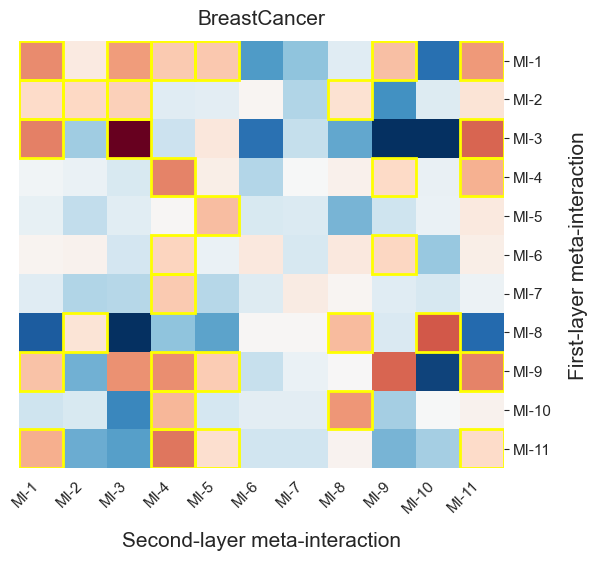

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_BreastCancer.png


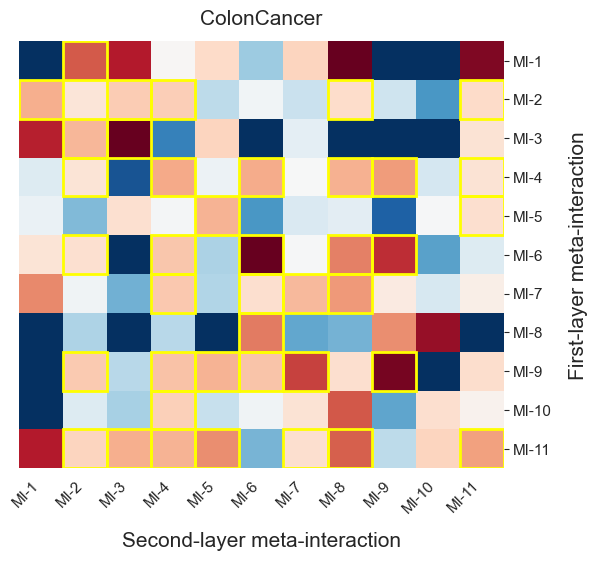

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_ColonCancer.png


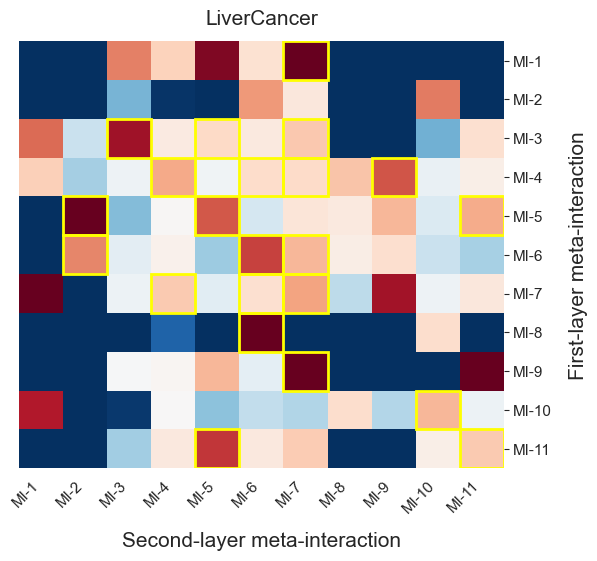

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_LiverCancer.png


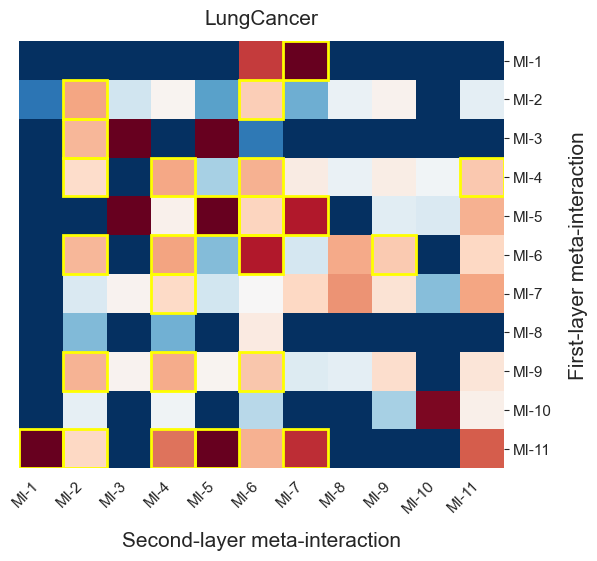

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_LungCancer.png


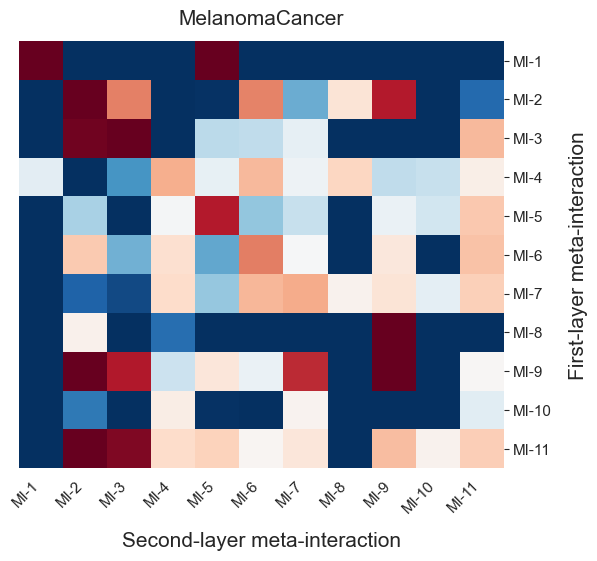

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_MelanomaCancer.png


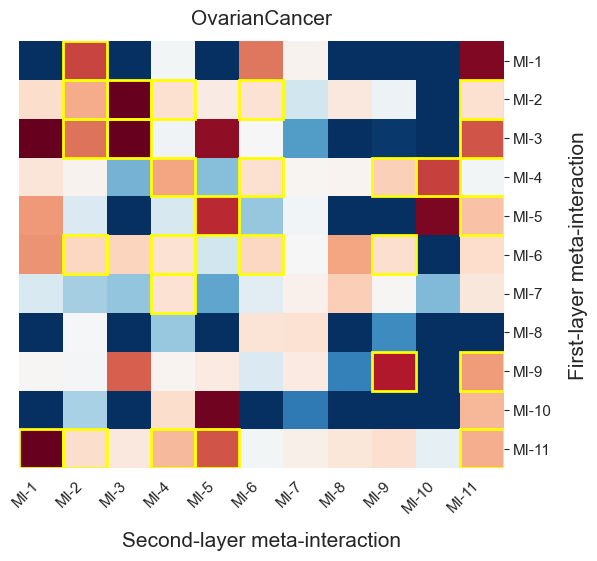

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_OvarianCancer.png


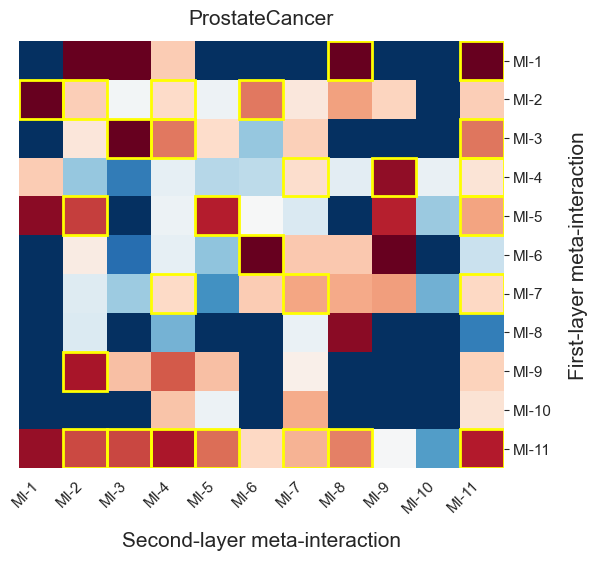

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_ProstateCancer.png


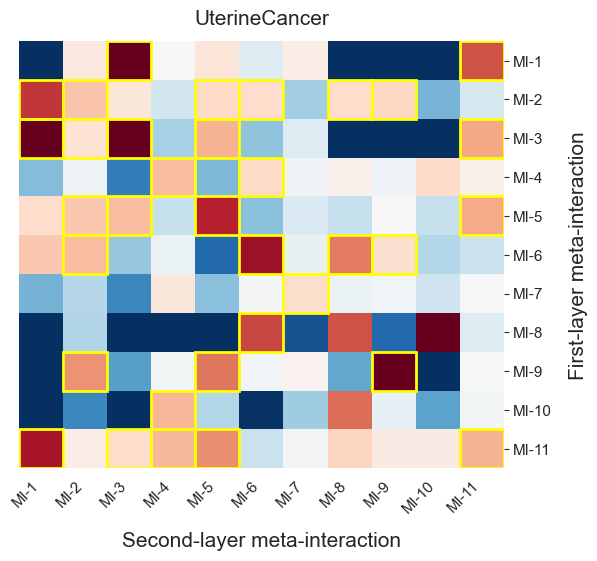

Saved heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Zscore_Colocalization_Count_UterineCancer.png
Saved yellow-box count matrix:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/MI_MI_yellow_box_cancer_count.csv
Saved yellow-box cancer-type detail matrix:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/MI_MI_yellow_box_cancer_types.csv


,MI-1,MI-2,MI-3,MI-4,MI-5,MI-6,MI-7,MI-8,MI-9,MI-10,MI-11
MI-1,1,2,2,1,1,0,2,1,1,0,3
MI-2,4,5,3,3,1,4,0,3,1,0,2
MI-3,2,4,6,1,2,0,1,0,0,0,4
MI-4,0,2,0,6,0,5,2,1,5,1,4
MI-5,0,3,1,0,7,1,1,0,0,0,5
MI-6,0,5,0,4,0,6,1,2,5,0,0
MI-7,0,0,0,6,0,2,4,1,0,0,1
MI-8,0,1,0,0,0,3,0,1,0,1,0
MI-9,1,4,0,3,3,2,2,0,3,0,2
MI-10,0,0,0,3,0,0,0,1,0,1,0


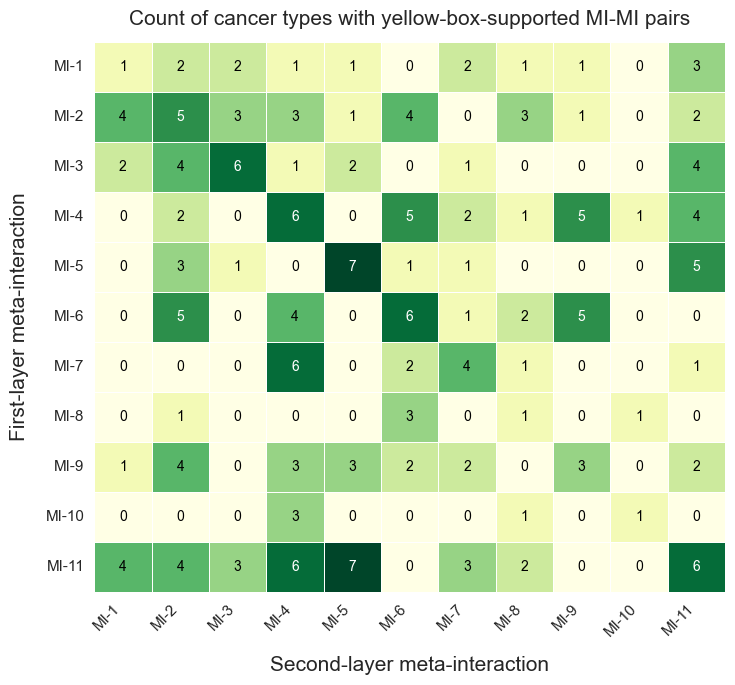

Saved yellow-box count heatmap: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\/Heatmap_Yellow_Box_Cancer_Count.png


In [10]:
# =========================================
# Fixed-order heatmaps of log2 observed/null MI cascade count ratios
# =========================================
heatmap_vmin = -2
heatmap_vmax = 2

def sanitize_filename(text):
    """Convert a label into a filesystem-safe filename fragment."""
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text))

def plot_mi_colocalization_heatmap(zscore_df, pvalue_df, cancer_label, out_prefix,
                                   zscore_threshold, pvalue_threshold,
                                   vmin=-1, vmax=1):
    """Plot a fixed-order MI-MI colocalization heatmap without row/column clustering."""
    g = sns.clustermap(
        zscore_df,
        cmap="RdBu_r",
        center=0,
        vmin=vmin,
        vmax=vmax,
        figsize=(7, 6),
        square=False,
        row_cluster=False,
        col_cluster=False,
        dendrogram_ratio=(0.01, 0.01),
        cbar_pos=None,   # remove colorbar
    )

    # Hide unused dendrogram axes because clustering is disabled.
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)

    row_order = list(range(zscore_df.shape[0]))
    col_order = list(range(zscore_df.shape[1]))

    for i_new, i_old in enumerate(row_order):
        for j_new, j_old in enumerate(col_order):
            p_val = pvalue_df.iloc[i_old, j_old]
            z_val = zscore_df.iloc[i_old, j_old]
            if p_val < pvalue_threshold and z_val > np.log2(zscore_threshold):
                g.ax_heatmap.add_patch(
                    Rectangle(
                        (j_new, i_new),
                        1,
                        1,
                        fill=False,
                        edgecolor="yellow",
                        lw=2.0,
                    )
                )

    g.ax_heatmap.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
    g.ax_heatmap.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)
    g.ax_heatmap.set_title(f"{cancer_label}", fontsize=15, pad=12)

    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=11,
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(),
        rotation=0,
        fontsize=11,
    )

    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.18, left=0.18, right=0.90)

    png_path = out_prefix + ".png"
    pdf_path = out_prefix + ".pdf"
    g.fig.savefig(png_path, dpi=300)
    g.fig.savefig(pdf_path, dpi=300)
    plt.show()
    plt.close(g.fig)

    print(f"Saved heatmap: {png_path}")


# ------------------------------------------------------------
# Cancer-type-specific heatmaps
# ------------------------------------------------------------
for cancer_type in cancertype_list:
    plot_mi_colocalization_heatmap(
        zscore_df=colocal_count_zscore_by_cancertype[cancer_type],
        pvalue_df=colocal_count_pvalue_by_cancertype[cancer_type],
        cancer_label=f"{cancer_type}",
        out_prefix=file_savepath_main + f"/Heatmap_Zscore_Colocalization_Count_{sanitize_filename(cancer_type)}",
        zscore_threshold=zscore_threshold,
        pvalue_threshold=pvalue_thresold,
        vmin=heatmap_vmin,
        vmax=heatmap_vmax,
    )


# ============================================================
# Count how many cancer types mark each MI-MI pair with yellow boxes
# ============================================================
def get_yellow_box_mask(zscore_df, pvalue_df, zscore_threshold, pvalue_threshold):
    """
    Return a boolean MI x MI mask indicating which entries would be highlighted
    with yellow boxes in the heatmap.
    """
    return (pvalue_df < pvalue_threshold) & (zscore_df > np.log2(zscore_threshold))


# Use the first cancer type as the reference MI order
reference_cancer = cancertype_list[0]
reference_index = colocal_count_zscore_by_cancertype[reference_cancer].index
reference_columns = colocal_count_zscore_by_cancertype[reference_cancer].columns

# Initialize count matrix
yellow_box_count_df = pd.DataFrame(
    0,
    index=reference_index,
    columns=reference_columns,
    dtype=int,
)

# Optional: record which cancer types support each MI-MI pair
yellow_box_cancer_list_df = pd.DataFrame(
    "",
    index=reference_index,
    columns=reference_columns,
    dtype=object,
)

for cancer_type in cancertype_list:
    zscore_df = colocal_count_zscore_by_cancertype[cancer_type].copy()
    pvalue_df = colocal_count_pvalue_by_cancertype[cancer_type].copy()

    # Align to the same MI order across cancer types
    zscore_df = zscore_df.loc[reference_index, reference_columns]
    pvalue_df = pvalue_df.loc[reference_index, reference_columns]

    yellow_mask = get_yellow_box_mask(
        zscore_df=zscore_df,
        pvalue_df=pvalue_df,
        zscore_threshold=zscore_threshold,
        pvalue_threshold=pvalue_thresold,
    )

    # Accumulate count
    yellow_box_count_df += yellow_mask.astype(int)

    # Optional: store supporting cancer types
    for i in reference_index:
        for j in reference_columns:
            if yellow_mask.loc[i, j]:
                if yellow_box_cancer_list_df.loc[i, j] == "":
                    yellow_box_cancer_list_df.loc[i, j] = cancer_type
                else:
                    yellow_box_cancer_list_df.loc[i, j] += f"; {cancer_type}"

# Save results
yellow_box_count_df.to_csv(
    file_savepath_main + "/MI_MI_yellow_box_cancer_count.csv"
)
yellow_box_cancer_list_df.to_csv(
    file_savepath_main + "/MI_MI_yellow_box_cancer_types.csv"
)

print("Saved yellow-box count matrix:")
print(file_savepath_main + "/MI_MI_yellow_box_cancer_count.csv")

print("Saved yellow-box cancer-type detail matrix:")
print(file_savepath_main + "/MI_MI_yellow_box_cancer_types.csv")

display(yellow_box_count_df)


# ============================================================
# Heatmap of yellow-box count across cancer types
# ============================================================
def plot_yellow_box_count_heatmap(count_df, out_prefix, cmap="YlGn"):
    """
    Plot a heatmap of the number of cancer types supporting each MI-MI pair.
    Annotate each cell with its count value.
    Annotation text color:
        - black if value <= 4
        - white if value > 4
    """
    fig_width = max(7, 0.45 * count_df.shape[1] + 2.5)
    fig_height = max(6, 0.45 * count_df.shape[0] + 2.0)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    hm = sns.heatmap(
        count_df,
        cmap=cmap,
        annot=True,
        fmt="d",
        linewidths=0.5,
        linecolor="white",
        cbar=False,   # remove colorbar
        square=False,
        ax=ax,
        annot_kws={"fontsize": 10},
    )

    # Set annotation color based on value
    n_rows, n_cols = count_df.shape
    for i in range(n_rows):
        for j in range(n_cols):
            val = count_df.iloc[i, j]
            text_idx = i * n_cols + j
            hm.texts[text_idx].set_color("black" if val <= 4 else "white")

    ax.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
    ax.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)
    ax.set_title("Count of cancer types with yellow-box-supported MI-MI pairs", fontsize=15, pad=12)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=11,
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=11,
    )

    plt.tight_layout()

    png_path = out_prefix + ".png"
    pdf_path = out_prefix + ".pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved yellow-box count heatmap: {png_path}")


plot_yellow_box_count_heatmap(
    count_df=yellow_box_count_df,
    out_prefix=file_savepath_main + "/Heatmap_Yellow_Box_Cancer_Count",
    cmap="YlGn",
)

## 6. Cell-type triplet composition within MI cascades

For each cancer type and significant MI pair, sum observed cascade counts across its sub-slices and divide each cell-type triplet count by the total for that MI pair. These proportions describe triplet composition, rather than a separate triplet enrichment test.

The heatmap retains tumor-involving triplets whose maximum proportion across MI pairs exceeds 0.05. Its rows are the cross-cancer union of significant MI pairs; columns identify cancer type and cell-type triplet. A separate selected-pair summary uses `target_MI_first` and `target_MI_second` below.


In [11]:
# ==============================================================
# 1. Initialize containers for cancer-type-specific results
# --------------------------------------------------------------
# For each cancer type, compute cell-type triple proportions only
# within that cancer type, using the significant MI cascades
# identified for that cancer type.
# ==============================================================
triplet_prop_by_cancertype_list = []
celltriple_index_sample_list = []


# ==============================================================
# 2. Loop over cancer types and their significant MI cascades
# ==============================================================
for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    sig_pairs_cur = MI_colocal_summary_significant_by_cancertype.loc[
        MI_colocal_summary_significant_by_cancertype["CancerType"] == cancer_type
    ].reset_index(drop=True)

    print(f"Processing {cancer_type}: {len(sample_indices_cur)} samples, {sig_pairs_cur.shape[0]} significant MI cascades")

    if sig_pairs_cur.empty:
        continue

    for idx in range(sig_pairs_cur.shape[0]):
        MI_first = int(sig_pairs_cur.iloc[idx]["MI_first"])
        MI_second = int(sig_pairs_cur.iloc[idx]["MI_second"])
        MI_first_idx, MI_second_idx = MI_first - 1, MI_second - 1

        all_summary_tables = []
        celltriple_index_all = []

        # --------------------------------------------------------------
        # 2.1 Compute cell-type triples for each sample within this
        #     cancer type
        # --------------------------------------------------------------
        for sample_index in sample_indices_cur:
            F = Factor_envir_norm_list[sample_index]      # (E, d)
            A = hyper_edge_adj_list[sample_index]         # (E, E) sparse adjacency
            edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
            adata_cur = adata_list[sample_index]
            celltypes = adata_cur.obs['celltype_final'].values[edge_index]
            F_cut = (F > MI_threshold).astype(int)

            rel_first = np.where(F_cut[:, MI_first_idx])[0]
            rel_second = np.where(F_cut[:, MI_second_idx])[0]
            if (len(rel_first) == 0) or (len(rel_second) == 0):
                continue

            A_sub = A[rel_first, :][:, rel_second].toarray()
            a_i, a_j = np.where(A_sub == 1)
            if len(a_i) == 0:
                continue

            paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

            pair_first = edge_index[paired_idx[:, 0], :]
            pair_second = edge_index[paired_idx[:, 1], :]
            celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
            celltriple_index_all.append(celltriple_index)

            triple_ct = np.asarray(adata_cur.obs['celltype_final'].values[celltriple_index])
            if triple_ct.shape[0] == 0:
                continue

            triple_label = (
                triple_ct[:, 0] + " -> " +
                triple_ct[:, 1] + " -> " +
                triple_ct[:, 2]
            )

            triple_counts = pd.Series(triple_label).value_counts().reset_index()
            triple_counts.columns = ["Celltype_triple", "Count"]
            if triple_counts.empty:
                continue

            parts = triple_counts["Celltype_triple"].str.split("->", expand=True)
            triple_counts["ctp_MI_first"] = parts[0].str.strip() + " -> " + parts[1].str.strip()
            triple_counts["ctp_MI_second"] = parts[1].str.strip() + " -> " + parts[2].str.strip()
            triple_counts["Sample"] = adata_cur.obs["SampleID"].unique()[0]
            triple_counts["CancerType"] = cancer_type
            triple_counts["MI_first"] = MI_first
            triple_counts["MI_second"] = MI_second

            # Within-sample proportion is kept for reference.
            triple_counts["prop_within_sample"] = triple_counts["Count"] / triple_counts["Count"].sum()

            def calc_ratio(row):
                ctp1, ctp2, cnt = row["ctp_MI_first"], row["ctp_MI_second"], row["Count"]
                ct1a, ct1b = ctp1.split(" -> ")
                ct2a, ct2b = ctp2.split(" -> ")
                edge_ct = celltypes
                r1 = np.sum((edge_ct[:, 0] == ct1a) & (edge_ct[:, 1] == ct1b))
                r2 = np.sum((edge_ct[:, 0] == ct2a) & (edge_ct[:, 1] == ct2b))
                denom = (float(r1) * float(r2)) / float(F_cut.shape[0])
                return float(cnt) / denom if denom > 0 else np.nan

            triple_counts["ratio"] = triple_counts.apply(calc_ratio, axis=1)
            all_summary_tables.append(triple_counts)

        celltriple_index_sample_list.append(
            {
                "CancerType": cancer_type,
                "MI_first": MI_first,
                "MI_second": MI_second,
                "celltriple_index_all": celltriple_index_all,
            }
        )

        if len(all_summary_tables) == 0:
            continue

        # --------------------------------------------------------------
        # 2.2 Aggregate only within the current cancer type
        # --------------------------------------------------------------
        combined = pd.concat(all_summary_tables, axis=0, ignore_index=True)
        total_count_cur = combined["Count"].sum()
        if total_count_cur == 0:
            continue

        prop_avg_cur = (
            combined.groupby("Celltype_triple")["Count"]
            .sum()
            .div(total_count_cur)
            .reset_index(name="prop_within_cancertype")
        )
        prop_avg_cur["CancerType"] = cancer_type
        prop_avg_cur["MI_first"] = MI_first
        prop_avg_cur["MI_second"] = MI_second
        triplet_prop_by_cancertype_list.append(prop_avg_cur)


# ==============================================================
# 3. Merge cancer-type-specific results and build the pivot table
# --------------------------------------------------------------
# Rows in the final heatmap should use the cross-cancer union of
# significant MI pairs, so the MI-cascade label here should not
# include cancer type.
# ==============================================================
if len(triplet_prop_by_cancertype_list) == 0:
    raise ValueError("No cancer-type-specific cell-type triple summaries were generated.")

triplet_prop_by_cancertype_merge = pd.concat(
    triplet_prop_by_cancertype_list,
    axis=0,
    ignore_index=True,
)

triplet_prop_by_cancertype_merge["MI cascade union"] = (
    "MI-" + triplet_prop_by_cancertype_merge["MI_first"].astype(str) +
    " -> MI-" + triplet_prop_by_cancertype_merge["MI_second"].astype(str)
)
triplet_prop_by_cancertype_merge["CancerType | Celltype Triple"] = (
    triplet_prop_by_cancertype_merge["CancerType"] + " | " +
    triplet_prop_by_cancertype_merge["Celltype_triple"]
)

# Keep only cancer-cell-related triples for visualization.
triplet_prop_cancercell = triplet_prop_by_cancertype_merge.loc[
    triplet_prop_by_cancertype_merge["Celltype_triple"].str.contains("cancercell", case=False, na=False)
].copy()

# Use the cross-cancer union of significant MI pairs as heatmap rows.
# Each cancer-type-specific triple contributes values only to the MI
# cascades that were significant in that same cancer type.
pivot_cancercell = triplet_prop_cancercell.pivot(
    index="CancerType | Celltype Triple",
    columns="MI cascade union",
    values="prop_within_cancertype"
).fillna(0)

prop_avg_by_cancertype_filter_merge_pivot_select = pivot_cancercell.loc[
    pivot_cancercell.max(axis=1) > 5e-2,
    :
].copy()

# Save the long table and the pivot table for downstream use.
triplet_prop_by_cancertype_merge.to_csv(
    file_savepath_main + "/Celltype_triple_prop_within_cancertype_long.csv",
    index=False,
)
prop_avg_by_cancertype_filter_merge_pivot_select.to_csv(
    file_savepath_main + "/Celltype_triple_prop_within_cancertype_cancercell_pivot_unionMIs.csv"
)

print("Cancer-type-specific triplet summary completed.")
print(f"Long table shape: {triplet_prop_by_cancertype_merge.shape}")
print(f"Cancer-cell pivot shape: {prop_avg_by_cancertype_filter_merge_pivot_select.shape}")


Processing BreastCancer: 20 samples, 33 significant MI cascades
Processing ColonCancer: 20 samples, 40 significant MI cascades
Processing LiverCancer: 20 samples, 22 significant MI cascades
Processing LungCancer: 20 samples, 24 significant MI cascades
Processing MelanomaCancer: 20 samples, 0 significant MI cascades
Processing OvarianCancer: 20 samples, 27 significant MI cascades
Processing ProstateCancer: 20 samples, 27 significant MI cascades
Processing UterineCancer: 20 samples, 34 significant MI cascades
Cancer-type-specific triplet summary completed.
Long table shape: (18720, 7)
Cancer-cell pivot shape: (222, 73)


In [12]:
import pandas as pd
import re


df = prop_avg_by_cancertype_filter_merge_pivot_select.copy()


def _split_display_label(label: str):
    text = str(label)
    if " | " in text:
        return text.split(" | ", 1)
    return "", text


def _parse_triple_from_display_label(label: str):
    _, triple = _split_display_label(label)
    parts = [p.strip() for p in triple.split("->")]
    if len(parts) < 3:
        parts = parts + [""] * (3 - len(parts))
    elif len(parts) > 3:
        parts = parts[:3]
    return parts


def _is_cancercell(ct: str):
    return "cancercell" in str(ct).lower()


pair_priority = {(0, 1): 0, (1, 2): 1, (0, 2): 2}
cancertype_order = {ct: i for i, ct in enumerate(cancertype_list)}


def sort_key_triple(display_label: str):
    cancer_type, _ = _split_display_label(display_label)
    cts = _parse_triple_from_display_label(display_label)
    flags = [_is_cancercell(x) for x in cts]
    k = sum(flags)

    if k == 1:
        i = flags.index(True)
        if i == 0:
            pos_rank = pair_priority[(0, 1)]
        elif i == 1:
            pos_rank = pair_priority[(0, 1)]
        else:
            pos_rank = pair_priority[(1, 2)]
    else:
        pos_rank = 9

    return (cancertype_order.get(cancer_type, 999), -k, pos_rank, str(display_label))


def sort_key_cascade(label: str):
    cancer_type, cascade = _split_display_label(label)
    mi_numbers = re.findall(r"MI-(\d+)", cascade)
    if len(mi_numbers) >= 2:
        mi_first, mi_second = map(int, mi_numbers[:2])
    else:
        mi_first, mi_second = 999, 999
    return (cancertype_order.get(cancer_type, 999), mi_first, mi_second, str(label))


row_order = sorted(df.index, key=sort_key_triple)
col_order = sorted(df.columns, key=sort_key_cascade)

df_sorted = df.loc[row_order, col_order].copy()
prop_avg_by_cancertype_filter_merge_pivot_select = df_sorted

df_sorted



MI cascade union,MI-1 -> MI-1,MI-1 -> MI-2,MI-1 -> MI-3,MI-1 -> MI-4,MI-1 -> MI-5,MI-1 -> MI-7,MI-1 -> MI-8,MI-1 -> MI-9,MI-1 -> MI-11,MI-2 -> MI-1,...,MI-10 -> MI-8,MI-10 -> MI-10,MI-11 -> MI-1,MI-11 -> MI-2,MI-11 -> MI-3,MI-11 -> MI-4,MI-11 -> MI-5,MI-11 -> MI-7,MI-11 -> MI-8,MI-11 -> MI-11
CancerType | Celltype Triple,,,,,,,,,,,,,,,,,,,,,
BreastCancer | Breast-cancercell -> Breast-cancercell -> Breast-cancercell,0.909792,0.0,0.821244,0.000000,0.019322,0.0,0.0,0.358871,0.060636,0.829293,...,0.589832,0.0,0.109127,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
BreastCancer | Breast-cancercell -> Breast-cancercell -> CD8_T/NK,0.006693,0.0,0.018135,0.000000,0.086120,0.0,0.0,0.028226,0.143141,0.006487,...,0.000765,0.0,0.000992,0.0,0.000000,0.000000,0.001275,0.0,0.0,0.000000
BreastCancer | Breast-cancercell -> Breast-cancercell -> Endothelial,0.010370,0.0,0.013817,0.001303,0.008281,0.0,0.0,0.012097,0.025845,0.009218,...,0.005352,0.0,0.000992,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
BreastCancer | Breast-cancercell -> Breast-cancercell -> Fibroblast,0.015011,0.0,0.023316,0.000782,0.072634,0.0,0.0,0.157258,0.042744,0.015022,...,0.069572,0.0,0.001984,0.0,0.000000,0.000172,0.000956,0.0,0.0,0.000000
BreastCancer | Breast-cancercell -> Breast-cancercell -> Macrophage,0.012833,0.0,0.012090,0.000000,0.602208,0.0,0.0,0.173387,0.009940,0.010584,...,0.000382,0.0,0.001984,0.0,0.000000,0.000000,0.004780,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UterineCancer | Fibroblast -> Macrophage -> Uterine-cancercell,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.020000,0.006208,0.001984,0.0,0.0,0.005727
UterineCancer | Macrophage -> CD4_T -> Uterine-cancercell,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.000955,0.001323,0.0,0.0,0.001432
UterineCancer | Macrophage -> CD8_T/NK -> Uterine-cancercell,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.066667,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.001433,0.000000,0.0,0.0,0.000716


### Tumor-involving cell-type triplet proportions


In [13]:
def plot_heatmap(data, title, xlabel, ylabel, filename, highlight_cancercell=False,
                 row_cluster=False, col_cluster=False, vmin=0, vmax=1):
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['mathtext.fontset'] = 'dejavuserif'
    plt.rcParams['font.family'] = 'arial'

    # The heatmap is drawn on data.T so that columns correspond to
    # cancer-type-specific cell-type triples.
    fig_w = max(8, 0.28 * data.shape[0] + 4)
    fig_h = max(6, 0.28 * data.shape[1] + 3)

    g = sns.clustermap(
        data.T,
        cmap="Reds",
        vmin=vmin,
        vmax=vmax,
        figsize=(fig_w, fig_h),
        square=False,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        dendrogram_ratio=(0.08, 0.08),
        cbar_pos=(0.92, 0.2, 0.02, 0.5),
        linecolor="lightgrey",
        linewidth=0.4,
    )

    if not row_cluster:
        g.ax_row_dendrogram.set_visible(False)
    if not col_cluster:
        g.ax_col_dendrogram.set_visible(False)

    g.ax_heatmap.set_xlabel(xlabel, fontsize=14)
    g.ax_heatmap.set_ylabel(ylabel, fontsize=14)
    g.ax_heatmap.set_title(title, fontsize=16, pad=12)

    xticklabels = g.ax_heatmap.get_xticklabels()
    for label in xticklabels:
        label_text = label.get_text()
        label.set_color("red" if ("cancercell" in label_text.lower() and highlight_cancercell) else "black")

    g.ax_heatmap.set_xticklabels(xticklabels, rotation=75, ha="right", fontsize=9)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.30, left=0.25, right=0.90)
    g.fig.savefig(file_savepath_main + "/" + filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(g.fig)
    print(f"✅ Saved: {filename}")



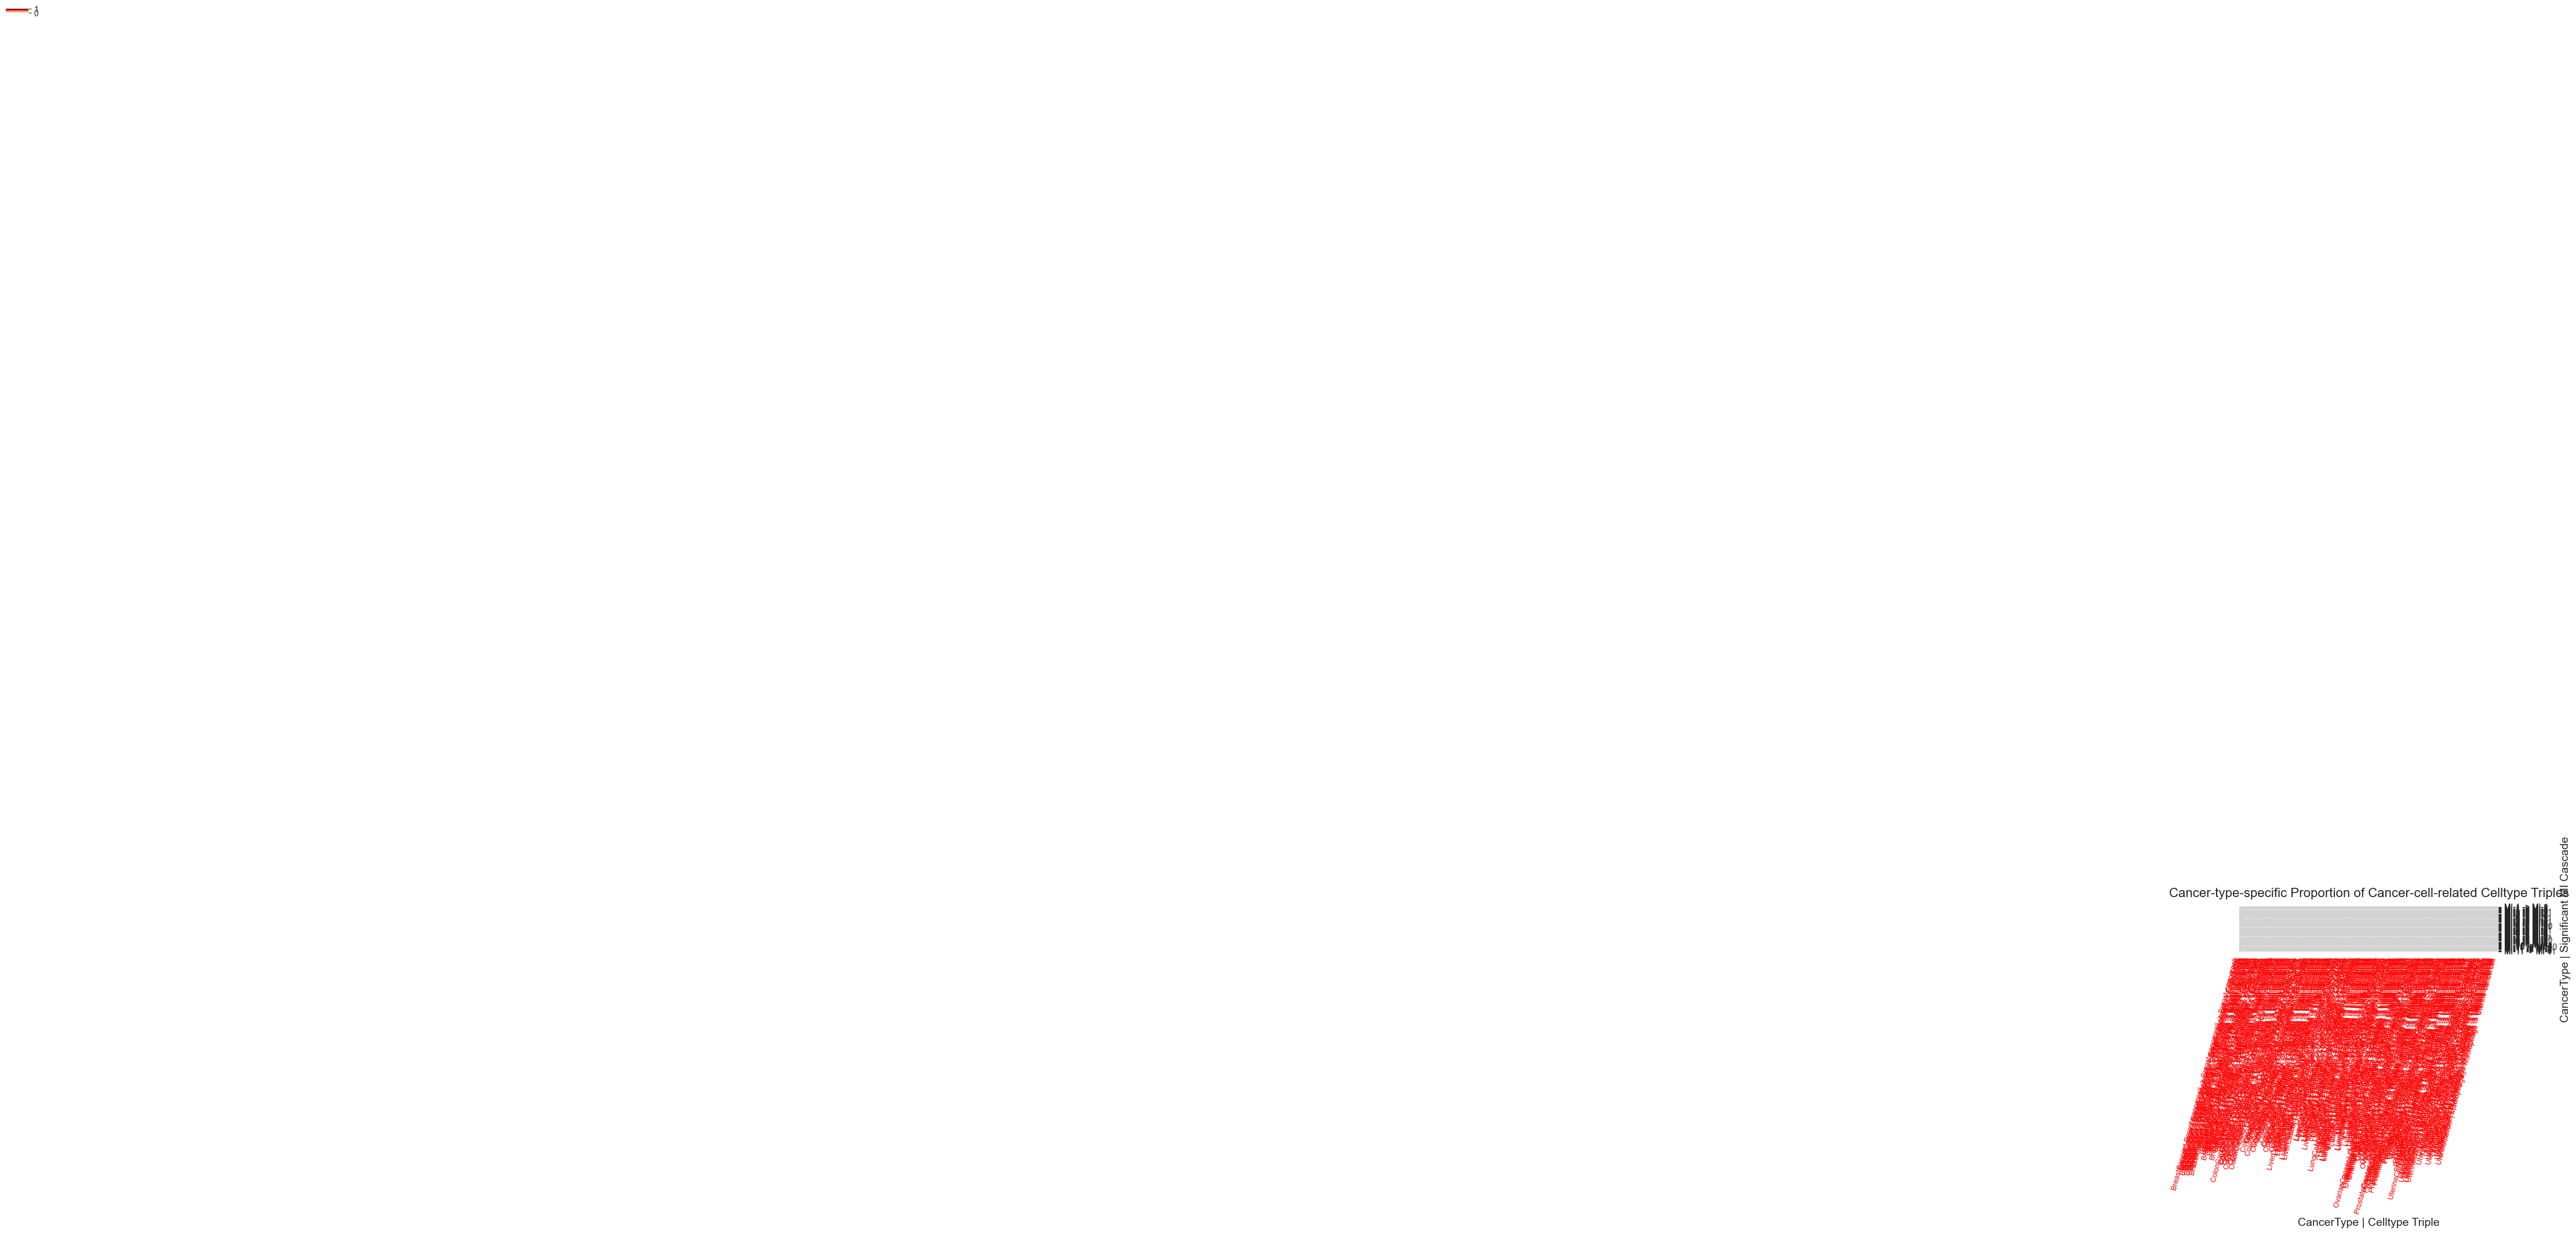

✅ Saved: Heatmap_prop_Celltype_triple_within_cancertype_cancercell.pdf


In [14]:
# ==============================================================
# Heatmap of cancer-cell-related cell-type triples only
# --------------------------------------------------------------
# Proportions are computed within cancer type. Rows are MI pairs;
# columns retain cancer-type-specific cell-type triplet identities.
# ============================================================== 
plot_heatmap(
    prop_avg_by_cancertype_filter_merge_pivot_select,
    title="Cancer-type-specific Proportion of Cancer-cell-related Celltype Triples",
    xlabel="CancerType | Celltype Triple",
    ylabel="CancerType | Significant MI Cascade",
    filename="Heatmap_prop_Celltype_triple_within_cancertype_cancercell.pdf",
    highlight_cancercell=True,
    row_cluster=False,
    col_cluster=False,
    vmin=0, vmax=1
)



In [15]:
# ==============================================================
# Cell-type triplet proportions for the selected MI-7 -> MI-4 pair
# ==============================================================

target_MI_first = 7
target_MI_second = 4
target_pair_label = f"MI-{target_MI_first} -> MI-{target_MI_second}"

# Record whether the selected MI pair is significant in each cancer type.
sig_lookup = set(
    zip(
        MI_colocal_summary_significant_by_cancertype["CancerType"].astype(str),
        MI_colocal_summary_significant_by_cancertype["MI_first"].astype(int),
        MI_colocal_summary_significant_by_cancertype["MI_second"].astype(int),
    )
)

prop_rows = []

for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    MI_first_idx = target_MI_first - 1
    MI_second_idx = target_MI_second - 1

    triple_counts_all_samples_cur = []

    for sample_index in sample_indices_cur:
        F = Factor_envir_norm_list[sample_index]                      # (E, d)
        A = hyper_edge_adj_list[sample_index]                        # (E, E) sparse adjacency
        edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
        adata_cur = adata_list[sample_index]

        # celltypes_edge = adata_cur.obs["celltype_final"].values[edge_index]   # (E, 2)
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()
        celltypes_edge = celltype_values[edge_index]
        F_cut = (F > MI_threshold).astype(int)

        rel_first = np.where(F_cut[:, MI_first_idx])[0]
        rel_second = np.where(F_cut[:, MI_second_idx])[0]

        if (len(rel_first) == 0) or (len(rel_second) == 0):
            continue

        A_sub = A[rel_first, :][:, rel_second]
        a_i, a_j = A_sub.nonzero()

        if len(a_i) == 0:
            continue

        paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

        pair_first = edge_index[paired_idx[:, 0], :]
        pair_second = edge_index[paired_idx[:, 1], :]
        celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
        
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()
        triple_ct = celltype_values[celltriple_index]
        
        triple_label = np.array([
            f"{a} -> {b} -> {c}"
            for a, b, c in triple_ct
        ], dtype=object)

        triple_counts = pd.Series(triple_label).value_counts().reset_index()
        triple_counts.columns = ["Celltype_triple", "Count"]

        if triple_counts.shape[0] == 0:
            continue

        triple_counts["Sample"] = adata_cur.obs["SampleID"].unique()[0]
        triple_counts_all_samples_cur.append(triple_counts)

    # If this MI pair does not appear in this cancer type, fill with empty table
    if len(triple_counts_all_samples_cur) == 0:
        continue

    combined_cur = pd.concat(triple_counts_all_samples_cur, axis=0)

    prop_cur = (
        combined_cur.groupby("Celltype_triple", as_index=False)["Count"]
        .sum()
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    total_count_cur = prop_cur["Count"].sum()
    prop_cur["prop_within_cancertype"] = prop_cur["Count"] / total_count_cur

    prop_cur["CancerType"] = cancer_type
    prop_cur["MI_first"] = target_MI_first
    prop_cur["MI_second"] = target_MI_second
    prop_cur["MI cascade union"] = target_pair_label
    prop_cur["CancerType | Celltype Triple"] = (
        prop_cur["CancerType"] + " | " + prop_cur["Celltype_triple"]
    )

    is_sig_cur = (cancer_type, target_MI_first, target_MI_second) in sig_lookup
    prop_cur["is_significant_in_this_cancertype"] = is_sig_cur

    # The union heatmap includes a proportion only where this MI pair is significant.
    prop_cur["prop_for_union_heatmap"] = np.where(
        prop_cur["is_significant_in_this_cancertype"],
        prop_cur["prop_within_cancertype"],
        0.0
    )

    prop_rows.append(prop_cur)

# --------------------------------------------------------------
# Merge results; the prop_MI11_MI2_* names are retained as table identifiers.
# --------------------------------------------------------------
prop_MI11_MI2_by_cancertype = pd.concat(prop_rows, axis=0).reset_index(drop=True)

# All triplets
# display(prop_MI11_MI2_by_cancertype.head(20))

# --------------------------------------------------------------
# Cancer-cell-related triplets only
# --------------------------------------------------------------
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype.loc[
    prop_MI11_MI2_by_cancertype["Celltype_triple"].str.contains("cancercell", case=False, na=False)
].copy()

# Sort by the real within-cancer-type proportion
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype_cancercell.sort_values(
    ["CancerType", "prop_within_cancertype"],
    ascending=[True, False]
).reset_index(drop=True)

# display(prop_MI11_MI2_by_cancertype_cancercell)

prop_MI11_MI2_by_cancertype_cancercell.to_csv(
    Path(file_savepath_main) / f"Celltype_triple_prop_selected_MI-{target_MI_first}_MI-{target_MI_second}_cancercell.csv",
    index=False,
)


In [16]:
# Order triplets by decreasing within-cancer-type proportion.
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype_cancercell.sort_values(
    ["prop_within_cancertype"],
    ascending=[ False]
).reset_index(drop=True)
prop_MI11_MI2_by_cancertype_cancercell

,Celltype_triple,Count,prop_within_cancertype,CancerType,MI_first,MI_second,MI cascade union,CancerType | Celltype Triple,is_significant_in_this_cancertype,prop_for_union_heatmap
0,Uterine-cancercell -> Fibroblast -> Uterine-ca...,292,0.174746,UterineCancer,7,4,MI-7 -> MI-4,UterineCancer | Uterine-cancercell -> Fibrobla...,False,0.000000
1,Endothelial -> Fibroblast -> Liver-cancercell,743,0.129623,LiverCancer,7,4,MI-7 -> MI-4,LiverCancer | Endothelial -> Fibroblast -> Liv...,True,0.129623
2,Breast-cancercell -> Fibroblast -> Breast-canc...,2692,0.125536,BreastCancer,7,4,MI-7 -> MI-4,BreastCancer | Breast-cancercell -> Fibroblast...,True,0.125536
3,Liver-cancercell -> Fibroblast -> Liver-cancer...,621,0.108339,LiverCancer,7,4,MI-7 -> MI-4,LiverCancer | Liver-cancercell -> Fibroblast -...,True,0.108339
4,Ovarian-cancercell -> Fibroblast -> Fibroblast,190,0.081756,OvarianCancer,7,4,MI-7 -> MI-4,OvarianCancer | Ovarian-cancercell -> Fibrobla...,True,0.081756
...,...,...,...,...,...,...,...,...,...,...
430,B cell -> Macrophage -> Breast-cancercell,1,0.000047,BreastCancer,7,4,MI-7 -> MI-4,BreastCancer | B cell -> Macrophage -> Breast-...,True,0.000047
431,CD8_T/NK -> CD4_T -> Breast-cancercell,1,0.000047,BreastCancer,7,4,MI-7 -> MI-4,BreastCancer | CD8_T/NK -> CD4_T -> Breast-can...,True,0.000047
432,Endothelial -> DC -> Breast-cancercell,1,0.000047,BreastCancer,7,4,MI-7 -> MI-4,BreastCancer | Endothelial -> DC -> Breast-can...,True,0.000047
433,Endothelial -> Treg -> Breast-cancercell,1,0.000047,BreastCancer,7,4,MI-7 -> MI-4,BreastCancer | Endothelial -> Treg -> Breast-c...,True,0.000047


Number of cancer cell -> Fibroblast -> cancer cell triples before threshold filtering: 8
Number of cancer cell -> Fibroblast -> cancer cell triples after threshold filtering: 8


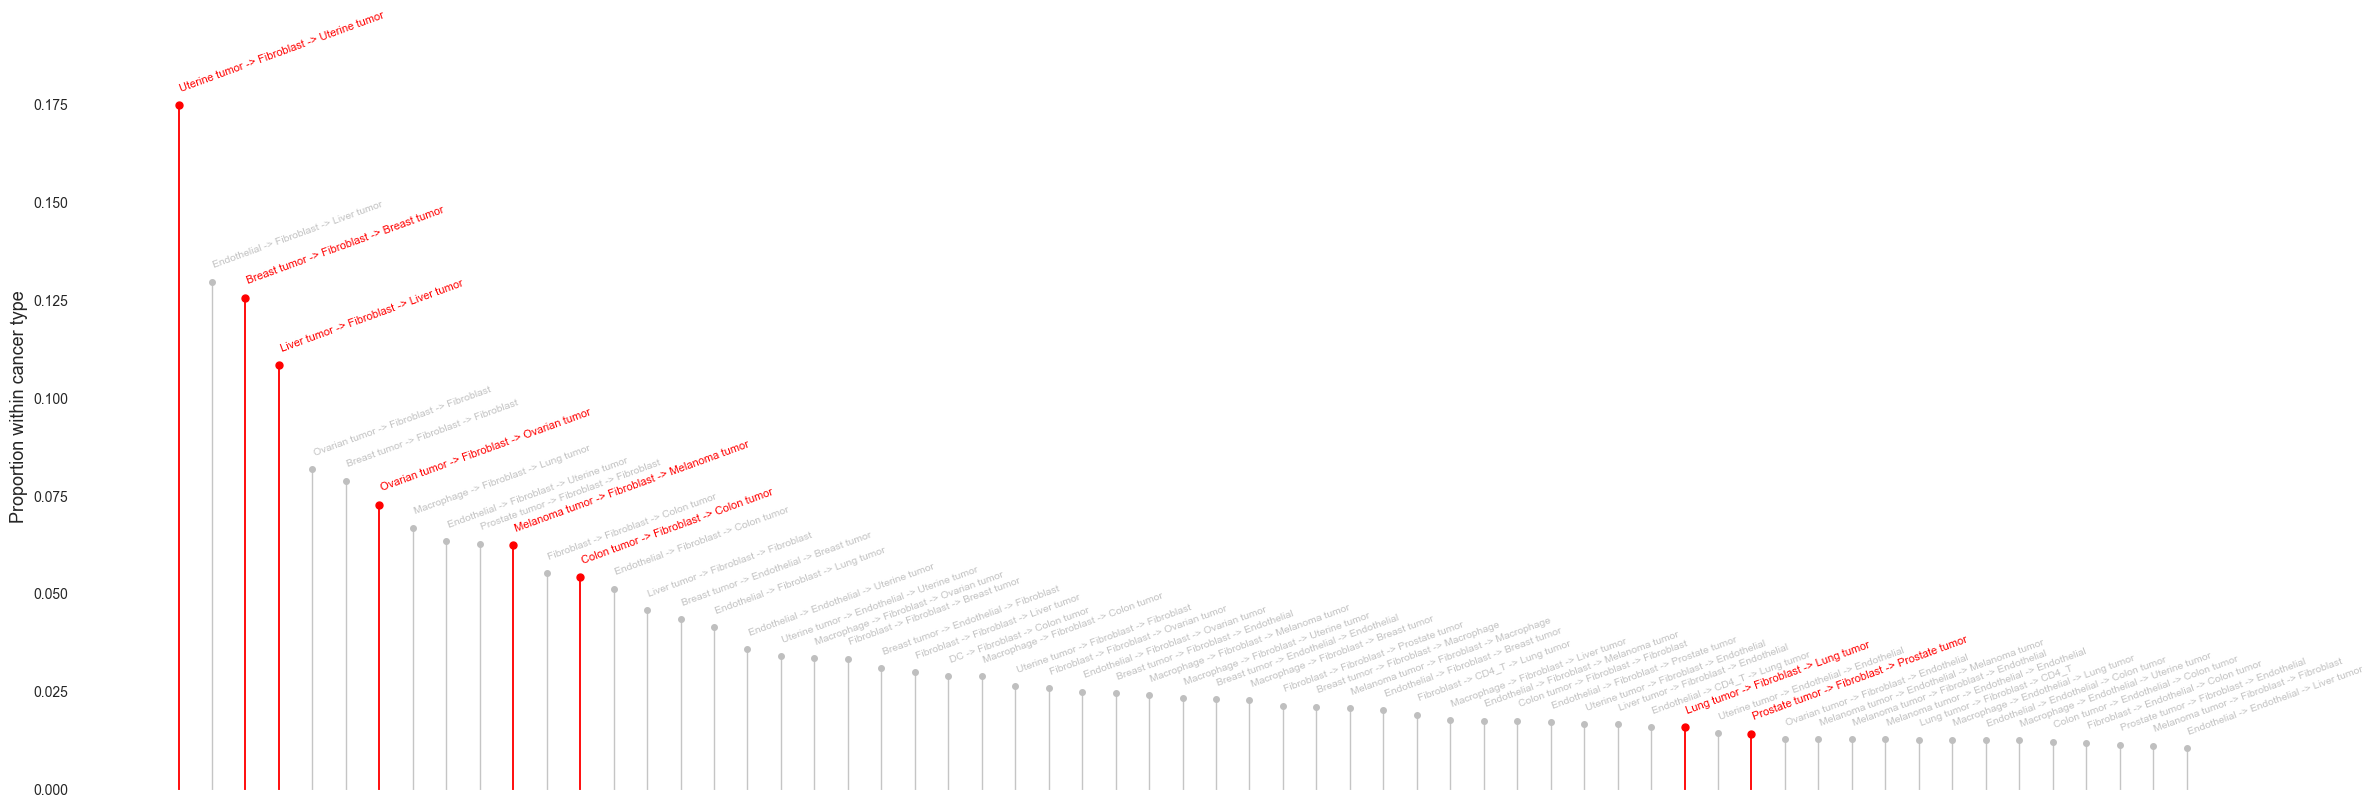

In [17]:
# ==============================================================
# Stem plot of within-cancer-type proportions for the selected MI pair
# Highlight: tumor -> fibroblast -> tumor
# Plot proportions above prop_threshold; output basenames retain MI11_to_MI2.
# ==============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prop_threshold = 0.01
gray_color = "#BFBFBF"

# --------------------------------------------------------------
# Define the highlight pattern:
# tumor -> fibroblast -> tumor
# First and third cancer cell types do NOT need to be identical
# --------------------------------------------------------------
def is_cancercell_to_fibro_to_cancercell(triple):
    if pd.isna(triple):
        return False
    
    triple = str(triple).strip()
    
    m = re.fullmatch(
        r"\s*([^>]+-cancercell)\s*->\s*Fibroblast\s*->\s*([^>]+-cancercell)\s*",
        triple
    )
    
    return m is not None


def format_annotation_label(triple):
    if pd.isna(triple):
        return ""
    return str(triple).replace("-cancercell", " tumor")


# --------------------------------------------------------------
# Copy data and add highlight label BEFORE filtering
# This allows checking whether highlighted triples are filtered out
# --------------------------------------------------------------
plot_df_all = prop_MI11_MI2_by_cancertype_cancercell.copy()

plot_df_all["highlight_red"] = plot_df_all["Celltype_triple"].apply(
    is_cancercell_to_fibro_to_cancercell
)

print(
    "Number of cancer cell -> Fibroblast -> cancer cell triples before threshold filtering:",
    plot_df_all["highlight_red"].sum()
)

# --------------------------------------------------------------
# Filter and sort data
# --------------------------------------------------------------
plot_df = plot_df_all.loc[
    plot_df_all["prop_within_cancertype"] > prop_threshold
].copy()

plot_df = plot_df.sort_values(
    ["prop_within_cancertype"],
    ascending=[False]
).reset_index(drop=True)

print(
    "Number of cancer cell -> Fibroblast -> cancer cell triples after threshold filtering:",
    plot_df["highlight_red"].sum()
)

# --------------------------------------------------------------
# X positions
# --------------------------------------------------------------
plot_df["x"] = np.arange(len(plot_df))

# --------------------------------------------------------------
# Split highlighted and non-highlighted points
# --------------------------------------------------------------
df_black = plot_df.loc[~plot_df["highlight_red"]].copy()
df_red = plot_df.loc[plot_df["highlight_red"]].copy()

# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(24, 8.3))

# Remove background gray box
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.patch.set_edgecolor("none")
ax.patch.set_linewidth(0)

# --------------------------------------------------------------
# Non-highlighted points and stems in light gray
# --------------------------------------------------------------
if len(df_black) > 0:
    markerline1, stemlines1, baseline1 = ax.stem(
        df_black["x"],
        df_black["prop_within_cancertype"],
        linefmt="-",
        markerfmt="o",
        basefmt=" ",
    )
    
    plt.setp(
        stemlines1,
        linewidth=1.0,
        alpha=0.9,
        color=gray_color
    )
    
    plt.setp(
        markerline1,
        markersize=4,
        color=gray_color,
        markerfacecolor=gray_color,
        markeredgecolor=gray_color
    )

# --------------------------------------------------------------
# Highlighted red points and stems
# --------------------------------------------------------------
if len(df_red) > 0:
    markerline2, stemlines2, baseline2 = ax.stem(
        df_red["x"],
        df_red["prop_within_cancertype"],
        linefmt="-",
        markerfmt="o",
        basefmt=" ",
    )
    
    plt.setp(
        stemlines2,
        linewidth=1.4,
        alpha=0.95,
        color="red"
    )
    
    plt.setp(
        markerline2,
        markersize=5,
        color="red",
        markerfacecolor="red",
        markeredgecolor="red"
    )

# --------------------------------------------------------------
# Remove x-axis labels and ticks
# --------------------------------------------------------------
ax.set_xticks([])
ax.tick_params(axis="x", which="both", length=0)

# --------------------------------------------------------------
# Labels
# --------------------------------------------------------------
ax.set_ylabel("Proportion within cancer type", fontsize=13)
ax.set_xlabel("")

# --------------------------------------------------------------
# Annotate non-highlighted points in light gray
# --------------------------------------------------------------
for _, row in df_black.iterrows():
    ax.text(
        row["x"],
        row["prop_within_cancertype"] + 0.003,
        format_annotation_label(row["Celltype_triple"]),
        rotation=20,
        ha="left",
        va="bottom",
        fontsize=7.5,
        color=gray_color,
        alpha=0.95
    )

# --------------------------------------------------------------
# Annotate highlighted points in red
# --------------------------------------------------------------
for _, row in df_red.iterrows():
    ax.text(
        row["x"],
        row["prop_within_cancertype"] + 0.003,
        format_annotation_label(row["Celltype_triple"]),
        rotation=20,
        ha="left",
        va="bottom",
        fontsize=8,
        color="red"
    )

# --------------------------------------------------------------
# Style
# --------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

if len(plot_df) > 0:
    ax.set_ylim(0, plot_df["prop_within_cancertype"].max() * 1.12)
else:
    ax.set_ylim(0, 0.06)

plt.tight_layout()

# --------------------------------------------------------------
# Save
# --------------------------------------------------------------
plt.savefig(
    file_savepath_main + "/Stemplot_MI11_to_MI2_prop_within_cancertype_highlight_cancercell_fibro_cancercell_ygt001.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    file_savepath_main + "/Stemplot_MI11_to_MI2_prop_within_cancertype_highlight_cancercell_fibro_cancercell_ygt001.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 7. In situ display and abundance of the selected cascade

For the selected MI pair and cell-type template, count thresholded cascades and all structurally possible matching edge chains. Cascade abundance is `100 * observed / potential`, distinct from the triplet-composition proportions in Section 6. The spatial-display cutoff is defined independently by `MI_threshold_show`.


In [18]:
# In situ cascade display and observed/potential count summaries
# Save two PNG variants with sizes and resolution defined by EDGE_SIZE_VERSIONS.
# Spatial panels contain cells and directed edges without axes, legends, or titles.
# Abundance is computed for the selected cell-type template in every cancer type.

import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# User settings
# --------------------------------------------------------------
MI_first_of_interest = 7
MI_second_of_interest = 4
celltype_triple_of_interest = "cancercell -> Fibroblast -> cancercell"
MI_threshold_show = 0.3

# Cell plotting settings
CELL_POINT_SIZE_BASE = 1
CELL_ALPHA = 0.60

# Edge plotting settings
EDGE_LW_BASE = 0.45
EDGE_HEAD_WIDTH_BASE = 3
EDGE_HEAD_LENGTH_BASE = 3

# PNG variants use multipliers relative to the base sizes above.
# The historical _edge2x suffix currently uses 4x edge sizes and 3x cell area;
# the unsuffixed variant uses 1x edge sizes and 1.5x cell area.
EDGE_SIZE_VERSIONS = [
    {
        "suffix": "",
        "edge_size_multiplier": 1.0,
        "cell_point_size_multiplier": 1.5,
        "dpi": 1000,
    },
    {
        "suffix": "_edge2x",
        "edge_size_multiplier": 4.0,
        "cell_point_size_multiplier": 3.0,
        "dpi": 800,
    },
]

# --------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------
def safe_filename(name: str) -> str:
    return re.sub(r'[\\/:*?"<>|]', "_", str(name).replace(" -> ", "-"))


def cancer_type_to_cancercell_label(cancer_type):
    cancer_type = str(cancer_type)
    if cancer_type.endswith("Cancer"):
        return cancer_type.replace("Cancer", "") + "-cancercell"
    return cancer_type + "-cancercell"


def resolve_triple_for_cancertype(celltype_triple, cancer_type):
    cancer_cell_label = cancer_type_to_cancercell_label(cancer_type)
    parts = [x.strip() for x in str(celltype_triple).split("->")]

    if len(parts) != 3:
        raise ValueError(
            "celltype_triple_of_interest must have exactly 3 parts, "
            "for example 'Fibroblast -> cancercell -> cancercell'."
        )

    resolved_parts = [
        cancer_cell_label if p.lower() == "cancercell" else p
        for p in parts
    ]
    return " -> ".join(resolved_parts)


def get_celltriple_array_from_edgepair_indices(edge_index, edgepair_idx_1, edgepair_idx_2):
    """
    Build cell triple indices from two connected edge-index arrays.
    edgepair_idx_1 and edgepair_idx_2 should be aligned arrays of the same length.
    """
    pair_first = edge_index[edgepair_idx_1, :]
    pair_second = edge_index[edgepair_idx_2, :]
    celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
    return celltriple_index


def count_matching_triplets(celltriple_index, celltype_values, ct1, ct2, ct3, deduplicate=False):
    """
    Count ct1 -> ct2 -> ct3 triplets in celltriple_index.
    If deduplicate=True, unique cell triples are counted once.
    """
    if celltriple_index.shape[0] == 0:
        return 0, np.empty((0, 3), dtype=int)

    valid_mask = np.all(celltriple_index < len(celltype_values), axis=1)
    celltriple_index = celltriple_index[valid_mask]

    if celltriple_index.shape[0] == 0:
        return 0, np.empty((0, 3), dtype=int)

    triple_ct = celltype_values[celltriple_index]

    mask = (
        (triple_ct[:, 0] == ct1) &
        (triple_ct[:, 1] == ct2) &
        (triple_ct[:, 2] == ct3)
    )

    triple_edges = celltriple_index[mask]

    if deduplicate and triple_edges.shape[0] > 0:
        triple_edges = np.unique(triple_edges, axis=0)

    return int(triple_edges.shape[0]), triple_edges


def _remove_all_plot_decorations(ax):
    """
    Remove axes, ticks, labels, title, frame, and grid.
    """
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False
    )


def plot_high_order_MI(
    spatial,
    celltypes,
    edge_first,
    edge_second,
    classes,
    color_map,
    sample_name,
    cancer_type,
    ct1,
    ct2,
    ct3,
    MI_first_id,
    MI_second_id,
    save_dir,
    triple_name="celltriple"
):
    """Save spatial PNG variants using EDGE_SIZE_VERSIONS.

    Panels show cells and the two directed MI steps without plot decorations.
    The configured size multipliers, rather than filename suffixes, define
    the rendered edge dimensions and cell marker areas.
    """
    out_dir = os.path.join(save_dir, "Insitu_High_order_MI_AllCancerTypes")
    os.makedirs(out_dir, exist_ok=True)

    triple_safe = safe_filename(triple_name)
    base = f"{cancer_type}_{sample_name}_{triple_safe}_MI-{MI_first_id}_MI-{MI_second_id}"

    saved_paths = []

    for version in EDGE_SIZE_VERSIONS:
        suffix = version["suffix"]
        edge_size_multiplier = float(version["edge_size_multiplier"])
        cell_point_size_multiplier = float(version["cell_point_size_multiplier"])
        png_dpi = int(version["dpi"])

        edge_lw = EDGE_LW_BASE * edge_size_multiplier
        edge_head_width = EDGE_HEAD_WIDTH_BASE * edge_size_multiplier
        edge_head_length = EDGE_HEAD_LENGTH_BASE * edge_size_multiplier
        cell_point_size = CELL_POINT_SIZE_BASE * cell_point_size_multiplier

        plt.style.use("seaborn-v0_8-white")

        fig, ax = plt.subplots(
            figsize=(10, 8),
            facecolor="white"
        )

        ax.set_facecolor("white")
        ax.grid(False)

        # Plot cells only, no legend labels needed.
        for cls in classes:
            idx = (celltypes == cls)
            if np.any(idx):
                ax.scatter(
                    spatial[idx, 0],
                    spatial[idx, 1],
                    s=cell_point_size,
                    c=color_map.get(cls, "lightgrey"),
                    alpha=CELL_ALPHA,
                    edgecolors="none",
                    linewidths=0,
                    rasterized=True,
                    zorder=1
                )

        # First-hop edges
        for sender, receiver in edge_first:
            x0, y0 = spatial[sender]
            x1, y1 = spatial[receiver]
            ax.arrow(
                x0, y0,
                x1 - x0,
                y1 - y0,
                length_includes_head=True,
                lw=edge_lw,
                head_width=edge_head_width,
                head_length=edge_head_length,
                fc="#C71E64",
                ec="#C71E64",
                alpha=0.85,
                zorder=3
            )

        # Second-hop edges
        for sender, receiver in edge_second:
            x0, y0 = spatial[sender]
            x1, y1 = spatial[receiver]
            ax.arrow(
                x0, y0,
                x1 - x0,
                y1 - y0,
                length_includes_head=True,
                lw=edge_lw,
                head_width=edge_head_width,
                head_length=edge_head_length,
                fc="#4D2D8C",
                ec="#4D2D8C",
                alpha=0.85,
                zorder=3
            )

        ax.invert_yaxis()
        ax.set_aspect("equal", adjustable="box")

        # Remove xy axis, frame, legend, and title.
        _remove_all_plot_decorations(ax)

        # Reduce external whitespace.
        ax.margins(0)
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

        png_path = os.path.join(out_dir, base + suffix + ".png")
        fig.savefig(
            png_path,
            dpi=png_dpi,
            facecolor="white",
            bbox_inches="tight",
            pad_inches=0
        )
        plt.close(fig)

        saved_paths.append(png_path)

    return saved_paths


# --------------------------------------------------------------
# Define plotting order and colors
# --------------------------------------------------------------
classes = [
    "B cell", "CD4_T", "CD8_T/NK", "DC", "Endothelial", "Fibroblast",
    "Macrophage", "Mast cell", "Treg", "low_exp",
    "Breast-cancercell", "Colon-cancercell", "Ovarian-cancercell",
    "Prostate-cancercell", "Uterine-cancercell", "Lung-cancercell",
    "Liver-cancercell", "Melanoma-cancercell"
]

color_map = {
    "B cell": "#8894F1",
    "CD4_T": "#FF259E",
    "CD8_T/NK": "#FF52DB",
    "DC": "#2C5E1A",
    "Macrophage": "#74650F",
    "Mast cell": "#7228B8",
    "Treg": "#DE0878",
    "Endothelial": "#029991",
    "Fibroblast": "#944E13",
    "low_exp": "#BBC58F",
    "Breast-cancercell": "#7F3480",
    "Colon-cancercell": "#F7B2EF",
    "Ovarian-cancercell": "#DD0303",
    "Prostate-cancercell": "#028DCE",
    "Uterine-cancercell": "#FAB12F",
    "Lung-cancercell": "#B37166",
    "Liver-cancercell": "#FF8B6C",
    "Melanoma-cancercell": "#009D4E",
}

# --------------------------------------------------------------
# Main loop across ALL cancer types
# --------------------------------------------------------------
MI_first_index = int(MI_first_of_interest) - 1
MI_second_index = int(MI_second_of_interest) - 1

cascade_count_summary = []
cascade_sig_summary = []

# Mark a refresh incomplete before overwriting any drawing inputs. Publish the
# completed inventory only after every spatial panel has been saved successfully.
drawing_input_dir = Path(file_savepath_main) / "MIcascade_spatial_plot_inputs"
drawing_input_dir.mkdir(parents=True, exist_ok=True)
drawing_manifest_path = drawing_input_dir / "manifest.json"
drawing_manifest_tmp = drawing_input_dir / "manifest.json.tmp"
drawing_manifest = {
    "version": 1,
    "status": "in_progress",
    "mi_pair": [int(MI_first_of_interest), int(MI_second_of_interest)],
    "MI_threshold_show": float(MI_threshold_show),
    "inputs": [],
}
drawing_manifest_tmp.write_text(json.dumps(drawing_manifest, indent=2) + "\n", encoding="utf-8")
os.replace(drawing_manifest_tmp, drawing_manifest_path)

for cancer_type_cur in cancertype_list:
    print("============================================================")
    print(f"Processing cancer type: {cancer_type_cur}")

    triple_resolved_cur = resolve_triple_for_cancertype(
        celltype_triple_of_interest,
        cancer_type_cur
    )
    ct1_cur, ct2_cur, ct3_cur = [x.strip() for x in triple_resolved_cur.split("->")]

    sig_match_cur = MI_colocal_summary_significant_by_cancertype.loc[
        (MI_colocal_summary_significant_by_cancertype["CancerType"] == cancer_type_cur) &
        (MI_colocal_summary_significant_by_cancertype["MI_first"].astype(int) == MI_first_of_interest) &
        (MI_colocal_summary_significant_by_cancertype["MI_second"].astype(int) == MI_second_of_interest)
    ].copy()

    is_sig_cur = sig_match_cur.shape[0] > 0

    cascade_sig_summary.append({
        "CancerType": cancer_type_cur,
        "MI_first": MI_first_of_interest,
        "MI_second": MI_second_of_interest,
        "Celltype_triple_template": celltype_triple_of_interest,
        "Celltype_triple_resolved": triple_resolved_cur,
        "Is_significant_in_this_cancertype": is_sig_cur
    })

    if is_sig_cur:
        print(f"Significant in {cancer_type_cur}: MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}")
    else:
        print(f"Not significant in {cancer_type_cur}: MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}")

    sample_indices_cur = cancertype_to_sample_indices[cancer_type_cur]

    for sample_index in sample_indices_cur:
        adata_cur = adata_list[sample_index]
        sample_name = samples_name_list[sample_index]
        spatial = adata_cur.obsm["spatial"]
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()
        n_cells_cur = int(adata_cur.n_obs)

        edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
        F_cur = Factor_envir_norm_list[sample_index]
        A_cur = hyper_edge_adj_list[sample_index]

        # ------------------------------------------------------
        # 1) Observed cascade count above MI threshold
        # ------------------------------------------------------
        rel_first = np.where(F_cur[:, MI_first_index] > MI_threshold_show)[0]
        rel_second = np.where(F_cur[:, MI_second_index] > MI_threshold_show)[0]

        observed_count = 0
        observed_triple_edges = np.empty((0, 3), dtype=int)

        if (len(rel_first) > 0) and (len(rel_second) > 0):
            A_sub_obs = A_cur[rel_first, :][:, rel_second]
            obs_i, obs_j = A_sub_obs.nonzero()

            if len(obs_i) > 0:
                observed_edge_idx_1 = rel_first[obs_i]
                observed_edge_idx_2 = rel_second[obs_j]

                observed_celltriple_index = get_celltriple_array_from_edgepair_indices(
                    edge_index=edge_index,
                    edgepair_idx_1=observed_edge_idx_1,
                    edgepair_idx_2=observed_edge_idx_2
                )

                observed_count, observed_triple_edges = count_matching_triplets(
                    celltriple_index=observed_celltriple_index,
                    celltype_values=celltype_values,
                    ct1=ct1_cur,
                    ct2=ct2_cur,
                    ct3=ct3_cur,
                    deduplicate=False
                )

        # ------------------------------------------------------
        # 2) Potential structural cascade count regardless of MI threshold
        # ------------------------------------------------------
        pot_i, pot_j = A_cur.nonzero()

        potential_count = 0
        if len(pot_i) > 0:
            potential_celltriple_index = get_celltriple_array_from_edgepair_indices(
                edge_index=edge_index,
                edgepair_idx_1=pot_i,
                edgepair_idx_2=pot_j
            )

            potential_count, _ = count_matching_triplets(
                celltriple_index=potential_celltriple_index,
                celltype_values=celltype_values,
                ct1=ct1_cur,
                ct2=ct2_cur,
                ct3=ct3_cur,
                deduplicate=False
            )

        cascade_count_summary.append({
            "CancerType": cancer_type_cur,
            "SampleIndex": sample_index,
            "Sample": sample_name,
            "NumCells_in_sample": n_cells_cur,
            "MI_first": MI_first_of_interest,
            "MI_second": MI_second_of_interest,
            "MI_threshold_show": MI_threshold_show,
            "Celltype_triple_template": celltype_triple_of_interest,
            "Celltype_triple_resolved": triple_resolved_cur,
            "Is_significant_in_this_cancertype": is_sig_cur,
            "ObservedCascadeCount": int(observed_count),
            "PotentialCascadeCount": int(potential_count)
        })

        if observed_count == 0:
            print(
                f"[No observed] {sample_name}: "
                f"observed={observed_count}, potential={potential_count} "
                f"for {triple_resolved_cur}"
            )
            continue

        edge_first = observed_triple_edges[:, [0, 1]]
        edge_second = observed_triple_edges[:, [1, 2]]

        print(
            f"[Plot] {sample_name}: observed={observed_count}, "
            f"potential={potential_count} instances of {triple_resolved_cur}"
        )

        # Save exact plotting inputs so spatial panels can be redrawn without inference.
        drawing_settings = {
            "plot_settings": {name: globals()[name] for name in (
                "EDGE_SIZE_VERSIONS", "CELL_POINT_SIZE_BASE", "CELL_ALPHA",
                "EDGE_LW_BASE", "EDGE_HEAD_WIDTH_BASE", "EDGE_HEAD_LENGTH_BASE",
            )},
            "classes": classes,
            "color_map": color_map,
            "arguments": {
                "sample_name": str(sample_name), "cancer_type": str(cancer_type_cur),
                "ct1": ct1_cur, "ct2": ct2_cur, "ct3": ct3_cur,
                "MI_first_id": int(MI_first_of_interest),
                "MI_second_id": int(MI_second_of_interest),
                "triple_name": triple_resolved_cur,
            },
        }
        drawing_input_path = drawing_input_dir / f"{safe_filename(cancer_type_cur)}_{safe_filename(sample_name)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.npz"
        np.savez_compressed(
            drawing_input_path,
            spatial=np.asarray(spatial), celltypes=np.asarray(celltype_values, dtype=str),
            edge_first=np.asarray(edge_first), edge_second=np.asarray(edge_second),
            settings=np.asarray(json.dumps(drawing_settings)),
        )

        saved_pngs = plot_high_order_MI(
            spatial=spatial,
            celltypes=celltype_values,
            edge_first=edge_first,
            edge_second=edge_second,
            classes=classes,
            color_map=color_map,
            sample_name=sample_name,
            cancer_type=cancer_type_cur,
            ct1=ct1_cur,
            ct2=ct2_cur,
            ct3=ct3_cur,
            MI_first_id=MI_first_of_interest,
            MI_second_id=MI_second_of_interest,
            save_dir=file_savepath_main,
            triple_name=triple_resolved_cur
        )

        drawing_manifest["inputs"].append({
            "file": drawing_input_path.name,
            "size_bytes": drawing_input_path.stat().st_size,
            "sample": str(sample_name),
            "cancer_type": str(cancer_type_cur),
        })
        print("Saved PNGs:")
        for p in saved_pngs:
            print(p)

drawing_manifest["status"] = "complete"
drawing_manifest["input_count"] = len(drawing_manifest["inputs"])
drawing_manifest_tmp.write_text(json.dumps(drawing_manifest, indent=2) + "\n", encoding="utf-8")
os.replace(drawing_manifest_tmp, drawing_manifest_path)

# --------------------------------------------------------------
# Summary tables
# --------------------------------------------------------------
cascade_sig_summary_df = pd.DataFrame(cascade_sig_summary)
cascade_count_summary_df = pd.DataFrame(cascade_count_summary)

sample_cellcount_df = (
    cascade_count_summary_df[
        ["CancerType", "SampleIndex", "Sample", "NumCells_in_sample"]
    ]
    .drop_duplicates()
    .sort_values(["CancerType", "SampleIndex"])
    .reset_index(drop=True)
)

cancertype_cellcount_df = (
    sample_cellcount_df
    .groupby("CancerType", as_index=False)["NumCells_in_sample"]
    .sum()
    .rename(columns={"NumCells_in_sample": "TotalCellNumber"})
)

cancertype_cascade_summary_df = (
    cascade_count_summary_df
    .groupby("CancerType", as_index=False)[["ObservedCascadeCount", "PotentialCascadeCount"]]
    .sum()
)

cancertype_cascade_summary_df["CascadeAbundance"] = np.where(
    cancertype_cascade_summary_df["PotentialCascadeCount"] > 0,
    cancertype_cascade_summary_df["ObservedCascadeCount"] / cancertype_cascade_summary_df["PotentialCascadeCount"] * 100.0,
    0.0
)

display(cascade_sig_summary_df)
display(cascade_count_summary_df.sort_values(
    ["CancerType", "ObservedCascadeCount", "PotentialCascadeCount", "Sample"],
    ascending=[True, False, False, True]
))
display(sample_cellcount_df)
display(cancertype_cellcount_df.sort_values("CancerType"))
display(cancertype_cascade_summary_df.sort_values("CancerType"))

# --------------------------------------------------------------
# Save summary CSVs
# --------------------------------------------------------------
out_dir_summary = os.path.join(file_savepath_main, "Insitu_High_order_MI_AllCancerTypes")
os.makedirs(out_dir_summary, exist_ok=True)

cascade_sig_summary_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"Significance_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

cascade_count_summary_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"ObservedAndPotentialCount_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

sample_cellcount_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"Sample_cellcount_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

cancertype_cellcount_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"CancerType_total_cellcount_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

cancertype_cascade_summary_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"CancerType_cascade_abundance_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

print("Saved summary CSVs:")
print(os.path.join(
    out_dir_summary,
    f"ObservedAndPotentialCount_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
))
print(os.path.join(
    out_dir_summary,
    f"CancerType_cascade_abundance_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
))

Processing cancer type: BreastCancer
Significant in BreastCancer: MI-7 -> MI-4
[Plot] HumanBreastCancerPatient1_subslice0: observed=4419, potential=93457 instances of Breast-cancercell -> Fibroblast -> Breast-cancercell
Saved PNGs:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\BreastCancer_HumanBreastCancerPatient1_subslice0_Breast-cancercell-Fibroblast-Breast-cancercell_MI-7_MI-4.png
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\BreastCancer_HumanBreastCancerPatient1_subslice0_Breast-cancercell-Fibroblast-Breast-cancercell_MI-7_MI-4_edge2x.png
[Plot] HumanBreastCancerPatient1_subslice1: observed=3151, potential=72326 instances of Breast-cancercell -> Fibroblast -> Breast-cancercell
Saved PNGs:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\BreastCancer_HumanBreastCancerPatient1_subslice1_Breast-cancercell-Fibroblast-Breast-cancercell_MI-7_MI-4.png

,CancerType,MI_first,MI_second,Celltype_triple_template,Celltype_triple_resolved,Is_significant_in_this_cancertype
0,BreastCancer,7,4,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True
1,ColonCancer,7,4,cancercell -> Fibroblast -> cancercell,Colon-cancercell -> Fibroblast -> Colon-cancer...,True
2,LiverCancer,7,4,cancercell -> Fibroblast -> cancercell,Liver-cancercell -> Fibroblast -> Liver-cancer...,True
3,LungCancer,7,4,cancercell -> Fibroblast -> cancercell,Lung-cancercell -> Fibroblast -> Lung-cancercell,True
4,MelanomaCancer,7,4,cancercell -> Fibroblast -> cancercell,Melanoma-cancercell -> Fibroblast -> Melanoma-...,False
5,OvarianCancer,7,4,cancercell -> Fibroblast -> cancercell,Ovarian-cancercell -> Fibroblast -> Ovarian-ca...,True
6,ProstateCancer,7,4,cancercell -> Fibroblast -> cancercell,Prostate-cancercell -> Fibroblast -> Prostate-...,True
7,UterineCancer,7,4,cancercell -> Fibroblast -> cancercell,Uterine-cancercell -> Fibroblast -> Uterine-ca...,False


,CancerType,SampleIndex,Sample,NumCells_in_sample,MI_first,MI_second,MI_threshold_show,Celltype_triple_template,Celltype_triple_resolved,Is_significant_in_this_cancertype,ObservedCascadeCount,PotentialCascadeCount
3,BreastCancer,3,HumanBreastCancerPatient1_subslice11,43955,7,4,0.3,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True,4609,75557
0,BreastCancer,0,HumanBreastCancerPatient1_subslice0,47423,7,4,0.3,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True,4419,93457
16,BreastCancer,16,HumanBreastCancerPatient1_subslice6,42542,7,4,0.3,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True,4143,68323
19,BreastCancer,19,HumanBreastCancerPatient1_subslice9,31793,7,4,0.3,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True,3608,59423
17,BreastCancer,17,HumanBreastCancerPatient1_subslice7,30661,7,4,0.3,cancercell -> Fibroblast -> cancercell,Breast-cancercell -> Fibroblast -> Breast-canc...,True,3573,57287
...,...,...,...,...,...,...,...,...,...,...,...,...
140,UterineCancer,140,HumanUterineCancerPatient1_subslice0,42450,7,4,0.3,cancercell -> Fibroblast -> cancercell,Uterine-cancercell -> Fibroblast -> Uterine-ca...,False,243,19954
151,UterineCancer,151,HumanUterineCancerPatient1_subslice19,38820,7,4,0.3,cancercell -> Fibroblast -> cancercell,Uterine-cancercell -> Fibroblast -> Uterine-ca...,False,233,16560
148,UterineCancer,148,HumanUterineCancerPatient1_subslice16,39101,7,4,0.3,cancercell -> Fibroblast -> cancercell,Uterine-cancercell -> Fibroblast -> Uterine-ca...,False,231,19803
142,UterineCancer,142,HumanUterineCancerPatient1_subslice10,33768,7,4,0.3,cancercell -> Fibroblast -> cancercell,Uterine-cancercell -> Fibroblast -> Uterine-ca...,False,200,18115


,CancerType,SampleIndex,Sample,NumCells_in_sample
0,BreastCancer,0,HumanBreastCancerPatient1_subslice0,47423
1,BreastCancer,1,HumanBreastCancerPatient1_subslice1,40606
2,BreastCancer,2,HumanBreastCancerPatient1_subslice10,30419
3,BreastCancer,3,HumanBreastCancerPatient1_subslice11,43955
4,BreastCancer,4,HumanBreastCancerPatient1_subslice12,30654
...,...,...,...,...
155,UterineCancer,155,HumanUterineCancerPatient1_subslice5,47838
156,UterineCancer,156,HumanUterineCancerPatient1_subslice6,28462
157,UterineCancer,157,HumanUterineCancerPatient1_subslice7,47280
158,UterineCancer,158,HumanUterineCancerPatient1_subslice8,31677


,CancerType,TotalCellNumber
0,BreastCancer,710073
1,ColonCancer,812349
2,LiverCancer,594839
3,LungCancer,353495
4,MelanomaCancer,465743
5,OvarianCancer,211939
6,ProstateCancer,718226
7,UterineCancer,841087


,CancerType,ObservedCascadeCount,PotentialCascadeCount,CascadeAbundance
0,BreastCancer,62058,1186259,5.231404
1,ColonCancer,4768,475103,1.003572
2,LiverCancer,5698,391379,1.455878
3,LungCancer,320,214161,0.149420
4,MelanomaCancer,710,167331,0.424309
5,OvarianCancer,10880,411555,2.643632
6,ProstateCancer,1586,1403653,0.112991
7,UterineCancer,6904,525315,1.314259


Saved summary CSVs:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\ObservedAndPotentialCount_summary_cancercell-Fibroblast-cancercell_MI-7_MI-4.csv
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\CancerType_cascade_abundance_summary_cancercell-Fibroblast-cancercell_MI-7_MI-4.csv


,CancerType,ObservedCascadeCount,PotentialCascadeCount,CascadeAbundance
0,BreastCancer,62058,1186259,5.231404
1,ColonCancer,4768,475103,1.003572
2,LiverCancer,5698,391379,1.455878
3,LungCancer,320,214161,0.149420
4,MelanomaCancer,710,167331,0.424309
5,OvarianCancer,10880,411555,2.643632
6,ProstateCancer,1586,1403653,0.112991
7,UterineCancer,6904,525315,1.314259


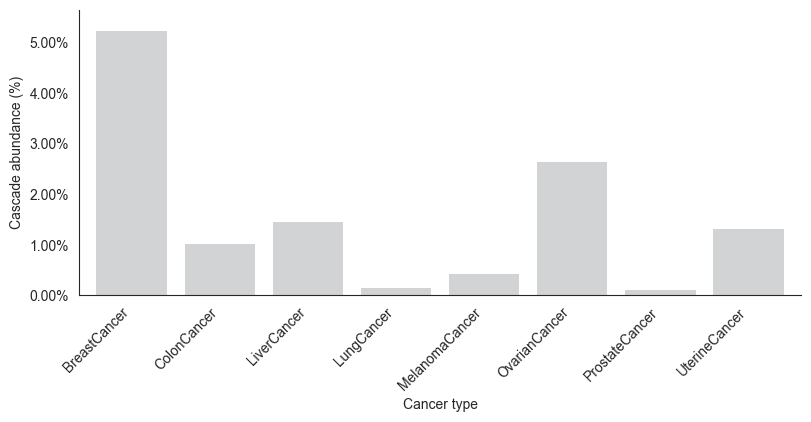

Saved:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\CascadeAbundance_percent_cancercell-Fibroblast-cancercell_MI-7_MI-4_all_cancertypes.pdf
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Insitu_High_order_MI_AllCancerTypes\CascadeAbundance_percent_cancercell-Fibroblast-cancercell_MI-7_MI-4_all_cancertypes.svg


In [19]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ---------------------------
# Vector-compatible fonts and plot styling
# ---------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# ---------------------------
# User settings
# ---------------------------
ONLY_SIGNIFICANT_CANCERTYPES = False

BAR_FILL_COLOR = "#d1d3d4"

# CancerType_order = [
#     "ColonCancer", "OvarianCancer", "LungCancer", "ProstateCancer",
#     "UterineCancer", "BreastCancer", "LiverCancer", "MelanomaCancer"
# ]
CancerType_order = [
    "BreastCancer", "ColonCancer", "LiverCancer", "LungCancer",
    "MelanomaCancer", "OvarianCancer", "ProstateCancer", "UterineCancer"
]

# ---------------------------
# Build plotting dataframe
# ---------------------------
plot_df = cascade_count_summary_df.copy()

if ONLY_SIGNIFICANT_CANCERTYPES:
    plot_df = plot_df.loc[
        plot_df["Is_significant_in_this_cancertype"] == True
    ].copy()

sum_df_match_insitu = (
    plot_df
    .groupby("CancerType", as_index=False)[
        ["ObservedCascadeCount", "PotentialCascadeCount"]
    ]
    .sum()
)

sum_df_match_insitu["CancerType"] = pd.Categorical(
    sum_df_match_insitu["CancerType"],
    categories=CancerType_order,
    ordered=True
)

sum_df_match_insitu = (
    pd.DataFrame({"CancerType": CancerType_order})
    .merge(sum_df_match_insitu, on="CancerType", how="left")
)

sum_df_match_insitu["ObservedCascadeCount"] = (
    sum_df_match_insitu["ObservedCascadeCount"].fillna(0).astype(int)
)

sum_df_match_insitu["PotentialCascadeCount"] = (
    sum_df_match_insitu["PotentialCascadeCount"].fillna(0).astype(int)
)

sum_df_match_insitu["CascadeAbundance"] = np.where(
    sum_df_match_insitu["PotentialCascadeCount"] > 0,
    sum_df_match_insitu["ObservedCascadeCount"] / sum_df_match_insitu["PotentialCascadeCount"] * 100.0,
    0.0
)

display(sum_df_match_insitu)

# ---------------------------
# Barplot
# ---------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))

x = np.arange(len(sum_df_match_insitu))
y = sum_df_match_insitu["CascadeAbundance"].to_numpy(dtype=float)

ax.bar(
    x,
    y,
    color=BAR_FILL_COLOR,
    edgecolor="none",
    linewidth=0,
)

ax.set_xlabel("Cancer type")
ax.set_ylabel("Cascade abundance (%)")

ax.set_xlim(-0.6, len(x) - 0.4)

ymax = y.max()
if ymax == 0:
    ax.set_ylim(0, 1)
else:
    ax.set_ylim(0, ymax * 1.08)

ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:.2f}%"))

ax.set_xticks(x)
ax.set_xticklabels(
    sum_df_match_insitu["CancerType"],
    rotation=45,
    ha="right",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(x=0.00, y=0.00)

fig.subplots_adjust(
    left=0.14,
    right=0.99,
    bottom=0.30,
    top=0.98,
)

# ---------------------------
# Save for Illustrator
# ---------------------------
outdir = Path(file_savepath_main) / "Insitu_High_order_MI_AllCancerTypes"
outdir.mkdir(parents=True, exist_ok=True)

suffix = "_significant_only" if ONLY_SIGNIFICANT_CANCERTYPES else "_all_cancertypes"

pdf_path = outdir / (
    f"CascadeAbundance_percent_{safe_filename(celltype_triple_of_interest)}"
    f"_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}{suffix}.pdf"
)

svg_path = outdir / (
    f"CascadeAbundance_percent_{safe_filename(celltype_triple_of_interest)}"
    f"_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}{suffix}.svg"
)

fig.savefig(pdf_path, format="pdf")
fig.savefig(svg_path, format="svg")

plt.show()

print("Saved:")
print(pdf_path)
print(svg_path)

## 8. Upstream-gated tumor-fibroblast-tumor feature analysis

Within each cancer type, compare spatial `tumor -> fibroblast -> tumor` triplets with upstream **MI-7 >= 0.30** against those with **MI-7 < 0.001**. The downstream edge is required to be a spatial neighbor; its MI-4 strength is measured as a feature. The fixed-threshold configuration excludes intermediate upstream strengths.

Negative triplets sharing selected edge roles or any cell position with positive triplets are removed. Measured downstream edges, intermediate fibroblasts, and receiver tumor cells are deduplicated within sample and group.

Features are downstream MI-4 strength, COLLAGEN LR coexpression, the fibroblast CAF module score, and tumor Invasion, Angiogenesis, and Hypoxia scores. Module scores average gene-wise z-scores using the reference selected by `MODULE_SCORE_METHOD` (currently pooled within cancer type and cell type).

Group comparisons use two-sided Mann-Whitney U tests and BH adjustment across feature/cancer-type combinations, separately for individual cells or edges and for sub-slice means. The sample-level tests are unpaired. Optional rank-based grouping and pooled-across-cancer normalization remain available in the settings.


In [20]:
# ==============================================================
# Upstream-gated pancancer cascade settings and helper functions
# --------------------------------------------------------------
# Group 1: cancer cell --(MI-7 high + spatial neighbor)--> Fibroblast
#          Fibroblast --(spatial neighbor only)--> cancer cell
# Group 2: cancer cell --(MI-7 low  + spatial neighbor)--> Fibroblast
#          Fibroblast --(spatial neighbor only)--> cancer cell
#
# Downstream MI-4 is measured as a feature, not used for grouping.
# ==============================================================

import os
import re
import math
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

try:
    import torch
except ImportError:
    torch = None

# -----------------------------
# User-editable parameters
# -----------------------------
MI_first_of_interest = 7      # upstream cancer cell -> Fibroblast gate
MI_second_of_interest = 4     # downstream Fibroblast -> cancer cell feature
celltype_triple_of_interest = "cancercell -> Fibroblast -> cancercell"

MI_first_index = int(MI_first_of_interest) - 1
MI_second_index = int(MI_second_of_interest) - 1

# Upstream grouping convention.
#
# "fixed_threshold" selects high = MI-up >= MI_UP_THRESHOLD_HIGH and
# low = MI-up < MI_UP_THRESHOLD_LOW; intermediate strengths are excluded.
# The optional "per_cancertype_rank_quantile" mode instead partitions candidate
# tumor -> fibroblast edges by within-cancer-type rank, splitting ties in input order.
MI_UP_GROUPING_MODE = "fixed_threshold"

MI_UP_LOW_QUANTILE = 0.50
MI_UP_HIGH_QUANTILE = 0.50
MI_UP_MIN_CANDIDATE_EDGES_PER_CANCERTYPE = 2

# Used only when MI_UP_GROUPING_MODE == "fixed_threshold".
MI_UP_THRESHOLD_LOW = 1e-3
MI_UP_THRESHOLD_HIGH = 0.30

GROUP_UP_POS = "MIup_interacting"
GROUP_UP_NEG = "MIup_not_interacting"
UPSTREAM_GATED_GROUPS = (GROUP_UP_POS, GROUP_UP_NEG)

PRETTY_GROUP_LABELS_UPSTREAM_GATED = {
    GROUP_UP_POS: "MI-7+\nneighbor",
    GROUP_UP_NEG: "MI-7-\nneighbor",
}

GROUP_COLORS_UPSTREAM_GATED = {
    GROUP_UP_POS: "#3d91ce",
    GROUP_UP_NEG: "#c7ddec",
}

# Remove negative triplets that reuse the same upstream/downstream edge or cells as the positive group.
EXCLUDE_MIUP_NEG_OVERLAP_WITH_POS = True
EXCLUDE_OVERLAP_EDGE_ROLES = ("upstream", "downstream")
EXCLUDE_OVERLAP_CELL_POSITIONS = (0, 1, 2)

# Deduplicate measured units within each group/sample.
# Edge-level features use unique downstream Fibroblast->cancer edges.
# Tumor module scores use unique receiver cancer cells.
DEDUPLICATE_UNITS_WITHIN_GROUP = True

# Module-score convention.
# Choose ONE of the following two options. The same setting is used by all
# module-score computations in this notebook, including:
#   - Fibroblast CAF module score
#   - CancerSEA tumor program scores
#   - reference GO/KEGG gene-set module scores
#
# zscore_mean_global_all_cancertypes:
#   z-score genes using a pooled reference across all samples/cancer types for
#   the matched cell type label, then average selected genes per cell.
#
# zscore_mean_global_per_cancertype:
#   z-score genes using a cancer-type-specific pooled reference for the matched
#   cell type label, then average selected genes per cell. This mainly affects
#   shared cell types such as Fibroblast; cancer-cell labels are usually already
#   cancer-type-specific.
MODULE_SCORE_METHOD = "zscore_mean_global_per_cancertype"

ALLOWED_MODULE_SCORE_METHODS = {
    "zscore_mean_global_all_cancertypes",
    "zscore_mean_global_per_cancertype",
}
if MODULE_SCORE_METHOD not in ALLOWED_MODULE_SCORE_METHODS:
    raise ValueError(
        f"Unknown MODULE_SCORE_METHOD={MODULE_SCORE_METHOD!r}. "
        f"Allowed values are: {sorted(ALLOWED_MODULE_SCORE_METHODS)}"
    )

# Downstream pathway and tumor programs to score.
DOWNSTREAM_PATHWAY_NAME = "COLLAGEN"
CANCERSEA_FEATURES_OF_INTEREST = ["Invasion", "Angiogenesis", "Hypoxia"]

# Output directory.
# Include MODULE_SCORE_METHOD in the output directory/suffix so results from the
# two normalization modes are not accidentally overwritten or mixed.
output_dir = (
    Path(file_savepath_main)
    / "UpstreamGated_MI7_to_MI4_cancerFibroCancer"
    / MODULE_SCORE_METHOD
)
output_dir.mkdir(parents=True, exist_ok=True)

cascade_output_suffix = (
    f"UpstreamGated_MI{MI_first_of_interest}_MI{MI_second_of_interest}_"
    f"cancercell-Fibroblast-cancercell_"
    f"{MODULE_SCORE_METHOD}"
)

# -----------------------------
# General helpers
# -----------------------------
def _to_numpy(x):
    if sparse.issparse(x):
        return x.toarray()
    if torch is not None and torch.is_tensor(x):
        return x.detach().cpu().numpy()
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "cpu") and hasattr(x, "numpy"):
        return x.cpu().numpy()
    return np.asarray(x)


def _get_edge_index_numpy(spdata):
    edge_index = spdata.edge_index
    return _to_numpy(edge_index).astype(np.int64, copy=False)


def _get_sample_id_from_adata(adata, sample_index):
    if "SampleID" in adata.obs.columns:
        vals = pd.Series(adata.obs["SampleID"]).dropna().astype(str).unique()
        if len(vals) > 0:
            return str(vals[0])
    return f"sample_{sample_index}"


def resolve_triple_for_cancertype(celltype_triple, cancer_type):
    cancer_cell_label = cancer_type_to_cancercell_label(cancer_type)
    parts = [x.strip() for x in str(celltype_triple).split("->")]
    if len(parts) != 3:
        raise ValueError("celltype_triple_of_interest must have exactly 3 parts.")
    return [cancer_cell_label if p.lower() == "cancercell" else p for p in parts]


def _get_sampleindex_to_cancertype():
    if "sampleindex_to_cancertype" in globals():
        return {int(k): str(v) for k, v in sampleindex_to_cancertype.items()}

    out = {}
    if "cancertype_to_sample_indices" in globals():
        for ct, idxs in cancertype_to_sample_indices.items():
            for si in idxs:
                out[int(si)] = str(ct)
    elif "sample_metadata_df" in globals() and {"sample_index", "CancerType"}.issubset(sample_metadata_df.columns):
        out = dict(zip(sample_metadata_df["sample_index"].astype(int), sample_metadata_df["CancerType"].astype(str)))
    else:
        for si, adata in enumerate(adata_list):
            sid = _get_sample_id_from_adata(adata, si)
            out[int(si)] = str(sid).split("_")[0]
    return out


sampleindex_to_cancertype = _get_sampleindex_to_cancertype()

if "cancertype_list" in globals():
    CancerType_order = [str(x) for x in cancertype_list]
elif "sample_metadata_df" in globals() and "CancerType" in sample_metadata_df.columns:
    CancerType_order = sample_metadata_df["CancerType"].drop_duplicates().astype(str).tolist()
else:
    CancerType_order = sorted(pd.unique(pd.Series(sampleindex_to_cancertype).astype(str)))

if "cancertype_to_sample_indices" not in globals():
    cancertype_to_sample_indices = {}
    for si, ct in sampleindex_to_cancertype.items():
        cancertype_to_sample_indices.setdefault(str(ct), []).append(int(si))


def _p_to_star(p):
    if pd.isna(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def _compare_two_groups(x, y, paired=False, alternative="two-sided"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    try:
        if paired:
            n = min(len(x), len(y))
            if n == 0:
                return np.nan
            return float(wilcoxon(x[:n], y[:n], alternative=alternative).pvalue)
        return float(mannwhitneyu(x, y, alternative=alternative).pvalue)
    except Exception:
        return np.nan


# Plot style: Illustrator-friendly PDF.
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

print("Upstream-gated pancancer cascade analysis")
print(f"  Template: {celltype_triple_of_interest}")
if MI_UP_GROUPING_MODE == "fixed_threshold":
    print(f"  Upstream gate: fixed threshold; MI-{MI_first_of_interest} >= {MI_UP_THRESHOLD_HIGH} vs < {MI_UP_THRESHOLD_LOW}")
else:
    print(
        f"  Upstream gate: {MI_UP_GROUPING_MODE}; "
        f"low<=Q{MI_UP_LOW_QUANTILE:.2f}, high>=Q{MI_UP_HIGH_QUANTILE:.2f} within each cancer type"
    )
print(f"  Downstream edge: spatial neighbor only; MI-{MI_second_of_interest} is measured as a feature")
print(f"  Module-score method: {MODULE_SCORE_METHOD}")
print(f"  Output dir: {output_dir}")
print("Cancer types:", CancerType_order)

Upstream-gated pancancer cascade analysis
  Template: cancercell -> Fibroblast -> cancercell
  Upstream gate: fixed threshold; MI-7 >= 0.3 vs < 0.001
  Downstream edge: spatial neighbor only; MI-4 is measured as a feature
  Module-score method: zscore_mean_global_per_cancertype
  Output dir: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype
Cancer types: ['BreastCancer', 'ColonCancer', 'LiverCancer', 'LungCancer', 'MelanomaCancer', 'OvarianCancer', 'ProstateCancer', 'UterineCancer']


In [21]:

# ==============================================================
# Load downstream COLLAGEN LR pairs, Fibroblast CAF module, and CancerSEA gene sets
# --------------------------------------------------------------
# CancerSEA marker files are tab-separated .txt tables with a GeneName column.
# Set cancerSEA_path to select their directory; the loader includes a default.
# ============================================================== 

# -----------------------------
# LR metadata and COLLAGEN LR-pair indices
# -----------------------------
def _load_lr_meta():
    if "LR_meta" in globals():
        return LR_meta.copy()

    candidates = [
        Path(file_savepath_main) / "LR_meta_incellchatdb.csv",
        Path(str(file_savepath_main) + "LR_meta_incellchatdb.csv"),
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    raise FileNotFoundError("Cannot find LR_meta_incellchatdb.csv. Please check file_savepath_main.")


LR_meta = _load_lr_meta()
if "pathway_name" not in LR_meta.columns:
    raise KeyError("LR_meta must contain a 'pathway_name' column.")

collagen_lr_indices = np.where(
    LR_meta["pathway_name"].astype(str).eq(DOWNSTREAM_PATHWAY_NAME)
)[0].astype(int)

if len(collagen_lr_indices) == 0:
    raise ValueError(f"No LR pairs found for pathway_name == {DOWNSTREAM_PATHWAY_NAME!r}.")

print(f"Number of {DOWNSTREAM_PATHWAY_NAME} LR pairs:", len(collagen_lr_indices))

# -----------------------------
# Shared gene universe and case-insensitive gene matching
# -----------------------------
def _gene_universe_from_adata_list():
    genes = []
    for adata in adata_list:
        genes.extend([str(g) for g in adata.var_names])
    return pd.Index(pd.unique(pd.Series(genes).astype(str)))


gene_universe = _gene_universe_from_adata_list()

# Intersect gene sets with any loading matrices already present in the kernel;
# otherwise use the AnnData gene universe. Subsequent matching is case-insensitive
# and preserves AnnData gene-symbol spelling.
def _available_gene_universe_for_gene_sets():
    universe_sets = [set(gene_universe.astype(str))]

    if "loading_receiver_use_df_norm" in globals():
        universe_sets.append(set(pd.Index(loading_receiver_use_df_norm.columns).astype(str)))
    if "loading_sender_use_df_norm" in globals():
        universe_sets.append(set(pd.Index(loading_sender_use_df_norm.columns).astype(str)))
    if "loading_receiver_use_df" in globals():
        universe_sets.append(set(pd.Index(loading_receiver_use_df.columns).astype(str)))
    if "loading_sender_use_df" in globals():
        universe_sets.append(set(pd.Index(loading_sender_use_df.columns).astype(str)))

    # Intersect in a case-sensitive way first, mirroring the set intersection in
    # Pancancer_analysis; the downstream helper then maps case-insensitively.
    common = set.intersection(*universe_sets) if len(universe_sets) > 1 else universe_sets[0]
    return pd.Index(sorted(common))


_gene_set_universe = _available_gene_universe_for_gene_sets()
_upper_to_actual_gene = {}
for g in gene_universe.astype(str):
    _upper_to_actual_gene.setdefault(str(g).upper(), str(g))


def _intersect_genes_with_panel(genes):
    out = []
    seen = set()
    allowed_upper = set(str(g).upper() for g in _gene_set_universe.astype(str))

    for g in genes:
        key = str(g).strip().upper()
        if key in allowed_upper and key in _upper_to_actual_gene and key not in seen:
            out.append(_upper_to_actual_gene[key])
            seen.add(key)
    return out


def _gene_indices_from_symbols(genes, var_names):
    var_names = pd.Index(var_names.astype(str))
    upper_to_idx = {str(g).upper(): i for i, g in enumerate(var_names)}
    used_genes = []
    used_indices = []
    seen = set()

    for g in genes:
        key = str(g).strip().upper()
        if key in upper_to_idx and key not in seen:
            idx = int(upper_to_idx[key])
            used_indices.append(idx)
            used_genes.append(str(var_names[idx]))
            seen.add(key)

    return np.asarray(used_indices, dtype=int), used_genes

# -----------------------------
# Fibroblast CAF module genes scored on the intermediate Fibroblast cell
# -----------------------------
# CAF marker modules used for intermediate fibroblast scoring.
caf_modules = {
    "myCAF": ["ACTA2", "TAGLN", "MYL9", "TPM2", "CNN1", "CALD1", "COL1A1", "COL1A2"],
    "iCAF": ["IL6", "CXCL12", "CXCL14", "LIF", "CCL2", "PTGS2"],
    "apCAF": ["HLA-DRA", "HLA-DRB1", "CD74", "CIITA"],
    "meCAF": ["COL11A1", "THBS2", "MMP11", "ITGA11", "FN1", "VCAN", "SPARC", "SULF1", "LOX", "PLOD2"],
    "periCAF": ["RGS5", "PDGFRB", "MCAM", "NOTCH3", "TAGLN"],
    "prolCAF": ["MKI67", "TOP2A", "PCNA"],
}

caf_all_markers = sorted(set(g for genes in caf_modules.values() for g in genes))
selected_fibroblast_gene_sets = {
    "Fibroblast CAF module score": _intersect_genes_with_panel(caf_all_markers)
}

# -----------------------------
# CancerSEA gene sets, read as in Pancancer_analysis
# -----------------------------
def _load_cancersea_gene_sets_like_pancancer_analysis():
    # Read CancerSEA GeneName tables from the configured marker directory.
    if "cancerSEA_path" in globals():
        cancersea_dir = Path(cancerSEA_path)
    else:
        cancersea_dir = SPIDERNET_ROOT / "Data/Pancancer/CancerSEA_marker"

    if not cancersea_dir.exists():
        raise FileNotFoundError(
            f"Cannot find CancerSEA marker directory: {cancersea_dir}. "
            "Set cancerSEA_path to the directory used in Pancancer_analysis."
        )

    cancerSEA_files = [f for f in os.listdir(cancersea_dir) if str(f).endswith(".txt")]
    if len(cancerSEA_files) == 0:
        raise FileNotFoundError(f"No .txt files found in CancerSEA marker directory: {cancersea_dir}")

    cancerSEA_gene_sets = {}
    for file in cancerSEA_files:
        gene_set_name = str(file).replace(".txt", "")
        gene_set_df = pd.read_csv(cancersea_dir / file, sep="\t", header=0)

        if "GeneName" not in gene_set_df.columns:
            raise KeyError(
                f"CancerSEA file {file} does not contain a GeneName column. "
                f"Available columns: {list(gene_set_df.columns)}"
            )

        gene_set_cur = gene_set_df["GeneName"].dropna().astype(str).tolist()
        gene_set_cur = _intersect_genes_with_panel(gene_set_cur)
        cancerSEA_gene_sets[gene_set_name] = sorted(gene_set_cur)

    print(f"Loaded CancerSEA gene sets from: {cancersea_dir}")
    print("Number of genes in each CancerSEA gene set after panel intersection:")
    for gene_set_name, gene_set_cur in cancerSEA_gene_sets.items():
        print(f"  {gene_set_name}: {len(gene_set_cur)} genes")

    return cancerSEA_gene_sets


cancerSEA_gene_sets = _load_cancersea_gene_sets_like_pancancer_analysis()


def _get_named_gene_set(gene_sets, name):
    lookup = {str(k).strip().lower(): k for k in gene_sets.keys()}
    key = lookup.get(str(name).strip().lower(), None)
    if key is None:
        available = sorted([str(k) for k in gene_sets.keys()])
        raise KeyError(f"Cannot find CancerSEA gene set {name!r}. Available gene sets: {available}")
    return list(gene_sets[key])


selected_tumor_gene_sets = {}
for feature in CANCERSEA_FEATURES_OF_INTEREST:
    genes = _get_named_gene_set(cancerSEA_gene_sets, feature)
    selected_tumor_gene_sets[feature] = genes

# Save gene-set summary so the exact genes used are auditable.
gene_set_summary = []
for category, gene_sets in [
    ("Fibroblast_CAF", selected_fibroblast_gene_sets),
    ("Tumor_CancerSEA", selected_tumor_gene_sets),
]:
    for name, genes in gene_sets.items():
        gene_set_summary.append({
            "category": category,
            "program": name,
            "n_genes_overlap_with_data": int(len(genes)),
            "genes_used": ", ".join(genes),
        })

gene_set_summary_df = pd.DataFrame(gene_set_summary)
gene_set_summary_path = output_dir / f"{cascade_output_suffix}_gene_sets_used.csv"
gene_set_summary_df.to_csv(gene_set_summary_path, index=False)

print("Selected module gene sets:")
display(gene_set_summary_df[["category", "program", "n_genes_overlap_with_data"]])
print(f"Saved gene-set summary: {gene_set_summary_path}")

# -----------------------------
# Matrix helpers for LR and expression scoring
# -----------------------------
def _slice_matrix_rows_cols(matrix, row_indices, col_indices):
    row_indices = np.asarray(row_indices, dtype=np.int64)
    col_indices = np.asarray(col_indices, dtype=np.int64)

    if len(row_indices) == 0 or len(col_indices) == 0:
        return np.empty((len(row_indices), len(col_indices)), dtype=np.float32)

    if torch is not None and torch.is_tensor(matrix):
        device = matrix.device
        row_t = torch.as_tensor(row_indices, dtype=torch.long, device=device)
        col_t = torch.as_tensor(col_indices, dtype=torch.long, device=device)
        sub = matrix.index_select(0, row_t).index_select(1, col_t)
        return sub.detach().cpu().numpy().astype(np.float32, copy=False)

    sub = matrix[row_indices, :][:, col_indices]
    if sparse.issparse(sub):
        sub = sub.toarray()
    else:
        sub = np.asarray(sub)
    return sub.astype(np.float32, copy=False)


def _compute_selected_lr_global_max(lr_indices, chunk_size=50000):
    lr_indices = np.asarray(lr_indices, dtype=int)
    max_vals = np.zeros(len(lr_indices), dtype=np.float32)

    for si, spdata in enumerate(SpiderNet_data_pyg_list):
        lr_mat = spdata["cellpair_LRpair_neigh"]
        n_rows = int(lr_mat.shape[0])
        for start in range(0, n_rows, chunk_size):
            rows = np.arange(start, min(start + chunk_size, n_rows), dtype=np.int64)
            sub = _slice_matrix_rows_cols(lr_mat, rows, lr_indices)
            if sub.size > 0:
                max_vals = np.maximum(max_vals, np.nanmax(sub, axis=0))
            del sub
    return np.maximum(max_vals, 1e-8)


collagen_lr_global_max = _compute_selected_lr_global_max(collagen_lr_indices)
print("Computed selected COLLAGEN LR global max.")


def _mean_normalized_lr_per_edge(spdata, edge_ids, lr_indices, lr_global_max, chunk_size=50000):
    edge_ids = np.asarray(edge_ids, dtype=np.int64)
    lr_indices = np.asarray(lr_indices, dtype=np.int64)
    if len(edge_ids) == 0 or len(lr_indices) == 0:
        return np.asarray([], dtype=np.float32)

    out = []
    lr_mat = spdata["cellpair_LRpair_neigh"]
    denom = np.maximum(np.asarray(lr_global_max, dtype=np.float32), 1e-8)

    for start in range(0, len(edge_ids), chunk_size):
        rows = edge_ids[start:start + chunk_size]
        sub = _slice_matrix_rows_cols(lr_mat, rows, lr_indices)
        vals = (sub / denom[None, :]).mean(axis=1)
        out.append(vals.astype(np.float32, copy=False))
        del sub, vals

    return np.concatenate(out) if out else np.asarray([], dtype=np.float32)


def _get_expression_matrix(adata):
    return adata.X


def _expression_rows_cols_to_numpy(adata, cell_indices, gene_indices):
    cell_indices = np.asarray(cell_indices, dtype=np.int64)
    gene_indices = np.asarray(gene_indices, dtype=np.int64)
    if len(cell_indices) == 0 or len(gene_indices) == 0:
        return np.empty((len(cell_indices), len(gene_indices)), dtype=np.float32)
    X = _get_expression_matrix(adata)
    sub = X[cell_indices, :][:, gene_indices]
    if sparse.issparse(sub):
        sub = sub.toarray()
    else:
        sub = np.asarray(sub)
    return sub.astype(np.float32, copy=False)


_global_z_cache = {}

def _normalize_gene_indices_for_cache(gene_indices):
    return tuple(int(x) for x in np.asarray(gene_indices, dtype=int))


def _finalize_mean_std_from_sums(sum_vec, sumsq_vec, n_total, n_genes, context_label):
    if n_total == 0:
        print(
            f"Warning: no reference cells found for {context_label}; "
            f"using mean=0,std=1."
        )
        mean = np.zeros(n_genes, dtype=np.float32)
        std = np.ones(n_genes, dtype=np.float32)
    else:
        mean64 = sum_vec / n_total
        var64 = (sumsq_vec / n_total) - mean64 ** 2
        mean = mean64.astype(np.float32)
        std = np.sqrt(np.maximum(var64, 1e-8)).astype(np.float32)
        std = np.where(np.isfinite(std) & (std > 1e-6), std, 1.0).astype(np.float32)

    return mean, std, int(n_total)


def _accumulate_gene_stats_for_sample_cells(adata_ref, ref_cells, gene_indices, chunk_size=20000):
    """Return sum, sumsq, and n for selected cells/genes in one AnnData object."""
    ref_cells = np.asarray(ref_cells, dtype=np.int64)
    gene_indices = np.asarray(gene_indices, dtype=np.int64)

    sum_vec = np.zeros(len(gene_indices), dtype=np.float64)
    sumsq_vec = np.zeros(len(gene_indices), dtype=np.float64)
    n_total = 0

    if len(ref_cells) == 0 or len(gene_indices) == 0:
        return sum_vec, sumsq_vec, n_total

    for start in range(0, len(ref_cells), int(chunk_size)):
        rows = ref_cells[start:start + int(chunk_size)]
        sub = _expression_rows_cols_to_numpy(adata_ref, rows, gene_indices)
        if sub.size == 0:
            continue
        sum_vec += np.nansum(sub, axis=0)
        sumsq_vec += np.nansum(sub ** 2, axis=0)
        n_total += int(sub.shape[0])
        del sub

    return sum_vec, sumsq_vec, n_total


def _get_global_allcancertypes_gene_stats(cell_type_label, gene_indices, chunk_size=20000):
    """Compute gene-wise mean/std pooled across all samples/cancer types.

    Reference definition:
      - Select cells whose `celltype_final` equals `cell_type_label`.
      - Pool such cells across all samples.
      - Compute gene-wise mean/std on the requested genes.

    This is used when:
      MODULE_SCORE_METHOD == "zscore_mean_global_all_cancertypes"
    """
    gene_indices = _normalize_gene_indices_for_cache(gene_indices)
    cache_key = ("zscore_mean_global_all_cancertypes", str(cell_type_label), gene_indices)

    if cache_key in _global_z_cache:
        return _global_z_cache[cache_key]

    if len(gene_indices) == 0:
        mean = np.asarray([], dtype=np.float32)
        std = np.asarray([], dtype=np.float32)
        _global_z_cache[cache_key] = (mean, std, 0)
        return mean, std, 0

    sum_vec = np.zeros(len(gene_indices), dtype=np.float64)
    sumsq_vec = np.zeros(len(gene_indices), dtype=np.float64)
    n_total = 0

    for si, adata_ref in enumerate(adata_list):
        if "celltype_final" not in adata_ref.obs.columns:
            raise KeyError(f"adata_list[{si}].obs must contain 'celltype_final'.")

        cell_types_ref = adata_ref.obs["celltype_final"].astype(str).to_numpy()
        ref_cells = np.where(cell_types_ref == str(cell_type_label))[0].astype(np.int64)

        s, ss, n = _accumulate_gene_stats_for_sample_cells(
            adata_ref=adata_ref,
            ref_cells=ref_cells,
            gene_indices=gene_indices,
            chunk_size=chunk_size,
        )
        sum_vec += s
        sumsq_vec += ss
        n_total += n

    mean, std, n_total = _finalize_mean_std_from_sums(
        sum_vec=sum_vec,
        sumsq_vec=sumsq_vec,
        n_total=n_total,
        n_genes=len(gene_indices),
        context_label=f"all-cancer-type reference, cell_type={cell_type_label}",
    )

    _global_z_cache[cache_key] = (mean, std, int(n_total))
    return mean, std, int(n_total)


def _sample_indices_for_cancer_type(cancer_type):
    cancer_type = str(cancer_type)

    if "cancertype_to_sample_indices" in globals():
        if cancer_type in cancertype_to_sample_indices:
            return [int(x) for x in cancertype_to_sample_indices[cancer_type]]

    if "sampleindex_to_cancertype" in globals():
        return [
            int(si)
            for si, ct in sampleindex_to_cancertype.items()
            if str(ct) == cancer_type
        ]

    # Conservative fallback: scan all samples by inferred cancer type.
    out = []
    for si, adata_ref in enumerate(adata_list):
        inferred = None
        if "CancerType" in adata_ref.obs.columns:
            vals = pd.Series(adata_ref.obs["CancerType"]).dropna().astype(str).unique()
            if len(vals) > 0:
                inferred = str(vals[0])
        if inferred is None:
            sid = _get_sample_id_from_adata(adata_ref, si)
            inferred = str(sid).split("_")[0]
        if str(inferred) == cancer_type:
            out.append(int(si))
    return out


def _get_global_per_cancertype_gene_stats(cancer_type, cell_type_label, gene_indices, chunk_size=20000):
    """Compute gene-wise mean/std within one cancer type.

    Reference definition:
      - First restrict to samples belonging to `cancer_type`.
      - Within those samples, select cells whose `celltype_final` equals
        `cell_type_label`.
      - Compute gene-wise mean/std on the requested genes.

    This is used when:
      MODULE_SCORE_METHOD == "zscore_mean_global_per_cancertype"
    """
    gene_indices = _normalize_gene_indices_for_cache(gene_indices)
    cache_key = (
        "zscore_mean_global_per_cancertype",
        str(cancer_type),
        str(cell_type_label),
        gene_indices,
    )

    if cache_key in _global_z_cache:
        return _global_z_cache[cache_key]

    if len(gene_indices) == 0:
        mean = np.asarray([], dtype=np.float32)
        std = np.asarray([], dtype=np.float32)
        _global_z_cache[cache_key] = (mean, std, 0)
        return mean, std, 0

    sample_indices = _sample_indices_for_cancer_type(cancer_type)

    sum_vec = np.zeros(len(gene_indices), dtype=np.float64)
    sumsq_vec = np.zeros(len(gene_indices), dtype=np.float64)
    n_total = 0

    for si in sample_indices:
        adata_ref = adata_list[int(si)]
        if "celltype_final" not in adata_ref.obs.columns:
            raise KeyError(f"adata_list[{si}].obs must contain 'celltype_final'.")

        cell_types_ref = adata_ref.obs["celltype_final"].astype(str).to_numpy()
        ref_cells = np.where(cell_types_ref == str(cell_type_label))[0].astype(np.int64)

        s, ss, n = _accumulate_gene_stats_for_sample_cells(
            adata_ref=adata_ref,
            ref_cells=ref_cells,
            gene_indices=gene_indices,
            chunk_size=chunk_size,
        )
        sum_vec += s
        sumsq_vec += ss
        n_total += n

    mean, std, n_total = _finalize_mean_std_from_sums(
        sum_vec=sum_vec,
        sumsq_vec=sumsq_vec,
        n_total=n_total,
        n_genes=len(gene_indices),
        context_label=f"per-cancer-type reference, cancer_type={cancer_type}, cell_type={cell_type_label}",
    )

    _global_z_cache[cache_key] = (mean, std, int(n_total))
    return mean, std, int(n_total)


def _get_global_cancertype_gene_stats(cancer_type, cancer_cell_label, gene_indices, chunk_size=20000):
    """Dispatch gene-wise z-score reference stats according to MODULE_SCORE_METHOD.

    The notebook-level `MODULE_SCORE_METHOD` selects the reference population:

      - zscore_mean_global_all_cancertypes:
          pooled reference across all samples for the matched cell type label.

      - zscore_mean_global_per_cancertype:
          cancer-type-specific pooled reference for the matched cell type label.
    """
    if "MODULE_SCORE_METHOD" not in globals():
        raise NameError(
            "MODULE_SCORE_METHOD is not defined. Run the upstream-gated settings cell first."
        )

    if MODULE_SCORE_METHOD == "zscore_mean_global_all_cancertypes":
        return _get_global_allcancertypes_gene_stats(
            cell_type_label=cancer_cell_label,
            gene_indices=gene_indices,
            chunk_size=chunk_size,
        )

    if MODULE_SCORE_METHOD == "zscore_mean_global_per_cancertype":
        return _get_global_per_cancertype_gene_stats(
            cancer_type=cancer_type,
            cell_type_label=cancer_cell_label,
            gene_indices=gene_indices,
            chunk_size=chunk_size,
        )

    raise ValueError(
        f"Unknown MODULE_SCORE_METHOD={MODULE_SCORE_METHOD!r}. "
        "Use 'zscore_mean_global_all_cancertypes' or 'zscore_mean_global_per_cancertype'."
    )


def _module_score_zscore_global_by_cancertype(adata, cell_indices, genes, cancer_type, cancer_cell_label):
    """Module score controlled by MODULE_SCORE_METHOD.

    Steps:
      1. Match genes to the AnnData panel.
      2. Get gene-wise mean/std according to MODULE_SCORE_METHOD.
      3. Z-score selected cells gene-wise.
      4. Return the mean z-score across module genes per cell.

    The normalization reference is controlled by `MODULE_SCORE_METHOD`.
    """
    gene_indices, used_genes = _gene_indices_from_symbols(genes, adata.var_names)
    cell_indices = np.asarray(cell_indices, dtype=np.int64)

    if len(cell_indices) == 0 or len(gene_indices) == 0:
        return np.asarray([], dtype=np.float32), used_genes, 0

    mean, std, n_ref = _get_global_cancertype_gene_stats(
        cancer_type=cancer_type,
        cancer_cell_label=cancer_cell_label,
        gene_indices=gene_indices,
    )
    mean = np.asarray(mean, dtype=np.float32)
    std = np.asarray(std, dtype=np.float32)
    std = np.where(np.isfinite(std) & (std > 1e-6), std, 1.0).astype(np.float32)

    X = _expression_rows_cols_to_numpy(adata, cell_indices, gene_indices)
    X = np.asarray(X, dtype=np.float32)
    scores = ((X - mean[None, :]) / std[None, :]).mean(axis=1)
    return scores.astype(np.float32, copy=False), used_genes, n_ref


Number of COLLAGEN LR pairs: 6
Loaded CancerSEA gene sets from: D:\SpiderNet\Data\Pancancer\CancerSEA_marker
Number of genes in each CancerSEA gene set after panel intersection:
  Angiogenesis: 23 genes
  Apoptosis: 4 genes
  Cell_Cycle: 6 genes
  Differentiation: 40 genes
  DNA_damage: 18 genes
  DNA_repair: 5 genes
  EMT: 18 genes
  Hypoxia: 18 genes
  Inflammation: 39 genes
  Invasion: 15 genes
  Metastasis: 68 genes
  Proliferation: 30 genes
  Quiescence: 14 genes
  Stemness: 30 genes
Selected module gene sets:


,category,program,n_genes_overlap_with_data
0,Fibroblast_CAF,Fibroblast CAF module score,17
1,Tumor_CancerSEA,Invasion,15
2,Tumor_CancerSEA,Angiogenesis,23
3,Tumor_CancerSEA,Hypoxia,18


Saved gene-set summary: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_cancercell-Fibroblast-cancercell_zscore_mean_global_per_cancertype_gene_sets_used.csv
Computed selected COLLAGEN LR global max.


In [22]:

# ==============================================================
# Extract upstream-gated triplets and compute downstream features
# ============================================================== 

triplet_records = []
feature_records = []
edge_state_records = []
overlap_exclusion_records = []


def _extract_upstream_gated_triplets(A, edge_index, cell_types, up_condition, ct1, ct2, ct3):
    """Return triplets and corresponding edge12/edge23 ids.

    edge12 must be ct1->ct2 and satisfy up_condition.
    edge23 must be ct2->ct3 and is only required to be a spatial neighbor.
    """
    edge_sender_ct = cell_types[edge_index[:, 0]]
    edge_receiver_ct = cell_types[edge_index[:, 1]]

    edge12_mask = (
        np.asarray(up_condition, dtype=bool)
        & (edge_sender_ct == str(ct1))
        & (edge_receiver_ct == str(ct2))
    )
    edge23_mask = (
        (edge_sender_ct == str(ct2))
        & (edge_receiver_ct == str(ct3))
    )

    r1 = np.where(edge12_mask)[0].astype(np.int64)
    r2 = np.where(edge23_mask)[0].astype(np.int64)

    if len(r1) == 0 or len(r2) == 0:
        return (
            np.empty((0, 3), dtype=np.int64),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    A_sub = A[r1, :][:, r2]
    rows, cols = A_sub.nonzero()
    if len(rows) == 0:
        return (
            np.empty((0, 3), dtype=np.int64),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    edge12_ids = r1[rows].astype(np.int64)
    edge23_ids = r2[cols].astype(np.int64)
    triplets = np.column_stack([
        edge_index[edge12_ids, 0],
        edge_index[edge12_ids, 1],
        edge_index[edge23_ids, 1],
    ]).astype(np.int64)

    return triplets, edge12_ids, edge23_ids


def _filter_negative_against_positive(neg_payload, pos_payload):
    if not EXCLUDE_MIUP_NEG_OVERLAP_WITH_POS:
        return neg_payload, {
            "n_negative_triplets_before_overlap_exclusion": int(len(neg_payload["triplets"])),
            "n_negative_triplets_after_overlap_exclusion": int(len(neg_payload["triplets"])),
            "n_negative_triplets_removed_any_overlap": 0,
            "overlap_exclusion_fraction": 0.0,
        }

    neg_triplets = np.asarray(neg_payload["triplets"], dtype=np.int64)
    neg_edge12 = np.asarray(neg_payload["edge12_ids"], dtype=np.int64)
    neg_edge23 = np.asarray(neg_payload["edge23_ids"], dtype=np.int64)

    pos_triplets = np.asarray(pos_payload["triplets"], dtype=np.int64)
    pos_edge12 = np.asarray(pos_payload["edge12_ids"], dtype=np.int64)
    pos_edge23 = np.asarray(pos_payload["edge23_ids"], dtype=np.int64)

    if len(neg_triplets) == 0 or len(pos_triplets) == 0:
        return neg_payload, {
            "n_negative_triplets_before_overlap_exclusion": int(len(neg_triplets)),
            "n_negative_triplets_after_overlap_exclusion": int(len(neg_triplets)),
            "n_negative_triplets_removed_any_overlap": 0,
            "overlap_exclusion_fraction": 0.0,
        }

    pos_edges = set()
    if "upstream" in EXCLUDE_OVERLAP_EDGE_ROLES:
        pos_edges.update(int(x) for x in pos_edge12)
    if "downstream" in EXCLUDE_OVERLAP_EDGE_ROLES:
        pos_edges.update(int(x) for x in pos_edge23)

    pos_cells = set()
    for pos_i in EXCLUDE_OVERLAP_CELL_POSITIONS:
        pos_cells.update(int(x) for x in pos_triplets[:, int(pos_i)])

    keep = np.ones(len(neg_triplets), dtype=bool)
    removed_edge_overlap = np.zeros(len(neg_triplets), dtype=bool)
    removed_cell_overlap = np.zeros(len(neg_triplets), dtype=bool)

    for i in range(len(neg_triplets)):
        edge_overlap = False
        if "upstream" in EXCLUDE_OVERLAP_EDGE_ROLES and int(neg_edge12[i]) in pos_edges:
            edge_overlap = True
        if "downstream" in EXCLUDE_OVERLAP_EDGE_ROLES and int(neg_edge23[i]) in pos_edges:
            edge_overlap = True

        cell_overlap = any(int(neg_triplets[i, int(pos_i)]) in pos_cells for pos_i in EXCLUDE_OVERLAP_CELL_POSITIONS)

        removed_edge_overlap[i] = edge_overlap
        removed_cell_overlap[i] = cell_overlap
        if edge_overlap or cell_overlap:
            keep[i] = False

    filtered_payload = {
        "triplets": neg_triplets[keep],
        "edge12_ids": neg_edge12[keep],
        "edge23_ids": neg_edge23[keep],
    }

    n_before = int(len(neg_triplets))
    n_removed = int(np.sum(~keep))
    record = {
        "n_negative_triplets_before_overlap_exclusion": n_before,
        "n_negative_triplets_after_overlap_exclusion": int(len(filtered_payload["triplets"])),
        "n_negative_triplets_removed_edge_overlap": int(np.sum(removed_edge_overlap & ~keep)),
        "n_negative_triplets_removed_cell_overlap": int(np.sum(removed_cell_overlap & ~keep)),
        "n_negative_triplets_removed_any_overlap": n_removed,
        "overlap_exclusion_fraction": float(n_removed / n_before) if n_before > 0 else 0.0,
    }
    return filtered_payload, record


# ------------------------------------------------------------------
# Cancer-type-specific upstream MI high/low grouping
# ------------------------------------------------------------------
def _candidate_upstream_edge_mask(edge_index, cell_types, ct1, ct2):
    edge_sender_ct = cell_types[edge_index[:, 0]]
    edge_receiver_ct = cell_types[edge_index[:, 1]]
    return (edge_sender_ct == ct1) & (edge_receiver_ct == ct2)


def _rank_split_candidate_edges(values, low_q=0.50, high_q=0.50):
    """Return boolean low/high masks for a 1D vector using non-overlapping ranks.

    This is intentionally rank-based rather than strict value-threshold based, so
    cancer types with many tied MI values still get explicit high/low groups.
    """
    values = np.asarray(values, dtype=float)
    n = int(values.shape[0])
    low_mask = np.zeros(n, dtype=bool)
    high_mask = np.zeros(n, dtype=bool)

    finite = np.isfinite(values)
    finite_idx = np.where(finite)[0]
    n_finite = int(len(finite_idx))
    if n_finite < 2:
        return low_mask, high_mask

    low_q = float(low_q)
    high_q = float(high_q)
    if not (0 < low_q <= 1 and 0 <= high_q < 1):
        raise ValueError("MI_UP_LOW_QUANTILE must be in (0, 1]; MI_UP_HIGH_QUANTILE must be in [0, 1).")
    if low_q > high_q:
        raise ValueError("MI_UP_LOW_QUANTILE must be <= MI_UP_HIGH_QUANTILE for non-overlapping groups.")

    # Stable ordering. Ties are split by original order to ensure high/low groups
    # exist even when many values are equal.
    order = finite_idx[np.argsort(values[finite_idx], kind="mergesort")]

    n_low = int(np.floor(n_finite * low_q))
    high_start = int(np.ceil(n_finite * high_q))

    # Keep both groups non-empty and non-overlapping whenever possible.
    n_low = max(1, min(n_low, n_finite - 1))
    high_start = max(n_low, min(high_start, n_finite - 1))

    low_idx = order[:n_low]
    high_idx = order[high_start:]

    if len(high_idx) == 0 and n_finite >= 2:
        high_idx = order[-1:]
        low_idx = order[:-1]

    low_mask[low_idx] = True
    high_mask[high_idx] = True
    return low_mask, high_mask


def _precompute_per_cancertype_upstream_edge_groups():
    """Precompute per-sample upstream high/low edge IDs using cancer-type-specific ranks."""
    assignment = {}
    summary_records = []

    if MI_UP_GROUPING_MODE != "per_cancertype_rank_quantile":
        return assignment, pd.DataFrame(summary_records)

    per_ct_rows = []

    for sample_index, adata in enumerate(adata_list):
        sample_name = _get_sample_id_from_adata(adata, sample_index)
        cancer_type = str(sampleindex_to_cancertype.get(int(sample_index), sample_name.split("_")[0]))
        ct1_sample, ct2_sample, _ = resolve_triple_for_cancertype(
            celltype_triple_of_interest,
            cancer_type,
        )

        F = np.asarray(Factor_envir_norm_list[sample_index], dtype=float)
        spdata = SpiderNet_data_pyg_list[sample_index]
        edge_index = _get_edge_index_numpy(spdata)
        cell_types = adata.obs["celltype_final"].astype(str).to_numpy()
        up_strength = F[:, MI_first_index]

        candidate_mask = _candidate_upstream_edge_mask(edge_index, cell_types, ct1_sample, ct2_sample)
        candidate_edge_ids = np.where(candidate_mask)[0].astype(np.int64)
        candidate_values = up_strength[candidate_edge_ids]

        for edge_id, val in zip(candidate_edge_ids, candidate_values):
            per_ct_rows.append({
                "CancerType": cancer_type,
                "sample_index": int(sample_index),
                "sample_name": sample_name,
                "edge_id": int(edge_id),
                "MI_up_strength": float(val),
            })

        del F, spdata, edge_index, cell_types
        gc.collect()

    candidate_df = pd.DataFrame(per_ct_rows)
    if candidate_df.empty:
        return assignment, pd.DataFrame(summary_records)

    for cancer_type, sub in candidate_df.groupby("CancerType", observed=True, sort=False):
        sub = sub.reset_index(drop=True)
        vals = sub["MI_up_strength"].to_numpy(dtype=float)

        if len(sub) < int(MI_UP_MIN_CANDIDATE_EDGES_PER_CANCERTYPE):
            summary_records.append({
                "CancerType": cancer_type,
                "MI_up_grouping_mode": MI_UP_GROUPING_MODE,
                "n_candidate_upstream_edges": int(len(sub)),
                "n_low_edges": 0,
                "n_high_edges": 0,
                "low_quantile": float(MI_UP_LOW_QUANTILE),
                "high_quantile": float(MI_UP_HIGH_QUANTILE),
            })
            continue

        low_mask, high_mask = _rank_split_candidate_edges(
            vals,
            low_q=MI_UP_LOW_QUANTILE,
            high_q=MI_UP_HIGH_QUANTILE,
        )

        sub_low = sub.loc[low_mask]
        sub_high = sub.loc[high_mask]

        for sample_index, ss in sub_low.groupby("sample_index", observed=True):
            rec = assignment.setdefault(int(sample_index), {"low": set(), "high": set()})
            rec["low"].update(int(x) for x in ss["edge_id"].to_numpy())

        for sample_index, ss in sub_high.groupby("sample_index", observed=True):
            rec = assignment.setdefault(int(sample_index), {"low": set(), "high": set()})
            rec["high"].update(int(x) for x in ss["edge_id"].to_numpy())

        summary_records.append({
            "CancerType": cancer_type,
            "MI_up_grouping_mode": MI_UP_GROUPING_MODE,
            "n_candidate_upstream_edges": int(len(sub)),
            "n_low_edges": int(low_mask.sum()),
            "n_high_edges": int(high_mask.sum()),
            "low_quantile": float(MI_UP_LOW_QUANTILE),
            "high_quantile": float(MI_UP_HIGH_QUANTILE),
            "low_max_MI_up_strength": float(np.nanmax(vals[low_mask])) if low_mask.any() else np.nan,
            "high_min_MI_up_strength": float(np.nanmin(vals[high_mask])) if high_mask.any() else np.nan,
        })

    return assignment, pd.DataFrame(summary_records)


def _get_upstream_group_conditions_for_sample(sample_index, up_strength):
    up_strength = np.asarray(up_strength, dtype=float)
    if MI_UP_GROUPING_MODE == "fixed_threshold":
        return up_strength >= MI_UP_THRESHOLD_HIGH, up_strength < MI_UP_THRESHOLD_LOW

    if MI_UP_GROUPING_MODE == "per_cancertype_rank_quantile":
        cond_up_pos = np.zeros(len(up_strength), dtype=bool)
        cond_up_neg = np.zeros(len(up_strength), dtype=bool)
        rec = upstream_edge_group_assignment_by_sample.get(int(sample_index), {"low": set(), "high": set()})
        high_ids = np.asarray(sorted(rec.get("high", set())), dtype=np.int64)
        low_ids = np.asarray(sorted(rec.get("low", set())), dtype=np.int64)
        high_ids = high_ids[(high_ids >= 0) & (high_ids < len(up_strength))]
        low_ids = low_ids[(low_ids >= 0) & (low_ids < len(up_strength))]
        cond_up_pos[high_ids] = True
        cond_up_neg[low_ids] = True
        return cond_up_pos, cond_up_neg

    raise ValueError(f"Unknown MI_UP_GROUPING_MODE={MI_UP_GROUPING_MODE!r}")


upstream_edge_group_assignment_by_sample, upstream_edge_grouping_summary_df = _precompute_per_cancertype_upstream_edge_groups()
if not upstream_edge_grouping_summary_df.empty:
    upstream_grouping_summary_path = output_dir / f"{cascade_output_suffix}_upstream_MI_grouping_summary.csv"
    upstream_edge_grouping_summary_df.to_csv(upstream_grouping_summary_path, index=False)
    print(f"Saved upstream MI grouping summary: {upstream_grouping_summary_path}")
    display(upstream_edge_grouping_summary_df)


for sample_index, adata in enumerate(adata_list):
    if sample_index % 5 == 0:
        print(f"Processing sample {sample_index + 1}/{len(adata_list)}...")

    sample_name = _get_sample_id_from_adata(adata, sample_index)
    cancer_type = str(sampleindex_to_cancertype.get(int(sample_index), sample_name.split("_")[0]))
    ct1_sample, ct2_sample, ct3_sample = resolve_triple_for_cancertype(
        celltype_triple_of_interest,
        cancer_type,
    )

    F = np.asarray(Factor_envir_norm_list[sample_index], dtype=float)
    A = hyper_edge_adj_list[sample_index]
    spdata = SpiderNet_data_pyg_list[sample_index]
    edge_index = _get_edge_index_numpy(spdata)
    cell_types = adata.obs["celltype_final"].astype(str).to_numpy()

    n_edges = int(edge_index.shape[0])
    up_strength = F[:, MI_first_index]
    down_strength = F[:, MI_second_index]

    cond_up_pos, cond_up_neg = _get_upstream_group_conditions_for_sample(sample_index, up_strength)

    pos_triplets, pos_edge12, pos_edge23 = _extract_upstream_gated_triplets(
        A=A,
        edge_index=edge_index,
        cell_types=cell_types,
        up_condition=cond_up_pos,
        ct1=ct1_sample,
        ct2=ct2_sample,
        ct3=ct3_sample,
    )
    neg_triplets, neg_edge12, neg_edge23 = _extract_upstream_gated_triplets(
        A=A,
        edge_index=edge_index,
        cell_types=cell_types,
        up_condition=cond_up_neg,
        ct1=ct1_sample,
        ct2=ct2_sample,
        ct3=ct3_sample,
    )

    group_payloads = {
        GROUP_UP_POS: {"triplets": pos_triplets, "edge12_ids": pos_edge12, "edge23_ids": pos_edge23},
        GROUP_UP_NEG: {"triplets": neg_triplets, "edge12_ids": neg_edge12, "edge23_ids": neg_edge23},
    }

    group_payloads[GROUP_UP_NEG], overlap_record = _filter_negative_against_positive(
        neg_payload=group_payloads[GROUP_UP_NEG],
        pos_payload=group_payloads[GROUP_UP_POS],
    )
    overlap_record.update({
        "sample_index": int(sample_index),
        "sample_name": sample_name,
        "CancerType": cancer_type,
        "n_positive_triplets_reference": int(len(group_payloads[GROUP_UP_POS]["triplets"])),
        "exclude_overlap_edge_roles": ",".join(EXCLUDE_OVERLAP_EDGE_ROLES),
        "exclude_overlap_cell_positions": ",".join(str(x) for x in EXCLUDE_OVERLAP_CELL_POSITIONS),
    })
    overlap_exclusion_records.append(overlap_record)

    edge_state_records.append({
        "sample_index": int(sample_index),
        "sample_name": sample_name,
        "CancerType": cancer_type,
        "ct1": ct1_sample,
        "ct2": ct2_sample,
        "ct3": ct3_sample,
        "n_edges_total": n_edges,
        "MI_up_grouping_mode": MI_UP_GROUPING_MODE,
        "MI_up_low_quantile": float(MI_UP_LOW_QUANTILE) if MI_UP_GROUPING_MODE != "fixed_threshold" else np.nan,
        "MI_up_high_quantile": float(MI_UP_HIGH_QUANTILE) if MI_UP_GROUPING_MODE != "fixed_threshold" else np.nan,
        "MI_up_threshold_low": float(MI_UP_THRESHOLD_LOW) if MI_UP_GROUPING_MODE == "fixed_threshold" else np.nan,
        "MI_up_threshold_high": float(MI_UP_THRESHOLD_HIGH) if MI_UP_GROUPING_MODE == "fixed_threshold" else np.nan,
        "n_up_pos_edges_all_types": int(np.sum(cond_up_pos)),
        "n_up_neg_edges_all_types": int(np.sum(cond_up_neg)),
        "n_pos_triplets_before_negative_overlap_filter": int(len(pos_triplets)),
        "n_neg_triplets_before_overlap_filter": int(len(neg_triplets)),
        "n_neg_triplets_after_overlap_filter": int(len(group_payloads[GROUP_UP_NEG]["triplets"])),
    })

    for group in UPSTREAM_GATED_GROUPS:
        payload = group_payloads[group]
        triplets = np.asarray(payload["triplets"], dtype=np.int64)
        edge12_ids = np.asarray(payload["edge12_ids"], dtype=np.int64)
        edge23_ids = np.asarray(payload["edge23_ids"], dtype=np.int64)

        if len(triplets) == 0:
            continue

        mi_up_values = up_strength[edge12_ids]
        mi_down_values = down_strength[edge23_ids]

        # Triplet-level table.
        for local_i, (trip, e12, e23, up_val, down_val) in enumerate(
            zip(triplets, edge12_ids, edge23_ids, mi_up_values, mi_down_values)
        ):
            c1, c2, c3 = [int(x) for x in trip]
            triplet_records.append({
                "sample_index": int(sample_index),
                "sample_name": sample_name,
                "CancerType": cancer_type,
                "group": group,
                "triplet_local_index": int(local_i),
                "cell1": c1,
                "cell2": c2,
                "cell3": c3,
                "cell1_id": str(adata.obs_names[c1]),
                "cell2_id": str(adata.obs_names[c2]),
                "cell3_id": str(adata.obs_names[c3]),
                "cell1_type": str(cell_types[c1]),
                "cell2_type": str(cell_types[c2]),
                "cell3_type": str(cell_types[c3]),
                "edge12_id": int(e12),
                "edge23_id": int(e23),
                "MI_up_strength": float(up_val),
                "MI_down_strength": float(down_val),
            })

        # Edge-level features: unique downstream Fibroblast -> cancer-cell edges.
        downstream_edge_ids = edge23_ids
        if DEDUPLICATE_UNITS_WITHIN_GROUP:
            downstream_edge_ids = np.unique(downstream_edge_ids)

        # (1) Downstream MI-4 strength.
        downstream_mi_values = down_strength[downstream_edge_ids]
        for edge_id, val in zip(downstream_edge_ids, downstream_mi_values):
            feature_records.append({
                "sample_index": int(sample_index),
                "sample_name": sample_name,
                "CancerType": cancer_type,
                "group": group,
                "feature_category": "Downstream MI strength",
                "feature": f"MI-{MI_second_of_interest} downstream strength",
                "value": float(val),
                "unit_type": "edge",
                "unit_id": f"{sample_index}:edge:{int(edge_id)}",
                "edge_role": "downstream",
                "edge_id": int(edge_id),
            })

        # (2) Downstream COLLAGEN LR coexpression.
        collagen_lr_values = _mean_normalized_lr_per_edge(
            spdata=spdata,
            edge_ids=downstream_edge_ids,
            lr_indices=collagen_lr_indices,
            lr_global_max=collagen_lr_global_max,
        )
        for edge_id, val in zip(downstream_edge_ids, collagen_lr_values):
            feature_records.append({
                "sample_index": int(sample_index),
                "sample_name": sample_name,
                "CancerType": cancer_type,
                "group": group,
                "feature_category": "Downstream LR coexpression",
                "feature": "COLLAGEN downstream LR coexpression",
                "value": float(val),
                "unit_type": "edge",
                "unit_id": f"{sample_index}:edge:{int(edge_id)}",
                "edge_role": "downstream",
                "edge_id": int(edge_id),
                "pathway_name": DOWNSTREAM_PATHWAY_NAME,
                "n_lr_pairs_used": int(len(collagen_lr_indices)),
            })

        # Cell-level feature: unique intermediate Fibroblast cells.
        intermediate_fibroblast_cells = triplets[:, 1].astype(np.int64)
        if DEDUPLICATE_UNITS_WITHIN_GROUP:
            intermediate_fibroblast_cells = np.unique(intermediate_fibroblast_cells)

        for program_name, genes in selected_fibroblast_gene_sets.items():
            scores, used_genes, n_ref = _module_score_zscore_global_by_cancertype(
                adata=adata,
                cell_indices=intermediate_fibroblast_cells,
                genes=genes,
                cancer_type=cancer_type,
                cancer_cell_label=ct2_sample,
            )
            for node_id, val in zip(intermediate_fibroblast_cells, scores):
                feature_records.append({
                    "sample_index": int(sample_index),
                    "sample_name": sample_name,
                    "CancerType": cancer_type,
                    "group": group,
                    "feature_category": "Fibroblast module score",
                    "feature": program_name,
                    "value": float(val),
                    "unit_type": "cell",
                    "unit_id": f"{sample_index}:cell:{int(node_id)}",
                    "cell_position": 1,
                    "cell_index": int(node_id),
                    "cell_id": str(adata.obs_names[int(node_id)]),
                    "cell_type": str(cell_types[int(node_id)]),
                    "score_method": MODULE_SCORE_METHOD,
                    "n_genes_used": int(len(used_genes)),
                    "n_reference_fibroblast_cells": int(n_ref),
                })

        # Cell-level features: unique receiver cancer cells.
        receiver_cancer_cells = triplets[:, 2].astype(np.int64)
        if DEDUPLICATE_UNITS_WITHIN_GROUP:
            receiver_cancer_cells = np.unique(receiver_cancer_cells)

        for program_name, genes in selected_tumor_gene_sets.items():
            scores, used_genes, n_ref = _module_score_zscore_global_by_cancertype(
                adata=adata,
                cell_indices=receiver_cancer_cells,
                genes=genes,
                cancer_type=cancer_type,
                cancer_cell_label=ct3_sample,
            )
            for node_id, val in zip(receiver_cancer_cells, scores):
                feature_records.append({
                    "sample_index": int(sample_index),
                    "sample_name": sample_name,
                    "CancerType": cancer_type,
                    "group": group,
                    "feature_category": "Tumor module score",
                    "feature": program_name,
                    "value": float(val),
                    "unit_type": "cell",
                    "unit_id": f"{sample_index}:cell:{int(node_id)}",
                    "cell_position": 2,
                    "cell_index": int(node_id),
                    "cell_id": str(adata.obs_names[int(node_id)]),
                    "cell_type": str(cell_types[int(node_id)]),
                    "score_method": MODULE_SCORE_METHOD,
                    "n_genes_used": int(len(used_genes)),
                    "n_reference_cancer_cells": int(n_ref),
                })

    del F, A, spdata, edge_index, cell_types
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()


triplet_table_upstream_gated = pd.DataFrame(triplet_records)
feature_records_upstream_gated = pd.DataFrame(feature_records)
edge_state_summary_upstream_gated = pd.DataFrame(edge_state_records)
overlap_exclusion_summary_upstream_gated = pd.DataFrame(overlap_exclusion_records)

# Save core outputs.
triplet_table_path = output_dir / f"{cascade_output_suffix}_triplet_table.csv"
feature_records_path = output_dir / f"{cascade_output_suffix}_single_unit_feature_records.csv"
edge_state_summary_path = output_dir / f"{cascade_output_suffix}_edge_state_summary.csv"
overlap_summary_path = output_dir / f"{cascade_output_suffix}_overlap_exclusion_summary.csv"

triplet_table_upstream_gated.to_csv(triplet_table_path, index=False)
feature_records_upstream_gated.to_csv(feature_records_path, index=False)
edge_state_summary_upstream_gated.to_csv(edge_state_summary_path, index=False)
overlap_exclusion_summary_upstream_gated.to_csv(overlap_summary_path, index=False)

print(f"Saved triplet table: {triplet_table_path}")
print(f"Saved single-unit feature records: {feature_records_path}")
print(f"Saved edge-state summary: {edge_state_summary_path}")
print(f"Saved overlap-exclusion summary: {overlap_summary_path}")

print("\nFeature-record counts:")
if feature_records_upstream_gated.empty:
    print("No feature records were generated. Check thresholds and cell-type labels.")
else:
    display(
        feature_records_upstream_gated
        .groupby(["CancerType", "feature_category", "feature", "group"], observed=True)
        .size()
        .rename("n_units")
        .reset_index()
    )


Processing sample 1/160...
Processing sample 6/160...
Processing sample 11/160...
Processing sample 16/160...
Processing sample 21/160...
Processing sample 26/160...
Processing sample 31/160...
Processing sample 36/160...
Processing sample 41/160...
Processing sample 46/160...
Processing sample 51/160...
Processing sample 56/160...
Processing sample 61/160...
Processing sample 66/160...
Processing sample 71/160...
Processing sample 76/160...
Processing sample 81/160...
Processing sample 86/160...
Processing sample 91/160...
Processing sample 96/160...
Processing sample 101/160...
Processing sample 106/160...
Processing sample 111/160...
Processing sample 116/160...
Processing sample 121/160...
Processing sample 126/160...
Processing sample 131/160...
Processing sample 136/160...
Processing sample 141/160...
Processing sample 146/160...
Processing sample 151/160...
Processing sample 156/160...
Saved triplet table: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI

,CancerType,feature_category,feature,group,n_units
0,BreastCancer,Downstream LR coexpression,COLLAGEN downstream LR coexpression,MIup_interacting,87667
1,BreastCancer,Downstream LR coexpression,COLLAGEN downstream LR coexpression,MIup_not_interacting,93702
2,BreastCancer,Downstream MI strength,MI-4 downstream strength,MIup_interacting,87667
3,BreastCancer,Downstream MI strength,MI-4 downstream strength,MIup_not_interacting,93702
4,BreastCancer,Fibroblast module score,Fibroblast CAF module score,MIup_interacting,29502
...,...,...,...,...,...
91,UterineCancer,Tumor module score,Angiogenesis,MIup_not_interacting,84786
92,UterineCancer,Tumor module score,Hypoxia,MIup_interacting,13765
93,UterineCancer,Tumor module score,Hypoxia,MIup_not_interacting,84786
94,UterineCancer,Tumor module score,Invasion,MIup_interacting,13765


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_stats.csv
Saved single-unit feature × cancer-type statistics: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_stats.csv


,feature_category,feature,CancerType,level,test,n_MIup_interacting,n_MIup_not_interacting,mean_MIup_interacting,mean_MIup_not_interacting,median_MIup_interacting,median_MIup_not_interacting,mean_diff_MIup_interacting_minus_MIup_not_interacting,SMD,pvalue,pvalue_star,pvalue_adj_BH,pvalue_adj_BH_star
0,Downstream LR coexpression,COLLAGEN downstream LR coexpression,BreastCancer,single_unit,Mann-Whitney U,87667,93702,0.162925,0.073419,0.179141,0.079675,0.089506,0.869788,0.000000e+00,****,0.000000e+00,****
1,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ColonCancer,single_unit,Mann-Whitney U,6530,110107,0.227345,0.187161,0.207561,0.194158,0.040184,0.282313,1.698333e-118,****,7.410906e-118,****
2,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LiverCancer,single_unit,Mann-Whitney U,6984,77404,0.226412,0.217556,0.197548,0.189288,0.008856,0.058792,1.405202e-16,****,2.408918e-16,****
3,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LungCancer,single_unit,Mann-Whitney U,488,55752,0.174777,0.109024,0.197480,0.105681,0.065754,0.609648,1.185743e-38,****,2.845783e-38,****
4,Downstream LR coexpression,COLLAGEN downstream LR coexpression,MelanomaCancer,single_unit,Mann-Whitney U,1503,43582,0.116350,0.090013,0.107590,0.095338,0.026337,0.273401,1.673591e-23,****,3.347182e-23,****
5,Downstream LR coexpression,COLLAGEN downstream LR coexpression,OvarianCancer,single_unit,Mann-Whitney U,21120,54326,0.200297,0.149097,0.197693,0.171527,0.051200,0.442297,0.000000e+00,****,0.000000e+00,****
6,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ProstateCancer,single_unit,Mann-Whitney U,10451,383329,0.142999,0.114808,0.167853,0.096268,0.028191,0.243319,4.210434e-143,****,2.245565e-142,****
7,Downstream LR coexpression,COLLAGEN downstream LR coexpression,UterineCancer,single_unit,Mann-Whitney U,14483,96998,0.197445,0.187323,0.199065,0.191466,0.010122,0.090507,1.512582e-42,****,4.033552e-42,****
8,Downstream MI strength,MI-4 downstream strength,BreastCancer,single_unit,Mann-Whitney U,87667,93702,0.295266,0.139671,0.317784,0.069652,0.155595,0.928710,0.000000e+00,****,0.000000e+00,****
9,Downstream MI strength,MI-4 downstream strength,ColonCancer,single_unit,Mann-Whitney U,6530,110107,0.363463,0.310375,0.392128,0.348032,0.053087,0.264171,1.329837e-93,****,4.910169e-93,****


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_boxplots.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_boxplots.png


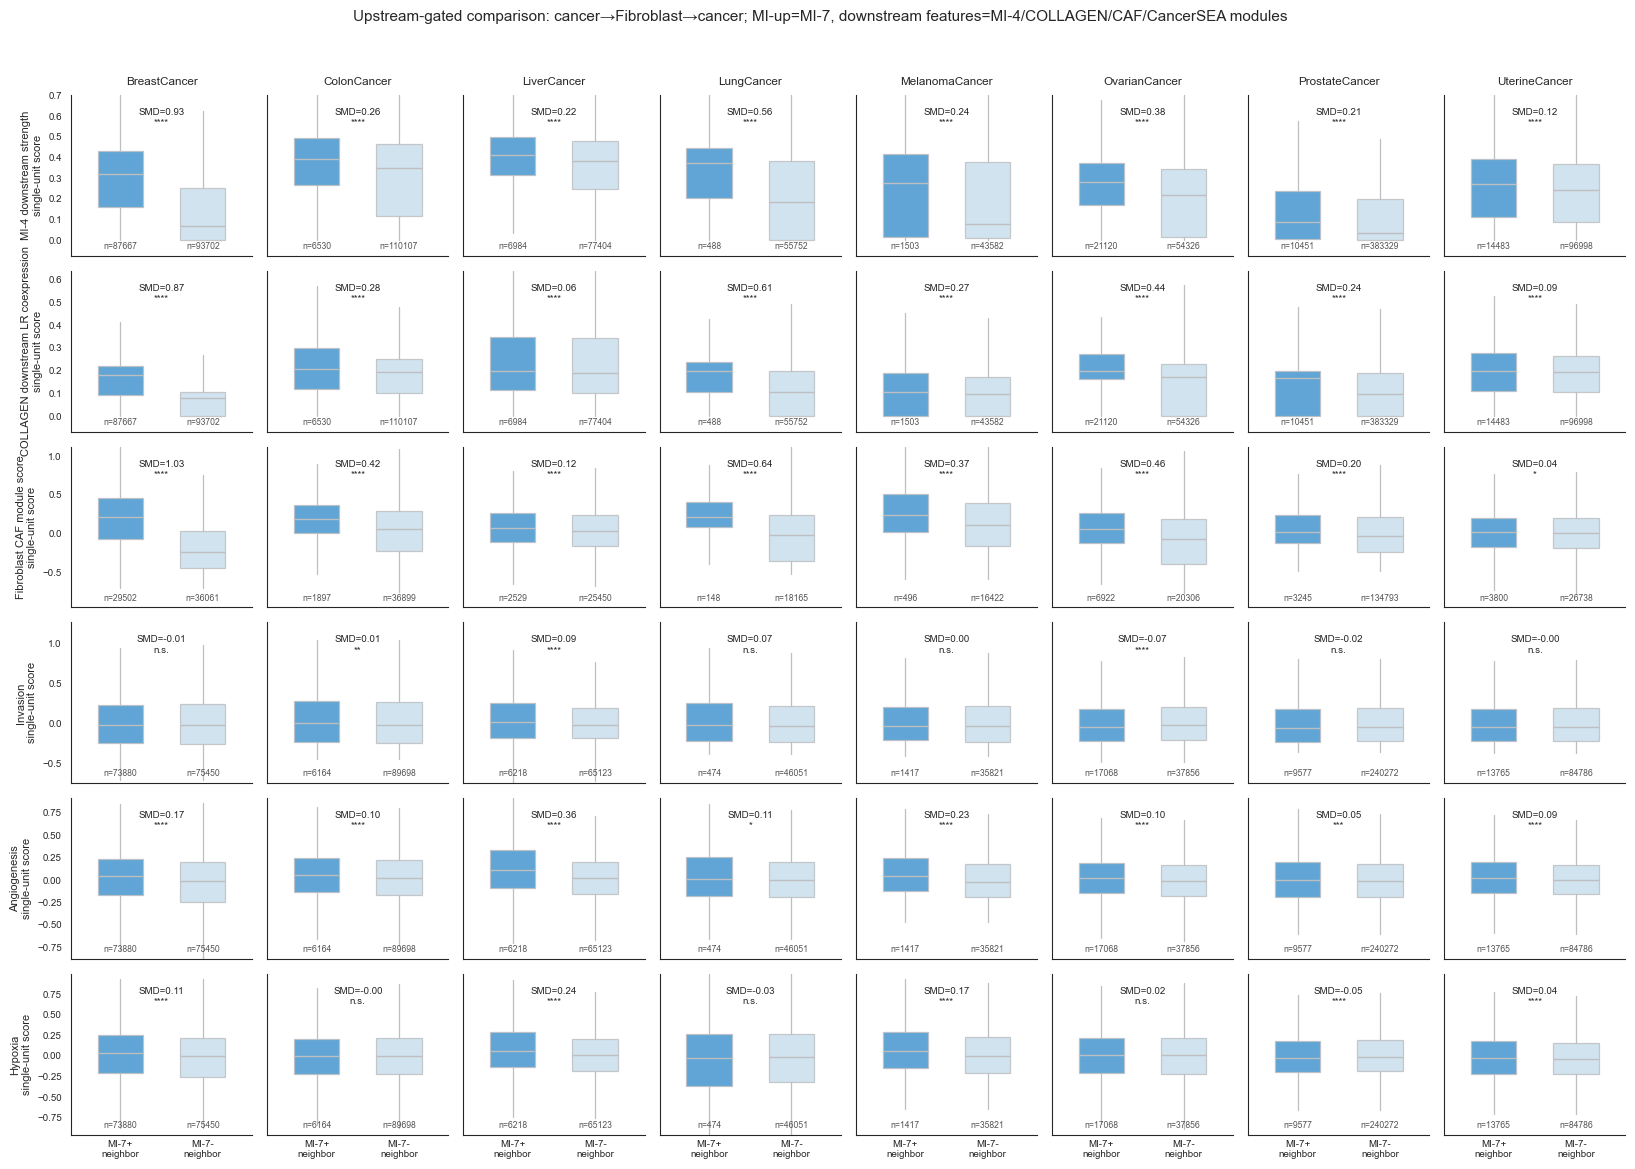

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_scores.csv
Saved sample-level feature scores: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_scores.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_stats.csv
Saved sample-level feature × cancer-type statistics: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_stats.csv


,feature_category,feature,CancerType,level,test,n_MIup_interacting,n_MIup_not_interacting,mean_MIup_interacting,mean_MIup_not_interacting,median_MIup_interacting,median_MIup_not_interacting,mean_diff_MIup_interacting_minus_MIup_not_interacting,SMD,pvalue,pvalue_star,pvalue_adj_BH,pvalue_adj_BH_star
0,Downstream LR coexpression,COLLAGEN downstream LR coexpression,BreastCancer,sample_level,Mann-Whitney U,20,20,0.163107,0.073740,0.163363,0.071820,0.089367,12.499907,6.795615e-08,****,3.261895e-07,****
1,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ColonCancer,sample_level,Mann-Whitney U,20,20,0.228239,0.187504,0.225339,0.186578,0.040734,3.128548,9.172773e-08,****,3.669109e-07,****
2,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LiverCancer,sample_level,Mann-Whitney U,20,20,0.225623,0.216833,0.227304,0.219345,0.008790,0.642251,4.112359e-02,*,5.334953e-02,n.s.
3,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LungCancer,sample_level,Mann-Whitney U,20,20,0.168272,0.110137,0.176249,0.109815,0.058135,1.671888,8.292417e-05,****,1.592144e-04,***
4,Downstream LR coexpression,COLLAGEN downstream LR coexpression,MelanomaCancer,sample_level,Mann-Whitney U,20,20,0.115764,0.090151,0.113392,0.090943,0.025612,1.770307,7.947948e-07,****,2.244126e-06,****
5,Downstream LR coexpression,COLLAGEN downstream LR coexpression,OvarianCancer,sample_level,Mann-Whitney U,20,20,0.200486,0.149434,0.200339,0.149248,0.051052,5.955366,6.795615e-08,****,3.261895e-07,****
6,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ProstateCancer,sample_level,Mann-Whitney U,20,20,0.143033,0.114588,0.141311,0.114751,0.028445,5.027692,6.795615e-08,****,3.261895e-07,****
7,Downstream LR coexpression,COLLAGEN downstream LR coexpression,UterineCancer,sample_level,Mann-Whitney U,20,20,0.198037,0.186981,0.200090,0.189972,0.011056,0.853036,1.480977e-03,**,2.293126e-03,**
8,Downstream MI strength,MI-4 downstream strength,BreastCancer,sample_level,Mann-Whitney U,20,20,0.295598,0.140455,0.296694,0.137328,0.155144,10.594841,6.795615e-08,****,3.261895e-07,****
9,Downstream MI strength,MI-4 downstream strength,ColonCancer,sample_level,Mann-Whitney U,20,20,0.359849,0.308855,0.363255,0.306995,0.050995,2.613479,7.947948e-07,****,2.244126e-06,****


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_boxplots.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\UpstreamGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_boxplots.png


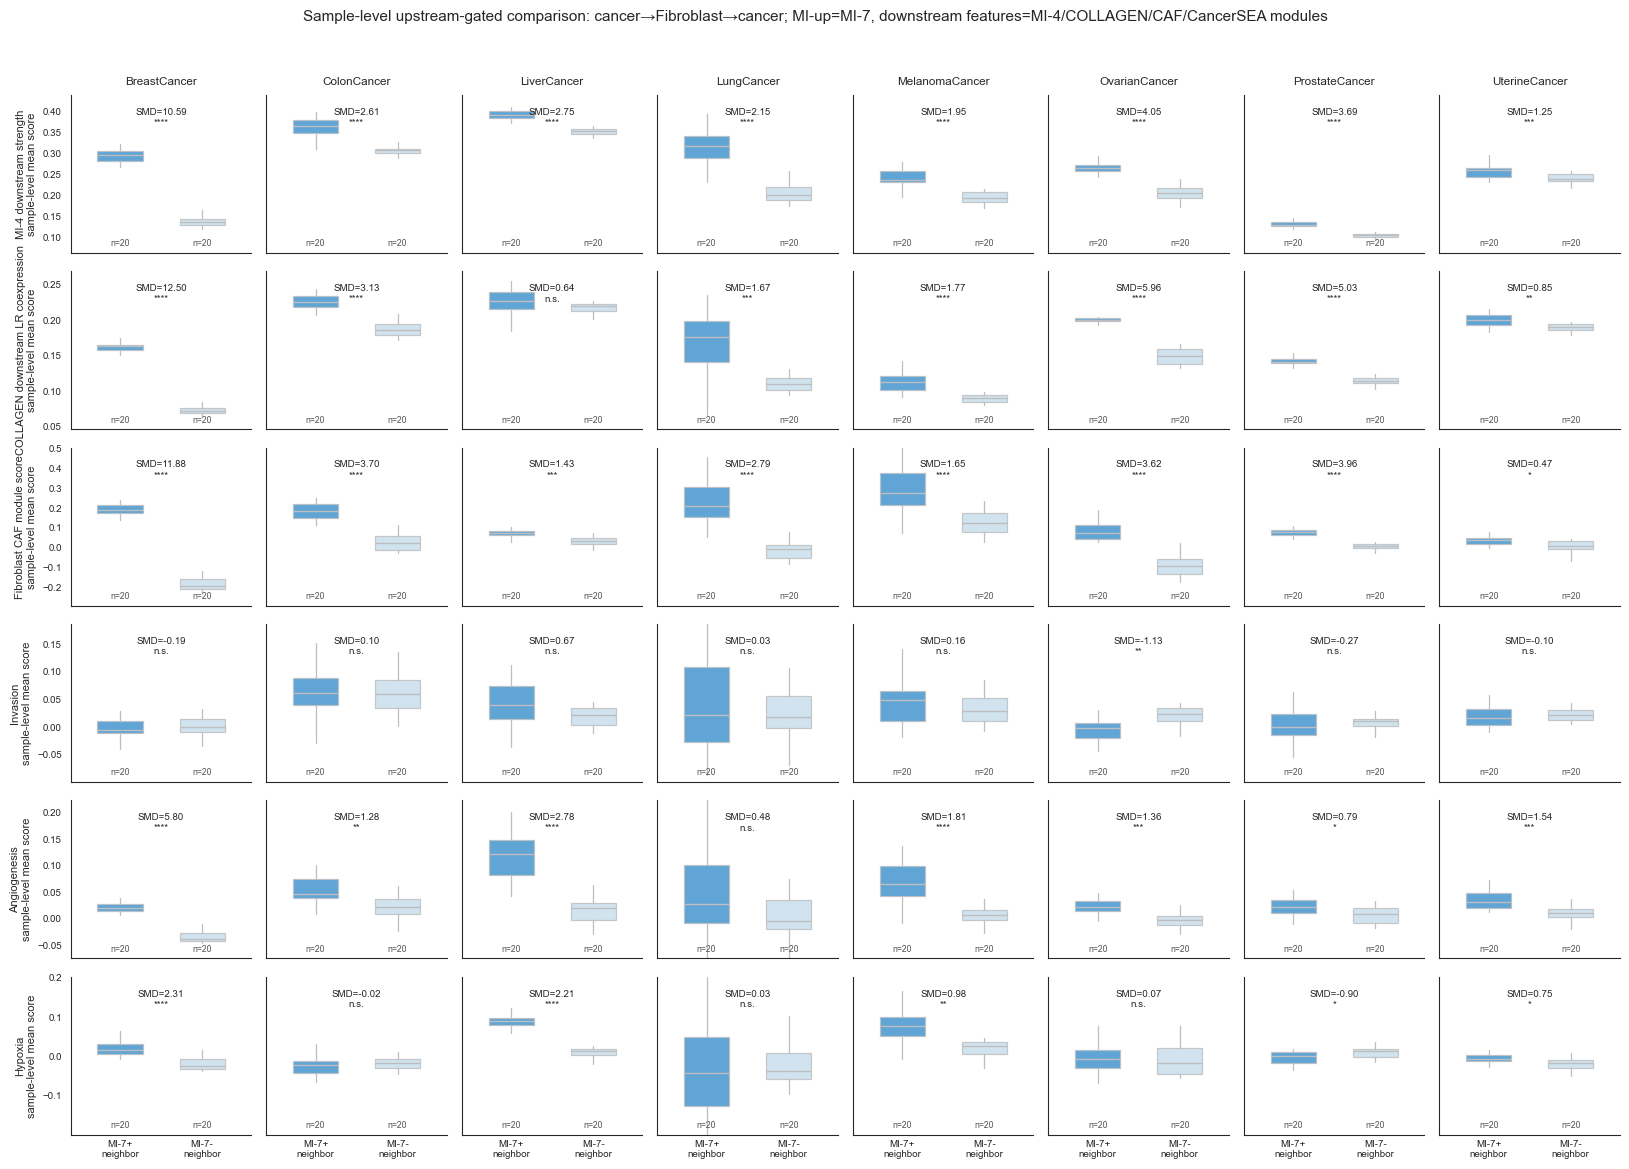

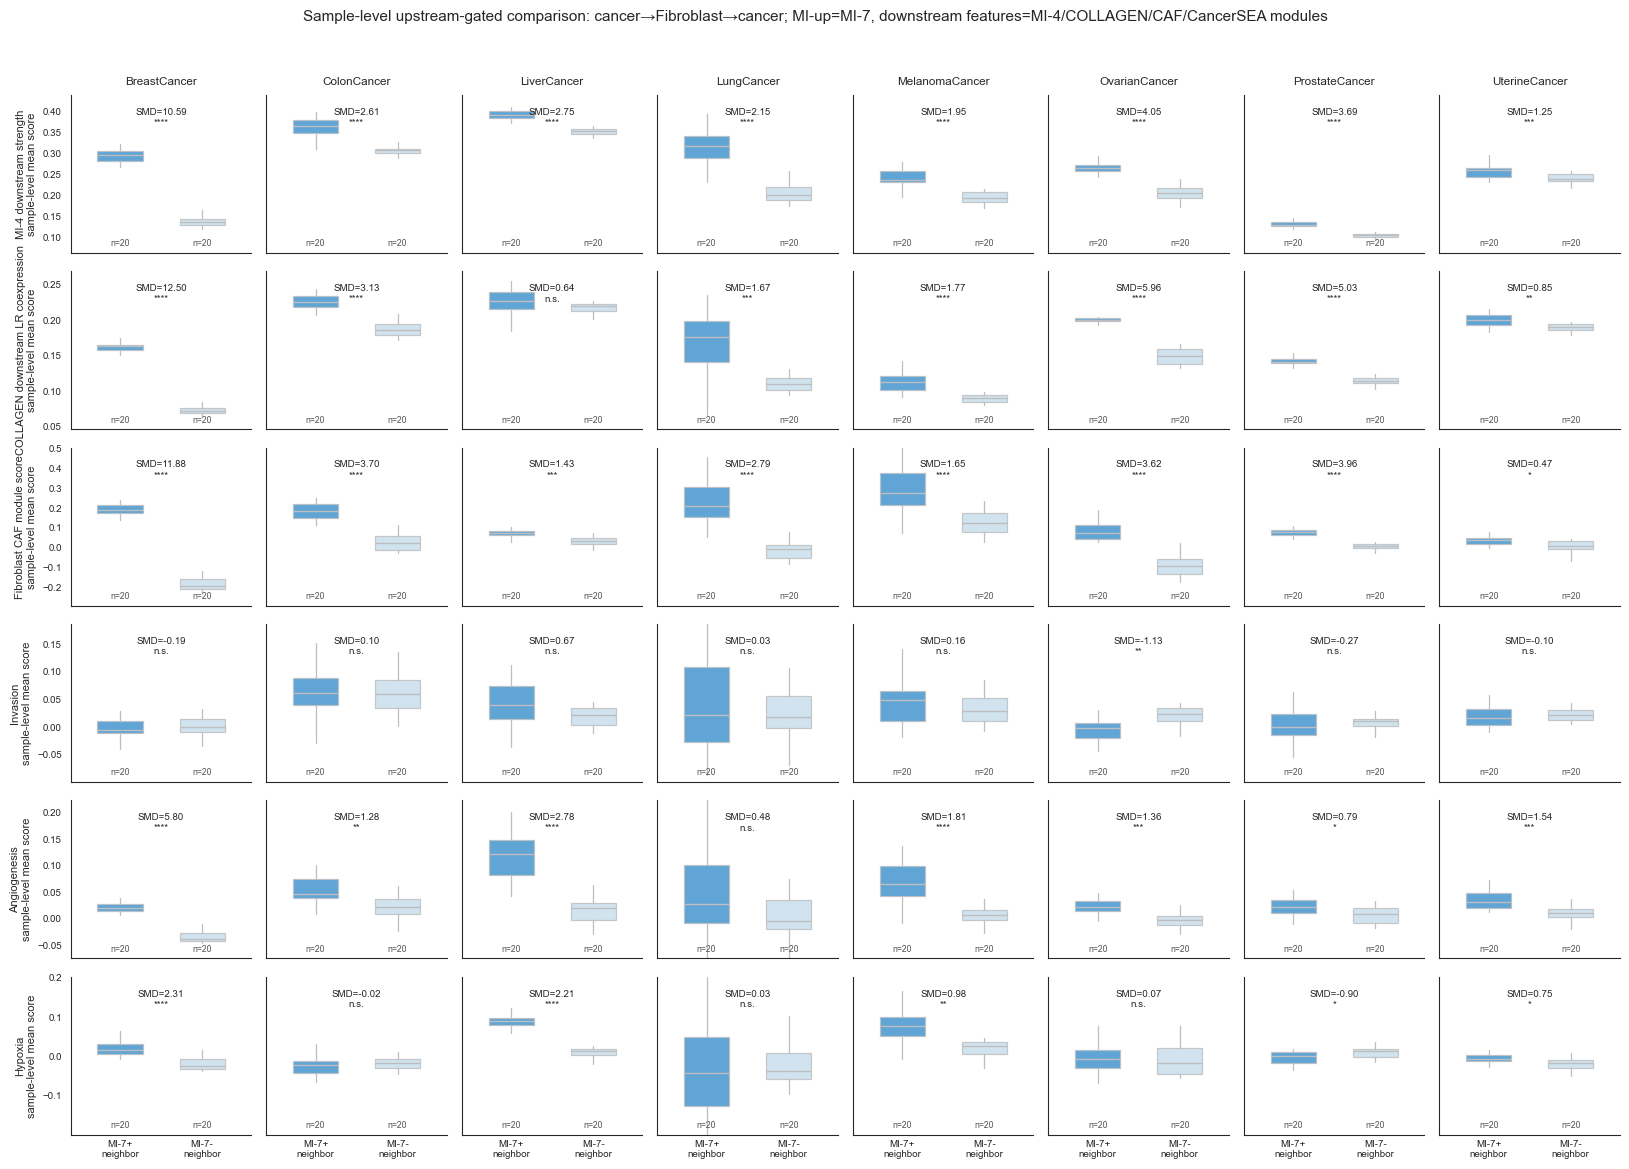

In [23]:
# ==============================================================
# Two-sided group tests, SMDs, and feature-by-cancer-type boxplots
# BH correction is applied across all available feature/cancer-type tests per level.
# Sample-level values are sub-slice means and are compared as unpaired groups.
# ==============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# --------------------------------------------------------------
# Make sure output_dir exists before saving CSV/figures
# Also avoid Windows path-too-long errors by using short filenames.
# --------------------------------------------------------------
if "output_dir" not in globals():
    raise NameError(
        "output_dir is not defined. Run the upstream-gated settings/output-directory cell first."
    )

output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Short prefix avoids Windows MAX_PATH issues.
SHORT_CASCADE_PREFIX = f"UpstreamGated_MI{MI_first_of_interest}_MI{MI_second_of_interest}"

if "MODULE_SCORE_METHOD" in globals():
    SHORT_CASCADE_PREFIX = f"{SHORT_CASCADE_PREFIX}_{MODULE_SCORE_METHOD}"

SHORT_CASCADE_PREFIX = re.sub(
    r"[^A-Za-z0-9_\-\.]+",
    "_",
    str(SHORT_CASCADE_PREFIX),
).strip("_")


def _safe_windows_path(path):
    """
    Return a path usable on Windows even when the absolute path is long.
    For normal platforms / short paths, this returns the original Path.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if os.name == "nt":
        abs_path = path.resolve()
        abs_str = str(abs_path)
        if not abs_str.startswith("\\\\?\\") and len(abs_str) >= 240:
            return "\\\\?\\" + abs_str

    return path


def _shorten_filename_keep_suffix(filename, max_stem_len=100):
    filename = str(filename)
    p = Path(filename)
    suffix = p.suffix
    stem = p.stem
    stem = stem[:max_stem_len].rstrip("_- .")
    return stem + suffix


def _save_df_csv(df, path, index=False):
    """
    Save dataframe with parent-dir creation and Windows long-path fallback.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        df.to_csv(_safe_windows_path(path), index=index)
        print(f"Saved: {path}")
        return path
    except FileNotFoundError:
        fallback_dir = output_dir / "short_outputs"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        fallback_name = _shorten_filename_keep_suffix(path.name, max_stem_len=100)
        if not fallback_name.endswith(".csv"):
            fallback_name = fallback_name + ".csv"

        fallback_path = fallback_dir / fallback_name
        df.to_csv(_safe_windows_path(fallback_path), index=index)

        print(f"Warning: original path failed, saved to fallback short path: {fallback_path}")
        return fallback_path


def _save_figure_pair(fig, output_path, dpi=300, bbox_inches="tight"):
    """
    Save figure as PDF and PNG with parent-dir creation and Windows long-path fallback.
    output_path should be provided without suffix.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for suffix in [".pdf", ".png"]:
        path = output_path.with_suffix(suffix)

        try:
            fig.savefig(_safe_windows_path(path), dpi=dpi, bbox_inches=bbox_inches)
            print(f"Saved: {path}")
            saved_paths.append(path)
        except FileNotFoundError:
            fallback_dir = output_dir / "short_outputs"
            fallback_dir.mkdir(parents=True, exist_ok=True)

            fallback_name = _shorten_filename_keep_suffix(path.name, max_stem_len=100)
            fallback_path = fallback_dir / fallback_name

            fig.savefig(_safe_windows_path(fallback_path), dpi=dpi, bbox_inches=bbox_inches)
            print(f"Warning: original path failed, saved to fallback short path: {fallback_path}")
            saved_paths.append(fallback_path)

    return saved_paths


FEATURE_ORDER = [
    f"MI-{MI_second_of_interest} downstream strength",
    "COLLAGEN downstream LR coexpression",
    "Fibroblast CAF module score",
    "Invasion",
    "Angiogenesis",
    "Hypoxia",
]


def _feature_order_present(df):
    present = set(df["feature"].astype(str)) if not df.empty else set()
    ordered = [f for f in FEATURE_ORDER if f in present]
    remaining = [
        f for f in pd.unique(df["feature"].astype(str))
        if f not in ordered
    ] if not df.empty else []
    return ordered + remaining


def _cancertype_order_present(df):
    present = set(df["CancerType"].astype(str)) if not df.empty else set()

    if "CancerType_order" in globals():
        ordered = [ct for ct in CancerType_order if str(ct) in present]
    else:
        canonical_order = [
            "BreastCancer",
            "ColonCancer",
            "LiverCancer",
            "LungCancer",
            "MelanomaCancer",
            "OvarianCancer",
            "ProstateCancer",
            "UterineCancer",
        ]
        ordered = [ct for ct in canonical_order if ct in present]

    remaining = sorted([ct for ct in present if ct not in ordered])
    return ordered + remaining


def _standardized_mean_difference_local(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) == 0 or len(y) == 0:
        return np.nan

    sx = float(np.nanstd(x, ddof=1)) if len(x) > 1 else np.nan
    sy = float(np.nanstd(y, ddof=1)) if len(y) > 1 else np.nan

    if np.isfinite(sx) and np.isfinite(sy) and (len(x) + len(y) - 2) > 0:
        pooled_var = ((len(x) - 1) * sx**2 + (len(y) - 1) * sy**2) / (len(x) + len(y) - 2)
        pooled_sd = float(np.sqrt(max(pooled_var, 0.0)))
    else:
        pooled_sd = float(np.nanstd(np.concatenate([x, y]), ddof=1))

    if not np.isfinite(pooled_sd) or pooled_sd <= 0:
        return np.nan

    return float((np.nanmean(x) - np.nanmean(y)) / pooled_sd)


def _make_feature_cancertype_stats(df, value_col="value", level="single_unit"):
    records = []

    if df.empty:
        return pd.DataFrame(records)

    for (feature_category, feature, cancer_type), sub in df.groupby(
        ["feature_category", "feature", "CancerType"],
        observed=True,
    ):
        x = sub.loc[sub["group"].eq(GROUP_UP_POS), value_col].to_numpy(dtype=float)
        y = sub.loc[sub["group"].eq(GROUP_UP_NEG), value_col].to_numpy(dtype=float)

        x = x[np.isfinite(x)]
        y = y[np.isfinite(y)]

        pval = _compare_two_groups(x, y, paired=False, alternative="two-sided")
        smd = _standardized_mean_difference_local(x, y)

        records.append({
            "feature_category": feature_category,
            "feature": feature,
            "CancerType": cancer_type,
            "level": level,
            "test": "Mann-Whitney U",
            f"n_{GROUP_UP_POS}": int(len(x)),
            f"n_{GROUP_UP_NEG}": int(len(y)),
            f"mean_{GROUP_UP_POS}": float(np.nanmean(x)) if len(x) else np.nan,
            f"mean_{GROUP_UP_NEG}": float(np.nanmean(y)) if len(y) else np.nan,
            f"median_{GROUP_UP_POS}": float(np.nanmedian(x)) if len(x) else np.nan,
            f"median_{GROUP_UP_NEG}": float(np.nanmedian(y)) if len(y) else np.nan,
            f"mean_diff_{GROUP_UP_POS}_minus_{GROUP_UP_NEG}": (
                float(np.nanmean(x) - np.nanmean(y)) if len(x) and len(y) else np.nan
            ),
            "SMD": smd,
            "pvalue": pval,
            "pvalue_star": _p_to_star(pval),
        })

    stats_df = pd.DataFrame(records)

    if not stats_df.empty and stats_df["pvalue"].notna().any():
        mask = stats_df["pvalue"].notna()
        stats_df.loc[mask, "pvalue_adj_BH"] = multipletests(
            stats_df.loc[mask, "pvalue"],
            method="fdr_bh",
        )[1]
        stats_df.loc[mask, "pvalue_adj_BH_star"] = (
            stats_df.loc[mask, "pvalue_adj_BH"].apply(_p_to_star)
        )

    return stats_df


def _boxplot_whisker_limits(arrays):
    vals = []

    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]

        if len(arr):
            vals.append(arr)

    if not vals:
        return 0.0, 1.0

    all_vals = np.concatenate(vals)

    vmin = float(np.nanpercentile(all_vals, 1))
    vmax = float(np.nanpercentile(all_vals, 99))

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = float(np.nanmin(all_vals))
        vmax = float(np.nanmax(all_vals))

    if vmin == vmax:
        delta = abs(vmin) * 0.1 + 1e-3
        vmin -= delta
        vmax += delta

    pad = 0.12 * (vmax - vmin)
    return vmin - pad, vmax + pad


def plot_feature_by_cancertype_boxplots(
    df,
    value_col="value",
    ylabel="Score",
    figure_title=None,
    output_path=None,
    stats_df=None,
    show=True,
):
    if df.empty:
        print("No data to plot.")
        return None

    plot_df = df.dropna(subset=[value_col]).copy()
    plot_df["feature"] = plot_df["feature"].astype(str)
    plot_df["CancerType"] = plot_df["CancerType"].astype(str)

    features = _feature_order_present(plot_df)
    cancer_types = _cancertype_order_present(plot_df)

    n_rows = len(features)
    n_cols = len(cancer_types)

    if n_rows == 0 or n_cols == 0:
        print("No feature/cancer-type combinations to plot.")
        return None

    fig_w = max(2.05 * n_cols, 8.0)
    fig_h = max(1.95 * n_rows, 5.0)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        sharex=False,
        sharey="row",
    )

    fig.patch.set_facecolor("white")

    for i, feature in enumerate(features):
        row_arrays = []

        for cancer_type in cancer_types:
            sub = plot_df.loc[
                plot_df["feature"].eq(feature)
                & plot_df["CancerType"].eq(cancer_type)
            ]

            for group in UPSTREAM_GATED_GROUPS:
                row_arrays.append(
                    sub.loc[sub["group"].eq(group), value_col].to_numpy(dtype=float)
                )

        ymin, ymax = _boxplot_whisker_limits(row_arrays)

        for j, cancer_type in enumerate(cancer_types):
            ax = axes[i, j]
            ax.set_facecolor("white")

            sub = plot_df.loc[
                plot_df["feature"].eq(feature)
                & plot_df["CancerType"].eq(cancer_type)
            ]

            data = []
            ns = []

            for group in UPSTREAM_GATED_GROUPS:
                vals = sub.loc[sub["group"].eq(group), value_col].to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                data.append(vals)
                ns.append(len(vals))

            if sum(ns) > 0:
                bp = ax.boxplot(
                    data,
                    positions=[1, 2],
                    widths=0.55,
                    patch_artist=True,
                    showfliers=False,
                    medianprops={"color": "#bdbec1", "linewidth": 1.0},
                    boxprops={"edgecolor": "#bdbec1", "linewidth": 0.9},
                    whiskerprops={"color": "#bdbec1", "linewidth": 0.9},
                    capprops={"color": "#bdbec1", "linewidth": 0.0},
                )

                for patch, group in zip(bp["boxes"], UPSTREAM_GATED_GROUPS):
                    patch.set_facecolor(GROUP_COLORS_UPSTREAM_GATED[group])
                    patch.set_alpha(0.82)
                    patch.set_edgecolor("#bdbec1")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )

            ax.set_ylim(ymin, ymax)
            ax.set_xlim(0.4, 2.6)
            ax.set_xticks([1, 2])

            if i == n_rows - 1:
                ax.set_xticklabels(
                    [PRETTY_GROUP_LABELS_UPSTREAM_GATED[g] for g in UPSTREAM_GATED_GROUPS],
                    rotation=0,
                    fontsize=7,
                )
            else:
                ax.set_xticklabels([])

            y_n = ymin + 0.03 * (ymax - ymin)

            for xpos, n in zip([1, 2], ns):
                ax.text(
                    xpos,
                    y_n,
                    f"n={n}",
                    ha="center",
                    va="bottom",
                    fontsize=6.2,
                    color="#555555",
                )

            pstar = None
            smd_text = None

            if stats_df is not None and not stats_df.empty:
                hit = stats_df.loc[
                    stats_df["feature"].astype(str).eq(feature)
                    & stats_df["CancerType"].astype(str).eq(cancer_type)
                ]

                if hit.shape[0] > 0:
                    if "pvalue_adj_BH_star" in hit.columns and pd.notna(hit["pvalue_adj_BH_star"].iloc[0]):
                        pstar = str(hit["pvalue_adj_BH_star"].iloc[0])
                    else:
                        pstar = str(hit["pvalue_star"].iloc[0])

                    if "SMD" in hit.columns and pd.notna(hit["SMD"].iloc[0]):
                        smd_text = f"SMD={hit['SMD'].iloc[0]:.2f}"

            if pstar is None:
                pval = _compare_two_groups(data[0], data[1], paired=False, alternative="two-sided")
                pstar = _p_to_star(pval)

            if smd_text is None:
                smd = _standardized_mean_difference_local(data[0], data[1])
                smd_text = f"SMD={smd:.2f}" if pd.notna(smd) else "SMD=NA"

            ax.text(
                1.5,
                ymax - 0.08 * (ymax - ymin),
                f"{smd_text}\n{pstar}",
                ha="center",
                va="top",
                fontsize=7,
            )

            if i == 0:
                ax.set_title(cancer_type, fontsize=8.5, pad=7)

            if j == 0:
                ax.set_ylabel(f"{feature}\n{ylabel}", fontsize=8)
            else:
                ax.set_ylabel("")

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="y", labelsize=7)
            ax.tick_params(axis="x", length=0)

    if figure_title:
        fig.suptitle(figure_title, fontsize=11, y=0.995)

    fig.tight_layout(rect=[0, 0, 1, 0.975])

    if output_path is not None:
        _save_figure_pair(fig, output_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


# -----------------------------
# Single-cell / edge-unit level statistics and plot
# -----------------------------
single_unit_stats_df = _make_feature_cancertype_stats(
    feature_records_upstream_gated,
    value_col="value",
    level="single_unit",
)

single_unit_stats_path = output_dir / f"{SHORT_CASCADE_PREFIX}_single_unit_stats.csv"
single_unit_stats_path = _save_df_csv(single_unit_stats_df, single_unit_stats_path, index=False)

print(f"Saved single-unit feature × cancer-type statistics: {single_unit_stats_path}")
display(single_unit_stats_df)

plot_feature_by_cancertype_boxplots(
    feature_records_upstream_gated,
    value_col="value",
    ylabel="single-unit score",
    figure_title=(
        f"Upstream-gated comparison: cancer→Fibroblast→cancer; "
        f"MI-up=MI-{MI_first_of_interest}, downstream features=MI-{MI_second_of_interest}/COLLAGEN/CAF/CancerSEA modules"
    ),
    output_path=output_dir / f"{SHORT_CASCADE_PREFIX}_single_unit_boxplots",
    stats_df=single_unit_stats_df,
    show=True,
)


# -----------------------------
# Sample-level aggregation/statistics and plot
# -----------------------------
sample_level_feature_df = (
    feature_records_upstream_gated
    .dropna(subset=["value"])
    .groupby(
        ["feature_category", "feature", "CancerType", "sample_index", "sample_name", "group"],
        as_index=False,
        observed=True,
    )
    .agg(
        sample_mean_score=("value", "mean"),
        sample_median_score=("value", "median"),
        n_units=("value", "size"),
    )
)

sample_level_feature_path = output_dir / f"{SHORT_CASCADE_PREFIX}_sample_level_scores.csv"
sample_level_feature_path = _save_df_csv(sample_level_feature_df, sample_level_feature_path, index=False)

print(f"Saved sample-level feature scores: {sample_level_feature_path}")

sample_level_plot_df = sample_level_feature_df.rename(columns={"sample_mean_score": "value"}).copy()

sample_level_stats_df = _make_feature_cancertype_stats(
    sample_level_plot_df,
    value_col="value",
    level="sample_level",
)

sample_level_stats_path = output_dir / f"{SHORT_CASCADE_PREFIX}_sample_level_stats.csv"
sample_level_stats_path = _save_df_csv(sample_level_stats_df, sample_level_stats_path, index=False)

print(f"Saved sample-level feature × cancer-type statistics: {sample_level_stats_path}")
display(sample_level_stats_df)

# Main SMD table for downstream fixed-feature heatmap cell.
feature_module_smd_df = sample_level_stats_df.copy()

plot_feature_by_cancertype_boxplots(
    sample_level_plot_df,
    value_col="value",
    ylabel="sample-level mean score",
    figure_title=(
        f"Sample-level upstream-gated comparison: cancer→Fibroblast→cancer; "
        f"MI-up=MI-{MI_first_of_interest}, downstream features=MI-{MI_second_of_interest}/COLLAGEN/CAF/CancerSEA modules"
    ),
    output_path=output_dir / f"{SHORT_CASCADE_PREFIX}_sample_level_boxplots",
    stats_df=sample_level_stats_df,
    show=True,
)

## 9. SMD heatmap for upstream-gated feature analysis


Feature SMD heatmap output directory:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps
Short output prefix:
UpGated_MI7_MI4_zscore_mean_global_per_cancertype
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD.csv
Saved single-unit feature SMD table: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD.csv
Saved sample-level feature SMD table: D:\

,feature_category,feature,CancerType,level,n_MIup_interacting,n_MIup_not_interacting,mean_MIup_interacting,mean_MIup_not_interacting,mean_diff_MIup_interacting_minus_MIup_not_interacting,SMD
0,Downstream LR coexpression,COLLAGEN downstream LR coexpression,BreastCancer,sample_level,20,20,0.163107,0.073740,0.089367,12.499907
1,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ColonCancer,sample_level,20,20,0.228239,0.187504,0.040734,3.128548
2,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LiverCancer,sample_level,20,20,0.225623,0.216833,0.008790,0.642251
3,Downstream LR coexpression,COLLAGEN downstream LR coexpression,LungCancer,sample_level,20,20,0.168272,0.110137,0.058135,1.671888
4,Downstream LR coexpression,COLLAGEN downstream LR coexpression,MelanomaCancer,sample_level,20,20,0.115764,0.090151,0.025612,1.770307
5,Downstream LR coexpression,COLLAGEN downstream LR coexpression,OvarianCancer,sample_level,20,20,0.200486,0.149434,0.051052,5.955366
6,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ProstateCancer,sample_level,20,20,0.143033,0.114588,0.028445,5.027692
7,Downstream LR coexpression,COLLAGEN downstream LR coexpression,UterineCancer,sample_level,20,20,0.198037,0.186981,0.011056,0.853036
8,Downstream MI strength,MI-4 downstream strength,BreastCancer,sample_level,20,20,0.295598,0.140455,0.155144,10.594841
9,Downstream MI strength,MI-4 downstream strength,ColonCancer,sample_level,20,20,0.359849,0.308855,0.050995,2.613479


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_matrix.csv
Saved SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_matrix.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_heatmap.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_heatmap.png


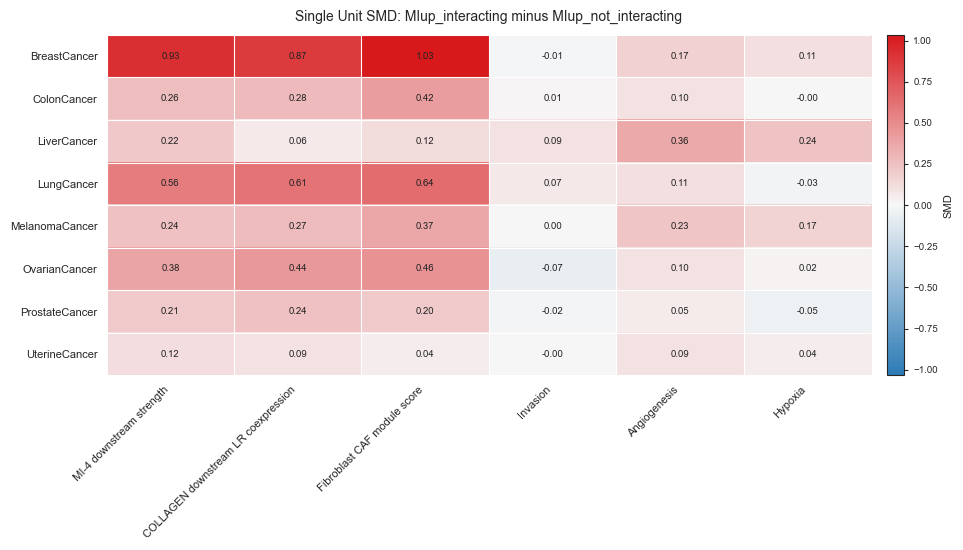

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_maxnorm_matrix.csv
Saved feature-wise max-normalized SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_maxnorm_matrix.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_maxnorm_heatmap.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_SMD_maxnorm_heatmap.png


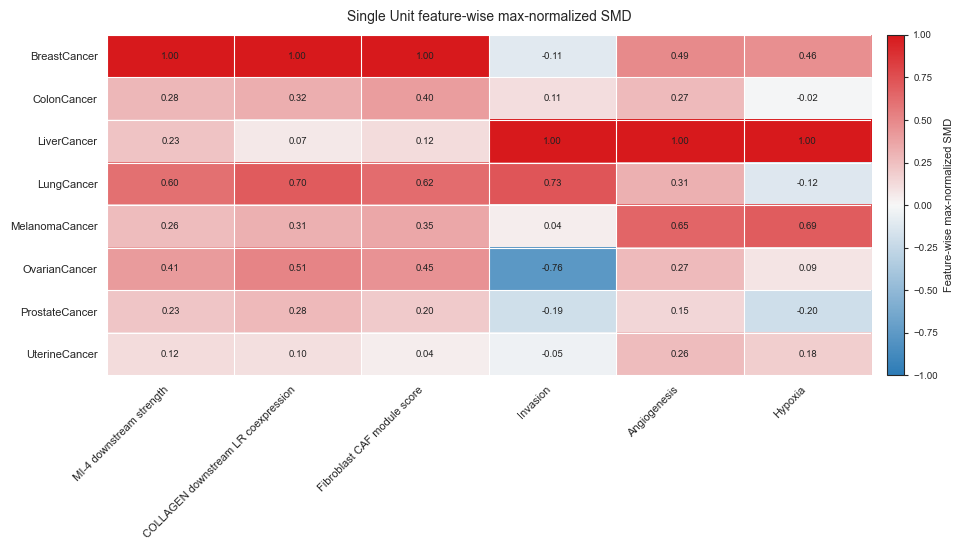

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_matrix.csv
Saved SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_matrix.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_heatmap.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_heatmap.png


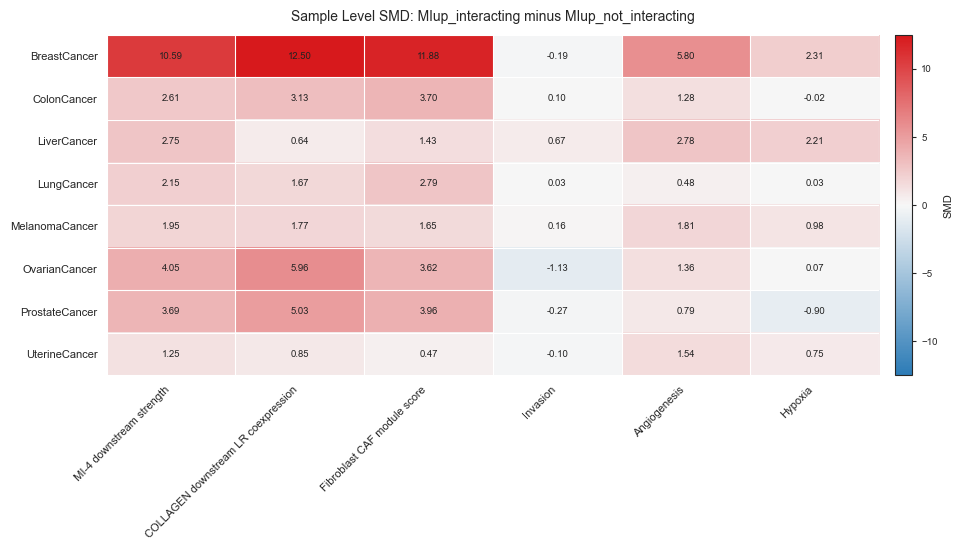

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_maxnorm_matrix.csv
Saved feature-wise max-normalized SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_maxnorm_matrix.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_maxnorm_heatmap.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\SMD_heatmaps\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_SMD_maxnorm_heatmap.png

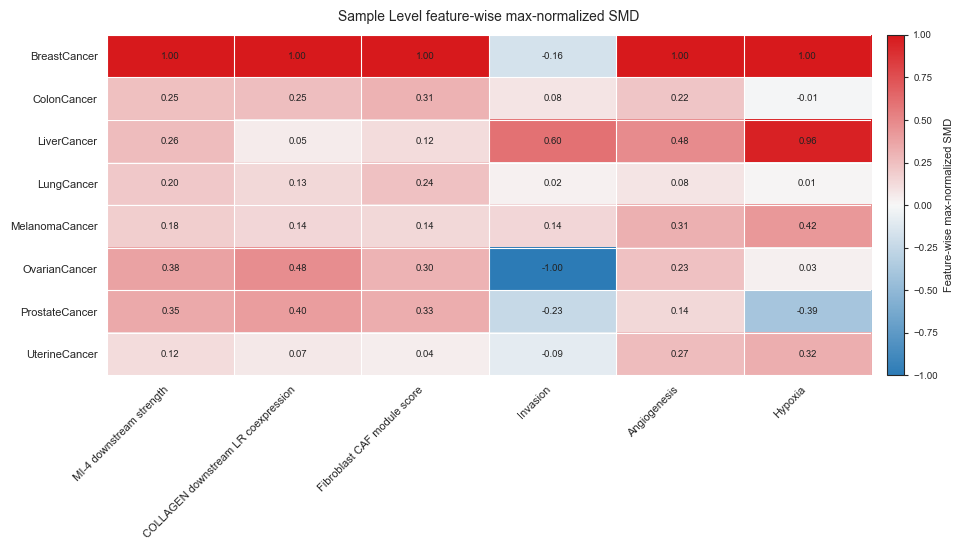

In [24]:
# ==============================================================
# Heatmap of SMD for upstream-gated feature analysis
# Windows-safe / short-path version
# --------------------------------------------------------------
# This cell summarizes the feature-level comparison already computed above:
#   rows    = cancer types
#   columns = features
#   value   = standardized mean difference
#             (GROUP_UP_POS - GROUP_UP_NEG)
#
# Both single-unit and sample-level SMD heatmaps are saved.
# ==============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# User parameters
# -----------------------------
FEATURE_SMD_HEATMAP_LEVELS_TO_PLOT = ("single_unit", "sample_level")
FEATURE_SMD_HEATMAP_ANNOTATE_VALUES = True
FEATURE_SMD_HEATMAP_VALUE_FMT = "{:.2f}"

# If None, each heatmap uses symmetric max(abs(SMD)).
FEATURE_SMD_HEATMAP_ABS_MAX = None

# Also save and plot a feature-wise max-normalized SMD heatmap.
FEATURE_SMD_HEATMAP_PLOT_FEATURE_MAXNORM = True

FEATURE_SMD_CELL_WIDTH = 1.05
FEATURE_SMD_CELL_HEIGHT = 0.45
FEATURE_SMD_MIN_WIDTH = 8.5
FEATURE_SMD_MIN_HEIGHT = 4.5
FEATURE_SMD_MAX_WIDTH = 38
FEATURE_SMD_MAX_HEIGHT = 16


# -----------------------------
# Robust output path setup
# -----------------------------
if "output_dir" not in globals():
    raise NameError(
        "output_dir is not defined. Run the upstream-gated settings/output-directory cell first."
    )

output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

feature_smd_outdir = output_dir / "SMD_heatmaps"
feature_smd_outdir.mkdir(parents=True, exist_ok=True)

# Short prefix avoids Windows MAX_PATH issues.
if "MI_first_of_interest" in globals() and "MI_second_of_interest" in globals():
    FEATURE_SMD_SHORT_PREFIX = f"UpGated_MI{MI_first_of_interest}_MI{MI_second_of_interest}"
else:
    FEATURE_SMD_SHORT_PREFIX = "UpGated_MI"

if "MODULE_SCORE_METHOD" in globals():
    FEATURE_SMD_SHORT_PREFIX = f"{FEATURE_SMD_SHORT_PREFIX}_{MODULE_SCORE_METHOD}"

FEATURE_SMD_SHORT_PREFIX = re.sub(
    r"[^A-Za-z0-9_\-\.]+",
    "_",
    str(FEATURE_SMD_SHORT_PREFIX),
).strip("_")

print("Feature SMD heatmap output directory:")
print(feature_smd_outdir)
print("Short output prefix:")
print(FEATURE_SMD_SHORT_PREFIX)


def _save_df_csv(df, path, index=False):
    """
    Save dataframe with parent-dir creation and Windows long-path fallback.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        df.to_csv(_safe_windows_path(path), index=index)
        print(f"Saved: {path}")
        return path
    except (FileNotFoundError, OSError) as e:
        fallback_dir = feature_smd_outdir / "short_outputs"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        fallback_name = _shorten_filename_keep_suffix(path.name, max_stem_len=90)
        if not fallback_name.endswith(".csv"):
            fallback_name = fallback_name + ".csv"

        fallback_path = fallback_dir / fallback_name
        df.to_csv(_safe_windows_path(fallback_path), index=index)

        print(f"Warning: original path failed with {type(e).__name__}; saved to fallback short path:")
        print(fallback_path)
        return fallback_path


def _save_figure_pair(fig, output_path, dpi=300, bbox_inches="tight"):
    """
    Save figure as PDF and PNG with parent-dir creation and Windows long-path fallback.
    output_path should be provided without suffix.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for suffix in [".pdf", ".png"]:
        path = output_path.with_suffix(suffix)

        try:
            fig.savefig(_safe_windows_path(path), dpi=dpi, bbox_inches=bbox_inches)
            print(f"Saved: {path}")
            saved_paths.append(path)
        except (FileNotFoundError, OSError) as e:
            fallback_dir = feature_smd_outdir / "short_outputs"
            fallback_dir.mkdir(parents=True, exist_ok=True)

            fallback_name = _shorten_filename_keep_suffix(path.name, max_stem_len=90)
            fallback_path = fallback_dir / fallback_name

            fig.savefig(_safe_windows_path(fallback_path), dpi=dpi, bbox_inches=bbox_inches)

            print(f"Warning: original figure path failed with {type(e).__name__}; saved to fallback short path:")
            print(fallback_path)
            saved_paths.append(fallback_path)

    return saved_paths


# -----------------------------
# Helpers
# -----------------------------
def _standardized_mean_difference_feature_smd(x, y):
    """Cohen-style SMD: mean(x) - mean(y), divided by pooled SD."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) == 0 or len(y) == 0:
        return np.nan

    mean_diff = float(np.nanmean(x) - np.nanmean(y))

    sx = float(np.nanstd(x, ddof=1)) if len(x) > 1 else np.nan
    sy = float(np.nanstd(y, ddof=1)) if len(y) > 1 else np.nan

    if np.isfinite(sx) and np.isfinite(sy) and (len(x) + len(y) - 2) > 0:
        pooled_var = ((len(x) - 1) * sx**2 + (len(y) - 1) * sy**2) / (len(x) + len(y) - 2)
        pooled_sd = float(np.sqrt(max(pooled_var, 0.0)))
    else:
        pooled_sd = float(np.nanstd(np.concatenate([x, y]), ddof=1))

    if not np.isfinite(pooled_sd) or pooled_sd <= 0:
        return np.nan

    return mean_diff / pooled_sd


def _make_feature_cancertype_smd(df, value_col="value", level="single_unit"):
    records = []

    if df is None or df.empty:
        return pd.DataFrame(records)

    required = {"feature_category", "feature", "CancerType", "group", value_col}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Input df is missing columns required for SMD: {missing}")

    for (feature_category, feature, cancer_type), sub in df.groupby(
        ["feature_category", "feature", "CancerType"],
        observed=True,
        sort=False,
    ):
        x = sub.loc[sub["group"].eq(GROUP_UP_POS), value_col].to_numpy(dtype=float)
        y = sub.loc[sub["group"].eq(GROUP_UP_NEG), value_col].to_numpy(dtype=float)

        records.append({
            "feature_category": feature_category,
            "feature": feature,
            "CancerType": cancer_type,
            "level": level,
            f"n_{GROUP_UP_POS}": int(np.isfinite(x).sum()),
            f"n_{GROUP_UP_NEG}": int(np.isfinite(y).sum()),
            f"mean_{GROUP_UP_POS}": float(np.nanmean(x)) if np.isfinite(x).sum() else np.nan,
            f"mean_{GROUP_UP_NEG}": float(np.nanmean(y)) if np.isfinite(y).sum() else np.nan,
            f"mean_diff_{GROUP_UP_POS}_minus_{GROUP_UP_NEG}": (
                float(np.nanmean(x) - np.nanmean(y))
                if np.isfinite(x).sum() and np.isfinite(y).sum()
                else np.nan
            ),
            "SMD": _standardized_mean_difference_feature_smd(x, y),
        })

    return pd.DataFrame(records)


def _matrix_from_feature_smd_df(smd_df):
    if smd_df.empty:
        return pd.DataFrame()

    if "_feature_order_present" in globals():
        feature_order = _feature_order_present(smd_df)
    else:
        feature_order = list(pd.unique(smd_df["feature"].astype(str)))

    if "_cancertype_order_present" in globals():
        cancer_order = _cancertype_order_present(smd_df)
    else:
        cancer_order = list(pd.unique(smd_df["CancerType"].astype(str)))

    mat = (
        smd_df
        .assign(
            feature=lambda x: x["feature"].astype(str),
            CancerType=lambda x: x["CancerType"].astype(str),
        )
        .pivot_table(
            index="CancerType",
            columns="feature",
            values="SMD",
            aggfunc="mean",
        )
    )

    cancer_order = [x for x in cancer_order if x in mat.index]
    feature_order = [x for x in feature_order if x in mat.columns]

    return mat.loc[cancer_order, feature_order]


def _term_maxnorm_matrix(mat):
    mat_norm = mat.copy().astype(float)

    for col in mat_norm.columns:
        vals = mat_norm[col].to_numpy(dtype=float)
        finite = vals[np.isfinite(vals)]

        if finite.size == 0:
            mat_norm[col] = np.nan
            continue

        denom = float(np.nanmax(np.abs(finite)))

        if np.isfinite(denom) and denom > 0:
            mat_norm[col] = mat_norm[col] / denom
        else:
            mat_norm[col] = np.nan

    return mat_norm


def _plot_smd_heatmap_matrix(
    mat,
    title,
    output_prefix,
    value_label="SMD",
    value_fmt="{:.2f}",
    annotate=True,
    abs_max=None,
):
    if mat.empty:
        print(f"No data to plot for {title}.")
        return None

    arr = mat.to_numpy(dtype=float)

    if abs_max is None:
        finite = arr[np.isfinite(arr)]
        abs_max = float(np.nanmax(np.abs(finite))) if finite.size else 1.0
        if not np.isfinite(abs_max) or abs_max <= 0:
            abs_max = 1.0

    cmap = LinearSegmentedColormap.from_list(
        "smd_blue_white_red",
        ["#2c7bb6", "#f7f7f7", "#d7191c"],
        N=256,
    )

    fig_w = min(
        max(FEATURE_SMD_CELL_WIDTH * max(mat.shape[1], 1) + 3.5, FEATURE_SMD_MIN_WIDTH),
        FEATURE_SMD_MAX_WIDTH,
    )
    fig_h = min(
        max(FEATURE_SMD_CELL_HEIGHT * max(mat.shape[0], 1) + 2.0, FEATURE_SMD_MIN_HEIGHT),
        FEATURE_SMD_MAX_HEIGHT,
    )

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=8)

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=8)

    ax.set_title(title, fontsize=10, pad=10)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = arr[i, j]
                if np.isfinite(val):
                    ax.text(
                        j,
                        i,
                        value_fmt.format(val),
                        ha="center",
                        va="center",
                        fontsize=6.8,
                        color="#222222",
                    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(value_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.tight_layout()

    _save_figure_pair(
        fig,
        feature_smd_outdir / output_prefix,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    return fig


# -----------------------------
# Build single-unit and sample-level SMD tables
# -----------------------------
if "feature_records_upstream_gated" not in globals():
    raise NameError("feature_records_upstream_gated not found. Run the upstream-gated feature extraction cell first.")

feature_single_unit_smd_df = _make_feature_cancertype_smd(
    feature_records_upstream_gated,
    value_col="value",
    level="single_unit",
)

feature_single_unit_smd_path = feature_smd_outdir / f"{FEATURE_SMD_SHORT_PREFIX}_single_unit_SMD.csv"
feature_single_unit_smd_path = _save_df_csv(
    feature_single_unit_smd_df,
    feature_single_unit_smd_path,
    index=False,
)
print(f"Saved single-unit feature SMD table: {feature_single_unit_smd_path}")

if "sample_level_feature_df" not in globals():
    sample_level_feature_df = (
        feature_records_upstream_gated
        .dropna(subset=["value"])
        .groupby(
            ["feature_category", "feature", "CancerType", "sample_index", "sample_name", "group"],
            as_index=False,
            observed=True,
        )
        .agg(
            sample_mean_score=("value", "mean"),
            sample_median_score=("value", "median"),
            n_units=("value", "size"),
        )
    )

sample_level_plot_df_for_smd = sample_level_feature_df.rename(columns={"sample_mean_score": "value"}).copy()

feature_sample_level_smd_df = _make_feature_cancertype_smd(
    sample_level_plot_df_for_smd,
    value_col="value",
    level="sample_level",
)

feature_sample_level_smd_path = feature_smd_outdir / f"{FEATURE_SMD_SHORT_PREFIX}_sample_level_SMD.csv"
feature_sample_level_smd_path = _save_df_csv(
    feature_sample_level_smd_df,
    feature_sample_level_smd_path,
    index=False,
)
print(f"Saved sample-level feature SMD table: {feature_sample_level_smd_path}")

display(feature_sample_level_smd_df)


# -----------------------------
# Plot heatmaps
# -----------------------------
for _level, _smd_df in [
    ("single_unit", feature_single_unit_smd_df),
    ("sample_level", feature_sample_level_smd_df),
]:
    if _level not in FEATURE_SMD_HEATMAP_LEVELS_TO_PLOT:
        continue

    _mat = _matrix_from_feature_smd_df(_smd_df)

    _mat_path = feature_smd_outdir / f"{FEATURE_SMD_SHORT_PREFIX}_{_level}_SMD_matrix.csv"
    _mat_path = _save_df_csv(_mat, _mat_path, index=True)
    print(f"Saved SMD matrix: {_mat_path}")

    _plot_smd_heatmap_matrix(
        mat=_mat,
        title=f"{_level.replace('_', ' ').title()} SMD: {GROUP_UP_POS} minus {GROUP_UP_NEG}",
        output_prefix=f"{FEATURE_SMD_SHORT_PREFIX}_{_level}_SMD_heatmap",
        value_label="SMD",
        value_fmt=FEATURE_SMD_HEATMAP_VALUE_FMT,
        annotate=FEATURE_SMD_HEATMAP_ANNOTATE_VALUES,
        abs_max=FEATURE_SMD_HEATMAP_ABS_MAX,
    )

    if FEATURE_SMD_HEATMAP_PLOT_FEATURE_MAXNORM:
        _mat_norm = _term_maxnorm_matrix(_mat)

        _mat_norm_path = feature_smd_outdir / f"{FEATURE_SMD_SHORT_PREFIX}_{_level}_SMD_maxnorm_matrix.csv"
        _mat_norm_path = _save_df_csv(_mat_norm, _mat_norm_path, index=True)
        print(f"Saved feature-wise max-normalized SMD matrix: {_mat_norm_path}")

        _plot_smd_heatmap_matrix(
            mat=_mat_norm,
            title=f"{_level.replace('_', ' ').title()} feature-wise max-normalized SMD",
            output_prefix=f"{FEATURE_SMD_SHORT_PREFIX}_{_level}_SMD_maxnorm_heatmap",
            value_label="Feature-wise max-normalized SMD",
            value_fmt=FEATURE_SMD_HEATMAP_VALUE_FMT,
            annotate=FEATURE_SMD_HEATMAP_ANNOTATE_VALUES,
            abs_max=1.0,
        )

Feature Cleveland dot-plot output directory:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots
Short output prefix:
UpGated_MI7_MI4_zscore_mean_global_per_cancertype
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_group_means_SMD_by_feature_cancertype.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_sample_level_group_means_SMD_by_feature_cancertype.csv
Saved single-unit group means and SMD: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots\UpGated_MI

,feature_category,feature,CancerType,mean_pos,mean_neg,n_pos,n_neg,SMD,mean_diff_pos_minus_neg,level
0,Downstream MI strength,MI-4 downstream strength,BreastCancer,0.295266,0.139671,87667,93702,0.928710,0.155595,single_unit
1,Downstream MI strength,MI-4 downstream strength,ColonCancer,0.363463,0.310375,6530,110107,0.264171,0.053087,single_unit
2,Downstream MI strength,MI-4 downstream strength,LiverCancer,0.389343,0.350674,6984,77404,0.215565,0.038669,single_unit
3,Downstream MI strength,MI-4 downstream strength,LungCancer,0.314044,0.202095,488,55752,0.559260,0.111950,single_unit
4,Downstream MI strength,MI-4 downstream strength,MelanomaCancer,0.242417,0.193420,1503,43582,0.243523,0.048997,single_unit
5,Downstream MI strength,MI-4 downstream strength,OvarianCancer,0.266830,0.203764,21120,54326,0.383869,0.063066,single_unit
6,Downstream MI strength,MI-4 downstream strength,ProstateCancer,0.132621,0.105431,10451,383329,0.209802,0.027190,single_unit
7,Downstream MI strength,MI-4 downstream strength,UterineCancer,0.259162,0.240240,14483,96998,0.115098,0.018922,single_unit
8,Downstream LR coexpression,COLLAGEN downstream LR coexpression,BreastCancer,0.162925,0.073419,87667,93702,0.869788,0.089506,single_unit
9,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ColonCancer,0.227345,0.187161,6530,110107,0.282313,0.040184,single_unit


,feature_category,feature,CancerType,mean_pos,mean_neg,n_pos,n_neg,SMD,mean_diff_pos_minus_neg,level
0,Downstream MI strength,MI-4 downstream strength,BreastCancer,0.295598,0.140455,20,20,10.594841,0.155144,sample_level
1,Downstream MI strength,MI-4 downstream strength,ColonCancer,0.359849,0.308855,20,20,2.613479,0.050995,sample_level
2,Downstream MI strength,MI-4 downstream strength,LiverCancer,0.387966,0.349794,20,20,2.748972,0.038172,sample_level
3,Downstream MI strength,MI-4 downstream strength,LungCancer,0.310103,0.205133,20,20,2.153269,0.104970,sample_level
4,Downstream MI strength,MI-4 downstream strength,MelanomaCancer,0.243915,0.194121,20,20,1.953083,0.049794,sample_level
5,Downstream MI strength,MI-4 downstream strength,OvarianCancer,0.267246,0.204604,20,20,4.048223,0.062642,sample_level
6,Downstream MI strength,MI-4 downstream strength,ProstateCancer,0.133008,0.105209,20,20,3.689746,0.027799,sample_level
7,Downstream MI strength,MI-4 downstream strength,UterineCancer,0.258962,0.239276,20,20,1.248656,0.019687,sample_level
8,Downstream LR coexpression,COLLAGEN downstream LR coexpression,BreastCancer,0.163107,0.073740,20,20,12.499907,0.089367,sample_level
9,Downstream LR coexpression,COLLAGEN downstream LR coexpression,ColonCancer,0.228239,0.187504,20,20,3.128548,0.040734,sample_level


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_Cleveland_dotplot_feature_panels_oneRow_yCancerType_noSMD_point1p8_wspaceHalf.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots\UpGated_MI7_MI4_zscore_mean_global_per_cancertype_single_unit_Cleveland_dotplot_feature_panels_oneRow_yCancerType_noSMD_point1p8_wspaceHalf.png


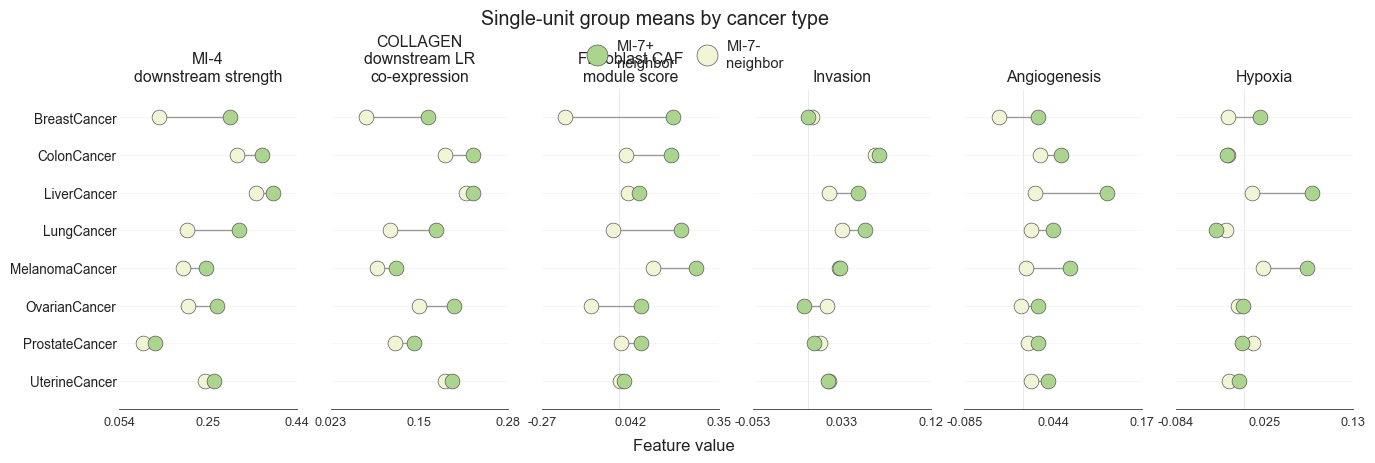

Done.
Single-unit Cleveland mean/SMD table: feature_single_unit_cleveland_mean_df
Sample-level Cleveland mean/SMD table: feature_sample_level_cleveland_mean_df
Cleveland dot plots were saved to:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\Cleveland_dotplots


In [25]:
# ==============================================================
# Cleveland / dumbbell dot plots for upstream-gated feature analysis
# --------------------------------------------------------------
# Facet = feature
# One-row panel layout.
#
# Within each feature panel:
#   y-axis = cancer type
#   x-axis = feature value
#   two dots per cancer type:
#       Positive group / MI-7+ neighbor: #abd58e
#       Baseline group / MI-7- neighbor: #f1f5d5
#   grey line connects the two group means.
#
# Group means are shown without significance annotations or error bars.
# ==============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==============================================================
# User parameters
# ==============================================================

FEATURE_CLEVELAND_LEVELS_TO_PLOT = ("single_unit",)
# Options:
#   ("single_unit",)
#   ("sample_level",)
#   ("single_unit", "sample_level")

FEATURE_CLEVELAND_SIZE_SCALE = 1.5
# Scales all main font sizes.

FEATURE_CLEVELAND_POINT_SIZE_MULTIPLIER = 1.8
# Multiplier for point areas and legend marker sizes.

FEATURE_CLEVELAND_USE_SHARED_XLIM_BY_FEATURE = True
# True: each feature panel uses x-limit based on that feature across cancer types.
# False: all feature panels share one global x-limit.

FEATURE_CLEVELAND_SHOW_SMD_TEXT = False
# No SMD annotation on the figure.

FEATURE_CLEVELAND_SHOW_N_TEXT = False

FEATURE_CLEVELAND_POS_COLOR = "#abd58e"
FEATURE_CLEVELAND_NEG_COLOR = "#f1f5d5"
FEATURE_CLEVELAND_LINE_COLOR = "#9a9a9a"
FEATURE_CLEVELAND_EDGE_COLOR = "#4a4a4a"

FEATURE_CLEVELAND_POINT_SIZE = 42 * FEATURE_CLEVELAND_SIZE_SCALE * FEATURE_CLEVELAND_POINT_SIZE_MULTIPLIER
FEATURE_CLEVELAND_LINE_WIDTH = 1.0
FEATURE_CLEVELAND_AXIS_LINEWIDTH = 0.6

# One-row layout: figure width scales with number of features.
FEATURE_CLEVELAND_PANEL_WIDTH = 2.10
FEATURE_CLEVELAND_PANEL_HEIGHT_PER_CANCER = 0.34
FEATURE_CLEVELAND_PANEL_MIN_HEIGHT = 2.7

FEATURE_CLEVELAND_MIN_WIDTH = 8.5
FEATURE_CLEVELAND_MIN_HEIGHT = 4.2
FEATURE_CLEVELAND_MAX_WIDTH = 42
FEATURE_CLEVELAND_MAX_HEIGHT = 9.5

FEATURE_CLEVELAND_XTICK_N = 3
FEATURE_CLEVELAND_XLABEL_ROTATION = 0

# Horizontal spacing between feature panels.
FEATURE_CLEVELAND_WSPACE = 0.19

FEATURE_CLEVELAND_SAVE_FIGURES = True
FEATURE_CLEVELAND_SHOW_FIGURES = True
FEATURE_CLEVELAND_DPI = 300

FEATURE_CLEVELAND_OUTPUT_SUBDIR = "Cleveland_dotplots"


# ==============================================================
# Scaled font sizes
# ==============================================================

FONT_BASE = 7.0 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_PANEL_TITLE = 7.6 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_YTICK = 6.5 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_XTICK = 6.2 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_N = 5.3 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_LEGEND = 7.0 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_SUPTITLE = 9.5 * FEATURE_CLEVELAND_SIZE_SCALE
FONT_XLABEL = 8.0 * FEATURE_CLEVELAND_SIZE_SCALE

LEGEND_MARKER_SIZE = 5.6 * FEATURE_CLEVELAND_SIZE_SCALE * FEATURE_CLEVELAND_POINT_SIZE_MULTIPLIER


# ==============================================================
# Required objects
# ==============================================================

if "feature_records_upstream_gated" not in globals():
    raise NameError(
        "feature_records_upstream_gated not found. "
        "Run the upstream-gated feature extraction cell first."
    )

if "output_dir" not in globals():
    raise NameError(
        "output_dir is not defined. "
        "Run the upstream-gated settings/output-directory cell first."
    )

if "GROUP_UP_POS" not in globals() or "GROUP_UP_NEG" not in globals():
    raise NameError("GROUP_UP_POS / GROUP_UP_NEG are not defined.")

if "GROUP_COLORS_UPSTREAM_GATED" not in globals():
    GROUP_COLORS_UPSTREAM_GATED = {
        GROUP_UP_POS: FEATURE_CLEVELAND_POS_COLOR,
        GROUP_UP_NEG: FEATURE_CLEVELAND_NEG_COLOR,
    }

if "PRETTY_GROUP_LABELS_UPSTREAM_GATED" not in globals():
    PRETTY_GROUP_LABELS_UPSTREAM_GATED = {
        GROUP_UP_POS: "MI-7+ neighbor",
        GROUP_UP_NEG: "MI-7- neighbor",
    }


# ==============================================================
# Output directory and file prefix
# ==============================================================

output_dir = Path(output_dir)
feature_cleveland_outdir = output_dir / FEATURE_CLEVELAND_OUTPUT_SUBDIR
feature_cleveland_outdir.mkdir(parents=True, exist_ok=True)

if "MI_first_of_interest" in globals() and "MI_second_of_interest" in globals():
    FEATURE_CLEVELAND_SHORT_PREFIX = f"UpGated_MI{MI_first_of_interest}_MI{MI_second_of_interest}"
else:
    FEATURE_CLEVELAND_SHORT_PREFIX = "UpGated_MI"

if "MODULE_SCORE_METHOD" in globals():
    FEATURE_CLEVELAND_SHORT_PREFIX = f"{FEATURE_CLEVELAND_SHORT_PREFIX}_{MODULE_SCORE_METHOD}"

FEATURE_CLEVELAND_SHORT_PREFIX = re.sub(
    r"[^A-Za-z0-9_\-\.]+",
    "_",
    str(FEATURE_CLEVELAND_SHORT_PREFIX),
).strip("_")

print("Feature Cleveland dot-plot output directory:")
print(feature_cleveland_outdir)
print("Short output prefix:")
print(FEATURE_CLEVELAND_SHORT_PREFIX)


# ==============================================================
# Windows-safe saving helpers
# ==============================================================

def _feature_cleveland_safe_windows_path(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if os.name == "nt":
        abs_path = path.resolve()
        abs_str = str(abs_path)
        if not abs_str.startswith("\\\\?\\") and len(abs_str) >= 240:
            return "\\\\?\\" + abs_str

    return path


def _feature_cleveland_shorten_filename_keep_suffix(filename, max_stem_len=100):
    filename = str(filename)
    p = Path(filename)
    suffix = p.suffix
    stem = p.stem[:max_stem_len].rstrip("_- .")
    return stem + suffix


def _feature_cleveland_save_df_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        df.to_csv(_feature_cleveland_safe_windows_path(path), index=index)
        print(f"Saved: {path}")
        return path

    except (FileNotFoundError, OSError) as e:
        fallback_dir = feature_cleveland_outdir / "short_outputs"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        fallback_name = _feature_cleveland_shorten_filename_keep_suffix(
            path.name,
            max_stem_len=90,
        )
        if not fallback_name.endswith(".csv"):
            fallback_name += ".csv"

        fallback_path = fallback_dir / fallback_name
        df.to_csv(_feature_cleveland_safe_windows_path(fallback_path), index=index)

        print(
            f"Warning: original path failed with {type(e).__name__}; "
            "saved to fallback short path:"
        )
        print(fallback_path)

        return fallback_path


def _feature_cleveland_save_figure_pair(fig, output_path, dpi=300, bbox_inches="tight"):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for suffix in [".pdf", ".png"]:
        path = output_path.with_suffix(suffix)

        try:
            fig.savefig(
                _feature_cleveland_safe_windows_path(path),
                dpi=dpi,
                bbox_inches=bbox_inches,
            )
            print(f"Saved: {path}")
            saved_paths.append(path)

        except (FileNotFoundError, OSError) as e:
            fallback_dir = feature_cleveland_outdir / "short_outputs"
            fallback_dir.mkdir(parents=True, exist_ok=True)

            fallback_name = _feature_cleveland_shorten_filename_keep_suffix(
                path.name,
                max_stem_len=90,
            )
            fallback_path = fallback_dir / fallback_name

            fig.savefig(
                _feature_cleveland_safe_windows_path(fallback_path),
                dpi=dpi,
                bbox_inches=bbox_inches,
            )

            print(
                f"Warning: original figure path failed with {type(e).__name__}; "
                "saved to fallback short path:"
            )
            print(fallback_path)

            saved_paths.append(fallback_path)

    return saved_paths


# ==============================================================
# Ordering and statistics helpers
# ==============================================================

def _feature_cleveland_feature_order_present(df):
    if "_feature_order_present" in globals():
        return _feature_order_present(df)

    if "feature_order" in globals():
        order = [str(x) for x in feature_order]
        present = set(df["feature"].astype(str))
        return [x for x in order if x in present] + sorted(
            [x for x in present if x not in order]
        )

    return list(pd.unique(df["feature"].astype(str)))


def _feature_cleveland_cancertype_order_present(df):
    if "_cancertype_order_present" in globals():
        return _cancertype_order_present(df)

    present = set(df["CancerType"].astype(str))

    default_order = [
        "BreastCancer",
        "ColonCancer",
        "LiverCancer",
        "LungCancer",
        "MelanomaCancer",
        "OvarianCancer",
        "ProstateCancer",
        "UterineCancer",
    ]

    order = [x for x in default_order if x in present]
    order += sorted([x for x in present if x not in order])

    return order


def _feature_cleveland_pretty_feature_label(feature):
    feature = str(feature)

    replacements = {
        "MI4_downstream_strength": "MI-4 downstream\nstrength",
        "COLLAGEN_downstream_LR_coexpression": "COLLAGEN downstream\nLR co-expression",
        "Fibroblast_CAF_module_score": "Fibroblast CAF\nmodule score",
    }

    if feature in replacements:
        return replacements[feature]

    feature = feature.replace("_", " ")
    feature = feature.replace(" downstream ", "\ndownstream ")
    feature = feature.replace(" module score", "\nmodule score")
    feature = feature.replace(" coexpression", "\nco-expression")

    return feature


def _feature_cleveland_level_title(level):
    if level == "single_unit":
        return "Single-unit"
    if level == "sample_level":
        return "Sample-level"
    return str(level).replace("_", " ").title()


def _feature_cleveland_smd(x, y):
    """
    Cohen-style standardized mean difference:
        mean(x) - mean(y) divided by pooled SD.
    Here x = positive group and y = baseline group.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) < 2 or len(y) < 2:
        return np.nan

    nx = len(x)
    ny = len(y)

    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    pooled_var = ((nx - 1) * vx + (ny - 1) * vy) / max(nx + ny - 2, 1)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return (np.mean(x) - np.mean(y)) / np.sqrt(pooled_var)


# ==============================================================
# Build plotting tables
# ==============================================================

feature_records_for_cleveland = feature_records_upstream_gated.copy()
feature_records_for_cleveland["value"] = pd.to_numeric(
    feature_records_for_cleveland["value"],
    errors="coerce",
)

required_cols = {"feature_category", "feature", "CancerType", "group", "value"}
missing_cols = required_cols - set(feature_records_for_cleveland.columns)
if missing_cols:
    raise KeyError(f"feature_records_upstream_gated is missing columns: {missing_cols}")

feature_records_for_cleveland = feature_records_for_cleveland.dropna(
    subset=["feature", "CancerType", "group", "value"]
).copy()

feature_records_for_cleveland["feature"] = feature_records_for_cleveland["feature"].astype(str)
feature_records_for_cleveland["CancerType"] = feature_records_for_cleveland["CancerType"].astype(str)
feature_records_for_cleveland["group"] = feature_records_for_cleveland["group"].astype(str)

# Build sample-level table if not already available.
# Sample-level values are within-sub-slice means of cell or edge measurements.
if "sample_level_feature_df" not in globals():
    sample_level_feature_df = (
        feature_records_for_cleveland
        .dropna(subset=["value"])
        .groupby(
            [
                "feature_category",
                "feature",
                "CancerType",
                "sample_index",
                "sample_name",
                "group",
            ],
            as_index=False,
            observed=True,
        )
        .agg(
            sample_mean_score=("value", "mean"),
            sample_median_score=("value", "median"),
            n_units=("value", "size"),
        )
    )

sample_level_plot_df_for_cleveland = sample_level_feature_df.rename(
    columns={"sample_mean_score": "value"}
).copy()

sample_level_plot_df_for_cleveland["value"] = pd.to_numeric(
    sample_level_plot_df_for_cleveland["value"],
    errors="coerce",
)

sample_level_plot_df_for_cleveland = sample_level_plot_df_for_cleveland.dropna(
    subset=["feature", "CancerType", "group", "value"]
).copy()

sample_level_plot_df_for_cleveland["feature"] = sample_level_plot_df_for_cleveland["feature"].astype(str)
sample_level_plot_df_for_cleveland["CancerType"] = sample_level_plot_df_for_cleveland["CancerType"].astype(str)
sample_level_plot_df_for_cleveland["group"] = sample_level_plot_df_for_cleveland["group"].astype(str)


def _feature_cleveland_make_mean_table(df, value_col="value", level="sample_level"):
    """
    Compute group means and SMD within each feature × cancer type.

    For single_unit:
        mean and SMD are computed over cell or edge records, depending on feature.

    For sample_level:
        mean and SMD are computed over sample-level means, where each sample
        contributes one value per feature × cancer type × group.
    """
    group_order = [str(GROUP_UP_POS), str(GROUP_UP_NEG)]

    use = df.loc[df["group"].astype(str).isin(group_order)].copy()
    use[value_col] = pd.to_numeric(use[value_col], errors="coerce")
    use = use.dropna(subset=[value_col]).copy()

    mean_df = (
        use
        .groupby(
            ["feature_category", "feature", "CancerType", "group"],
            as_index=False,
            observed=True,
        )
        .agg(
            mean_value=(value_col, "mean"),
            median_value=(value_col, "median"),
            sd_value=(value_col, "std"),
            n_units=(value_col, "size"),
        )
    )

    wide_mean = mean_df.pivot_table(
        index=["feature_category", "feature", "CancerType"],
        columns="group",
        values="mean_value",
        aggfunc="first",
    )

    wide_n = mean_df.pivot_table(
        index=["feature_category", "feature", "CancerType"],
        columns="group",
        values="n_units",
        aggfunc="first",
    )

    wide_mean = wide_mean.reset_index()
    wide_n = wide_n.reset_index()

    for g in group_order:
        if g not in wide_mean.columns:
            wide_mean[g] = np.nan
        if g not in wide_n.columns:
            wide_n[g] = np.nan

    out = wide_mean.copy()
    out = out.rename(
        columns={
            GROUP_UP_POS: "mean_pos",
            GROUP_UP_NEG: "mean_neg",
        }
    )

    wide_n = wide_n.rename(
        columns={
            GROUP_UP_POS: "n_pos",
            GROUP_UP_NEG: "n_neg",
        }
    )

    out = out.merge(
        wide_n[
            [
                "feature_category",
                "feature",
                "CancerType",
                "n_pos",
                "n_neg",
            ]
        ],
        on=["feature_category", "feature", "CancerType"],
        how="left",
    )

    # SMD from the original values used at this level.
    smd_records = []
    for (feature_category, feature, cancer_type), sub in use.groupby(
        ["feature_category", "feature", "CancerType"],
        observed=True,
        sort=False,
    ):
        x = sub.loc[sub["group"].astype(str).eq(str(GROUP_UP_POS)), value_col].to_numpy(dtype=float)
        y = sub.loc[sub["group"].astype(str).eq(str(GROUP_UP_NEG)), value_col].to_numpy(dtype=float)

        smd_records.append({
            "feature_category": feature_category,
            "feature": feature,
            "CancerType": cancer_type,
            "SMD": _feature_cleveland_smd(x, y),
        })

    smd_df = pd.DataFrame(smd_records)

    out = out.merge(
        smd_df,
        on=["feature_category", "feature", "CancerType"],
        how="left",
    )

    out["mean_diff_pos_minus_neg"] = out["mean_pos"] - out["mean_neg"]
    out["level"] = level

    # Preserve cancer and feature orders.
    feature_order = _feature_cleveland_feature_order_present(use)
    cancer_order = _feature_cleveland_cancertype_order_present(use)

    feature_order_map = {f: i for i, f in enumerate(feature_order)}
    cancer_order_map = {c: i for i, c in enumerate(cancer_order)}

    out["_feature_order"] = out["feature"].astype(str).map(feature_order_map).fillna(10**9)
    out["_cancer_order"] = out["CancerType"].astype(str).map(cancer_order_map).fillna(10**9)

    out = (
        out
        .sort_values(
            ["_feature_order", "_cancer_order", "feature_category", "feature", "CancerType"],
            kind="mergesort",
        )
        .drop(columns=["_feature_order", "_cancer_order"])
        .reset_index(drop=True)
    )

    return out


feature_single_unit_cleveland_mean_df = _feature_cleveland_make_mean_table(
    feature_records_for_cleveland,
    value_col="value",
    level="single_unit",
)

feature_sample_level_cleveland_mean_df = _feature_cleveland_make_mean_table(
    sample_level_plot_df_for_cleveland,
    value_col="value",
    level="sample_level",
)

single_unit_mean_path = _feature_cleveland_save_df_csv(
    feature_single_unit_cleveland_mean_df,
    feature_cleveland_outdir / f"{FEATURE_CLEVELAND_SHORT_PREFIX}_single_unit_group_means_SMD_by_feature_cancertype.csv",
    index=False,
)

sample_level_mean_path = _feature_cleveland_save_df_csv(
    feature_sample_level_cleveland_mean_df,
    feature_cleveland_outdir / f"{FEATURE_CLEVELAND_SHORT_PREFIX}_sample_level_group_means_SMD_by_feature_cancertype.csv",
    index=False,
)

print(f"Saved single-unit group means and SMD: {single_unit_mean_path}")
print(f"Saved sample-level group means and SMD: {sample_level_mean_path}")

display(feature_single_unit_cleveland_mean_df)
display(feature_sample_level_cleveland_mean_df)


# ==============================================================
# Plotting function: one-row feature panels; y-axis is cancer type
# ==============================================================

def plot_feature_cleveland_feature_panels(
    mean_df,
    level="sample_level",
    output_prefix=None,
    show=True,
):
    if mean_df is None or mean_df.empty:
        print(f"No mean values to plot for {level}.")
        return None

    plot_df = mean_df.copy()
    plot_df["feature"] = plot_df["feature"].astype(str)
    plot_df["CancerType"] = plot_df["CancerType"].astype(str)

    feature_order = _feature_cleveland_feature_order_present(plot_df)
    cancer_order = _feature_cleveland_cancertype_order_present(plot_df)

    feature_order = [x for x in feature_order if x in set(plot_df["feature"])]
    cancer_order = [x for x in cancer_order if x in set(plot_df["CancerType"])]

    if len(feature_order) == 0 or len(cancer_order) == 0:
        print(f"No features or cancer types to plot for {level}.")
        return None

    n_features = len(feature_order)
    n_cancers = len(cancer_order)

    n_rows = 1
    n_cols = n_features

    fig_w = min(
        max(FEATURE_CLEVELAND_PANEL_WIDTH * n_cols + 1.5, FEATURE_CLEVELAND_MIN_WIDTH),
        FEATURE_CLEVELAND_MAX_WIDTH,
    )

    panel_h = max(
        FEATURE_CLEVELAND_PANEL_HEIGHT_PER_CANCER * n_cancers,
        FEATURE_CLEVELAND_PANEL_MIN_HEIGHT,
    )

    fig_h = min(
        max(panel_h + 1.6, FEATURE_CLEVELAND_MIN_HEIGHT),
        FEATURE_CLEVELAND_MAX_HEIGHT,
    )

    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": FONT_BASE,
        "axes.linewidth": FEATURE_CLEVELAND_AXIS_LINEWIDTH,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        sharex=False,
        sharey=False,
    )

    fig.patch.set_facecolor("white")

    for ax in axes.ravel():
        ax.set_visible(False)

    # X-limits.
    if not FEATURE_CLEVELAND_USE_SHARED_XLIM_BY_FEATURE:
        all_vals = plot_df[["mean_pos", "mean_neg"]].to_numpy(dtype=float).ravel()
        all_vals = all_vals[np.isfinite(all_vals)]

        if all_vals.size == 0:
            global_xlim = (-1.0, 1.0)
        else:
            xmin = float(np.nanmin(all_vals))
            xmax = float(np.nanmax(all_vals))
            if xmin == xmax:
                pad = max(abs(xmin) * 0.15, 0.10)
            else:
                pad = max((xmax - xmin) * 0.18, 0.05)
            global_xlim = (xmin - pad, xmax + pad)

    feature_xlim = {}

    for feature in feature_order:
        vals = plot_df.loc[
            plot_df["feature"].eq(feature),
            ["mean_pos", "mean_neg"],
        ].to_numpy(dtype=float).ravel()

        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            feature_xlim[feature] = (-1.0, 1.0)
        else:
            xmin = float(np.nanmin(vals))
            xmax = float(np.nanmax(vals))

            if xmin == xmax:
                pad = max(abs(xmin) * 0.15, 0.10)
            else:
                pad = max((xmax - xmin) * 0.18, 0.05)

            feature_xlim[feature] = (xmin - pad, xmax + pad)

    y_positions = np.arange(n_cancers)[::-1]
    cancer_to_y = {ct: y for ct, y in zip(cancer_order, y_positions)}

    for feature_i, feature in enumerate(feature_order):
        ax = axes[0, feature_i]
        ax.set_visible(True)
        ax.set_facecolor("white")

        sub = plot_df.loc[plot_df["feature"].eq(feature)].copy()

        if sub.empty:
            ax.set_axis_off()
            continue

        if FEATURE_CLEVELAND_USE_SHARED_XLIM_BY_FEATURE:
            xmin, xmax = feature_xlim[feature]
        else:
            xmin, xmax = global_xlim

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(-0.75, n_cancers - 0.25)

        if xmin < 0 < xmax:
            ax.axvline(
                0,
                color="#e6e6e6",
                linewidth=0.6,
                zorder=0,
            )

        for y in y_positions:
            ax.axhline(
                y,
                color="#f0f0f0",
                linewidth=0.45,
                zorder=0,
            )

        for _, row in sub.iterrows():
            cancer_type = str(row["CancerType"])
            if cancer_type not in cancer_to_y:
                continue

            y = cancer_to_y[cancer_type]

            x_pos = float(row["mean_pos"]) if pd.notna(row["mean_pos"]) else np.nan
            x_neg = float(row["mean_neg"]) if pd.notna(row["mean_neg"]) else np.nan

            if np.isfinite(x_pos) and np.isfinite(x_neg):
                ax.plot(
                    [x_neg, x_pos],
                    [y, y],
                    color=FEATURE_CLEVELAND_LINE_COLOR,
                    linewidth=FEATURE_CLEVELAND_LINE_WIDTH,
                    solid_capstyle="round",
                    zorder=1,
                )

            if np.isfinite(x_neg):
                ax.scatter(
                    x_neg,
                    y,
                    s=FEATURE_CLEVELAND_POINT_SIZE,
                    color=FEATURE_CLEVELAND_NEG_COLOR,
                    edgecolor=FEATURE_CLEVELAND_EDGE_COLOR,
                    linewidth=0.45,
                    zorder=3,
                )

            if np.isfinite(x_pos):
                ax.scatter(
                    x_pos,
                    y,
                    s=FEATURE_CLEVELAND_POINT_SIZE,
                    color=FEATURE_CLEVELAND_POS_COLOR,
                    edgecolor=FEATURE_CLEVELAND_EDGE_COLOR,
                    linewidth=0.45,
                    zorder=4,
                )

            if FEATURE_CLEVELAND_SHOW_N_TEXT:
                n_pos = int(row["n_pos"]) if pd.notna(row["n_pos"]) else 0
                n_neg = int(row["n_neg"]) if pd.notna(row["n_neg"]) else 0

                ax.text(
                    xmin + 0.02 * (xmax - xmin),
                    y,
                    f"n={n_pos}/{n_neg}",
                    ha="left",
                    va="center",
                    fontsize=FONT_N,
                    color="#777777",
                    clip_on=True,
                )

        ax.set_title(
            _feature_cleveland_pretty_feature_label(feature),
            fontsize=FONT_PANEL_TITLE,
            pad=6,
            color="#222222",
        )

        ax.set_yticks(y_positions)

        if feature_i == 0:
            ax.set_yticklabels(cancer_order, fontsize=FONT_YTICK, color="#222222")
            ax.tick_params(axis="y", length=0, pad=2)
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)

        ax.tick_params(
            axis="x",
            labelsize=FONT_XTICK,
            length=2.0,
            width=0.5,
            color="#333333",
            labelcolor="#333333",
        )

        ticks = np.linspace(xmin, xmax, FEATURE_CLEVELAND_XTICK_N)
        ax.set_xticks(ticks)
        ax.set_xticklabels(
            [f"{t:.2g}" for t in ticks],
            rotation=FEATURE_CLEVELAND_XLABEL_ROTATION,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color("#333333")
        ax.spines["bottom"].set_linewidth(FEATURE_CLEVELAND_AXIS_LINEWIDTH)

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=FEATURE_CLEVELAND_POS_COLOR,
            markeredgecolor=FEATURE_CLEVELAND_EDGE_COLOR,
            markeredgewidth=0.45,
            markersize=LEGEND_MARKER_SIZE,
            label=PRETTY_GROUP_LABELS_UPSTREAM_GATED.get(GROUP_UP_POS, GROUP_UP_POS),
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=FEATURE_CLEVELAND_NEG_COLOR,
            markeredgecolor=FEATURE_CLEVELAND_EDGE_COLOR,
            markeredgewidth=0.45,
            markersize=LEGEND_MARKER_SIZE,
            label=PRETTY_GROUP_LABELS_UPSTREAM_GATED.get(GROUP_UP_NEG, GROUP_UP_NEG),
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.52, 1.005),
        ncol=2,
        frameon=False,
        fontsize=FONT_LEGEND,
        handletextpad=0.35,
        columnspacing=1.2,
    )

    fig.suptitle(
        f"{_feature_cleveland_level_title(level)} group means by cancer type",
        fontsize=FONT_SUPTITLE,
        y=1.045,
        color="#222222",
    )

    fig.text(
        0.52,
        0.018,
        "Feature value",
        ha="center",
        va="bottom",
        fontsize=FONT_XLABEL,
        color="#222222",
    )

    fig.subplots_adjust(
        left=0.12,
        right=0.995,
        top=0.86,
        bottom=0.12,
        wspace=FEATURE_CLEVELAND_WSPACE,
        hspace=0.0,
    )

    if output_prefix is not None and FEATURE_CLEVELAND_SAVE_FIGURES:
        _feature_cleveland_save_figure_pair(
            fig,
            feature_cleveland_outdir / output_prefix,
            dpi=FEATURE_CLEVELAND_DPI,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


# ==============================================================
# Draw figures
# ==============================================================

if "single_unit" in FEATURE_CLEVELAND_LEVELS_TO_PLOT:
    plot_feature_cleveland_feature_panels(
        feature_single_unit_cleveland_mean_df,
        level="single_unit",
        output_prefix=f"{FEATURE_CLEVELAND_SHORT_PREFIX}_single_unit_Cleveland_dotplot_feature_panels_oneRow_yCancerType_noSMD_point1p8_wspaceHalf",
        show=FEATURE_CLEVELAND_SHOW_FIGURES,
    )

if "sample_level" in FEATURE_CLEVELAND_LEVELS_TO_PLOT:
    plot_feature_cleveland_feature_panels(
        feature_sample_level_cleveland_mean_df,
        level="sample_level",
        output_prefix=f"{FEATURE_CLEVELAND_SHORT_PREFIX}_sample_level_Cleveland_dotplot_feature_panels_oneRow_yCancerType_noSMD_point1p8_wspaceHalf",
        show=FEATURE_CLEVELAND_SHOW_FIGURES,
    )


print("Done.")
print("Single-unit Cleveland mean/SMD table: feature_single_unit_cleveland_mean_df")
print("Sample-level Cleveland mean/SMD table: feature_sample_level_cleveland_mean_df")
print("Cleveland dot plots were saved to:")
print(feature_cleveland_outdir)

## 10. Selected reference GO module scores across cancer types

Load nine configured GO term specifications from an external reference gene-set CSV. `ReferenceCancerType` identifies the cancer type used to select a reference gene set; each retained gene set is then applied to **every cancer type** with the matching cell side. Fibroblast sets are scored on intermediate `cell2` fibroblasts, and tumor sets on receiver `cell3` tumor cells.

Gene-wise z-scoring follows `MODULE_SCORE_METHOD` using the applied cancer type as appropriate. Outputs include individual-cell and sub-slice-mean scores, two-sided Mann-Whitney U tests, BH-adjusted p-values, SMDs, boxplots, and heatmaps. GO score tests use the asymptotic Mann-Whitney method when supported. Term-wise max normalization and within-cancer-type standardization of SMDs are separate descriptive summaries.


In [26]:

# ==============================================================
# Load selected reference GO gene sets
# --------------------------------------------------------------
# Only the configured CellSide × ReferenceCancerType × GO-term
# combinations are retained. Matching is case-insensitive and ignores
# the trailing "(GO:xxxxxxx)" suffix in the reference file, while the
# matched term displayed downstream preserves the original file label.
# ==============================================================

import os
import re
import gc
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# User parameters
# -----------------------------

# Select the upstream reference CSV explicitly when several exports are available.
# If unset, the loader first checks TERM_REFERENCE_GENES_LONG_CSV, then searches.
REFERENCE_GO_GENES_LONG_CSV = None

REFERENCE_GO_READ_CHUNKSIZE = 100000
REFERENCE_GO_MIN_GENES_USED = 2
REFERENCE_GO_REQUIRE_ALL_SELECTED_TERMS = True

# Optional cell subsampling cap; None uses all selected cells.
# Subsampling uses REFERENCE_GO_RANDOM_STATE with sample/group/side offsets.
REFERENCE_GO_MAX_CELLS_PER_SAMPLE_GROUP_SIDE = None

REFERENCE_GO_SCORE_CHUNK_SIZE = 20000
REFERENCE_GO_RANDOM_STATE = 2026

REFERENCE_GO_OUTPUT_DIRNAME = "ReferenceGO_SelectedTerms"

# The query terms below are intentionally written without GO IDs.
# The loader matches these to the full title-case labels in the reference file,
# e.g. "Regulation Of ERK1 And ERK2 Cascade (GO:0070372)".
REFERENCE_GO_SELECTED_TERM_SPECS = [
    {"CellSide": "Fibroblast", "ReferenceCancerType": "BreastCancer",   "TermQuery": "Regulation of ERK1 and ERK2 cascade"},
    {"CellSide": "TumorCell",  "ReferenceCancerType": "BreastCancer",   "TermQuery": "Extracellular matrix organization"},
    {"CellSide": "Fibroblast", "ReferenceCancerType": "ColonCancer",    "TermQuery": "Positive regulation of cell population proliferation"},
    {"CellSide": "Fibroblast", "ReferenceCancerType": "LiverCancer",    "TermQuery": "Positive regulation of phosphorylation"},
    {"CellSide": "Fibroblast", "ReferenceCancerType": "LungCancer",     "TermQuery": "Positive regulation of cell migration"},
    {"CellSide": "TumorCell",  "ReferenceCancerType": "OvarianCancer",  "TermQuery": "Positive regulation of cell migration"},
    {"CellSide": "TumorCell",  "ReferenceCancerType": "OvarianCancer",  "TermQuery": "Regulation of cell population proliferation"},
    {"CellSide": "Fibroblast", "ReferenceCancerType": "ProstateCancer", "TermQuery": "Regulation of epithelial to mesenchymal transition"},
    {"CellSide": "TumorCell",  "ReferenceCancerType": "UterineCancer",  "TermQuery": "Regulation of cellular senescence"},
]


# ==============================================================
# Output helpers
# ==============================================================

if "output_dir" not in globals():
    raise NameError("output_dir is not defined. Run the upstream-gated settings cell first.")

reference_go_outdir = Path(output_dir) / REFERENCE_GO_OUTPUT_DIRNAME
reference_go_outdir.mkdir(parents=True, exist_ok=True)


def _reference_go_safe_windows_path(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if os.name == "nt":
        abs_path = path.resolve()
        abs_str = str(abs_path)
        if not abs_str.startswith("\\\\?\\") and len(abs_str) >= 240:
            return "\\\\?\\" + abs_str
    return path


def _reference_go_safe_label(x, max_len=90):
    x = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", str(x)).strip("_")
    if len(x) > max_len:
        x = x[:max_len].rstrip("_- .")
    return x


def _reference_go_to_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        df.to_csv(_reference_go_safe_windows_path(path), index=index)
        print(f"Saved: {path}")
        return path
    except (FileNotFoundError, OSError) as e:
        fallback_dir = reference_go_outdir / "short_outputs"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        fallback_path = fallback_dir / _reference_go_safe_label(path.name, max_len=90)
        df.to_csv(_reference_go_safe_windows_path(fallback_path), index=index)
        print(f"Warning: original path failed with {type(e).__name__}; saved to: {fallback_path}")
        return fallback_path


def _reference_go_save_figure_pair(fig, output_path, dpi=300, bbox_inches="tight"):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for suffix in [".pdf", ".png"]:
        path = output_path.with_suffix(suffix)
        try:
            fig.savefig(_reference_go_safe_windows_path(path), dpi=dpi, bbox_inches=bbox_inches)
            print(f"Saved: {path}")
            saved_paths.append(path)
        except (FileNotFoundError, OSError) as e:
            fallback_dir = reference_go_outdir / "short_outputs"
            fallback_dir.mkdir(parents=True, exist_ok=True)
            fallback_path = fallback_dir / _reference_go_safe_label(path.name, max_len=90)
            fig.savefig(_reference_go_safe_windows_path(fallback_path), dpi=dpi, bbox_inches=bbox_inches)
            print(f"Warning: original path failed with {type(e).__name__}; saved to: {fallback_path}")
            saved_paths.append(fallback_path)

    return saved_paths


# ==============================================================
# Matching helpers
# ==============================================================

def _canonicalize_reference_go_cancer_type(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    s_clean = re.sub(r"[\s_\-]+", "", s).lower()

    mapping = {
        "breast": "BreastCancer",
        "colon": "ColonCancer",
        "liver": "LiverCancer",
        "lung": "LungCancer",
        "melanoma": "MelanomaCancer",
        "ovarian": "OvarianCancer",
        "prostate": "ProstateCancer",
        "uterine": "UterineCancer",
        "uterus": "UterineCancer",
    }

    for key, value in mapping.items():
        if key in s_clean:
            return value

    return s


def _canonicalize_reference_go_cell_side(x):
    s = str(x).strip()
    mapping = {
        "Sending": "Fibroblast",
        "Sender": "Fibroblast",
        "Fibroblast": "Fibroblast",
        "Receiving": "TumorCell",
        "Receiver": "TumorCell",
        "Tumor": "TumorCell",
        "Tumor cell": "TumorCell",
        "CancerCell": "TumorCell",
        "Cancer cell": "TumorCell",
        "TumorCell": "TumorCell",
    }
    return mapping.get(s, s)


def _reference_go_short_library_label(lib):
    lib = str(lib)
    if "GO" in lib.upper():
        return "GO"
    if "KEGG" in lib.upper():
        return "KEGG"
    return lib


def _strip_go_id_from_term(term):
    return re.sub(r"\s*\(GO:\d+\)\s*$", "", str(term).strip(), flags=re.IGNORECASE)


def _normalize_reference_go_term(term):
    s = _strip_go_id_from_term(term)
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s


def _clean_reference_go_gene_symbol(gene):
    return str(gene).strip().upper()


def _make_reference_go_term_key(cell_side, reference_cancer_type, library, term):
    return (
        str(cell_side)
        + "__" + str(reference_cancer_type)
        + "__" + str(_reference_go_short_library_label(library))
        + "__" + re.sub(r"[^A-Za-z0-9]+", "_", str(term)).strip("_")
    )


selected_reference_go_specs_df = pd.DataFrame(REFERENCE_GO_SELECTED_TERM_SPECS).copy()
selected_reference_go_specs_df["CellSide"] = selected_reference_go_specs_df["CellSide"].map(_canonicalize_reference_go_cell_side)
selected_reference_go_specs_df["ReferenceCancerType"] = selected_reference_go_specs_df["ReferenceCancerType"].map(_canonicalize_reference_go_cancer_type)
selected_reference_go_specs_df["TermNorm"] = selected_reference_go_specs_df["TermQuery"].map(_normalize_reference_go_term)
selected_reference_go_specs_df["SelectedOrder"] = np.arange(selected_reference_go_specs_df.shape[0], dtype=int)
selected_reference_go_specs_df["SpecID"] = (
    selected_reference_go_specs_df["CellSide"].astype(str)
    + "__" + selected_reference_go_specs_df["ReferenceCancerType"].astype(str)
    + "__" + selected_reference_go_specs_df["TermNorm"].astype(str)
)

if selected_reference_go_specs_df["SpecID"].duplicated().any():
    dup = selected_reference_go_specs_df.loc[selected_reference_go_specs_df["SpecID"].duplicated(keep=False)]
    raise ValueError("Duplicate selected reference GO specs were provided:\n" + dup.to_string(index=False))

print("Selected reference GO term specifications:")
display(selected_reference_go_specs_df[["SelectedOrder", "CellSide", "ReferenceCancerType", "TermQuery"]])


# ==============================================================
# Reference file discovery and parsing
# ==============================================================

def _find_reference_go_genes_long_file():
    if REFERENCE_GO_GENES_LONG_CSV is not None:
        path = Path(REFERENCE_GO_GENES_LONG_CSV)
        if not path.exists():
            raise FileNotFoundError(f"REFERENCE_GO_GENES_LONG_CSV does not exist: {path}")
        return path

    if "TERM_REFERENCE_GENES_LONG_CSV" in globals() and TERM_REFERENCE_GENES_LONG_CSV is not None:
        path = Path(TERM_REFERENCE_GENES_LONG_CSV)
        if not path.exists():
            raise FileNotFoundError(f"TERM_REFERENCE_GENES_LONG_CSV does not exist: {path}")
        return path

    base_dirs = []

    for name in ["output_dir", "file_savepath_main", "outdir"]:
        if name in globals():
            try:
                base_dirs.append(Path(globals()[name]))
            except Exception:
                pass

    if "run_dirs" in globals() and isinstance(run_dirs, dict):
        for key in ["run_dir", "output_dir", "outdir"]:
            if key in run_dirs:
                try:
                    base_dirs.append(Path(run_dirs[key]))
                except Exception:
                    pass

    base_dirs.append(Path.cwd())

    base_dirs_unique = []
    seen = set()
    for base in base_dirs:
        base_str = str(base)
        if base_str not in seen:
            seen.add(base_str)
            base_dirs_unique.append(base)

    candidates = []
    for base in base_dirs_unique:
        if not base.exists():
            continue
        candidates.extend(list(base.glob("**/*GO_KEGG_term_reference_genes_long.csv")))
        candidates.extend(list(base.glob("**/*term_reference_genes_long.csv")))
        candidates.extend(list(base.glob("**/*reference_genes_long.csv")))

    candidates = sorted(
        set(candidates),
        key=lambda p: (
            "TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell" not in str(p),
            "MI4" not in p.name and "MI-4" not in p.name,
            len(str(p)),
        ),
    )

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not automatically find the reference gene-set long CSV. "
            "Set REFERENCE_GO_GENES_LONG_CSV manually."
        )

    print("Candidate reference gene-set files found:")
    for i, p in enumerate(candidates[:10]):
        print(f"  [{i}] {p}")

    return candidates[0]


def _reference_go_usecols_from_header(path):
    header = list(pd.read_csv(path, nrows=0).columns)
    candidate_cols = [
        "CancerType",
        "ReferenceCancerType",
        "CellSide",
        "Direction",
        "Library",
        "LibraryShort",
        "Term",
        "TermKey",
        "ReferenceGene",
        "reference_gene",
        "Reference gene",
        "Gene",
        "gene",
        "ReferenceGenes",
        "Genes",
    ]
    usecols = [c for c in header if c in set(candidate_cols)]
    return usecols if len(usecols) > 0 else header


def _normalize_reference_go_chunk(df):
    if df.empty:
        return pd.DataFrame()

    if "CellSide" in df.columns:
        cell_side = df["CellSide"].map(_canonicalize_reference_go_cell_side)
    elif "Direction" in df.columns:
        cell_side = df["Direction"].map(_canonicalize_reference_go_cell_side)
    else:
        raise KeyError("Reference gene-set file must contain either CellSide or Direction.")

    if "ReferenceCancerType" in df.columns:
        ref_ct_raw = df["ReferenceCancerType"].astype(str)
    elif "CancerType" in df.columns:
        ref_ct_raw = df["CancerType"].astype(str)
    else:
        raise KeyError("Reference gene-set file must contain either ReferenceCancerType or CancerType.")

    if "Library" not in df.columns:
        raise KeyError("Reference gene-set file must contain Library.")
    if "Term" not in df.columns:
        raise KeyError("Reference gene-set file must contain Term.")

    out = pd.DataFrame({
        "CellSide": cell_side.astype(str),
        "ReferenceCancerTypeRaw": ref_ct_raw.astype(str),
        "ReferenceCancerType": ref_ct_raw.map(_canonicalize_reference_go_cancer_type),
        "Library": df["Library"].astype(str).str.strip(),
        "Term": df["Term"].astype(str).str.strip(),
    })

    out["LibraryShort"] = out["Library"].map(_reference_go_short_library_label)
    out["TermBase"] = out["Term"].map(_strip_go_id_from_term)
    out["TermNorm"] = out["Term"].map(_normalize_reference_go_term)

    gene_col = None
    for c in ["ReferenceGene", "reference_gene", "Reference gene", "Gene", "gene"]:
        if c in df.columns:
            gene_col = c
            break

    list_gene_col = None
    for c in ["ReferenceGenes", "Genes"]:
        if c in df.columns:
            list_gene_col = c
            break

    if gene_col is not None:
        out["ReferenceGene"] = df[gene_col].map(_clean_reference_go_gene_symbol)
    elif list_gene_col is not None:
        out["ReferenceGene"] = (
            df[list_gene_col]
            .astype(str)
            .str.replace(",", ";", regex=False)
            .str.split(";")
        )
        out = out.explode("ReferenceGene", ignore_index=True)
        out["ReferenceGene"] = out["ReferenceGene"].map(_clean_reference_go_gene_symbol)
    else:
        raise KeyError("Reference gene-set file must contain ReferenceGene/Gene or ReferenceGenes/Genes.")

    out = out.loc[
        out["CellSide"].isin(["Fibroblast", "TumorCell"])
        & out["ReferenceCancerType"].notna()
        & out["ReferenceCancerType"].astype(str).ne("")
        & out["ReferenceCancerType"].astype(str).ne("Gap")
        & out["LibraryShort"].astype(str).eq("GO")
        & out["Term"].astype(str).ne("")
        & out["ReferenceGene"].astype(str).ne("")
    ].copy()

    if out.empty:
        return out

    out = out.merge(
        selected_reference_go_specs_df[["SpecID", "SelectedOrder", "CellSide", "ReferenceCancerType", "TermNorm", "TermQuery"]],
        on=["CellSide", "ReferenceCancerType", "TermNorm"],
        how="inner",
    )

    if out.empty:
        return out

    return out.drop_duplicates(
        ["SpecID", "CellSide", "ReferenceCancerType", "Library", "Term", "ReferenceGene"],
        ignore_index=True,
    )


# ==============================================================
# Read, match and aggregate selected GO reference gene sets
# ==============================================================

reference_go_genes_long_path = _find_reference_go_genes_long_file()
print(f"\nUsing reference GO gene-set file:\n{reference_go_genes_long_path}")

usecols = _reference_go_usecols_from_header(reference_go_genes_long_path)
read_kwargs = dict(
    usecols=usecols,
    dtype=str,
    keep_default_na=False,
    na_filter=False,
)

selected_reference_go_chunks = []
n_reference_go_raw_rows = 0

if REFERENCE_GO_READ_CHUNKSIZE is None:
    chunk_iter = [pd.read_csv(reference_go_genes_long_path, **read_kwargs)]
else:
    chunk_iter = pd.read_csv(
        reference_go_genes_long_path,
        chunksize=int(REFERENCE_GO_READ_CHUNKSIZE),
        **read_kwargs,
    )

for chunk in chunk_iter:
    n_reference_go_raw_rows += int(chunk.shape[0])
    clean = _normalize_reference_go_chunk(chunk)
    if not clean.empty:
        selected_reference_go_chunks.append(clean)
    del chunk, clean
    gc.collect()

if len(selected_reference_go_chunks) == 0:
    raise ValueError(
        "No rows matched the selected CellSide × ReferenceCancerType × GO-term specifications. "
        "Check the selected term spellings and REFERENCE_GO_GENES_LONG_CSV."
    )

selected_reference_go_long_df = pd.concat(selected_reference_go_chunks, ignore_index=True).drop_duplicates(
    ["SpecID", "CellSide", "ReferenceCancerType", "Library", "Term", "ReferenceGene"],
    ignore_index=True,
)

print(f"\nRaw reference rows read: {n_reference_go_raw_rows:,}")
print(f"Matched selected GO rows after filtering/deduplication: {selected_reference_go_long_df.shape[0]:,}")

# Aggregate to one row per matched GO gene set.
reference_go_feature_rows = []

for key, sub in selected_reference_go_long_df.groupby(
    ["SpecID", "SelectedOrder", "CellSide", "ReferenceCancerType", "Library", "LibraryShort", "Term", "TermBase", "TermQuery"],
    observed=True,
    sort=False,
):
    spec_id, selected_order, cell_side, ref_ct, library, library_short, term, term_base, term_query = key

    raw_genes = sorted(pd.Series(sub["ReferenceGene"]).dropna().astype(str).unique())
    genes_used = _intersect_genes_with_panel(raw_genes)

    if len(genes_used) < int(REFERENCE_GO_MIN_GENES_USED):
        continue

    term_key = _make_reference_go_term_key(cell_side, ref_ct, library, term)
    feature_name = f"{cell_side} | {term}"

    reference_go_feature_rows.append({
        "SpecID": str(spec_id),
        "SelectedOrder": int(selected_order),
        "CellSide": str(cell_side),
        "ReferenceCancerType": str(ref_ct),
        "Library": str(library),
        "LibraryShort": str(library_short),
        "Term": str(term),
        "TermBase": str(term_base),
        "TermQuery": str(term_query),
        "TermKey": str(term_key),
        "feature_category": f"Reference GO {cell_side}",
        "feature": str(feature_name),
        "n_reference_genes_raw": int(len(raw_genes)),
        "n_genes_used": int(len(genes_used)),
        "ReferenceGenesRaw": ";".join(raw_genes),
        "GenesUsed": ";".join(genes_used),
        "GeneList": list(genes_used),
    })

selected_reference_go_features_df = pd.DataFrame(reference_go_feature_rows).sort_values(
    ["SelectedOrder", "Library", "Term"],
    kind="mergesort",
).reset_index(drop=True)

if selected_reference_go_features_df.empty:
    raise ValueError(
        "Selected GO terms matched the reference file, but none retained enough genes "
        "after panel intersection. Lower REFERENCE_GO_MIN_GENES_USED or check gene symbols."
    )

matched_spec_ids = set(selected_reference_go_features_df["SpecID"].astype(str))
missing_specs_df = selected_reference_go_specs_df.loc[
    ~selected_reference_go_specs_df["SpecID"].astype(str).isin(matched_spec_ids)
].copy()

if not missing_specs_df.empty:
    print("\nSelected GO specs missing after file matching and gene-panel filtering:")
    display(missing_specs_df[["CellSide", "ReferenceCancerType", "TermQuery"]])

    if REFERENCE_GO_REQUIRE_ALL_SELECTED_TERMS:
        raise ValueError(
            "Some selected GO specifications were not matched or had too few genes. "
            "Set REFERENCE_GO_REQUIRE_ALL_SELECTED_TERMS=False to continue with matched terms only."
        )

selected_reference_go_summary_path = _reference_go_to_csv(
    selected_reference_go_features_df.drop(columns=["GeneList"]),
    reference_go_outdir / "selected_reference_go_gene_sets_used.csv",
    index=False,
)

print("\nSelected reference GO gene sets retained:")
display(
    selected_reference_go_features_df[
        [
            "SelectedOrder",
            "CellSide",
            "ReferenceCancerType",
            "LibraryShort",
            "Term",
            "n_reference_genes_raw",
            "n_genes_used",
        ]
    ]
)
print(f"Saved selected reference GO gene-set summary: {selected_reference_go_summary_path}")


Selected reference GO term specifications:


,SelectedOrder,CellSide,ReferenceCancerType,TermQuery
0,0,Fibroblast,BreastCancer,Regulation of ERK1 and ERK2 cascade
1,1,TumorCell,BreastCancer,Extracellular matrix organization
2,2,Fibroblast,ColonCancer,Positive regulation of cell population prolife...
3,3,Fibroblast,LiverCancer,Positive regulation of phosphorylation
4,4,Fibroblast,LungCancer,Positive regulation of cell migration
5,5,TumorCell,OvarianCancer,Positive regulation of cell migration
6,6,TumorCell,OvarianCancer,Regulation of cell population proliferation
7,7,Fibroblast,ProstateCancer,Regulation of epithelial to mesenchymal transi...
8,8,TumorCell,UterineCancer,Regulation of cellular senescence


Candidate reference gene-set files found:
  [0] D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI4_lfcHM\TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell\MI4_sumMI_Fibroblast_TumorCell_separate_GO_KEGG_term_reference_genes_long.csv

Using reference GO gene-set file:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI4_lfcHM\TopGene_Enrichment_GO_KEGG_Fibroblast_TumorCell\MI4_sumMI_Fibroblast_TumorCell_separate_GO_KEGG_term_reference_genes_long.csv

Raw reference rows read: 663,724
Matched selected GO rows after filtering/deduplication: 2,562
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_gene_sets_used.csv

Selected reference GO gene sets retained:


,SelectedOrder,CellSide,ReferenceCancerType,LibraryShort,Term,n_reference_genes_raw,n_genes_used
0,0,Fibroblast,BreastCancer,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),244,60
1,1,TumorCell,BreastCancer,GO,Extracellular Matrix Organization (GO:0030198),176,22
2,2,Fibroblast,ColonCancer,GO,Positive Regulation Of Cell Population Prolife...,483,96
3,3,Fibroblast,LiverCancer,GO,Positive Regulation Of Phosphorylation (GO:004...,231,56
4,4,Fibroblast,LungCancer,GO,Positive Regulation Of Cell Migration (GO:0030...,272,73
5,5,TumorCell,OvarianCancer,GO,Positive Regulation Of Cell Migration (GO:0030...,272,73
6,6,TumorCell,OvarianCancer,GO,Regulation Of Cell Population Proliferation (G...,766,121
7,7,Fibroblast,ProstateCancer,GO,Regulation Of Epithelial To Mesenchymal Transi...,83,24
8,8,TumorCell,UterineCancer,GO,Regulation Of Cellular Senescence (GO:2000772),35,6


Saved selected reference GO gene-set summary: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_gene_sets_used.csv


In [27]:
# Apply selected reference GO gene sets across cancer types.
# Score fibroblast sets on cell2 and tumor sets on cell3 of upstream-gated triplets.
# CancerType identifies the applied sample; ReferenceCancerType records the
# source of term selection. Gene sets are selected by cell side for each sample,
# producing a reference-gene-set by applied-cancer-type comparison.

import gc
from pathlib import Path

import numpy as np
import pandas as pd

required_reference_go_objects = [
    "triplet_table_upstream_gated",
    "selected_reference_go_features_df",
    "_module_score_zscore_global_by_cancertype",
]
missing = [name for name in required_reference_go_objects if name not in globals()]
if missing:
    raise NameError(
        "Missing required upstream/reference objects: "
        + ", ".join(missing)
        + ". Run the upstream-gated triplet extraction and selected reference GO loading cells first."
    )

if triplet_table_upstream_gated.empty:
    raise ValueError("triplet_table_upstream_gated is empty. Run the upstream-gated triplet extraction cell first.")

REFERENCE_GO_CELL_SIDE_TO_TRIPLET_COL = {
    "Fibroblast": "cell2",
    "TumorCell": "cell3",
}


def _cell_type_label_for_selected_reference_go(cell_side, applied_cancer_type):
    if str(cell_side) == "Fibroblast":
        return "Fibroblast"
    if str(cell_side) == "TumorCell":
        return cancer_type_to_cancercell_label(applied_cancer_type)
    raise ValueError(f"Unknown CellSide: {cell_side!r}")


def _score_reference_go_cells_in_chunks(
    adata,
    cell_indices,
    genes,
    cancer_type,
    cell_type_label,
    chunk_size=20000,
):
    cell_indices = np.asarray(cell_indices, dtype=np.int64)
    if len(cell_indices) == 0:
        return np.asarray([], dtype=np.float32), [], 0

    all_scores = []
    used_genes_final = None
    n_ref_final = None

    for start in range(0, len(cell_indices), int(chunk_size)):
        rows = cell_indices[start:start + int(chunk_size)]

        scores, used_genes, n_ref = _module_score_zscore_global_by_cancertype(
            adata=adata,
            cell_indices=rows,
            genes=genes,
            cancer_type=cancer_type,
            cancer_cell_label=cell_type_label,
        )

        all_scores.append(np.asarray(scores, dtype=np.float32))
        used_genes_final = list(used_genes)
        n_ref_final = int(n_ref)

    if len(all_scores) == 0:
        return np.asarray([], dtype=np.float32), [], 0

    return (
        np.concatenate(all_scores).astype(np.float32, copy=False),
        used_genes_final if used_genes_final is not None else [],
        int(n_ref_final) if n_ref_final is not None else 0,
    )


# --------------------------------------------------------------
# Prepare selected GO features
# --------------------------------------------------------------
selected_reference_go_features_df = selected_reference_go_features_df.copy()

selected_reference_go_features_df["CellSide"] = selected_reference_go_features_df["CellSide"].astype(str)
selected_reference_go_features_df["ReferenceCancerType"] = selected_reference_go_features_df["ReferenceCancerType"].astype(str)
selected_reference_go_features_df["LibraryShort"] = selected_reference_go_features_df["LibraryShort"].astype(str)
selected_reference_go_features_df["Term"] = selected_reference_go_features_df["Term"].astype(str)
selected_reference_go_features_df["TermBase"] = selected_reference_go_features_df["TermBase"].astype(str)

if "SelectedOrder" not in selected_reference_go_features_df.columns:
    selected_reference_go_features_df["SelectedOrder"] = np.arange(selected_reference_go_features_df.shape[0])

# Unique key for the selected reference GO gene set.
# This key is cancer-type independent in the applied data,
# but keeps the source ReferenceCancerType so rows are not collapsed.
selected_reference_go_features_df["ReferenceGOSetKey"] = (
    selected_reference_go_features_df["ReferenceCancerType"].astype(str)
    + "__"
    + selected_reference_go_features_df["CellSide"].astype(str)
    + "__"
    + selected_reference_go_features_df["LibraryShort"].astype(str)
    + "__"
    + selected_reference_go_features_df["Term"].astype(str)
)

selected_reference_go_features_df["ReferenceGOSetLabel"] = (
    selected_reference_go_features_df["ReferenceCancerType"].astype(str)
    + " | "
    + selected_reference_go_features_df["CellSide"].astype(str)
    + " | "
    + selected_reference_go_features_df["Term"].astype(str)
)

print("Selected reference GO gene sets to apply across all cancer types:")
display(
    selected_reference_go_features_df[
        [
            "SelectedOrder",
            "ReferenceCancerType",
            "CellSide",
            "LibraryShort",
            "Term",
            "n_reference_genes_raw",
        ]
    ]
    .drop_duplicates()
    .sort_values(["SelectedOrder", "ReferenceCancerType", "CellSide", "Term"], kind="mergesort")
    .reset_index(drop=True)
)


reference_go_record_frames = []

sample_indices_to_process = (
    pd.Series(triplet_table_upstream_gated["sample_index"])
    .dropna()
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"\nComputing selected reference GO module scores for {len(sample_indices_to_process)} samples.")
print("Important: every selected reference GO gene set will be applied to every current CancerType where the matching CellSide exists.")

for sample_index in sample_indices_to_process:
    sample_triplets = triplet_table_upstream_gated.loc[
        triplet_table_upstream_gated["sample_index"].astype(int).eq(int(sample_index))
    ].copy()

    if sample_triplets.empty:
        continue

    adata = adata_list[int(sample_index)]

    sample_name = (
        str(sample_triplets["sample_name"].dropna().astype(str).iloc[0])
        if "sample_name" in sample_triplets.columns and sample_triplets["sample_name"].notna().any()
        else _get_sample_id_from_adata(adata, int(sample_index))
    )

    if "CancerType" in sample_triplets.columns and sample_triplets["CancerType"].notna().any():
        applied_cancer_type = _canonicalize_reference_go_cancer_type(
            sample_triplets["CancerType"].dropna().astype(str).iloc[0]
        )
    else:
        applied_cancer_type = _canonicalize_reference_go_cancer_type(
            sampleindex_to_cancertype.get(int(sample_index), sample_name.split("_")[0])
        )

    cell_types = adata.obs["celltype_final"].astype(str).to_numpy()

    print(f"  sample_index={sample_index}, sample_name={sample_name}, applied CancerType={applied_cancer_type}")

    for group in UPSTREAM_GATED_GROUPS:
        group_triplets = sample_triplets.loc[
            sample_triplets["group"].astype(str).eq(str(group))
        ].copy()

        if group_triplets.empty:
            continue

        for cell_side, cell_col in REFERENCE_GO_CELL_SIDE_TO_TRIPLET_COL.items():
            if cell_col not in group_triplets.columns:
                raise KeyError(f"triplet_table_upstream_gated is missing required column: {cell_col}")

            # Apply every selected gene set for this cell side, across reference cancer types.
            term_candidates = selected_reference_go_features_df.loc[
                selected_reference_go_features_df["CellSide"].astype(str).eq(str(cell_side))
            ].copy()

            if term_candidates.empty:
                continue

            cell_indices = (
                pd.Series(group_triplets[cell_col])
                .dropna()
                .astype(int)
                .drop_duplicates()
                .to_numpy(dtype=np.int64)
            )

            if len(cell_indices) == 0:
                continue

            if REFERENCE_GO_MAX_CELLS_PER_SAMPLE_GROUP_SIDE is not None:
                max_n = int(REFERENCE_GO_MAX_CELLS_PER_SAMPLE_GROUP_SIDE)
                if len(cell_indices) > max_n:
                    local_seed = (
                        int(REFERENCE_GO_RANDOM_STATE)
                        + int(sample_index) * 100
                        + list(UPSTREAM_GATED_GROUPS).index(group) * 10
                        + (0 if cell_side == "Fibroblast" else 1)
                    )
                    rng = np.random.default_rng(local_seed)
                    cell_indices = np.sort(
                        rng.choice(cell_indices, size=max_n, replace=False)
                    )

            # For TumorCell, z-score/reference background should use the current/applied cancer type,
            # not the source ReferenceCancerType of the selected GO geneset.
            cell_type_label = _cell_type_label_for_selected_reference_go(
                cell_side=cell_side,
                applied_cancer_type=applied_cancer_type,
            )

            for _, term_row in term_candidates.sort_values(
                ["SelectedOrder", "ReferenceCancerType", "Library", "Term"],
                kind="mergesort",
            ).iterrows():

                genes = list(term_row["GeneList"])

                scores, used_genes, n_ref = _score_reference_go_cells_in_chunks(
                    adata=adata,
                    cell_indices=cell_indices,
                    genes=genes,
                    cancer_type=applied_cancer_type,
                    cell_type_label=cell_type_label,
                    chunk_size=int(REFERENCE_GO_SCORE_CHUNK_SIZE),
                )

                if len(scores) == 0:
                    continue

                valid = np.isfinite(scores)
                if not valid.any():
                    continue

                valid_cell_indices = cell_indices[valid]
                valid_scores = scores[valid].astype(np.float32, copy=False)

                reference_go_set_key = str(term_row.get("ReferenceGOSetKey", ""))
                if reference_go_set_key == "":
                    reference_go_set_key = (
                        str(term_row["ReferenceCancerType"])
                        + "__"
                        + str(term_row["CellSide"])
                        + "__"
                        + str(term_row["LibraryShort"])
                        + "__"
                        + str(term_row["Term"])
                    )

                reference_go_set_label = str(term_row.get("ReferenceGOSetLabel", ""))
                if reference_go_set_label == "":
                    reference_go_set_label = (
                        str(term_row["ReferenceCancerType"])
                        + " | "
                        + str(term_row["CellSide"])
                        + " | "
                        + str(term_row["Term"])
                    )

                frame = pd.DataFrame({
                    "sample_index": int(sample_index),
                    "sample_name": sample_name,

                    # Current/applied cancer type.
                    "CancerType": str(applied_cancer_type),
                    "AppliedCancerType": str(applied_cancer_type),

                    "group": str(group),
                    "feature_category": str(term_row["feature_category"]),
                    "feature": str(term_row["feature"]),
                    "value": valid_scores.astype(float),

                    "unit_type": "cell",
                    "unit_id": [f"{sample_index}:cell:{int(x)}" for x in valid_cell_indices],
                    "cell_position": 1 if cell_side == "Fibroblast" else 2,
                    "cell_index": valid_cell_indices.astype(int),
                    "cell_id": [str(adata.obs_names[int(x)]) for x in valid_cell_indices],
                    "cell_type": [str(cell_types[int(x)]) for x in valid_cell_indices],

                    "score_method": MODULE_SCORE_METHOD,

                    # Source of selected reference GO geneset.
                    "CellSide": str(cell_side),
                    "ReferenceCancerType": str(term_row["ReferenceCancerType"]),
                    "Library": str(term_row["Library"]),
                    "LibraryShort": str(term_row["LibraryShort"]),
                    "Term": str(term_row["Term"]),
                    "TermBase": str(term_row["TermBase"]),
                    "TermQuery": str(term_row["TermQuery"]),
                    "TermKey": str(term_row["TermKey"]),
                    "ReferenceGOSetKey": reference_go_set_key,
                    "ReferenceGOSetLabel": reference_go_set_label,

                    "SelectedOrder": int(term_row["SelectedOrder"]),
                    "n_reference_genes_raw": int(term_row["n_reference_genes_raw"]),
                    "n_genes_used": int(len(used_genes)),
                    "n_reference_cells_for_zscore": int(n_ref),
                })

                reference_go_record_frames.append(frame)

                del frame, scores, valid_scores, valid_cell_indices
                gc.collect()

    del sample_triplets, adata, cell_types
    gc.collect()

if len(reference_go_record_frames) == 0:
    raise ValueError("No selected reference GO module-score records were generated.")

reference_feature_records_upstream_gated = pd.concat(
    reference_go_record_frames,
    ignore_index=True,
)

reference_go_records_path = _reference_go_to_csv(
    reference_feature_records_upstream_gated,
    reference_go_outdir / "selected_reference_go_single_unit_feature_records_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"\nSaved selected reference GO single-unit feature records: {reference_go_records_path}")

print("\nReference GO feature-record counts:")
display(
    reference_feature_records_upstream_gated
    .groupby(
        [
            "ReferenceCancerType",
            "CellSide",
            "Term",
            "CancerType",
            "group",
        ],
        observed=True,
    )
    .size()
    .rename("n_units")
    .reset_index()
    .sort_values(
        [
            "ReferenceCancerType",
            "CellSide",
            "Term",
            "CancerType",
            "group",
        ],
        kind="mergesort",
    )
)

print("\nCoverage check: number of applied cancer types per selected reference GO gene set")
display(
    reference_feature_records_upstream_gated
    .groupby(
        [
            "ReferenceGOSetKey",
            "ReferenceGOSetLabel",
        ],
        observed=True,
    )
    .agg(
        n_applied_cancertypes=("CancerType", "nunique"),
        applied_cancertypes=("CancerType", lambda x: ";".join(sorted(pd.Series(x).astype(str).unique()))),
    )
    .reset_index()
    .sort_values(["ReferenceGOSetLabel"], kind="mergesort")
)

Selected reference GO gene sets to apply across all cancer types:


,SelectedOrder,ReferenceCancerType,CellSide,LibraryShort,Term,n_reference_genes_raw
0,0,BreastCancer,Fibroblast,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),244
1,1,BreastCancer,TumorCell,GO,Extracellular Matrix Organization (GO:0030198),176
2,2,ColonCancer,Fibroblast,GO,Positive Regulation Of Cell Population Prolife...,483
3,3,LiverCancer,Fibroblast,GO,Positive Regulation Of Phosphorylation (GO:004...,231
4,4,LungCancer,Fibroblast,GO,Positive Regulation Of Cell Migration (GO:0030...,272
5,5,OvarianCancer,TumorCell,GO,Positive Regulation Of Cell Migration (GO:0030...,272
6,6,OvarianCancer,TumorCell,GO,Regulation Of Cell Population Proliferation (G...,766
7,7,ProstateCancer,Fibroblast,GO,Regulation Of Epithelial To Mesenchymal Transi...,83
8,8,UterineCancer,TumorCell,GO,Regulation Of Cellular Senescence (GO:2000772),35



Computing selected reference GO module scores for 160 samples.
Important: every selected reference GO gene set will be applied to every current CancerType where the matching CellSide exists.
  sample_index=0, sample_name=HumanBreastCancerPatient1_subslice0, applied CancerType=BreastCancer
  sample_index=1, sample_name=HumanBreastCancerPatient1_subslice1, applied CancerType=BreastCancer
  sample_index=2, sample_name=HumanBreastCancerPatient1_subslice10, applied CancerType=BreastCancer
  sample_index=3, sample_name=HumanBreastCancerPatient1_subslice11, applied CancerType=BreastCancer
  sample_index=4, sample_name=HumanBreastCancerPatient1_subslice12, applied CancerType=BreastCancer
  sample_index=5, sample_name=HumanBreastCancerPatient1_subslice13, applied CancerType=BreastCancer
  sample_index=6, sample_name=HumanBreastCancerPatient1_subslice14, applied CancerType=BreastCancer
  sample_index=7, sample_name=HumanBreastCancerPatient1_subslice15, applied CancerType=BreastCancer
  sample_i

,ReferenceCancerType,CellSide,Term,CancerType,group,n_units
0,BreastCancer,Fibroblast,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer,MIup_interacting,29502
1,BreastCancer,Fibroblast,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer,MIup_not_interacting,36061
2,BreastCancer,Fibroblast,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),ColonCancer,MIup_interacting,1897
3,BreastCancer,Fibroblast,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),ColonCancer,MIup_not_interacting,36899
4,BreastCancer,Fibroblast,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),LiverCancer,MIup_interacting,2529
...,...,...,...,...,...,...
139,UterineCancer,TumorCell,Regulation Of Cellular Senescence (GO:2000772),OvarianCancer,MIup_not_interacting,37856
140,UterineCancer,TumorCell,Regulation Of Cellular Senescence (GO:2000772),ProstateCancer,MIup_interacting,9577
141,UterineCancer,TumorCell,Regulation Of Cellular Senescence (GO:2000772),ProstateCancer,MIup_not_interacting,240272
142,UterineCancer,TumorCell,Regulation Of Cellular Senescence (GO:2000772),UterineCancer,MIup_interacting,13765



Coverage check: number of applied cancer types per selected reference GO gene set


,ReferenceGOSetKey,ReferenceGOSetLabel,n_applied_cancertypes,applied_cancertypes
0,BreastCancer__Fibroblast__GO__Regulation Of ER...,BreastCancer | Fibroblast | Regulation Of ERK1...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
1,BreastCancer__TumorCell__GO__Extracellular Mat...,BreastCancer | TumorCell | Extracellular Matri...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
2,ColonCancer__Fibroblast__GO__Positive Regulati...,ColonCancer | Fibroblast | Positive Regulation...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
3,LiverCancer__Fibroblast__GO__Positive Regulati...,LiverCancer | Fibroblast | Positive Regulation...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
4,LungCancer__Fibroblast__GO__Positive Regulatio...,LungCancer | Fibroblast | Positive Regulation ...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
5,OvarianCancer__TumorCell__GO__Positive Regulat...,OvarianCancer | TumorCell | Positive Regulatio...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
6,OvarianCancer__TumorCell__GO__Regulation Of Ce...,OvarianCancer | TumorCell | Regulation Of Cell...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
7,ProstateCancer__Fibroblast__GO__Regulation Of ...,ProstateCancer | Fibroblast | Regulation Of Ep...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...
8,UterineCancer__TumorCell__GO__Regulation Of Ce...,UterineCancer | TumorCell | Regulation Of Cell...,8,BreastCancer;ColonCancer;LiverCancer;LungCance...


Selected reference GO rows:


,ReferenceGORowKey,SelectedOrder,ReferenceCancerType,CellSide,LibraryShort,Term,TermBase,ReferenceGORowLabel,n_applied_cancertypes
0,BreastCancer__Fibroblast__GO__Regulation Of ER...,0,BreastCancer,Fibroblast,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,BreastCancer | Fibroblast | Regulation Of ERK1...,8
1,BreastCancer__TumorCell__GO__Extracellular Mat...,1,BreastCancer,TumorCell,GO,Extracellular Matrix Organization (GO:0030198),Extracellular Matrix Organization,BreastCancer | TumorCell | Extracellular Matri...,8
2,ColonCancer__Fibroblast__GO__Positive Regulati...,2,ColonCancer,Fibroblast,GO,Positive Regulation Of Cell Population Prolife...,Positive Regulation Of Cell Population Prolife...,ColonCancer | Fibroblast | Positive Regulation...,8
3,LiverCancer__Fibroblast__GO__Positive Regulati...,3,LiverCancer,Fibroblast,GO,Positive Regulation Of Phosphorylation (GO:004...,Positive Regulation Of Phosphorylation,LiverCancer | Fibroblast | Positive Regulation...,8
4,LungCancer__Fibroblast__GO__Positive Regulatio...,4,LungCancer,Fibroblast,GO,Positive Regulation Of Cell Migration (GO:0030...,Positive Regulation Of Cell Migration,LungCancer | Fibroblast | Positive Regulation ...,8
5,OvarianCancer__TumorCell__GO__Positive Regulat...,5,OvarianCancer,TumorCell,GO,Positive Regulation Of Cell Migration (GO:0030...,Positive Regulation Of Cell Migration,OvarianCancer | TumorCell | Positive Regulatio...,8
6,OvarianCancer__TumorCell__GO__Regulation Of Ce...,6,OvarianCancer,TumorCell,GO,Regulation Of Cell Population Proliferation (G...,Regulation Of Cell Population Proliferation,OvarianCancer | TumorCell | Regulation Of Cell...,8
7,ProstateCancer__Fibroblast__GO__Regulation Of ...,7,ProstateCancer,Fibroblast,GO,Regulation Of Epithelial To Mesenchymal Transi...,Regulation Of Epithelial To Mesenchymal Transi...,ProstateCancer | Fibroblast | Regulation Of Ep...,8
8,UterineCancer__TumorCell__GO__Regulation Of Ce...,8,UterineCancer,TumorCell,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,UterineCancer | TumorCell | Regulation Of Cell...,8



Coverage check: selected reference GO geneset × applied CancerType


CancerType,BreastCancer,ColonCancer,LiverCancer,LungCancer,MelanomaCancer,OvarianCancer,ProstateCancer,UterineCancer
ReferenceGORowLabel,,,,,,,,
BreastCancer | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),65563,38796,27979,18313,16918,27228,138038,30538
BreastCancer | TumorCell | Extracellular Matrix Organization (GO:0030198),149330,95862,71341,46525,37238,54924,249849,98551
ColonCancer | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),65563,38796,27979,18313,16918,27228,138038,30538
LiverCancer | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),65563,38796,27979,18313,16918,27228,138038,30538
LungCancer | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),65563,38796,27979,18313,16918,27228,138038,30538
OvarianCancer | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),149330,95862,71341,46525,37238,54924,249849,98551
OvarianCancer | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),149330,95862,71341,46525,37238,54924,249849,98551
ProstateCancer | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),65563,38796,27979,18313,16918,27228,138038,30538
UterineCancer | TumorCell | Regulation Of Cellular Senescence (GO:2000772),149330,95862,71341,46525,37238,54924,249849,98551


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_single_unit_stats_allGOsets_by_allCancerTypes.csv

Saved selected reference GO single-unit statistics: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_single_unit_stats_allGOsets_by_allCancerTypes.csv


,feature_category,feature,CancerType,AppliedCancerType,ReferenceCancerType,CellSide,Library,LibraryShort,Term,TermBase,...,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,SMD,pvalue,pvalue_star,pvalue_adj_BH,pvalue_adj_BH_star
0,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,BreastCancer,BreastCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,36061,0.094136,-0.091113,0.066512,-0.138366,0.868213,0.000000e+00,***,0.000000e+00,***
1,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,ColonCancer,ColonCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,36899,0.097043,0.014360,0.083876,-0.010087,0.350119,5.882271e-62,***,2.647022e-61,***
2,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,LiverCancer,LiverCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,25450,0.039231,0.065675,0.016443,0.060544,-0.108079,3.382268e-09,***,4.870465e-09,***
3,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,LungCancer,LungCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,18165,0.124136,-0.010017,0.105655,-0.039822,0.628153,8.342876e-16,***,1.580756e-15,***
4,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,MelanomaCancer,MelanomaCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,16422,0.059353,-0.006855,0.032596,-0.028068,0.306253,1.239006e-13,***,2.074615e-13,***
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,LungCancer,LungCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,46051,0.037999,0.011257,-0.045545,-0.068882,0.059023,6.743762e-02,n.s.,7.247028e-02,n.s.
68,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,MelanomaCancer,MelanomaCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,35821,0.024787,-0.017146,-0.047131,-0.108054,0.093782,6.645802e-04,***,7.974962e-04,***
69,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,OvarianCancer,OvarianCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,37856,0.013441,0.003408,-0.018031,-0.020537,0.022619,3.362316e-02,*,3.782605e-02,*
70,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,ProstateCancer,ProstateCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,240272,-0.012519,-0.000182,-0.034122,-0.020986,-0.027167,3.133182e-03,**,3.698182e-03,**


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_scores_allGOsets_by_allCancerTypes.csv
Saved selected reference GO sample-level scores: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_scores_allGOsets_by_allCancerTypes.csv
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_stats_allGOsets_by_allCancerTypes.csv
Saved selected reference GO sample-level statistics: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_s

,feature_category,feature,CancerType,AppliedCancerType,ReferenceCancerType,CellSide,Library,LibraryShort,Term,TermBase,...,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,SMD,pvalue,pvalue_star,pvalue_adj_BH,pvalue_adj_BH_star
0,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,BreastCancer,BreastCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,20,0.094657,-0.090241,0.093217,-0.092841,11.702707,6.795615e-08,***,3.058027e-07,***
1,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,ColonCancer,ColonCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,20,0.098373,0.014753,0.089707,0.011178,2.667281,1.234635e-07,***,4.938540e-07,***
2,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,LiverCancer,LiverCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,20,0.039538,0.064739,0.030936,0.064909,-0.806004,8.354827e-03,**,1.253224e-02,*
3,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,LungCancer,LungCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,20,0.132565,-0.005268,0.130568,-0.002801,2.200370,1.200888e-06,***,3.202369e-06,***
4,Reference GO Fibroblast,Fibroblast | Regulation Of ERK1 And ERK2 Casca...,MelanomaCancer,MelanomaCancer,BreastCancer,Fibroblast,GO_Biological_Process_2023,GO,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),Regulation Of ERK1 And ERK2 Cascade,...,20,0.060164,-0.007075,0.064412,-0.010678,1.690358,3.293106e-05,***,6.774389e-05,***
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,LungCancer,LungCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,20,0.021588,0.008385,0.011176,0.017366,0.139554,8.817308e-01,n.s.,8.817308e-01,n.s.
68,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,MelanomaCancer,MelanomaCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,20,0.036787,-0.015230,0.050169,-0.014352,1.043775,2.798602e-03,**,4.477764e-03,**
69,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,OvarianCancer,OvarianCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,20,0.012936,0.004395,0.013117,0.008576,0.303058,5.249869e-01,n.s.,5.558685e-01,n.s.
70,Reference GO TumorCell,TumorCell | Regulation Of Cellular Senescence ...,ProstateCancer,ProstateCancer,UterineCancer,TumorCell,GO_Biological_Process_2023,GO,Regulation Of Cellular Senescence (GO:2000772),Regulation Of Cellular Senescence,...,20,-0.013339,-0.001141,-0.012769,-0.003051,-0.630934,6.011064e-02,n.s.,7.592923e-02,n.s.


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_single_unit_boxplots_allGOsets_by_allCancerTypes.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_single_unit_boxplots_allGOsets_by_allCancerTypes.png


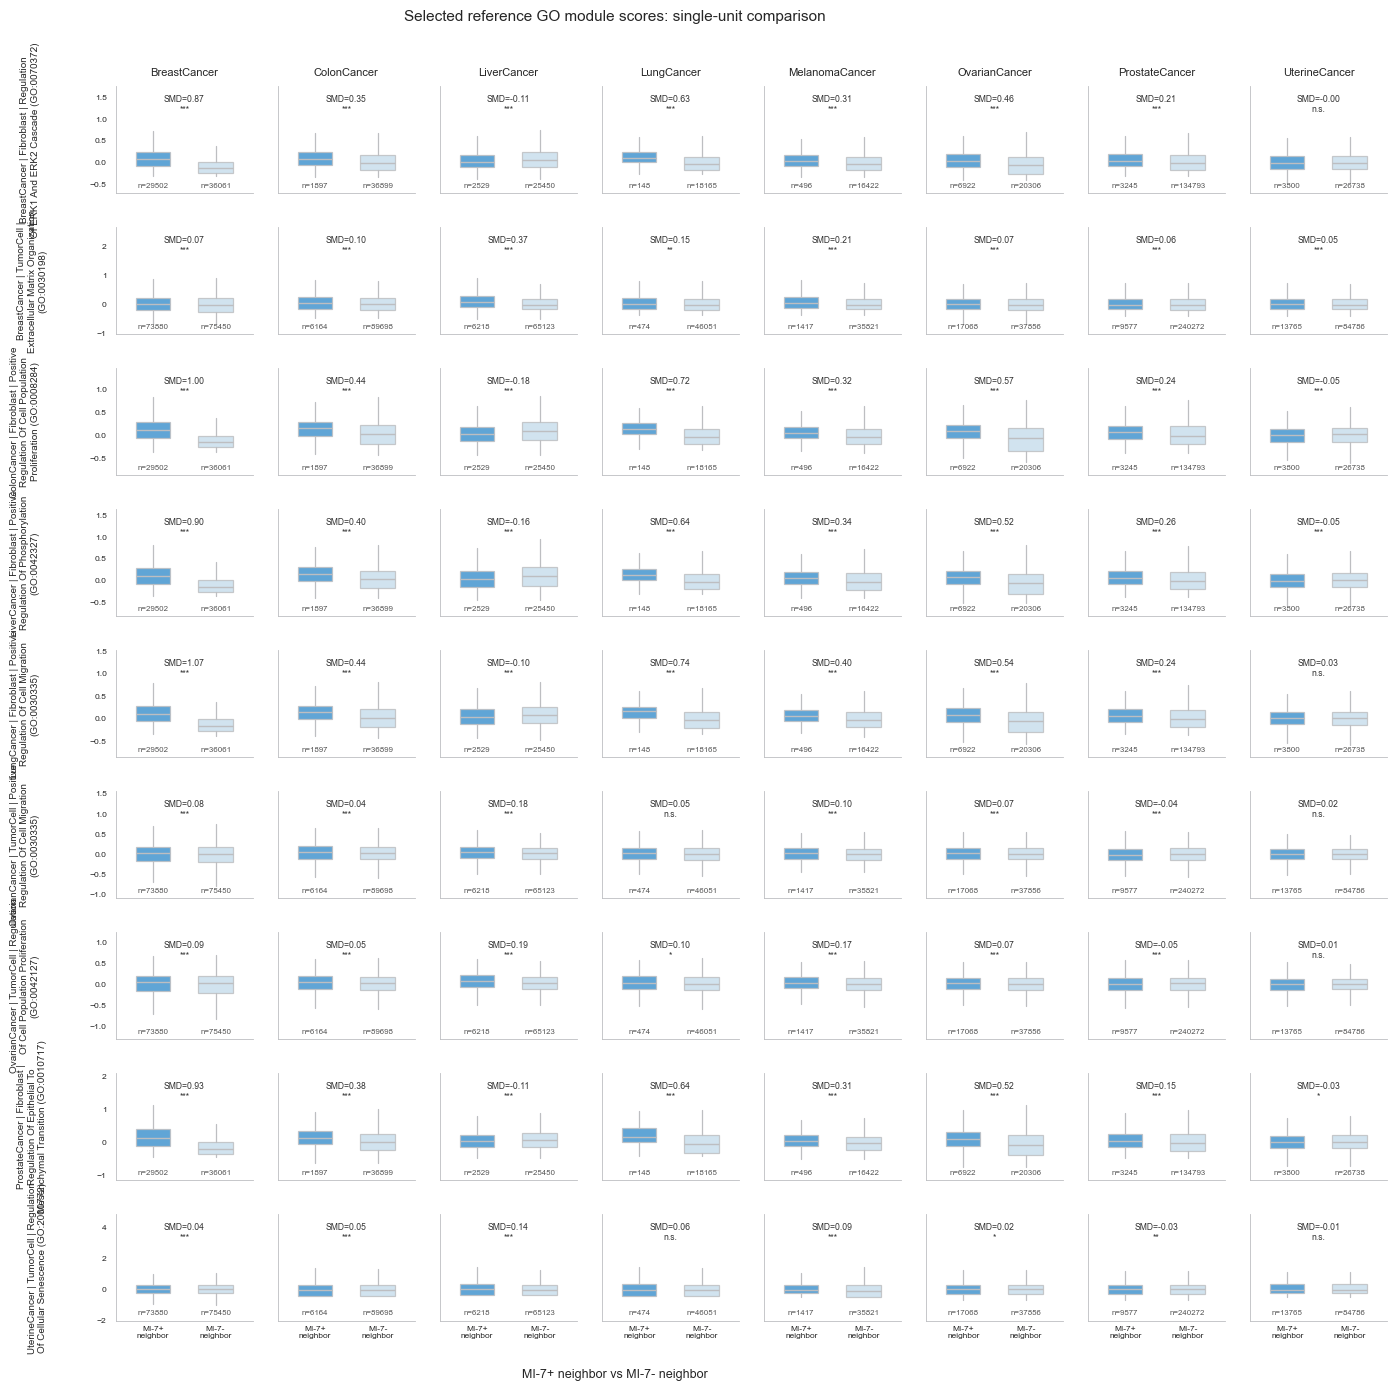

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_boxplots_allGOsets_by_allCancerTypes.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_boxplots_allGOsets_by_allCancerTypes.png


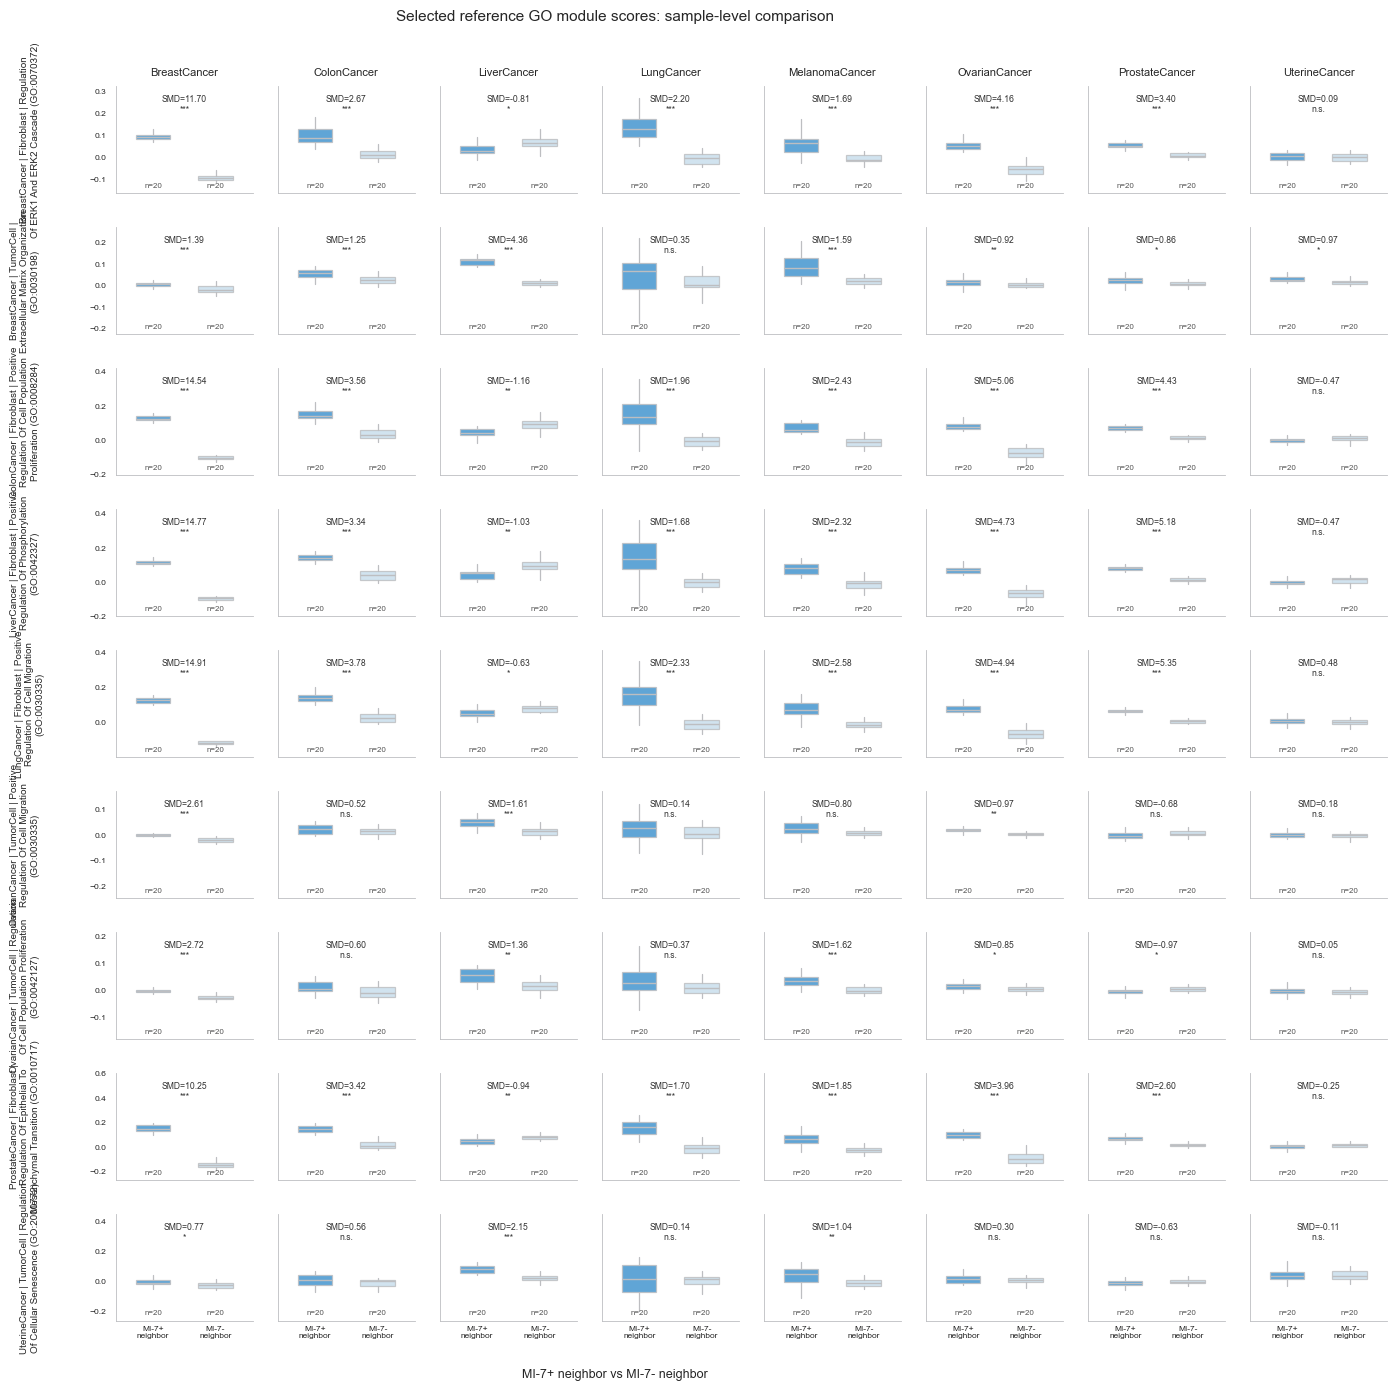

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_SMD_matrix_allGOsets_by_allCancerTypes.csv
Saved selected reference GO sample-level SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_SMD_matrix_allGOsets_by_allCancerTypes.csv


CancerType,BreastCancer,ColonCancer,LiverCancer,LungCancer,MelanomaCancer,OvarianCancer,ProstateCancer,UterineCancer
ReferenceGORowLabel,,,,,,,,
BreastCancer | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),11.702707,2.667281,-0.806004,2.200370,1.690358,4.164470,3.400731,0.085534
BreastCancer | TumorCell | Extracellular Matrix Organization (GO:0030198),1.385879,1.254382,4.363906,0.354689,1.586877,0.917427,0.864886,0.970211
ColonCancer | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),14.537010,3.555102,-1.155839,1.959495,2.433047,5.064364,4.434669,-0.465575
LiverCancer | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),14.767803,3.339549,-1.027656,1.679838,2.323410,4.732299,5.178752,-0.473525
LungCancer | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),14.913453,3.781664,-0.634636,2.333401,2.578055,4.935740,5.351049,0.476941
OvarianCancer | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),2.607826,0.521098,1.607392,0.143341,0.795575,0.972735,-0.680296,0.183120
OvarianCancer | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),2.722850,0.603872,1.363432,0.369408,1.622026,0.846332,-0.974022,0.045922
ProstateCancer | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),10.252005,3.422301,-0.942141,1.699995,1.848132,3.960380,2.604188,-0.246291
UterineCancer | TumorCell | Regulation Of Cellular Senescence (GO:2000772),0.768100,0.560966,2.150594,0.139554,1.043775,0.303058,-0.630934,-0.113031


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_SMD_termwise_maxnorm_matrix_allGOsets_by_allCancerTypes.csv
Saved selected reference GO sample-level term-wise max-normalized SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\selected_reference_go_sample_level_SMD_termwise_maxnorm_matrix_allGOsets_by_allCancerTypes.csv


CancerType,BreastCancer,ColonCancer,LiverCancer,LungCancer,MelanomaCancer,OvarianCancer,ProstateCancer,UterineCancer
ReferenceGORowLabel,,,,,,,,
BreastCancer | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),1.000000,0.227920,-0.068873,0.188022,0.144442,0.355855,0.290594,0.007309
BreastCancer | TumorCell | Extracellular Matrix Organization (GO:0030198),0.317578,0.287445,1.000000,0.081278,0.363637,0.210231,0.198191,0.222326
ColonCancer | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),1.000000,0.244555,-0.079510,0.134794,0.167369,0.348377,0.305061,-0.032027
LiverCancer | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),1.000000,0.226137,-0.069588,0.113750,0.157329,0.320447,0.350679,-0.032065
LungCancer | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),1.000000,0.253574,-0.042555,0.156463,0.172868,0.330959,0.358807,0.031981
OvarianCancer | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),1.000000,0.199821,0.616373,0.054966,0.305072,0.373006,-0.260867,0.070219
OvarianCancer | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),1.000000,0.221779,0.500737,0.135670,0.595709,0.310826,-0.357722,0.016866
ProstateCancer | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),1.000000,0.333818,-0.091898,0.165821,0.180270,0.386303,0.254017,-0.024024
UterineCancer | TumorCell | Regulation Of Cellular Senescence (GO:2000772),0.357157,0.260843,1.000000,0.064891,0.485343,0.140918,-0.293377,-0.052558


Done.
Selected reference GO cell-level records: reference_go_records_for_stats
Selected reference GO single-unit stats: reference_single_unit_stats_df
Selected reference GO sample-level scores: reference_sample_level_feature_df
Selected reference GO sample-level stats: reference_sample_level_stats_df
Selected reference GO sample-level SMD table: reference_module_smd_df
Selected reference GO SMD matrix: reference_go_smd_matrix_df
Selected reference GO term-wise max-normalized SMD matrix: reference_go_smd_maxnorm_matrix_df


In [28]:
# ==============================================================
# Statistics, sample-level aggregation and geneset × cancer-type boxplots
# for selected reference GO terms applied across ALL cancer types
# --------------------------------------------------------------
# Output layout:
#   rows    = selected reference GO gene sets
#             ReferenceCancerType | CellSide | GO term
#   columns = applied/current CancerType
#   each panel = MI-7+ neighbor vs MI-7- neighbor boxplot
#
# The preceding reference GO scoring cell generates:
#   reference_feature_records_upstream_gated
# with:
#   CancerType          = applied/current cancer type
#   ReferenceCancerType = source cancer type of the selected GO geneset
# ==============================================================

import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import mannwhitneyu
except Exception:
    mannwhitneyu = None

try:
    from statsmodels.stats.multitest import multipletests
except Exception:
    multipletests = None


# ==============================================================
# Required objects
# ==============================================================

required_stats_objects = [
    "reference_feature_records_upstream_gated",
    "reference_go_outdir",
    "UPSTREAM_GATED_GROUPS",
    "GROUP_COLORS_UPSTREAM_GATED",
    "PRETTY_GROUP_LABELS_UPSTREAM_GATED",
]

missing = [name for name in required_stats_objects if name not in globals()]
if missing:
    raise NameError("Missing required objects/functions: " + ", ".join(missing))

if reference_feature_records_upstream_gated.empty:
    raise ValueError("reference_feature_records_upstream_gated is empty.")


# ==============================================================
# User parameters
# ==============================================================

REFERENCE_GO_GRID_PLOT_LEVELS = ("single_unit", "sample_level")
# Options:
#   ("single_unit",)
#   ("sample_level",)
#   ("single_unit", "sample_level")

REFERENCE_GO_GRID_TERM_WRAP_WIDTH = 38
REFERENCE_GO_GRID_CANCER_LABEL_WRAP_WIDTH = 18

REFERENCE_GO_GRID_CELL_WIDTH = 1.95
REFERENCE_GO_GRID_CELL_HEIGHT = 1.55

REFERENCE_GO_GRID_MIN_FIG_WIDTH = 12.0
REFERENCE_GO_GRID_MIN_FIG_HEIGHT = 5.5

REFERENCE_GO_GRID_SAVE_FIGURES = True
REFERENCE_GO_GRID_SHOW_FIGURES = True

REFERENCE_GO_GRID_USE_ROWWISE_YLIM = True
# True: same y-limit across cancer types within each selected GO geneset row.
# False: each panel uses its own y-limit.

REFERENCE_GO_GRID_DPI = 300

REFERENCE_GO_GRID_SHOW_GROUP_LABELS_EVERY_ROW = False
# False: only bottom row shows MI-7+ / MI-7- labels.
# True: every panel shows group labels.

REFERENCE_GO_GRID_STAT_USE_BH_STAR = True
# True: stars use BH adjustment across all available gene-set/cancer-type tests per level.
# False: stars are based on raw Mann-Whitney U P values.


# ==============================================================
# Local helpers
# ==============================================================

def _reference_go_safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)


def _reference_go_wrap(x, width=34):
    x = _reference_go_safe_str(x)
    return "\n".join(
        textwrap.wrap(
            x,
            width=int(width),
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


def _reference_go_p_to_star(p):
    if pd.isna(p):
        return "n.s."
    try:
        p = float(p)
    except Exception:
        return "n.s."

    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def _reference_go_smd(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) < 2 or len(y) < 2:
        return np.nan

    nx = len(x)
    ny = len(y)

    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    pooled = ((nx - 1) * vx + (ny - 1) * vy) / max(nx + ny - 2, 1)

    if not np.isfinite(pooled) or pooled <= 0:
        return np.nan

    return (np.mean(x) - np.mean(y)) / np.sqrt(pooled)


def _reference_go_mwu_pvalue(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) == 0 or len(y) == 0:
        return np.nan

    if mannwhitneyu is None:
        return np.nan

    try:
        return float(
            mannwhitneyu(
                x,
                y,
                alternative="two-sided",
                method="asymptotic",
            ).pvalue
        )
    except TypeError:
        return float(
            mannwhitneyu(
                x,
                y,
                alternative="two-sided",
            ).pvalue
        )
    except Exception:
        return np.nan


def _reference_go_bh_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    qvalues = np.full_like(pvalues, np.nan, dtype=float)

    valid = np.isfinite(pvalues)

    if valid.sum() == 0:
        return qvalues

    if multipletests is not None:
        qvalues[valid] = multipletests(pvalues[valid], method="fdr_bh")[1]
        return qvalues

    # Fallback BH implementation.
    p = pvalues[valid]
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]

    q_ranked = ranked * n / (np.arange(n) + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)

    q = np.empty_like(q_ranked)
    q[order] = q_ranked
    qvalues[valid] = q

    return qvalues


def _reference_go_boxplot_limits_from_values(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return -1.0, 1.0

    if len(values) == 1:
        center = float(values[0])
        pad = max(abs(center) * 0.25, 0.25)
        return center - pad, center + pad

    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1

    lower = np.min(values) if iqr <= 0 else max(np.min(values), q1 - 1.5 * iqr)
    upper = np.max(values) if iqr <= 0 else min(np.max(values), q3 + 1.5 * iqr)

    lower = min(lower, np.min(values))
    upper = max(upper, np.max(values))

    if not np.isfinite(lower) or not np.isfinite(upper) or lower == upper:
        center = np.nanmean(values)
        pad = max(abs(center) * 0.25, 0.25)
        return center - pad, center + pad

    pad = 0.12 * (upper - lower)
    pad = max(pad, 0.05)

    return float(lower - pad), float(upper + pad)


def _reference_go_save_figure_pair_local(fig, output_prefix, dpi=300, bbox_inches="tight"):
    output_prefix = Path(output_prefix)
    output_prefix.parent.mkdir(parents=True, exist_ok=True)

    png_path = output_prefix.with_suffix(".png")
    pdf_path = output_prefix.with_suffix(".pdf")

    fig.savefig(png_path, dpi=dpi, bbox_inches=bbox_inches)
    fig.savefig(pdf_path, bbox_inches=bbox_inches)

    print(f"Saved figure: {png_path}")
    print(f"Saved figure: {pdf_path}")


def _reference_go_to_csv_local(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path


_reference_go_save_figure_pair_use = (
    _reference_go_save_figure_pair
    if "_reference_go_save_figure_pair" in globals()
    else _reference_go_save_figure_pair_local
)

_reference_go_to_csv_use = (
    _reference_go_to_csv
    if "_reference_go_to_csv" in globals()
    else _reference_go_to_csv_local
)


# ==============================================================
# Prepare plotting/statistics table
# ==============================================================

reference_go_records_for_stats = reference_feature_records_upstream_gated.copy()

reference_go_records_for_stats["value"] = pd.to_numeric(
    reference_go_records_for_stats["value"],
    errors="coerce",
)

reference_go_records_for_stats = reference_go_records_for_stats.dropna(
    subset=[
        "value",
        "CancerType",
        "ReferenceCancerType",
        "CellSide",
        "Term",
        "group",
    ]
).copy()

for c in [
    "CancerType",
    "ReferenceCancerType",
    "CellSide",
    "LibraryShort",
    "Term",
    "TermBase",
    "group",
]:
    if c in reference_go_records_for_stats.columns:
        reference_go_records_for_stats[c] = reference_go_records_for_stats[c].astype(str)

if "AppliedCancerType" not in reference_go_records_for_stats.columns:
    reference_go_records_for_stats["AppliedCancerType"] = reference_go_records_for_stats["CancerType"].astype(str)

if "ReferenceGOSetKey" not in reference_go_records_for_stats.columns:
    reference_go_records_for_stats["ReferenceGOSetKey"] = (
        reference_go_records_for_stats["ReferenceCancerType"].astype(str)
        + "__"
        + reference_go_records_for_stats["CellSide"].astype(str)
        + "__"
        + reference_go_records_for_stats["LibraryShort"].astype(str)
        + "__"
        + reference_go_records_for_stats["Term"].astype(str)
    )

if "ReferenceGOSetLabel" not in reference_go_records_for_stats.columns:
    reference_go_records_for_stats["ReferenceGOSetLabel"] = (
        reference_go_records_for_stats["ReferenceCancerType"].astype(str)
        + " | "
        + reference_go_records_for_stats["CellSide"].astype(str)
        + " | "
        + reference_go_records_for_stats["Term"].astype(str)
    )

# Compatibility aliases.
reference_go_records_for_stats["ReferenceGORowKey"] = reference_go_records_for_stats["ReferenceGOSetKey"].astype(str)
reference_go_records_for_stats["ReferenceGORowLabel"] = reference_go_records_for_stats["ReferenceGOSetLabel"].astype(str)


# ==============================================================
# Cancer-type order
# ==============================================================

default_cancer_order = [
    "BreastCancer",
    "ColonCancer",
    "LiverCancer",
    "LungCancer",
    "MelanomaCancer",
    "OvarianCancer",
    "ProstateCancer",
    "UterineCancer",
]

candidate_order_names = [
    "CANCER_TYPE_ORDER",
    "CANCER_TYPES_ORDER",
    "cancer_type_order",
    "cancer_types_order",
    "CASCADE_CANCER_TYPE_ORDER",
]

cancer_type_order = None

for order_name in candidate_order_names:
    if order_name in globals():
        try:
            tmp_order = list(globals()[order_name])
            if len(tmp_order) > 0:
                cancer_type_order = [str(x) for x in tmp_order]
                break
        except Exception:
            pass

present_cancers = (
    reference_go_records_for_stats["CancerType"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

if cancer_type_order is None:
    cancer_type_order = [x for x in default_cancer_order if x in present_cancers]
    cancer_type_order += sorted([x for x in present_cancers if x not in cancer_type_order])
else:
    cancer_type_order = [x for x in cancer_type_order if x in set(present_cancers)]
    cancer_type_order += sorted([x for x in present_cancers if x not in set(cancer_type_order)])

if len(cancer_type_order) == 0:
    raise ValueError("No CancerType values are available for plotting.")


# ==============================================================
# Row order: selected GO genesets
# ==============================================================

row_meta_df = (
    reference_go_records_for_stats
    .groupby("ReferenceGORowKey", as_index=False, observed=True)
    .agg(
        SelectedOrder=("SelectedOrder", "min"),
        ReferenceCancerType=("ReferenceCancerType", "first"),
        CellSide=("CellSide", "first"),
        LibraryShort=("LibraryShort", "first"),
        Term=("Term", "first"),
        TermBase=("TermBase", "first"),
        ReferenceGORowLabel=("ReferenceGORowLabel", "first"),
        n_applied_cancertypes=("CancerType", "nunique"),
    )
    .sort_values(
        ["SelectedOrder", "ReferenceCancerType", "CellSide", "Term"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

reference_go_row_order = row_meta_df["ReferenceGORowKey"].tolist()

print("Selected reference GO rows:")
display(row_meta_df)

print("\nCoverage check: selected reference GO geneset × applied CancerType")
coverage_df = (
    reference_go_records_for_stats
    .groupby(["ReferenceGORowLabel", "CancerType"], observed=True)
    .size()
    .rename("n_records")
    .reset_index()
    .pivot_table(
        index="ReferenceGORowLabel",
        columns="CancerType",
        values="n_records",
        fill_value=0,
        aggfunc="sum",
    )
    .reindex(row_meta_df["ReferenceGORowLabel"].tolist())
    .reindex(cancer_type_order, axis=1)
)
display(coverage_df)


# ==============================================================
# Statistics helper
# ==============================================================

reference_go_meta_cols_for_stats = [
    "feature_category",
    "feature",
    "CancerType",
    "AppliedCancerType",
    "ReferenceCancerType",
    "CellSide",
    "Library",
    "LibraryShort",
    "Term",
    "TermBase",
    "TermQuery",
    "TermKey",
    "ReferenceGOSetKey",
    "ReferenceGOSetLabel",
    "ReferenceGORowKey",
    "ReferenceGORowLabel",
    "SelectedOrder",
    "n_reference_genes_raw",
    "n_genes_used",
]

reference_go_meta_cols_for_stats = [
    c for c in reference_go_meta_cols_for_stats
    if c in reference_go_records_for_stats.columns
]


def _make_reference_go_geneset_by_cancertype_stats(df, value_col="value", level="single_unit"):
    records = []

    group_order = [str(x) for x in UPSTREAM_GATED_GROUPS]
    if len(group_order) != 2:
        raise ValueError("UPSTREAM_GATED_GROUPS must contain exactly two groups.")

    group_a, group_b = group_order[0], group_order[1]

    group_cols = [
        "ReferenceGORowKey",
        "CancerType",
    ]

    for (row_key, cancer_type), sub in df.groupby(group_cols, observed=True, sort=False):
        sub = sub.dropna(subset=[value_col]).copy()

        vals_a = sub.loc[
            sub["group"].astype(str).eq(group_a),
            value_col,
        ].to_numpy(dtype=float)

        vals_b = sub.loc[
            sub["group"].astype(str).eq(group_b),
            value_col,
        ].to_numpy(dtype=float)

        vals_a = vals_a[np.isfinite(vals_a)]
        vals_b = vals_b[np.isfinite(vals_b)]

        meta = (
            sub[reference_go_meta_cols_for_stats]
            .drop_duplicates()
            .sort_values(
                [
                    c for c in [
                        "SelectedOrder",
                        "ReferenceCancerType",
                        "CellSide",
                        "Term",
                        "CancerType",
                    ]
                    if c in sub.columns
                ],
                kind="mergesort",
            )
            .iloc[0]
            .to_dict()
        )

        smd = _reference_go_smd(vals_a, vals_b)
        pvalue = _reference_go_mwu_pvalue(vals_a, vals_b)

        rec = dict(meta)
        rec.update({
            "level": level,
            "group_a": group_a,
            "group_b": group_b,
            "n_group_a": int(len(vals_a)),
            "n_group_b": int(len(vals_b)),
            "mean_group_a": float(np.mean(vals_a)) if len(vals_a) > 0 else np.nan,
            "mean_group_b": float(np.mean(vals_b)) if len(vals_b) > 0 else np.nan,
            "median_group_a": float(np.median(vals_a)) if len(vals_a) > 0 else np.nan,
            "median_group_b": float(np.median(vals_b)) if len(vals_b) > 0 else np.nan,
            "SMD": smd,
            "pvalue": pvalue,
            "pvalue_star": _reference_go_p_to_star(pvalue),
        })

        records.append(rec)

    stats_df = pd.DataFrame(records)

    if stats_df.empty:
        return stats_df

    stats_df["pvalue_adj_BH"] = _reference_go_bh_adjust(stats_df["pvalue"].to_numpy(dtype=float))
    stats_df["pvalue_adj_BH_star"] = stats_df["pvalue_adj_BH"].map(_reference_go_p_to_star)

    stats_df = (
        stats_df
        .sort_values(
            [
                c for c in [
                    "SelectedOrder",
                    "ReferenceCancerType",
                    "CellSide",
                    "Term",
                    "CancerType",
                ]
                if c in stats_df.columns
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    return stats_df


# ==============================================================
# Single-unit statistics
# ==============================================================

reference_single_unit_stats_df = _make_reference_go_geneset_by_cancertype_stats(
    reference_go_records_for_stats,
    value_col="value",
    level="single_unit",
)

reference_single_unit_stats_path = _reference_go_to_csv_use(
    reference_single_unit_stats_df,
    reference_go_outdir / "selected_reference_go_single_unit_stats_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"\nSaved selected reference GO single-unit statistics: {reference_single_unit_stats_path}")
display(reference_single_unit_stats_df)


# ==============================================================
# Sample-level aggregation and statistics
# ==============================================================

reference_sample_level_feature_df = (
    reference_go_records_for_stats
    .dropna(subset=["value"])
    .groupby(
        [
            "feature_category",
            "feature",
            "CancerType",
            "AppliedCancerType",
            "ReferenceCancerType",
            "CellSide",
            "Library",
            "LibraryShort",
            "Term",
            "TermBase",
            "TermQuery",
            "TermKey",
            "ReferenceGOSetKey",
            "ReferenceGOSetLabel",
            "ReferenceGORowKey",
            "ReferenceGORowLabel",
            "SelectedOrder",
            "sample_index",
            "sample_name",
            "group",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        sample_mean_score=("value", "mean"),
        sample_median_score=("value", "median"),
        n_units=("value", "size"),
        n_genes_used=("n_genes_used", "max"),
        n_reference_genes_raw=("n_reference_genes_raw", "max"),
    )
)

reference_sample_level_feature_path = _reference_go_to_csv_use(
    reference_sample_level_feature_df,
    reference_go_outdir / "selected_reference_go_sample_level_scores_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"Saved selected reference GO sample-level scores: {reference_sample_level_feature_path}")

reference_sample_level_plot_df = reference_sample_level_feature_df.rename(
    columns={"sample_mean_score": "value"}
).copy()

reference_sample_level_stats_df = _make_reference_go_geneset_by_cancertype_stats(
    reference_sample_level_plot_df,
    value_col="value",
    level="sample_level",
)

reference_sample_level_stats_path = _reference_go_to_csv_use(
    reference_sample_level_stats_df,
    reference_go_outdir / "selected_reference_go_sample_level_stats_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"Saved selected reference GO sample-level statistics: {reference_sample_level_stats_path}")
display(reference_sample_level_stats_df)

# Main downstream SMD table for selected reference GO heatmap.
reference_module_smd_df = reference_sample_level_stats_df.copy()


# ==============================================================
# Plotting function: geneset × applied cancer type
# ==============================================================

def plot_reference_go_geneset_by_cancertype_grid(
    df,
    value_col="value",
    stats_df=None,
    level_label="single-unit",
    ylabel="module score",
    output_prefix=None,
    show=True,
):
    if df.empty:
        print(f"No data to plot for {level_label}.")
        return None

    plot_df = df.dropna(subset=[value_col]).copy()
    plot_df["CancerType"] = plot_df["CancerType"].astype(str)
    plot_df["ReferenceGORowKey"] = plot_df["ReferenceGORowKey"].astype(str)
    plot_df["ReferenceGORowLabel"] = plot_df["ReferenceGORowLabel"].astype(str)
    plot_df["group"] = plot_df["group"].astype(str)

    n_rows = len(reference_go_row_order)
    n_cols = len(cancer_type_order)

    if n_rows == 0 or n_cols == 0:
        print("No selected rows or cancer types available for plotting.")
        return None

    fig_w = max(REFERENCE_GO_GRID_CELL_WIDTH * n_cols, REFERENCE_GO_GRID_MIN_FIG_WIDTH)
    fig_h = max(REFERENCE_GO_GRID_CELL_HEIGHT * n_rows, REFERENCE_GO_GRID_MIN_FIG_HEIGHT)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        sharex=False,
        sharey=False,
    )

    fig.patch.set_facecolor("white")

    group_order = [str(x) for x in UPSTREAM_GATED_GROUPS]

    # Row-wise y-limits.
    row_ylim = {}
    for row_key in reference_go_row_order:
        row_vals = plot_df.loc[
            plot_df["ReferenceGORowKey"].astype(str).eq(str(row_key)),
            value_col,
        ].to_numpy(dtype=float)

        row_ylim[row_key] = _reference_go_boxplot_limits_from_values(row_vals)

    for row_i, row_key in enumerate(reference_go_row_order):
        row_meta = row_meta_df.loc[
            row_meta_df["ReferenceGORowKey"].astype(str).eq(str(row_key))
        ].iloc[0]

        row_label = str(row_meta["ReferenceGORowLabel"])

        for col_i, cancer_type in enumerate(cancer_type_order):
            ax = axes[row_i, col_i]
            ax.set_facecolor("white")

            if row_i == 0:
                ax.set_title(
                    _reference_go_wrap(cancer_type, REFERENCE_GO_GRID_CANCER_LABEL_WRAP_WIDTH),
                    fontsize=8,
                    pad=8,
                )

            sub = plot_df.loc[
                plot_df["ReferenceGORowKey"].astype(str).eq(str(row_key))
                & plot_df["CancerType"].astype(str).eq(str(cancer_type))
            ].copy()

            if sub.empty:
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)

                if col_i == 0:
                    ax.set_ylabel(
                        _reference_go_wrap(row_label, REFERENCE_GO_GRID_TERM_WRAP_WIDTH),
                        fontsize=7.1,
                        labelpad=36,
                    )
                continue

            data = []
            ns = []

            for group in group_order:
                vals = sub.loc[
                    sub["group"].astype(str).eq(str(group)),
                    value_col,
                ].to_numpy(dtype=float)

                vals = vals[np.isfinite(vals)]
                data.append(vals)
                ns.append(int(len(vals)))

            if REFERENCE_GO_GRID_USE_ROWWISE_YLIM:
                ymin, ymax = row_ylim[row_key]
            else:
                all_panel_vals = (
                    np.concatenate([x for x in data if len(x) > 0])
                    if any(len(x) > 0 for x in data)
                    else np.array([])
                )
                ymin, ymax = _reference_go_boxplot_limits_from_values(all_panel_vals)

            ax.set_ylim(ymin, ymax)
            ax.set_xlim(0.4, 2.6)

            if all(n > 0 for n in ns):
                bp = ax.boxplot(
                    data,
                    positions=[1, 2],
                    widths=0.55,
                    patch_artist=True,
                    showfliers=False,
                    medianprops={"color": "#bdbec1", "linewidth": 1.0},
                    boxprops={"edgecolor": "#bdbec1", "linewidth": 0.9},
                    whiskerprops={"color": "#bdbec1", "linewidth": 0.9},
                    capprops={"color": "#bdbec1", "linewidth": 0.0},
                )

                for patch, group in zip(bp["boxes"], group_order):
                    patch.set_facecolor(GROUP_COLORS_UPSTREAM_GATED[group])
                    patch.set_alpha(0.82)
                    patch.set_edgecolor("#bdbec1")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "missing\ngroup",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=6.5,
                    color="#777777",
                )

            # n labels
            y_n = ymin + 0.045 * (ymax - ymin)

            for xpos, n in zip([1, 2], ns):
                ax.text(
                    xpos,
                    y_n,
                    f"n={n}",
                    ha="center",
                    va="bottom",
                    fontsize=5.7,
                    color="#555555",
                )

            # SMD and significance
            smd_text = None
            pstar = None

            if stats_df is not None and not stats_df.empty:
                hit = stats_df.loc[
                    stats_df["ReferenceGORowKey"].astype(str).eq(str(row_key))
                    & stats_df["CancerType"].astype(str).eq(str(cancer_type))
                ]

                if hit.shape[0] > 0:
                    if "SMD" in hit.columns and pd.notna(hit["SMD"].iloc[0]):
                        smd_text = f"SMD={hit['SMD'].iloc[0]:.2f}"

                    if REFERENCE_GO_GRID_STAT_USE_BH_STAR:
                        if "pvalue_adj_BH_star" in hit.columns and pd.notna(hit["pvalue_adj_BH_star"].iloc[0]):
                            pstar = str(hit["pvalue_adj_BH_star"].iloc[0])
                    else:
                        if "pvalue_star" in hit.columns and pd.notna(hit["pvalue_star"].iloc[0]):
                            pstar = str(hit["pvalue_star"].iloc[0])

            if smd_text is None:
                smd = _reference_go_smd(data[0], data[1])
                smd_text = f"SMD={smd:.2f}" if pd.notna(smd) else "SMD=NA"

            if pstar is None:
                pstar = _reference_go_p_to_star(_reference_go_mwu_pvalue(data[0], data[1]))

            ax.text(
                1.5,
                ymax - 0.075 * (ymax - ymin),
                f"{smd_text}\n{pstar}",
                ha="center",
                va="top",
                fontsize=6.2,
                color="#333333",
            )

            ax.set_xticks([1, 2])

            if REFERENCE_GO_GRID_SHOW_GROUP_LABELS_EVERY_ROW or row_i == n_rows - 1:
                ax.set_xticklabels(
                    [PRETTY_GROUP_LABELS_UPSTREAM_GATED[g] for g in group_order],
                    fontsize=6,
                    rotation=0,
                )
            else:
                ax.set_xticklabels([])

            if col_i == 0:
                ax.set_ylabel(
                    _reference_go_wrap(row_label, REFERENCE_GO_GRID_TERM_WRAP_WIDTH),
                    fontsize=7.1,
                    labelpad=36,
                )
                ax.tick_params(axis="y", labelsize=6.1)
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis="y", length=0)

            ax.tick_params(axis="x", length=0)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.spines["left"].set_color("#bdbec1")
            ax.spines["bottom"].set_color("#bdbec1")
            ax.spines["left"].set_linewidth(0.6)
            ax.spines["bottom"].set_linewidth(0.6)

    fig.suptitle(
        f"Selected reference GO module scores: {level_label} comparison",
        fontsize=11,
        y=0.995,
    )

    fig.text(
        0.5,
        0.012,
        "MI-7+ neighbor vs MI-7- neighbor",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    fig.subplots_adjust(
        left=0.18,
        right=0.995,
        top=0.94,
        bottom=0.055,
        wspace=0.18,
        hspace=0.32,
    )

    if output_prefix is not None and REFERENCE_GO_GRID_SAVE_FIGURES:
        _reference_go_save_figure_pair_use(
            fig,
            output_prefix,
            dpi=REFERENCE_GO_GRID_DPI,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


# ==============================================================
# Plot selected reference GO geneset × applied cancer-type grids
# ==============================================================

if "single_unit" in REFERENCE_GO_GRID_PLOT_LEVELS:
    plot_reference_go_geneset_by_cancertype_grid(
        reference_go_records_for_stats,
        value_col="value",
        stats_df=reference_single_unit_stats_df,
        level_label="single-unit",
        ylabel="single-unit module score",
        output_prefix=reference_go_outdir / "selected_reference_go_single_unit_boxplots_allGOsets_by_allCancerTypes",
        show=REFERENCE_GO_GRID_SHOW_FIGURES,
    )

if "sample_level" in REFERENCE_GO_GRID_PLOT_LEVELS:
    plot_reference_go_geneset_by_cancertype_grid(
        reference_sample_level_plot_df,
        value_col="value",
        stats_df=reference_sample_level_stats_df,
        level_label="sample-level",
        ylabel="sample-level mean module score",
        output_prefix=reference_go_outdir / "selected_reference_go_sample_level_boxplots_allGOsets_by_allCancerTypes",
        show=REFERENCE_GO_GRID_SHOW_FIGURES,
    )


# ==============================================================
# SMD matrices
# ==============================================================

reference_go_smd_matrix_df = (
    reference_sample_level_stats_df
    .pivot_table(
        index="ReferenceGORowLabel",
        columns="CancerType",
        values="SMD",
        aggfunc="first",
    )
    .reindex(row_meta_df["ReferenceGORowLabel"].tolist(), axis=0)
    .reindex(cancer_type_order, axis=1)
)

reference_go_smd_matrix_path = _reference_go_to_csv_use(
    reference_go_smd_matrix_df.reset_index(),
    reference_go_outdir / "selected_reference_go_sample_level_SMD_matrix_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"Saved selected reference GO sample-level SMD matrix: {reference_go_smd_matrix_path}")
display(reference_go_smd_matrix_df)


# Term-wise max-normalized SMD matrix.
reference_go_smd_maxnorm_matrix_df = reference_go_smd_matrix_df.copy()

for idx in reference_go_smd_maxnorm_matrix_df.index:
    vals = reference_go_smd_maxnorm_matrix_df.loc[idx].to_numpy(dtype=float)
    max_abs = np.nanmax(np.abs(vals)) if np.isfinite(vals).any() else np.nan

    if pd.notna(max_abs) and max_abs > 0:
        reference_go_smd_maxnorm_matrix_df.loc[idx] = reference_go_smd_maxnorm_matrix_df.loc[idx] / max_abs

reference_go_smd_maxnorm_matrix_path = _reference_go_to_csv_use(
    reference_go_smd_maxnorm_matrix_df.reset_index(),
    reference_go_outdir / "selected_reference_go_sample_level_SMD_termwise_maxnorm_matrix_allGOsets_by_allCancerTypes.csv",
    index=False,
)

print(f"Saved selected reference GO sample-level term-wise max-normalized SMD matrix: {reference_go_smd_maxnorm_matrix_path}")
display(reference_go_smd_maxnorm_matrix_df)


print("Done.")
print("Selected reference GO cell-level records: reference_go_records_for_stats")
print("Selected reference GO single-unit stats: reference_single_unit_stats_df")
print("Selected reference GO sample-level scores: reference_sample_level_feature_df")
print("Selected reference GO sample-level stats: reference_sample_level_stats_df")
print("Selected reference GO sample-level SMD table: reference_module_smd_df")
print("Selected reference GO SMD matrix: reference_go_smd_matrix_df")
print("Selected reference GO term-wise max-normalized SMD matrix: reference_go_smd_maxnorm_matrix_df")

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_matrix_refCancerLabeled.csv
Saved selected reference GO SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_matrix_refCancerLabeled.csv


,BreastCancer ref | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer ref | TumorCell | Extracellular Matrix Organization (GO:0030198),ColonCancer ref | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),LiverCancer ref | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),LungCancer ref | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),ProstateCancer ref | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),UterineCancer ref | TumorCell | Regulation Of Cellular Senescence (GO:2000772)
CancerType,,,,,,,,,
BreastCancer,0.868213,0.073525,0.999484,0.898914,1.072360,0.082995,0.086853,0.927052,0.037261
ColonCancer,0.350119,0.100013,0.442552,0.401418,0.442041,0.039447,0.054850,0.379474,0.045627
LiverCancer,-0.108079,0.372864,-0.175007,-0.159513,-0.096191,0.177233,0.186578,-0.106743,0.135001
LungCancer,0.628153,0.154773,0.724776,0.641747,0.740738,0.051728,0.101230,0.641513,0.059023
MelanomaCancer,0.306253,0.212179,0.320768,0.336036,0.396729,0.097477,0.168621,0.307974,0.093782
OvarianCancer,0.457577,0.066558,0.566318,0.515419,0.542618,0.068555,0.066244,0.519776,0.022619
ProstateCancer,0.205500,0.057750,0.237874,0.261010,0.240622,-0.041878,-0.050049,0.154995,-0.027167
UterineCancer,-0.004264,0.052743,-0.054167,-0.052826,0.029437,0.017069,0.005906,-0.033207,-0.014784


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_heatmap_refCancerLabeled.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_heatmap_refCancerLabeled.png


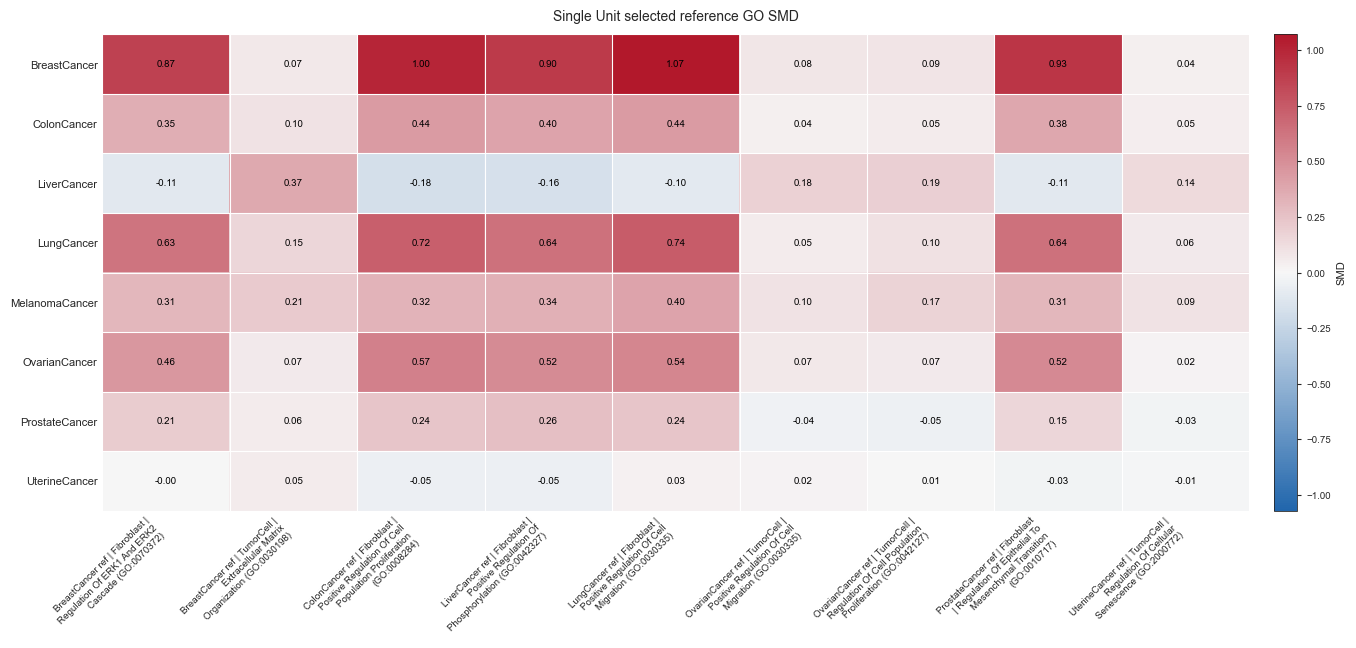

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_cancertype_wise_zscore_matrix_refCancerLabeled.csv
Saved selected reference GO cancer-type-wise z-scored SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_cancertype_wise_zscore_matrix_refCancerLabeled.csv


,BreastCancer ref | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer ref | TumorCell | Extracellular Matrix Organization (GO:0030198),ColonCancer ref | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),LiverCancer ref | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),LungCancer ref | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),ProstateCancer ref | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),UterineCancer ref | TumorCell | Regulation Of Cellular Senescence (GO:2000772)
CancerType,,,,,,,,,
BreastCancer,0.694993,-1.101268,0.991711,0.764388,1.156433,-1.079864,-1.071144,0.827990,-1.183238
ColonCancer,0.574113,-0.868946,1.107433,0.870099,1.104482,-1.218398,-1.129526,0.743484,-1.182741
LiverCancer,-0.722182,1.885273,-1.085037,-1.001037,-0.657732,0.824649,0.875316,-0.714940,0.595690
LungCancer,0.723056,-0.890040,1.052310,0.769382,1.106704,-1.241180,-1.072493,0.768582,-1.216320
MelanomaCancer,0.555121,-0.354931,0.695534,0.843233,1.430351,-1.464521,-0.776292,0.571766,-1.500261
OvarianCancer,0.617237,-1.063341,1.084599,0.865840,0.982739,-1.054757,-1.064693,0.884564,-1.252189
ProstateCancer,0.729354,-0.466755,0.991438,1.178732,1.013678,-1.273293,-1.339443,0.320490,-1.154203
UterineCancer,0.050620,1.702894,-1.395751,-1.356892,1.027394,0.668925,0.345374,-0.788265,-0.254299


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_cancertype_wise_zscore_heatmap_refCancerLabeled.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_single_unit_SMD_cancertype_wise_zscore_heatmap_refCancerLabeled.png


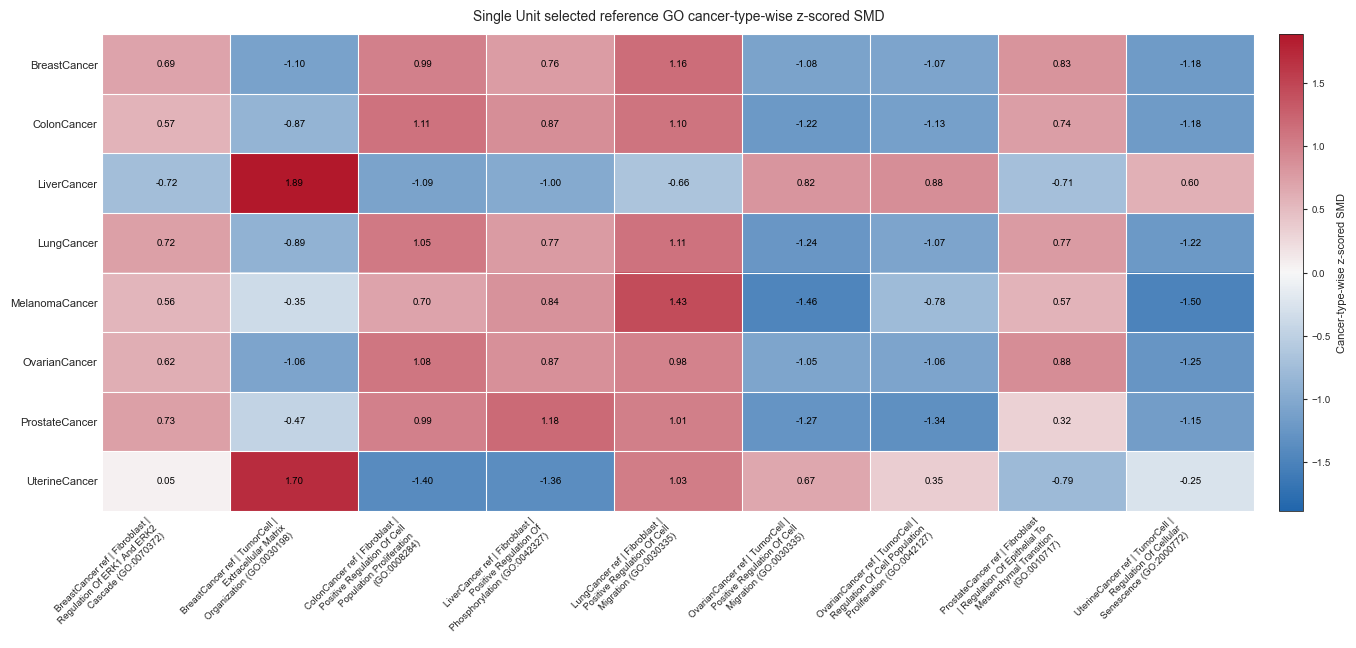

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_matrix_refCancerLabeled.csv
Saved selected reference GO SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_matrix_refCancerLabeled.csv


,BreastCancer ref | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer ref | TumorCell | Extracellular Matrix Organization (GO:0030198),ColonCancer ref | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),LiverCancer ref | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),LungCancer ref | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),ProstateCancer ref | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),UterineCancer ref | TumorCell | Regulation Of Cellular Senescence (GO:2000772)
CancerType,,,,,,,,,
BreastCancer,11.702707,1.385879,14.537010,14.767803,14.913453,2.607826,2.722850,10.252005,0.768100
ColonCancer,2.667281,1.254382,3.555102,3.339549,3.781664,0.521098,0.603872,3.422301,0.560966
LiverCancer,-0.806004,4.363906,-1.155839,-1.027656,-0.634636,1.607392,1.363432,-0.942141,2.150594
LungCancer,2.200370,0.354689,1.959495,1.679838,2.333401,0.143341,0.369408,1.699995,0.139554
MelanomaCancer,1.690358,1.586877,2.433047,2.323410,2.578055,0.795575,1.622026,1.848132,1.043775
OvarianCancer,4.164470,0.917427,5.064364,4.732299,4.935740,0.972735,0.846332,3.960380,0.303058
ProstateCancer,3.400731,0.864886,4.434669,5.178752,5.351049,-0.680296,-0.974022,2.604188,-0.630934
UterineCancer,0.085534,0.970211,-0.465575,-0.473525,0.476941,0.183120,0.045922,-0.246291,-0.113031


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_heatmap_refCancerLabeled.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_heatmap_refCancerLabeled.png


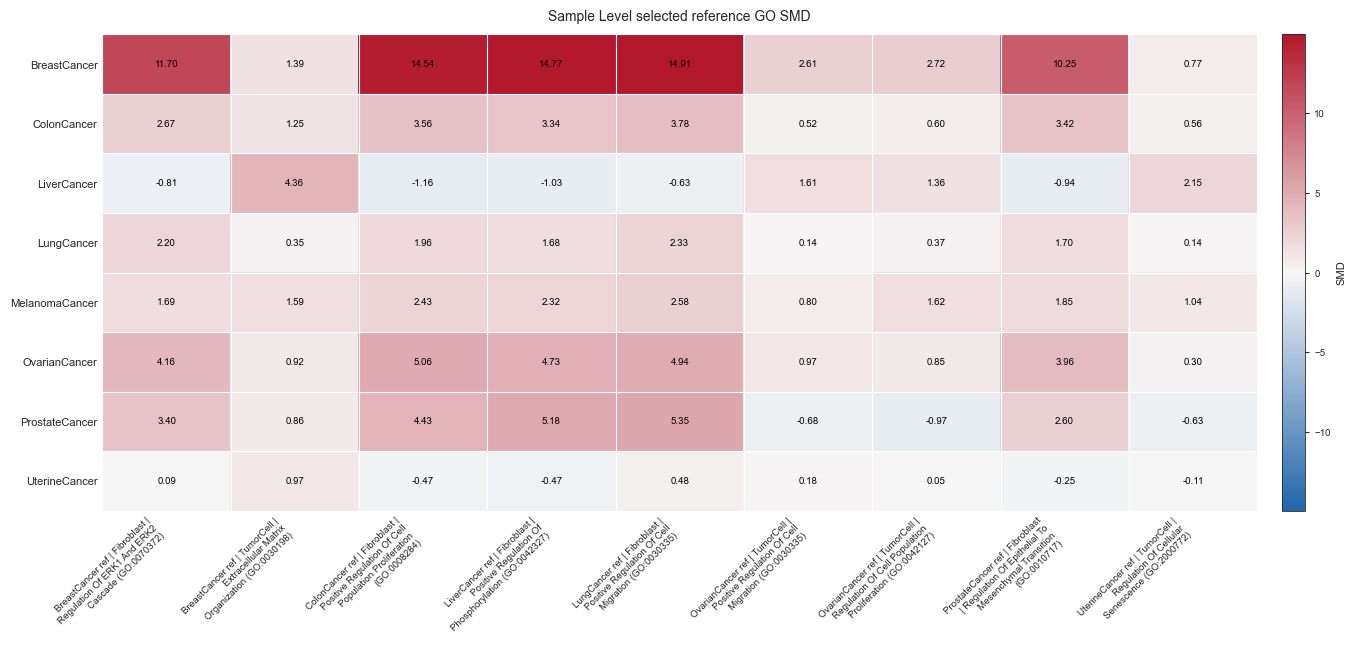

Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_cancertype_wise_zscore_matrix_refCancerLabeled.csv
Saved selected reference GO cancer-type-wise z-scored SMD matrix: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_cancertype_wise_zscore_matrix_refCancerLabeled.csv


,BreastCancer ref | Fibroblast | Regulation Of ERK1 And ERK2 Cascade (GO:0070372),BreastCancer ref | TumorCell | Extracellular Matrix Organization (GO:0030198),ColonCancer ref | Fibroblast | Positive Regulation Of Cell Population Proliferation (GO:0008284),LiverCancer ref | Fibroblast | Positive Regulation Of Phosphorylation (GO:0042327),LungCancer ref | Fibroblast | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Positive Regulation Of Cell Migration (GO:0030335),OvarianCancer ref | TumorCell | Regulation Of Cell Population Proliferation (GO:0042127),ProstateCancer ref | Fibroblast | Regulation Of Epithelial To Mesenchymal Transition (GO:0010717),UterineCancer ref | TumorCell | Regulation Of Cellular Senescence (GO:2000772)
CancerType,,,,,,,,,
BreastCancer,0.601676,-1.162526,1.086349,1.125815,1.150721,-0.953570,-0.933900,0.353603,-1.268167
ColonCancer,0.355020,-0.695022,1.014832,0.854638,1.183210,-1.239987,-1.178470,0.916137,-1.210357
LiverCancer,-0.743875,2.099440,-0.936275,-0.865778,-0.649628,0.583429,0.449258,-0.818747,0.882176
LungCancer,1.125251,-0.969470,0.851875,0.534483,1.276233,-1.209335,-0.952765,0.557360,-1.213633
MelanomaCancer,-0.137560,-0.318502,1.161075,0.969369,1.414631,-1.702140,-0.257043,0.138318,-1.268148
OvarianCancer,0.666991,-1.015735,1.133346,0.961259,1.066689,-0.987073,-1.052579,0.561225,-1.334122
ProstateCancer,0.503632,-0.535855,0.927460,1.232473,1.303100,-1.169252,-1.289655,0.177115,-1.149018
UterineCancer,0.078306,2.112472,-1.188878,-1.207157,0.978280,0.302687,-0.012775,-0.684672,-0.378261


Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_cancertype_wise_zscore_heatmap_refCancerLabeled.pdf
Saved: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps\selected_reference_go_sample_level_SMD_cancertype_wise_zscore_heatmap_refCancerLabeled.png


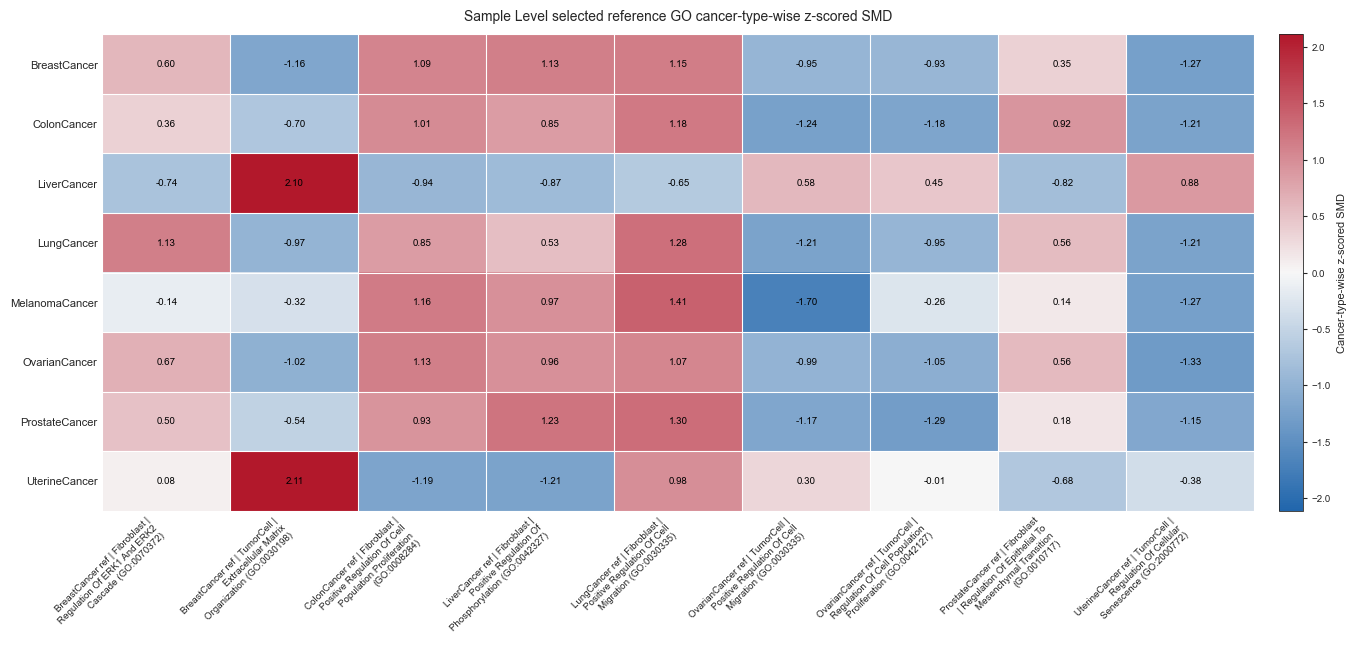

Done.
Selected reference GO downstream SMD table: reference_module_smd_df
Raw SMD heatmaps and cancer-type-wise z-scored SMD heatmaps were saved to:
D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\UpstreamGated_MI7_to_MI4_cancerFibroCancer\zscore_mean_global_per_cancertype\ReferenceGO_SelectedTerms\SMD_heatmaps


In [29]:
# ==============================================================
# SMD heatmaps for selected reference GO module scores
# --------------------------------------------------------------
# Rows are applied/current cancer types.
# Columns are selected reference GO gene sets:
#   ReferenceCancerType ref | CellSide | GO term
#
# Two heatmaps are saved for each requested statistical level:
#   1. Raw SMD
#   2. Cancer-type-wise z-scored SMD
#      For each applied CancerType row, SMD values are z-scored
#      across selected reference GO gene sets.
# ==============================================================

import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# ==============================================================
# User parameters
# ==============================================================

REFERENCE_GO_SMD_HEATMAP_LEVELS_TO_PLOT = ("single_unit", "sample_level")
# Options:
#   ("single_unit",)
#   ("sample_level",)
#   ("single_unit", "sample_level")

REFERENCE_GO_SMD_HEATMAP_ANNOTATE_VALUES = True
REFERENCE_GO_SMD_HEATMAP_VALUE_FMT = "{:.2f}"

REFERENCE_GO_SMD_HEATMAP_ABS_MAX = None
# None: use matrix-specific max absolute value.
# Or set manually, e.g. 2.0.

REFERENCE_GO_SMD_HEATMAP_PLOT_CANCERTYPE_ZSCORE = True
REFERENCE_GO_SMD_HEATMAP_CANCERTYPE_ZSCORE_ABS_MAX = None
# None: use matrix-specific max absolute z-score.
# Or set manually, e.g. 2.5.

REFERENCE_GO_SMD_CELL_WIDTH = 1.15
REFERENCE_GO_SMD_CELL_HEIGHT = 0.50
REFERENCE_GO_SMD_MIN_WIDTH = 8.5
REFERENCE_GO_SMD_MIN_HEIGHT = 4.5
REFERENCE_GO_SMD_MAX_WIDTH = 34
REFERENCE_GO_SMD_MAX_HEIGHT = 14
REFERENCE_GO_SMD_XLABEL_WRAP_WIDTH = 32

REFERENCE_GO_SMD_CMAP_LOW = "#2166ac"
REFERENCE_GO_SMD_CMAP_MID = "#f7f7f7"
REFERENCE_GO_SMD_CMAP_HIGH = "#b2182b"

reference_go_smd_outdir = reference_go_outdir / "SMD_heatmaps"
reference_go_smd_outdir.mkdir(parents=True, exist_ok=True)


# ==============================================================
# Helper functions
# ==============================================================

def _reference_go_smd_safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)


def _reference_go_smd_wrap_label(x, width=28):
    return "\n".join(
        textwrap.wrap(
            str(x),
            width=int(width),
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


def _reference_go_smd_make_feature_label(row):
    """
    Column label for selected reference GO gene set.

    Explicitly marks which reference cancer type the GO geneset came from.
    """
    ref_ct = _reference_go_smd_safe_str(row.get("ReferenceCancerType", "ReferenceCancerTypeNA"))
    cell_side = _reference_go_smd_safe_str(row.get("CellSide", "CellSideNA"))
    term = _reference_go_smd_safe_str(row.get("Term", "TermNA"))

    return f"{ref_ct} ref | {cell_side} | {term}"


def _reference_go_smd_make_feature_key(row):
    """
    Stable key for selected reference GO gene set.

    Prefer ReferenceGOSetKey / ReferenceGORowKey if available.
    Otherwise build from ReferenceCancerType × CellSide × LibraryShort × Term.
    """
    for key_col in ["ReferenceGOSetKey", "ReferenceGORowKey", "TermKey"]:
        if key_col in row.index:
            value = row.get(key_col)
            if pd.notna(value) and str(value) != "":
                return str(value)

    ref_ct = _reference_go_smd_safe_str(row.get("ReferenceCancerType", "ReferenceCancerTypeNA"))
    cell_side = _reference_go_smd_safe_str(row.get("CellSide", "CellSideNA"))
    lib = _reference_go_smd_safe_str(row.get("LibraryShort", "GO"))
    term = _reference_go_smd_safe_str(row.get("Term", "TermNA"))

    return f"{ref_ct}__{cell_side}__{lib}__{term}"


def _reference_go_cancertype_order_present(df):
    present = set(df["CancerType"].dropna().astype(str)) if not df.empty else set()

    candidate_order_names = [
        "CancerType_order",
        "CANCER_TYPE_ORDER",
        "CANCER_TYPES_ORDER",
        "cancer_type_order",
        "cancer_types_order",
        "CASCADE_CANCER_TYPE_ORDER",
    ]

    ordered = None

    for name in candidate_order_names:
        if name in globals():
            try:
                tmp = [str(x) for x in list(globals()[name])]
                if len(tmp) > 0:
                    ordered = [ct for ct in tmp if ct in present]
                    break
            except Exception:
                pass

    if ordered is None:
        ordered = [
            "BreastCancer",
            "ColonCancer",
            "LiverCancer",
            "LungCancer",
            "MelanomaCancer",
            "OvarianCancer",
            "ProstateCancer",
            "UterineCancer",
        ]
        ordered = [ct for ct in ordered if ct in present]

    remaining = sorted([ct for ct in present if ct not in ordered])
    return ordered + remaining


def _reference_go_make_smd_matrix(stats_df):
    if stats_df.empty:
        return pd.DataFrame()

    use = stats_df.dropna(subset=["SMD"]).copy()

    if use.empty:
        return pd.DataFrame()

    use["CancerType"] = use["CancerType"].astype(str)
    use["ReferenceGOFeatureKey"] = use.apply(_reference_go_smd_make_feature_key, axis=1)
    use["ReferenceGOFeatureLabel"] = use.apply(_reference_go_smd_make_feature_label, axis=1)

    # One label per stable key.
    label_lookup = (
        use[["ReferenceGOFeatureKey", "ReferenceGOFeatureLabel"]]
        .drop_duplicates("ReferenceGOFeatureKey")
        .set_index("ReferenceGOFeatureKey")["ReferenceGOFeatureLabel"]
        .to_dict()
    )

    mat_key = use.pivot_table(
        index="CancerType",
        columns="ReferenceGOFeatureKey",
        values="SMD",
        aggfunc="mean",
    )

    row_order = _reference_go_cancertype_order_present(use)

    col_order_key_df = (
        use[
            [
                "SelectedOrder",
                "ReferenceCancerType",
                "CellSide",
                "Term",
                "ReferenceGOFeatureKey",
            ]
        ]
        .drop_duplicates("ReferenceGOFeatureKey")
        .sort_values(
            ["SelectedOrder", "ReferenceCancerType", "CellSide", "Term"],
            kind="mergesort",
        )
    )

    col_order_keys = col_order_key_df["ReferenceGOFeatureKey"].tolist()

    row_order = [r for r in row_order if r in mat_key.index]
    col_order_keys = [c for c in col_order_keys if c in mat_key.columns]

    mat_key = mat_key.reindex(index=row_order, columns=col_order_keys)

    mat_key.columns = [label_lookup.get(c, c) for c in mat_key.columns]

    return mat_key


def _reference_go_cancertype_zscore_matrix(mat):
    """
    CancerType-wise z-score normalization.

    For each CancerType row:
        z = (SMD - mean(SMD across selected GO gene sets)) /
            sd(SMD across selected GO gene sets)

    Missing values remain NaN.
    If a row has zero SD, finite values are set to 0.
    """
    if mat.empty:
        return pd.DataFrame()

    arr = mat.to_numpy(dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)

    for i in range(arr.shape[0]):
        row = arr[i, :]
        finite = np.isfinite(row)

        if finite.sum() == 0:
            continue

        mu = np.nanmean(row[finite])
        sd = np.nanstd(row[finite], ddof=0)

        if not np.isfinite(sd) or sd <= 0:
            out[i, finite] = 0.0
        else:
            out[i, finite] = (row[finite] - mu) / sd

    return pd.DataFrame(out, index=mat.index, columns=mat.columns)


_reference_go_save_figure_pair_use = (
    _reference_go_save_figure_pair
    if "_reference_go_save_figure_pair" in globals()
    else _reference_go_save_figure_pair_local
)

_reference_go_to_csv_use = (
    _reference_go_to_csv
    if "_reference_go_to_csv" in globals()
    else _reference_go_to_csv_local
)


def _plot_reference_go_smd_heatmap_matrix(
    mat,
    title,
    output_prefix,
    value_label="SMD",
    value_fmt="{:.2f}",
    annotate=True,
    abs_max=None,
):
    if mat.empty:
        print(f"No matrix values to plot for {title}.")
        return None

    values = mat.to_numpy(dtype=float)
    finite = np.isfinite(values)

    if abs_max is None:
        vmax = float(np.nanmax(np.abs(values))) if finite.any() else 1.0
        vmax = max(vmax, 1e-6)
    else:
        vmax = float(abs_max)

    vmin = -vmax

    n_rows, n_cols = mat.shape

    fig_w = min(
        max(REFERENCE_GO_SMD_CELL_WIDTH * n_cols + 3.4, REFERENCE_GO_SMD_MIN_WIDTH),
        REFERENCE_GO_SMD_MAX_WIDTH,
    )

    fig_h = min(
        max(REFERENCE_GO_SMD_CELL_HEIGHT * n_rows + 2.6, REFERENCE_GO_SMD_MIN_HEIGHT),
        REFERENCE_GO_SMD_MAX_HEIGHT,
    )

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    cmap = LinearSegmentedColormap.from_list(
        "reference_go_smd_diverging",
        [
            REFERENCE_GO_SMD_CMAP_LOW,
            REFERENCE_GO_SMD_CMAP_MID,
            REFERENCE_GO_SMD_CMAP_HIGH,
        ],
        N=256,
    )
    cmap.set_bad("#eeeeee")

    masked_values = np.ma.masked_invalid(values)

    im = ax.imshow(
        masked_values,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))

    ax.set_xticklabels(
        [
            _reference_go_smd_wrap_label(c, REFERENCE_GO_SMD_XLABEL_WRAP_WIDTH)
            for c in mat.columns
        ],
        rotation=45,
        ha="right",
        fontsize=7,
    )

    ax.set_yticklabels(mat.index.astype(str), fontsize=8)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=0.8,
    )

    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    if annotate:
        for i in range(n_rows):
            for j in range(n_cols):
                val = values[i, j]

                if np.isfinite(val):
                    ax.text(
                        j,
                        i,
                        value_fmt.format(val),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="black",
                    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(value_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_title(title, fontsize=10, pad=10)

    fig.tight_layout()

    _reference_go_save_figure_pair_use(
        fig,
        reference_go_smd_outdir / output_prefix,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return fig


# ==============================================================
# Collect available stats tables
# ==============================================================

reference_go_stats_tables = {}

if "reference_single_unit_stats_df" in globals() and not reference_single_unit_stats_df.empty:
    reference_go_stats_tables["single_unit"] = reference_single_unit_stats_df

if "reference_sample_level_stats_df" in globals() and not reference_sample_level_stats_df.empty:
    reference_go_stats_tables["sample_level"] = reference_sample_level_stats_df

if len(reference_go_stats_tables) == 0:
    raise ValueError("No selected reference GO stats tables are available. Run the stats cell first.")


# ==============================================================
# Plot heatmaps
# ==============================================================

for level in REFERENCE_GO_SMD_HEATMAP_LEVELS_TO_PLOT:
    if level not in reference_go_stats_tables:
        print(f"Skipping {level}: stats table is not available.")
        continue

    stats_df = reference_go_stats_tables[level].copy()

    mat = _reference_go_make_smd_matrix(stats_df)

    if mat.empty:
        print(f"Skipping {level}: empty SMD matrix.")
        continue

    mat_path = _reference_go_to_csv_use(
        mat,
        reference_go_smd_outdir / f"selected_reference_go_{level}_SMD_matrix_refCancerLabeled.csv",
        index=True,
    )

    print(f"Saved selected reference GO SMD matrix: {mat_path}")
    display(mat)

    _plot_reference_go_smd_heatmap_matrix(
        mat=mat,
        title=f"{level.replace('_', ' ').title()} selected reference GO SMD",
        output_prefix=f"selected_reference_go_{level}_SMD_heatmap_refCancerLabeled",
        value_label="SMD",
        value_fmt=REFERENCE_GO_SMD_HEATMAP_VALUE_FMT,
        annotate=REFERENCE_GO_SMD_HEATMAP_ANNOTATE_VALUES,
        abs_max=REFERENCE_GO_SMD_HEATMAP_ABS_MAX,
    )

    if REFERENCE_GO_SMD_HEATMAP_PLOT_CANCERTYPE_ZSCORE:
        mat_cancertype_zscore = _reference_go_cancertype_zscore_matrix(mat)

        mat_cancertype_zscore_path = _reference_go_to_csv_use(
            mat_cancertype_zscore,
            reference_go_smd_outdir / f"selected_reference_go_{level}_SMD_cancertype_wise_zscore_matrix_refCancerLabeled.csv",
            index=True,
        )

        print(f"Saved selected reference GO cancer-type-wise z-scored SMD matrix: {mat_cancertype_zscore_path}")
        display(mat_cancertype_zscore)

        _plot_reference_go_smd_heatmap_matrix(
            mat=mat_cancertype_zscore,
            title=f"{level.replace('_', ' ').title()} selected reference GO cancer-type-wise z-scored SMD",
            output_prefix=f"selected_reference_go_{level}_SMD_cancertype_wise_zscore_heatmap_refCancerLabeled",
            value_label="Cancer-type-wise z-scored SMD",
            value_fmt=REFERENCE_GO_SMD_HEATMAP_VALUE_FMT,
            annotate=REFERENCE_GO_SMD_HEATMAP_ANNOTATE_VALUES,
            abs_max=REFERENCE_GO_SMD_HEATMAP_CANCERTYPE_ZSCORE_ABS_MAX,
        )


print("Done.")
print("Selected reference GO downstream SMD table: reference_module_smd_df")
print("Raw SMD heatmaps and cancer-type-wise z-scored SMD heatmaps were saved to:")
print(reference_go_smd_outdir)